In [2]:
# Ensure this notebook can access the repo data folder directly
from pathlib import Path
# notebooks/ -> repo root is parent
REPO_ROOT = Path.cwd().resolve().parent
BRONZE_TABLE = REPO_ROOT / "data" / "capa_bronze" / "readings_v1"
print("BRONZE_TABLE:", BRONZE_TABLE)


BRONZE_TABLE: C:\Users\Asus TUF\Desktop\proy_ml\data\capa_bronze\readings_v1


Se encontraron 91 variables únicas para analizar.


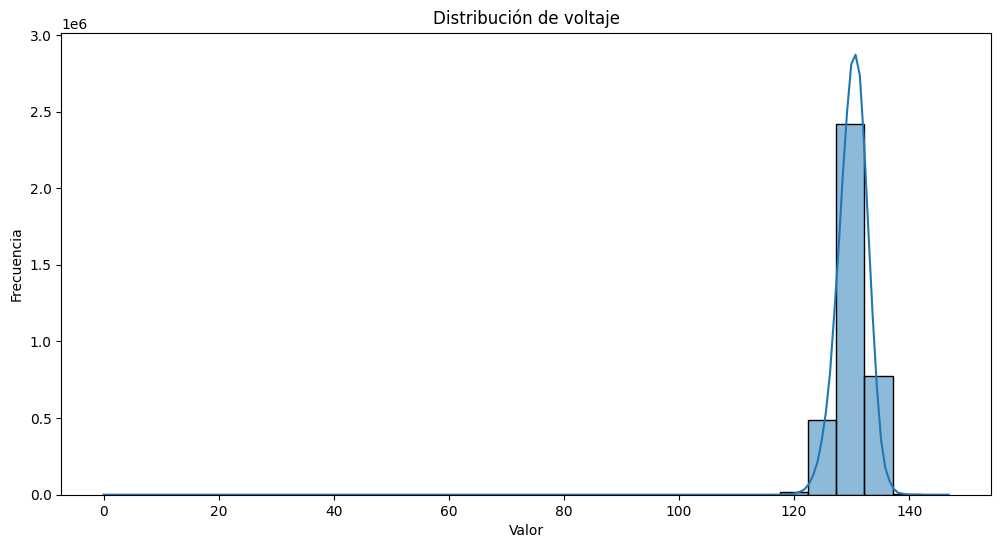

In [3]:
import pandas as pd
import polars as pl
from deltalake import DeltaTable
import os

# Define la ruta a la tabla Delta de la capa Bronze
BRONZE_TABLE_PATH = BRONZE_TABLE

def load_bronze_data(path: str) -> pl.DataFrame:
    """Carga todos los datos de la tabla Delta Bronze de forma eficiente."""
    try:
        dt = DeltaTable(path)
        return pl.from_arrow(dt.to_pyarrow_table())
    except Exception as e:
        print(f"Error al cargar la tabla Delta: {e}")
        return pl.DataFrame()

# Cargar el DataFrame completo con Polars
df = load_bronze_data(BRONZE_TABLE_PATH)
if df.is_empty():
    print("El DataFrame está vacío. Asegúrate de haber ejecutado tu script de extracción.")
    exit()

# Obtener la lista de todas las variables únicas (tags)
unique_tags = df.get_column("tag").unique().to_list()
print(f"Se encontraron {len(unique_tags)} variables únicas para analizar.")

# Preparar una lista para almacenar los resultados del análisis
tag_name = "voltaje"  # Cambia esto por la variable que quieras analizar


df_tag = df.filter(pl.col("tag") == tag_name)
    # Convertir a Pandas para el análisis detallado
pdf_tag = df_tag.to_pandas()

import matplotlib.pyplot as plt
import seaborn as sns
#histograma
plt.figure(figsize=(12, 6))
sns.histplot(pdf_tag['value'], bins=30, kde=True)
plt.title(f"Distribución de {tag_name}")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.show()


In [8]:
import pandas as pd
import polars as pl
from deltalake import DeltaTable
import os

# Define la ruta a la tabla Delta de la capa Bronze
BRONZE_TABLE_PATH = BRONZE_TABLE

def load_bronze_data(path: str) -> pl.DataFrame:
    """Carga todos los datos de la tabla Delta Bronze de forma eficiente."""
    try:
        dt = DeltaTable(path)
        return pl.from_arrow(dt.to_pyarrow_table())
    except Exception as e:
        print(f"Error al cargar la tabla Delta: {e}")
        return pl.DataFrame()

# Cargar el DataFrame completo con Polars
df = load_bronze_data(BRONZE_TABLE_PATH)
if df.is_empty():
    print("El DataFrame está vacío. Asegúrate de haber ejecutado tu script de extracción.")
    exit()

# Obtener la lista de todas las variables únicas (tags)
unique_tags = df.get_column("tag").unique().to_list()
print(f"Se encontraron {len(unique_tags)} variables únicas para analizar.")

# Preparar una lista para almacenar los resultados del análisis
report_data = []

# Iterar a través de cada variable y recolectar métricas clave
for tag_name in unique_tags:
    df_tag = df.filter(pl.col("tag") == tag_name)

    if df_tag.is_empty():
        continue

    # Convertir a Pandas para el análisis detallado
    pdf_tag = df_tag.to_pandas()
    
    # --- Determinar el tipo de variable ---
    tipo = "Desconocido"
    # si la columna 'value bool' tiene valores es booleana
    if pdf_tag['value_bool'].notna().any():
        tipo = "Booleana"
    #si la columna 'value text' tiene valores es categorica (texto)
    elif pd.api.types.is_numeric_dtype(pdf_tag['value']):
        #Distincion basica entre discreta y continua
        unique_values=pdf_tag['value'].dropna().unique()
        if len(unique_values) <= 20:
            tipo='Numerica (discreta)'
        else:
            tipo='Numerica (continua)'
    
    # 1. Análisis de Calidad de Datos
    total_rows = len(pdf_tag)
    nulls_count = pdf_tag['value'].isnull().sum()
    null_percentage = (nulls_count / total_rows) * 100
    
    # 2. Análisis de Frecuencia de Muestreo
    pdf_tag['timestamp'] = pd.to_datetime(pdf_tag['timestamp'], errors='coerce')
    pdf_tag_cleaned = pdf_tag.dropna(subset=['timestamp'])

    if not pdf_tag_cleaned.empty:
        # Calcular la diferencia de tiempo entre cada registro consecutivo
        time_deltas = pdf_tag_cleaned['timestamp'].diff().dropna()
        
        # Calcular la frecuencia de muestreo más común (moda) en segundos
        # Se redondea a segundos para evitar problemas con milisegundos
        most_common_frequency = time_deltas.dt.total_seconds().mode()
        frequency_in_seconds = most_common_frequency[0] if not most_common_frequency.empty else None
    else:
        frequency_in_seconds = None

    # 3. Resumen Estadístico
    stats = pdf_tag['value'].describe(percentiles=[.25, .5, .75])
    
    # Recolectar todos los datos para el reporte
    report_data.append({
        'variable': tag_name,
        'tipo': tipo,
        'total_registros': total_rows,
        'registros_sin_nulos': total_rows - nulls_count,
        'porcentaje_nulos': f"{null_percentage:.2f}%",
        'frecuencia_muestreo_seg': frequency_in_seconds,
        'media': stats.get('mean', 'N/A'),
        'desviacion_estandar': stats.get('std', 'N/A'),
        'min_valor': stats.get('min', 'N/A'),
        'max_valor': stats.get('max', 'N/A'),
    })

# Crear el DataFrame del reporte final
report_df = pd.DataFrame(report_data)

# Ordenar el reporte por el porcentaje de nulos, de menor a mayor
report_df_sorted = report_df.sort_values(by='total_registros', ascending=True)

# Imprimir el reporte
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print("### Reporte Consolidado de Calidad y Frecuencia de Variables ###")
print(report_df_sorted)
#Guardar reporte en formato CSV
report_df_sorted.to_csv("reporte_calidad_frecuencia.csv", index=False)
#guard reporte en formato pdf
report_df_sorted.to_html("reporte_calidad_frecuencia.html")


Se encontraron 91 variables únicas para analizar.
### Reporte Consolidado de Calidad y Frecuencia de Variables ###
                               variable                 tipo  total_registros  registros_sin_nulos porcentaje_nulos  frecuencia_muestreo_seg         media  desviacion_estandar   min_valor     max_valor
77                  factor_carga_fase_2  Numerica (continua)             2623                 2032           22.53%                 0.100998      0.321688             0.155305    0.000000      1.102390
4                      ventilador_9_mcb  Numerica (discreta)             2855                    0          100.00%             28800.000000           NaN                  NaN         NaN           NaN
8                      ventilador_8_mcb  Numerica (discreta)             2855                    0          100.00%             28800.000000           NaN                  NaN         NaN           NaN
30                    switch_S22_remote  Numerica (discreta)             2858

In [3]:
import pandas as pd
from deltalake import DeltaTable

TAG = "temperatura_aceite"  # cámbialo

dt = DeltaTable(str(BRONZE_TABLE))
df_tag = dt.to_pyarrow_table().to_pandas()
df_tag = df_tag[df_tag["tag"] == TAG].copy()

ts_col = "timestamp" if "timestamp" in df_tag.columns else ("ts" if "ts" in df_tag.columns else None)
if ts_col:
    df_tag[ts_col] = pd.to_datetime(df_tag[ts_col], utc=True, errors="coerce")
    if ts_col != "timestamp":
        df_tag = df_tag.rename(columns={ts_col: "timestamp"})
    df_tag = df_tag.sort_values("timestamp", ascending=True, na_position="last").reset_index(drop=True)

df_tag.head() 


,timestamp,value,value_text,value_bool,tag,date
0,2024-09-10 00:43:12.798004+00:00,55.299999,55.29999923706055,None,temperatura_aceite,2024-09-10
1,2024-09-10 01:43:13.001007+00:00,54.799999,54.79999923706055,None,temperatura_aceite,2024-09-10
2,2024-09-10 03:13:13.220001+00:00,53.900002,53.900001525878906,None,temperatura_aceite,2024-09-10
3,2024-09-10 04:23:12.829010+00:00,53.500000,53.5,None,temperatura_aceite,2024-09-10
4,2024-09-10 06:03:13.010009+00:00,52.299999,52.29999923706055,None,temperatura_aceite,2024-09-10


In [2]:
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from deltalake import DeltaTable
import os
# Ensure this notebook can access the repo data folder directly
from pathlib import Path
# notebooks/ -> repo root is parent
REPO_ROOT = Path.cwd().resolve().parent
BRONZE_TABLE = REPO_ROOT / "data" / "capa_silver" / "preprocesamiento_silver"
# Define la ruta a la tabla Delta de la capa Bronze
BRONZE_TABLE_PATH = BRONZE_TABLE

# --- PASO 1: Cargar datos en Polars ---
def load_bronze_data(path: str) -> pl.DataFrame:
    """Carga todos los datos de la tabla Delta Bronze."""
    try:
        dt = DeltaTable(path)
        # Usar Polars para leer la tabla de forma eficiente
        return pl.from_arrow(dt.to_pyarrow_table())
    except Exception as e:
        print(f"Error al cargar la tabla Delta: {e}")
        return pl.DataFrame()

# Cargar el DataFrame completo
df = load_bronze_data(BRONZE_TABLE_PATH)

In [2]:
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from deltalake import DeltaTable
import os
# Ensure this notebook can access the repo data folder directly
from pathlib import Path
# notebooks/ -> repo root is parent
REPO_ROOT = Path.cwd().resolve().parent
BRONZE_TABLE = REPO_ROOT / "data" / "capa_bronze" / "readings_v1"
# Define la ruta a la tabla Delta de la capa Bronze
BRONZE_TABLE_PATH = BRONZE_TABLE

# --- PASO 1: Cargar datos en Polars ---
def load_bronze_data(path: str) -> pl.DataFrame:
    """Carga todos los datos de la tabla Delta Bronze."""
    try:
        dt = DeltaTable(path)
        # Usar Polars para leer la tabla de forma eficiente
        return pl.from_arrow(dt.to_pyarrow_table())
    except Exception as e:
        print(f"Error al cargar la tabla Delta: {e}")
        return pl.DataFrame()

# Cargar el DataFrame completo
df = load_bronze_data(BRONZE_TABLE_PATH)
if df.is_empty():
    print("El DataFrame está vacío. Asegúrate de haber ejecutado tu script de extracción.")
    exit()

# --- PASO 2: Obtener la lista de todas las variables únicas (tags) ---
# Se asume que la columna de tags se llama 'tag'
unique_tags = df.get_column("tag").unique().to_list()
print(f"Se encontraron {len(unique_tags)} variables únicas para analizar.")
tag_name = "voltaje"  # Cambia esto por la variable que quieras analizar
df_tag = df.filter(pl.col("tag") == tag_name)
pdf_tag = df_tag.to_pandas()
#histogrma
plt.figure(figsize=(10, 5))
sns.histplot(pdf_tag['value'].dropna(), bins=30, kde=True)
plt.title(f'Histograma de Valores para {tag_name}')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

# # --- PASO 3: Iterar a través de cada variable y realizar un EDA completo ---
# for tag_name in unique_tags:
#     print(f"\n############################################################")
#     print(f"### ANÁLISIS EDA PARA LA VARIABLE: '{tag_name}' ###")
#     print(f"############################################################")

#     # Filtrar el DataFrame para la variable actual
#     df_tag = df.filter(pl.col("tag") == tag_name)

#     if df_tag.is_empty():
#         print("No hay datos para esta variable. Saltando al siguiente tag.")
#         continue

#     # Convertir a Pandas para el análisis y visualización (si prefieres Polars, los métodos son similares)
#     pdf_tag = df_tag.to_pandas()

#     # 1. Perfilado de Datos (Valores faltantes)
#     total_rows = len(pdf_tag)
#     nulls = pdf_tag['value'].isnull().sum()
#     null_percentage = (nulls / total_rows) * 100
#     print(f"Total de registros: {total_rows}")
#     print(f"Valores nulos: {nulls} ({null_percentage:.2f}%)")

#     # 2. Resumen Estadístico para variables numéricas
#     if pd.api.types.is_numeric_dtype(pdf_tag['value']):
#         print("\n--- Resumen Estadístico de 'value' ---")
#         print(pdf_tag['value'].describe().to_string())
#     else:
#         print("\n--- La variable no es numérica, saltando el resumen estadístico. ---")

#     # 3. Análisis de Distribución (Diagrama de Caja)
#     if pd.api.types.is_numeric_dtype(pdf_tag['value']):
#         plt.figure(figsize=(10, 5))
#         sns.boxplot(x=pdf_tag['value'].dropna())
#         plt.title(f'Distribución y Outliers para {tag_name}')
#         plt.xlabel('Valor')
#         plt.show()

#     # 4. Análisis de Series de Tiempo
#     if 'timestamp' in pdf_tag.columns:
#         # Asegurarse de que el 'timestamp' sea un índice de tiempo
#         pdf_tag['timestamp'] = pd.to_datetime(pdf_tag['timestamp'], errors='coerce')
#         pdf_tag_cleaned = pdf_tag.dropna(subset=['timestamp']).set_index('timestamp').sort_index()

#         if not pdf_tag_cleaned.empty:
#         # Visualizar la serie de tiempo para la variable
#             plt.figure(figsize=(15, 6))
#             pdf_tag_cleaned['value'].plot(title=f'Serie de Tiempo para {tag_name}')
#             plt.xlabel('Fecha')
#             plt.ylabel('Valor')
#             plt.grid(True)
#             plt.show()
#         else:
#             print("No se puede generar el gráfico de serie de tiempo porque todos los timestamps son nulos o inválidos.")
#     print("\nAnálisis completo para esta variable. Continuando con la siguiente...")

: 

Drop constantes: ['suboptimal_operation']
Clases: {'ALERTA': 0, 'CRITICO': 1, 'NORMAL': 2}

== SPLIT ==
Train: (6754, 58)  Valid: (1689, 58)
Train range: 2024-09-10 04:00:00+00:00 → 2025-06-18 13:00:00+00:00
Valid range: 2025-06-18 14:00:00+00:00 → 2025-08-27 22:00:00+00:00
Distribución VALID (bin): Counter({np.int64(0): 1329, np.int64(1): 360})

== SEQ ==
Xtr_seq: (6731, 24, 58) | Xva_seq: (1666, 24, 58)
y_valid_bin aligned: (1666,)
Epoch 1/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 14s 106ms/step - loss: 0.8571 - val_loss: 2.4584 - learning_rate: 0.0010
Epoch 2/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - loss: 0.5838 - val_loss: 2.4098 - learning_rate: 0.0010
Epoch 3/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - loss: 0.4696 - val_loss: 2.3227 - learning_rate: 0.0010
Epoch 4/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - loss: 0.4102 - val_loss: 2.2603 - learning_rate: 0.0010
Epoch 5/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - loss: 0.3782 - val_loss: 2.0715 - learning_rate: 0.0010
Epoch 6/60
53/5

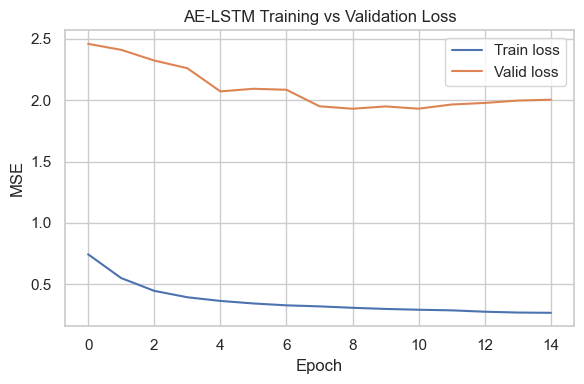


[AE-LSTM] ROC-AUC=0.752 | PR-AUC=0.374


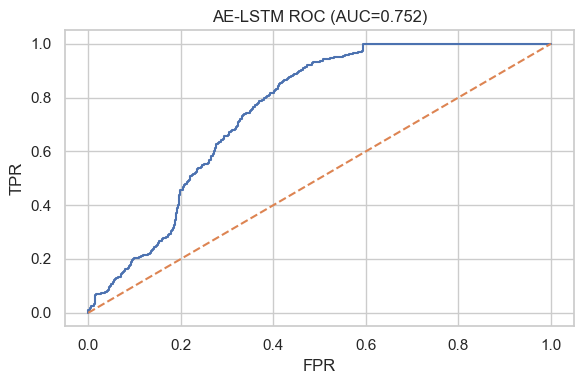

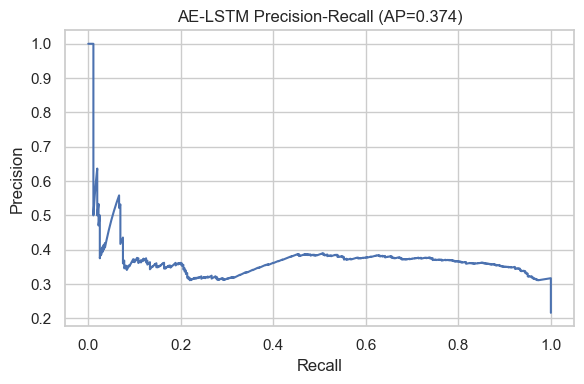

[AE] best F2=0.699 @ thr=1.391247 | P=0.317 R=1.000 (F1=0.481)

AE-LSTM @thr p95 (unsupervised) (thr=0.635847)
              precision    recall  f1-score   support

      NORMAL     1.0000    0.3744    0.5448      1306
   NO-NORMAL     0.3059    1.0000    0.4684       360

    accuracy                         0.5096      1666
   macro avg     0.6529    0.6872    0.5066      1666
weighted avg     0.8500    0.5096    0.5283      1666



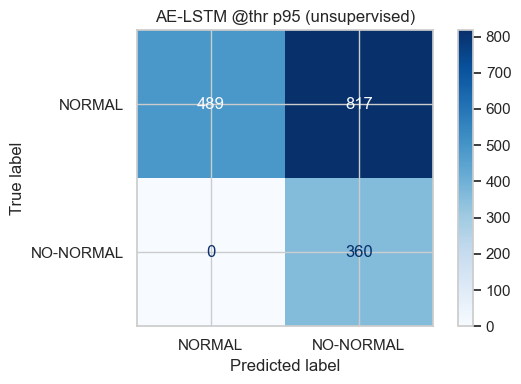


AE-LSTM @thr F2 (valid-supervised) (thr=1.391247)
              precision    recall  f1-score   support

      NORMAL     1.0000    0.4058    0.5773      1306
   NO-NORMAL     0.3169    1.0000    0.4813       360

    accuracy                         0.5342      1666
   macro avg     0.6585    0.7029    0.5293      1666
weighted avg     0.8524    0.5342    0.5566      1666



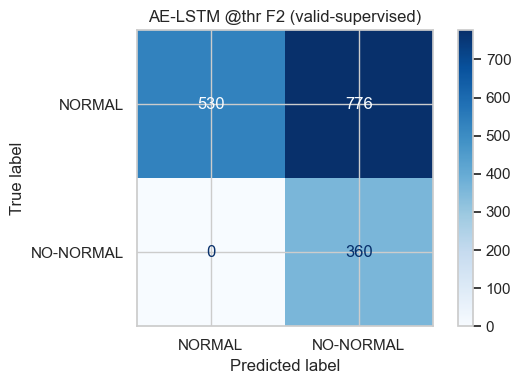


[IForest] ROC-AUC=0.715 | PR-AUC=0.341


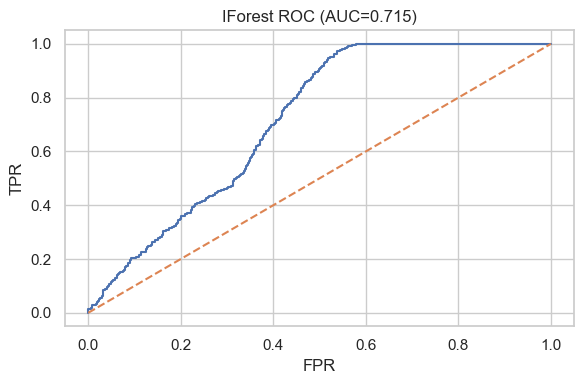

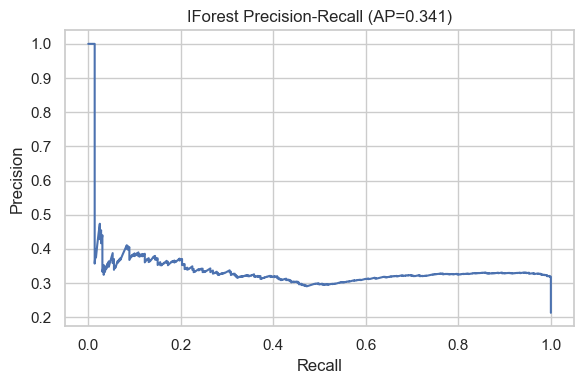

[IF] best F2=0.702 @ thr=0.509752 | P=0.323 R=0.992 (F1=0.488)

IForest @thr p95 (unsupervised) (thr=0.507428)
              precision    recall  f1-score   support

      NORMAL     0.9965    0.4296    0.6004      1329
   NO-NORMAL     0.3208    0.9944    0.4851       360

    accuracy                         0.5500      1689
   macro avg     0.6586    0.7120    0.5428      1689
weighted avg     0.8525    0.5500    0.5758      1689



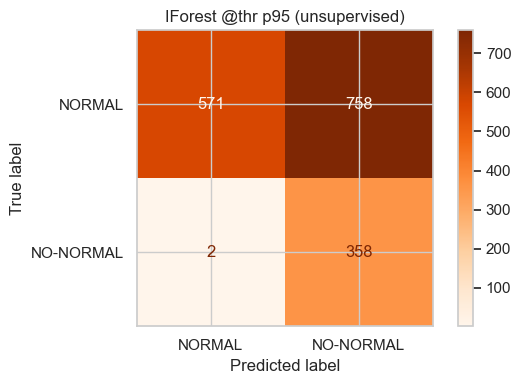


IForest @thr F2 (valid-supervised) (thr=0.509752)
              precision    recall  f1-score   support

      NORMAL     0.9949    0.4379    0.6082      1329
   NO-NORMAL     0.3234    0.9917    0.4877       360

    accuracy                         0.5560      1689
   macro avg     0.6591    0.7148    0.5479      1689
weighted avg     0.8517    0.5560    0.5825      1689



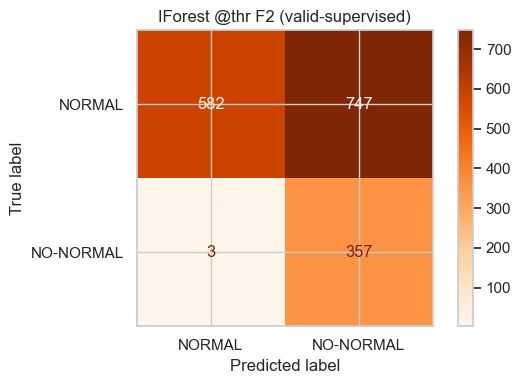


[ENSEMBLE] best F2=0.701 @ thr=0.276104 | P=0.320 R=1.000 (F1=0.485)

ENSEMBLE @thr F2 (thr=0.276104)
              precision    recall  f1-score   support

      NORMAL     1.0000    0.4135    0.5850      1306
   NO-NORMAL     0.3197    1.0000    0.4845       360

    accuracy                         0.5402      1666
   macro avg     0.6599    0.7067    0.5348      1666
weighted avg     0.8530    0.5402    0.5633      1666



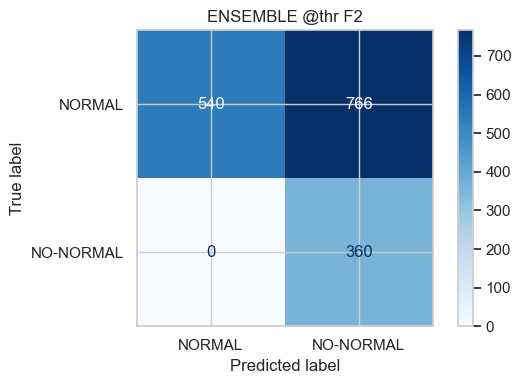


[Ensamble + smoothing 3/5]
              precision    recall  f1-score   support

      NORMAL     1.0000    0.4112    0.5827      1306
   NO-NORMAL     0.3189    1.0000    0.4835       360

    accuracy                         0.5384      1666
   macro avg     0.6594    0.7056    0.5331      1666
weighted avg     0.8528    0.5384    0.5613      1666



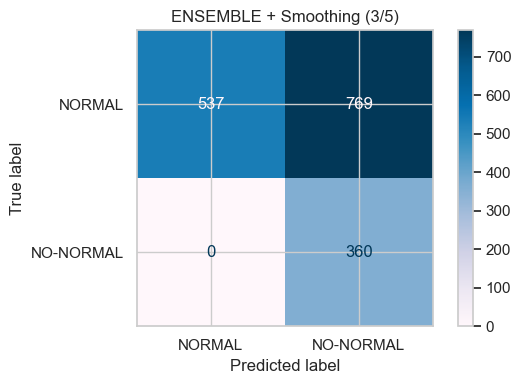


[AE] Top features que explican anomalías (promedio):
power_factor_estimated            74.026749
thermal_efficiency                17.290560
current_load_value_transient       7.737730
overload_indicator                 5.569985
year                               3.832050
power_apparent_value_transient     3.349193
power_apparent_value_stability     2.249233
current_load_value_stability       2.171103
voltage_value_transient            1.833010
load_factor_power                  1.782637
dtype: float32


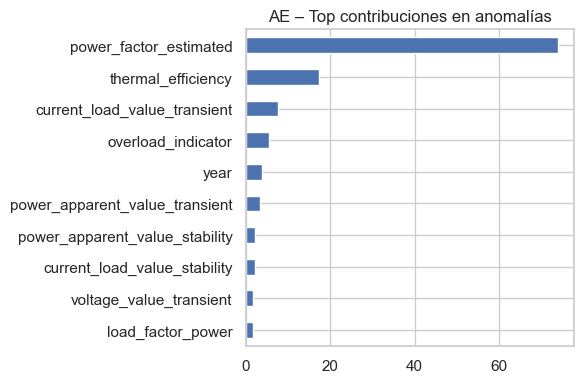

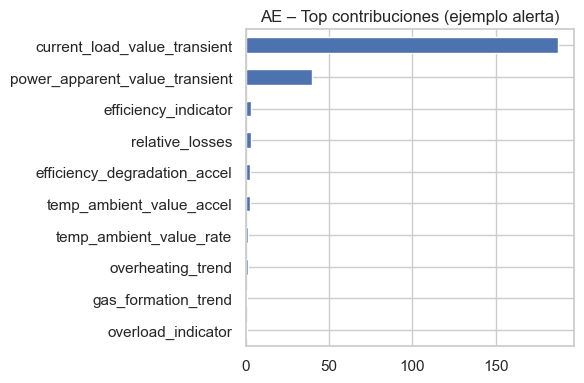


[Surrogate Tree] Top features que separan NORMAL/ANÓMALO (ensamble+smoothing):
load_factor_power          0.983378
voltage_value_stability    0.007521
voltage_value              0.004736
temp_rise_hot              0.003506
overheating_trend          0.000860
temp_oil_oltc_value        0.000000
current_load_value         0.000000
temp_ambient_value         0.000000
temp_bubbling_value        0.000000
temp_spot_hot_value        0.000000
year                       0.000000
month                      0.000000
dtype: float64


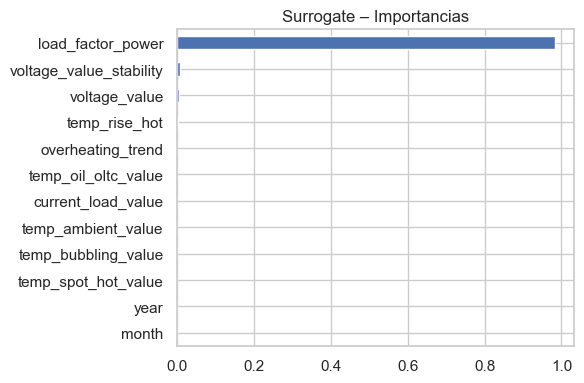


✅ Artefactos guardados en: C:\Users\Asus TUF\Desktop\proy_ml\data\capa_gold\artifacts_anomalia


In [ ]:
# ============================================
# 0) Imports, config y utilidades
# ============================================
import os, json
from pathlib import Path
from typing import List, Tuple
from collections import Counter, deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from deltalake import DeltaTable
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, average_precision_score, precision_recall_curve, roc_curve,
    f1_score
)
from sklearn.ensemble import IsolationForest
from sklearn.tree import DecisionTreeClassifier

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import joblib

# Reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
plt.rcParams["figure.figsize"] = (6, 4)

# Config ventanas
LOOKBACK = 24         # pasos por secuencia (p.ej., 24 horas)
HORIZON_SHIFT = 0     # 0 = puntuar t; si quisieras +1, cambia a 1

# Paths
def find_repo_root() -> Path:
    p = Path.cwd().resolve()
    for cand in (p, *p.parents):
        if (cand / "data").exists(): return cand
    return p

BASE_DIR = find_repo_root()
RUTA_GOLD_COMPLETE = BASE_DIR / "data" / "capa_gold" / "features_transformador" / "features_complete"

# Carpeta de artefactos (puedes cambiarla)
ARTIFACTS_DIR = BASE_DIR / "data" / "capa_gold" / "artifacts_anomalia"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# Columnas a excluir (fuga/texto/derivadas del futuro)
LEAK_OR_TEXT_COLS: List[str] = [
    "estado_futuro","falla_30d","rul_dias","severidad_futura",
    "dias_proximo_evento","proximidad_evento","riesgo_acumulativo",
    "estado_operacional","nivel_severidad","variables_anomalas","descripcion_anomalia"
]

# --------------------------------------------
# Utils métricas y gráficos
# --------------------------------------------
def plot_roc_pr(y_true: np.ndarray, scores: np.ndarray, title_prefix: str):
    fpr, tpr, _ = roc_curve(y_true, scores)
    prec, rec, _ = precision_recall_curve(y_true, scores)
    roc_auc = roc_auc_score(y_true, scores)
    pr_auc  = average_precision_score(y_true, scores)

    plt.plot(fpr, tpr); plt.plot([0,1],[0,1],'--')
    plt.title(f"{title_prefix} ROC (AUC={roc_auc:.3f})")
    plt.xlabel("FPR"); plt.ylabel("TPR"); plt.tight_layout(); plt.show()

    plt.plot(rec, prec)
    plt.title(f"{title_prefix} Precision-Recall (AP={pr_auc:.3f})")
    plt.xlabel("Recall"); plt.ylabel("Precision"); plt.tight_layout(); plt.show()

def eval_with_thr(scores: np.ndarray, y_true: np.ndarray, thr: float, title: str, cmap="Blues"):
    yhat = (scores > thr).astype(int)  # 1 = anómalo
    print(f"\n{title} (thr={thr:.6f})")
    print(classification_report(y_true, yhat, target_names=["NORMAL","NO-NORMAL"], digits=4, zero_division=0))
    cm = confusion_matrix(y_true, yhat, labels=[0,1])
    ConfusionMatrixDisplay(cm, display_labels=["NORMAL","NO-NORMAL"]).plot(cmap=cmap)
    plt.title(title); plt.tight_layout(); plt.show()
    return yhat

def best_thr_fbeta(scores: np.ndarray, y_true: np.ndarray, beta: float = 2.0, grid: int = 400):
    """
    Maximiza F_beta para clase positiva = NO-NORMAL.
    scores: mayor ⇒ más anómalo.
    """
    lo, hi = scores.min(), scores.max()
    ths = np.linspace(lo, hi, grid)
    best = (0.0, None, (0,0,0))  # (fbeta, thr, (precision, recall, f1))
    b2 = beta * beta
    for th in ths:
        yhat = (scores > th).astype(int)
        tp = ((y_true==1) & (yhat==1)).sum()
        fp = ((y_true==0) & (yhat==1)).sum()
        fn = ((y_true==1) & (yhat==0)).sum()
        prec = tp / (tp + fp) if (tp+fp)>0 else 0.0
        rec  = tp / (tp + fn) if (tp+fn)>0 else 0.0
        denom = b2*prec + rec
        fbeta = ((1+b2)*prec*rec/denom) if denom>0 else 0.0
        if fbeta > best[0]:
            f1 = (2*prec*rec)/(prec+rec) if (prec+rec)>0 else 0.0
            best = (fbeta, th, (prec, rec, f1))
    return best

def smooth_alerts(binary_seq: np.ndarray, k: int = 3, m: int = 5) -> np.ndarray:
    """
    Devuelve 1 si en la ventana móvil de tamaño m hay al menos k anomalías.
    """
    out = np.zeros_like(binary_seq)
    win = deque(maxlen=m)
    count = 0
    for i, v in enumerate(binary_seq):
        if len(win) == m:
            count -= win[0]
        win.append(v)
        count += v
        out[i] = 1 if count >= k else 0
    return out

def minmax_transform(x: np.ndarray, lo: float, hi: float):
    eps = 1e-12
    return (x - lo) / max(hi - lo, eps)

# ============================================
# 1) Carga Gold y prep básica
# ============================================
dt = DeltaTable(str(RUTA_GOLD_COMPLETE))
df = dt.to_pandas()
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
df = df.sort_values("timestamp").set_index("timestamp")

TARGET = "estado_futuro"
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
X_cols = [c for c in numeric_cols if c not in LEAK_OR_TEXT_COLS]

# quitar constantes y >30% NaN
const_cols = [c for c in X_cols if df[c].nunique() <= 1]
if const_cols:
    print("Drop constantes:", const_cols)
    X_cols = [c for c in X_cols if c not in const_cols]

nan_ratio = df[X_cols].isna().mean()
high_nan = nan_ratio[nan_ratio > 0.30].index.tolist()
if high_nan:
    print("Drop >30% NaN:", high_nan)
    X_cols = [c for c in X_cols if c not in high_nan]

# X, y y saneo básico
X_df = df[X_cols].replace([np.inf,-np.inf], np.nan)
X_df = X_df.fillna(X_df.median(numeric_only=True))
y_raw = df[TARGET].astype(str)

# label encoder (para evaluar binario en valid)
le = LabelEncoder()
y_enc = le.fit_transform(y_raw)
print("Clases:", dict(zip(le.classes_, range(len(le.classes_)))))

# ============================================
# 2) Split temporal
#    (Opción A: 80/20)  — Opción B: ventana móvil comentada abajo
# ============================================
n = len(X_df); cut = int(n*0.80)
X_train_df, X_valid_df = X_df.iloc[:cut], X_df.iloc[cut:]
y_train_vec, y_valid_vec = y_enc[:cut], y_enc[cut:]

print("\n== SPLIT ==")
print("Train:", X_train_df.shape, " Valid:", X_valid_df.shape)
print("Train range:", X_train_df.index.min(), "→", X_train_df.index.max())
print("Valid range:", X_valid_df.index.min(), "→", X_valid_df.index.max())

# binario para evaluación (solo en VALID): 1 = NO-NORMAL
try:
    normal_id = int(np.where(le.classes_ == "NORMAL")[0][0])
except Exception:
    normal_id = Counter(y_train_vec).most_common(1)[0][0]

y_valid_bin = (y_valid_vec != normal_id).astype(int)
print("Distribución VALID (bin):", Counter(y_valid_bin))

# ---- Opción B: ventana móvil (descomenta si quieres usar esta estrategia) ----
# WINDOW_DAYS = 180
# end_valid = X_df.index.max()
# start_train = end_valid - pd.Timedelta(days=WINDOW_DAYS + 30)
# split_date  = end_valid - pd.Timedelta(days=30)
# X_train_df = X_df.loc[(X_df.index >= start_train) & (X_df.index < split_date)]
# X_valid_df = X_df.loc[X_df.index >= split_date]
# y_train_vec = y_enc[(df.index >= start_train) & (df.index < split_date)]
# y_valid_vec = y_enc[(df.index >= split_date)]
# y_valid_bin = (y_valid_vec != normal_id).astype(int)
# print("\n== SPLIT (ventana móvil) ==")
# print("Train:", X_train_df.shape, " Valid:", X_valid_df.shape)

# ============================================
# 3) Escalado (fit en train) y construcción de secuencias
# ============================================
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train_df), index=X_train_df.index, columns=X_cols)
X_valid_sc = pd.DataFrame(scaler.transform(X_valid_df), index=X_valid_df.index, columns=X_cols)

def make_sequences(X: pd.DataFrame, lookback: int):
    Xv = X.values; N, F = Xv.shape
    seqs = []
    for t in range(lookback-1, N-HORIZON_SHIFT):
        seqs.append(Xv[t-(lookback-1):t+1])
    return np.array(seqs, dtype=np.float32)

Xtr_seq = make_sequences(X_train_sc, LOOKBACK)
Xva_seq = make_sequences(X_valid_sc, LOOKBACK)
yva_bin_aligned = y_valid_bin[LOOKBACK-1:len(y_valid_bin)-HORIZON_SHIFT]

print("\n== SEQ ==")
print("Xtr_seq:", Xtr_seq.shape, "| Xva_seq:", Xva_seq.shape)
print("y_valid_bin aligned:", yva_bin_aligned.shape)

# ============================================
# 4) Autoencoder LSTM
# ============================================
def build_lstm_ae(steps, feats):
    inp = layers.Input(shape=(steps, feats))
    x = layers.Masking()(inp)
    x = layers.LSTM(128, return_sequences=True)(x)
    x = layers.Dropout(0.2)(x)
    x = layers.LSTM(64)(x)
    z = layers.Dense(32, activation="relu")(x)
    x = layers.RepeatVector(steps)(z)
    x = layers.LSTM(64, return_sequences=True)(x)
    x = layers.LSTM(128, return_sequences=True)(x)
    out = layers.TimeDistributed(layers.Dense(feats))(x)
    m = models.Model(inp, out)
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
    return m

ae = build_lstm_ae(LOOKBACK, len(X_cols))
es  = callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)
rlr = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5)

hist = ae.fit(
    Xtr_seq, Xtr_seq,
    validation_data=(Xva_seq, Xva_seq),
    epochs=60, batch_size=128,
    callbacks=[es, rlr], verbose=1
)

# Curva de entrenamiento vs validación
plt.plot(hist.history["loss"], label="Train loss")
plt.plot(hist.history["val_loss"], label="Valid loss")
plt.title("AE-LSTM Training vs Validation Loss")
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.legend(); plt.tight_layout(); plt.show()

# Puntaje de anomalía = error de reconstrucción
def recon_error(model, Xseq):
    rec = model.predict(Xseq, verbose=0)
    return np.mean((Xseq - rec)**2, axis=(1,2))

err_tr = recon_error(ae, Xtr_seq)
err_va = recon_error(ae, Xva_seq)

# Métricas umbral-libre
ae_roc_auc = roc_auc_score(yva_bin_aligned, err_va)
ae_pr_auc  = average_precision_score(yva_bin_aligned, err_va)
print(f"\n[AE-LSTM] ROC-AUC={ae_roc_auc:.3f} | PR-AUC={ae_pr_auc:.3f}")
plot_roc_pr(yva_bin_aligned, err_va, "AE-LSTM")

# Umbrales
thr_ae_p95 = float(np.quantile(err_tr, 0.95))
ae_f2, thr_ae_f2, (ae_p, ae_r, ae_f1_at_f2) = best_thr_fbeta(err_va, yva_bin_aligned, beta=2.0)
print(f"[AE] best F2={ae_f2:.3f} @ thr={thr_ae_f2:.6f} | P={ae_p:.3f} R={ae_r:.3f} (F1={ae_f1_at_f2:.3f})")

yhat_ae_p95 = eval_with_thr(err_va, yva_bin_aligned, thr_ae_p95, "AE-LSTM @thr p95 (unsupervised)")
yhat_ae_f2  = eval_with_thr(err_va, yva_bin_aligned, thr_ae_f2,  "AE-LSTM @thr F2 (valid-supervised)")

# ============================================
# 5) Isolation Forest
# ============================================
scaler_if = StandardScaler()
Xtr_if = scaler_if.fit_transform(X_train_df)
Xva_if = scaler_if.transform(X_valid_df)

iforest = IsolationForest(
    n_estimators=400, contamination=0.10, random_state=RANDOM_STATE, n_jobs=-1
).fit(Xtr_if)

scores_if = -iforest.score_samples(Xva_if)  # mayor = más anómalo
scores_if_tr = -iforest.score_samples(Xtr_if)

if_roc_auc = roc_auc_score(y_valid_bin, scores_if)
if_pr_auc  = average_precision_score(y_valid_bin, scores_if)
print(f"\n[IForest] ROC-AUC={if_roc_auc:.3f} | PR-AUC={if_pr_auc:.3f}")
plot_roc_pr(y_valid_bin, scores_if, "IForest")

thr_if_p95 = float(np.quantile(scores_if_tr, 0.95))
if_f2, thr_if_f2, (if_p, if_r, if_f1_at_f2) = best_thr_fbeta(scores_if, y_valid_bin, beta=2.0)
print(f"[IF] best F2={if_f2:.3f} @ thr={thr_if_f2:.6f} | P={if_p:.3f} R={if_r:.3f} (F1={if_f1_at_f2:.3f})")

yhat_if_p95 = eval_with_thr(scores_if, y_valid_bin, thr_if_p95, "IForest @thr p95 (unsupervised)", cmap="Oranges")
yhat_if_f2  = eval_with_thr(scores_if, y_valid_bin, thr_if_f2,  "IForest @thr F2 (valid-supervised)", cmap="Oranges")

# ============================================
# 6) Ensamble AE + IForest (scores normalizados) + política de alertas
# ============================================
# Normalizar a [0,1] con TRAIN
ae_lo, ae_hi = err_tr.min(), err_tr.max()
ae_norm = minmax_transform(err_va, ae_lo, ae_hi)          # shape (1666,)

# 2) Alinear los scores de IForest al mismo # de ventanas que AE
#    Ventanas válidas en valid: índices [LOOKBACK-1 ... len(valid)-1-HORIZON_SHIFT]
idx_start = LOOKBACK - 1
idx_end   = len(scores_if) - HORIZON_SHIFT                 # normalmente == len(scores_if)
scores_if_aligned = scores_if[idx_start:idx_end]           # shape (1666,)

# Sanity check
assert len(scores_if_aligned) == len(ae_norm) == len(yva_bin_aligned), \
    f"Desalineado: IF={len(scores_if_aligned)}, AE={len(ae_norm)}, y={len(yva_bin_aligned)}"

# 3) Normalizar IF con stats de TRAIN
scores_if_tr = -iforest.score_samples(Xtr_if)
if_lo, if_hi = scores_if_tr.min(), scores_if_tr.max()
if_norm_aligned = minmax_transform(scores_if_aligned, if_lo, if_hi)  # shape (1666,)

ALPHA = 0.6  # peso al AE (secuencial)
ens_score = ALPHA * ae_norm + (1 - ALPHA) * if_norm_aligned 

ens_f2, thr_ens_f2, (ens_p, ens_r, ens_f1) = best_thr_fbeta(ens_score, yva_bin_aligned, beta=2.0)
print(f"\n[ENSEMBLE] best F2={ens_f2:.3f} @ thr={thr_ens_f2:.6f} | P={ens_p:.3f} R={ens_r:.3f} (F1={ens_f1:.3f})")

yhat_ens_f2 = eval_with_thr(ens_score, yva_bin_aligned, thr_ens_f2, "ENSEMBLE @thr F2")

# Política de alertas: 3 de 5 consecutivas
alert_smooth = smooth_alerts(yhat_ens_f2, k=3, m=5)
print("\n[Ensamble + smoothing 3/5]")
print(classification_report(yva_bin_aligned, alert_smooth, target_names=["NORMAL","NO-NORMAL"], digits=4, zero_division=0))
cm = confusion_matrix(yva_bin_aligned, alert_smooth, labels=[0,1])
ConfusionMatrixDisplay(cm, display_labels=["NORMAL","NO-NORMAL"]).plot(cmap="PuBu")
plt.title("ENSEMBLE + Smoothing (3/5)"); plt.tight_layout(); plt.show()

# ============================================
# 7) Interpretabilidad
# ============================================
# 7.1 AE: contribución por feature (MSE medio por variable)
def ae_feature_contribs(model, Xseq: np.ndarray, feature_names: List[str]) -> pd.DataFrame:
    rec = model.predict(Xseq, verbose=0)
    per_feat_mse = ((Xseq - rec) ** 2).mean(axis=1)  # prom temporal
    return pd.DataFrame(per_feat_mse, columns=feature_names)

df_contrib = ae_feature_contribs(ae, Xva_seq, X_cols)
anom_idx = np.where(alert_smooth==1)[0]
topk = 10
if len(anom_idx) > 0:
    mean_contrib_anom = df_contrib.iloc[anom_idx].mean().sort_values(ascending=False).head(topk)
    print("\n[AE] Top features que explican anomalías (promedio):")
    print(mean_contrib_anom)
    mean_contrib_anom.head(topk)[::-1].plot(kind="barh"); plt.title("AE – Top contribuciones en anomalías"); plt.tight_layout(); plt.show()

    i = anom_idx[0]
    df_contrib.iloc[i].sort_values(ascending=False).head(topk)[::-1].plot(kind="barh")
    plt.title("AE – Top contribuciones (ejemplo alerta)"); plt.tight_layout(); plt.show()
else:
    print("\n[AE] No hay alertas suavizadas para analizar contribuciones.")

# 7.2 Surrogate interpretable para el ensamble (árbol corto)
X_valid_aligned = X_valid_df.iloc[LOOKBACK-1:LOOKBACK-1+len(alert_smooth)]
sur = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
sur.fit(X_valid_aligned, alert_smooth)
sur_imp = pd.Series(sur.feature_importances_, index=X_cols).sort_values(ascending=False).head(12)
print("\n[Surrogate Tree] Top features que separan NORMAL/ANÓMALO (ensamble+smoothing):")
print(sur_imp)
sur_imp[::-1].plot(kind="barh"); plt.title("Surrogate – Importancias"); plt.tight_layout(); plt.show()

# ============================================
# 8) Guardado de artefactos (modelo, scalers, columnas y meta)
# ============================================
ae.save(ARTIFACTS_DIR / "ae_lstm.keras")
joblib.dump(iforest, ARTIFACTS_DIR / "iforest.pkl")
pd.Series(X_cols).to_csv(ARTIFACTS_DIR / "feature_columns.csv", index=False)
joblib.dump(scaler, ARTIFACTS_DIR / "scaler_ae.pkl")
joblib.dump(scaler_if, ARTIFACTS_DIR / "scaler_if.pkl")

meta = {
    "lookback": LOOKBACK,
    "horizon_shift": HORIZON_SHIFT,
    "classes": le.classes_.tolist(),
    "normal_id": int(normal_id),

    # AE
    "ae_thr_p95": float(thr_ae_p95),
    "ae_thr_f2": float(thr_ae_f2),
    "ae_roc_auc": float(ae_roc_auc),
    "ae_pr_auc": float(ae_pr_auc),

    # IF
    "if_thr_p95": float(thr_if_p95),
    "if_thr_f2": float(thr_if_f2),
    "if_roc_auc": float(if_roc_auc),
    "if_pr_auc": float(if_pr_auc),

    # Ensemble
    "alpha": 0.6,
    "ens_thr_f2": float(thr_ens_f2),

    # Política de alertas
    "smoothing_k": 3,
    "smoothing_m": 5,
}
with open(ARTIFACTS_DIR / "meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("\n✅ Artefactos guardados en:", ARTIFACTS_DIR)


Se encontraron 107 variables únicas para analizar.

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'etileno' ###
############################################################
Total de registros: 3028
Valores nulos: 1008 (33.29%)

--- Resumen Estadístico de 'value' ---
count    2020.000000
mean        0.646470
std         0.302781
min         0.000000
25%         0.378849
50%         0.521953
75%         0.883246
max         1.687411


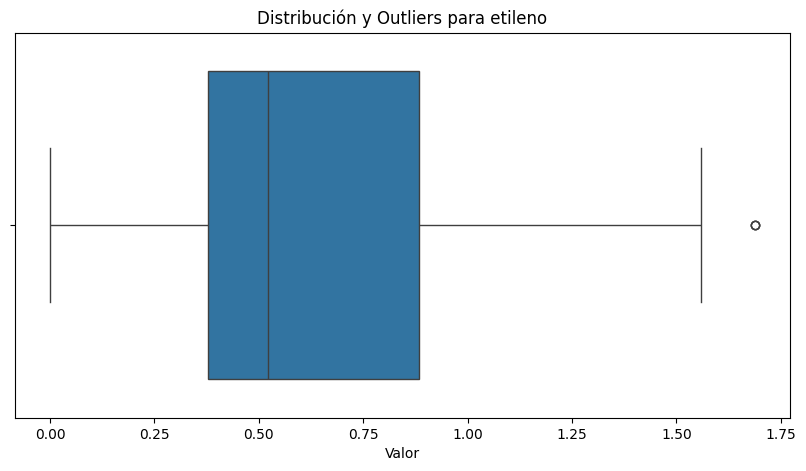

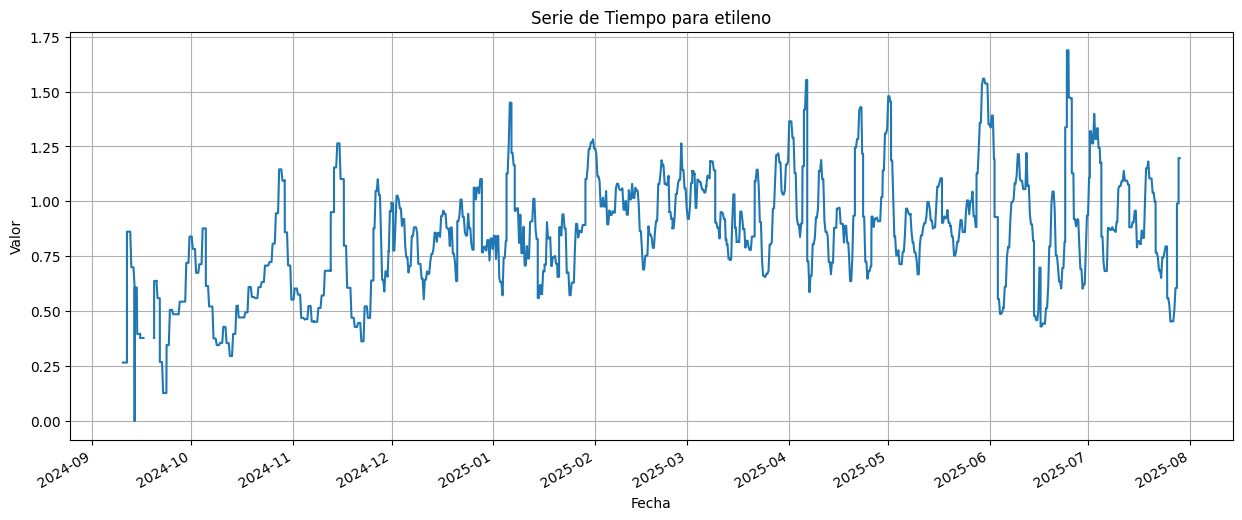


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'gradient_nitrogeno' ###
############################################################
Total de registros: 3569
Valores nulos: 921 (25.81%)

--- Resumen Estadístico de 'value' ---
count    2648.000000
mean        3.100190
std        28.445052
min      -238.900528
25%        -7.795369
50%         5.292731
75%        16.415386
max       178.380844


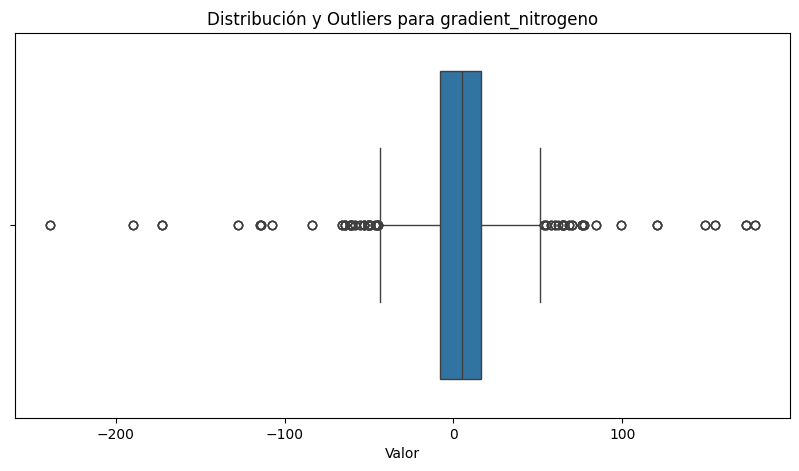

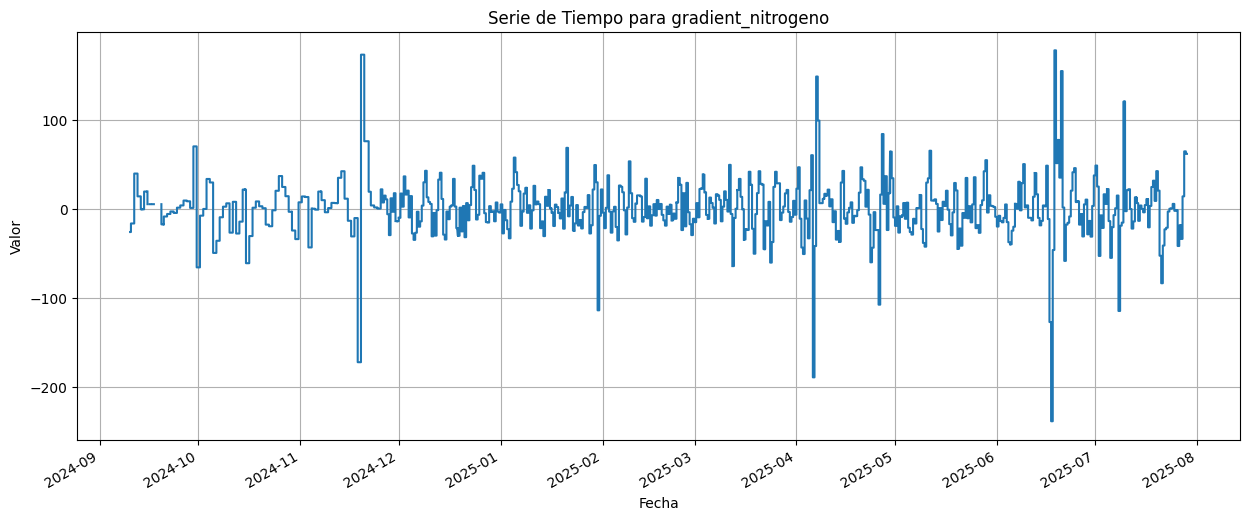


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'temperatura_punto_caliente' ###
############################################################
Total de registros: 18386
Valores nulos: 915 (4.98%)

--- Resumen Estadístico de 'value' ---
count    17471.000000
mean        54.772852
std          9.760798
min          0.000000
25%         46.421556
50%         54.821915
75%         62.646944
max         80.383949


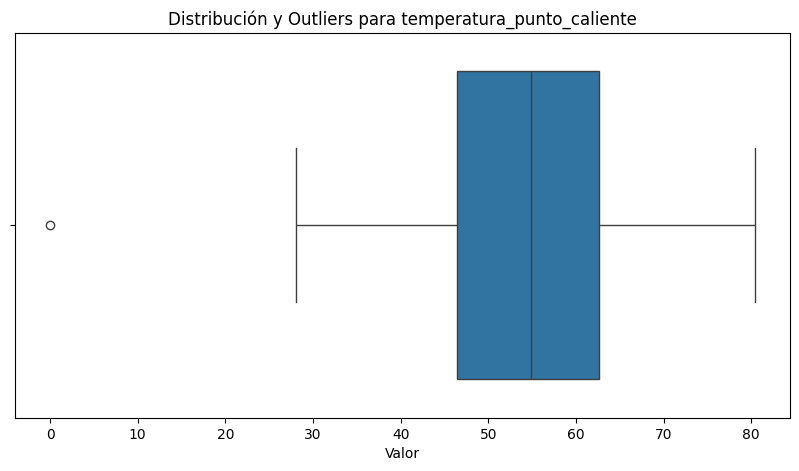

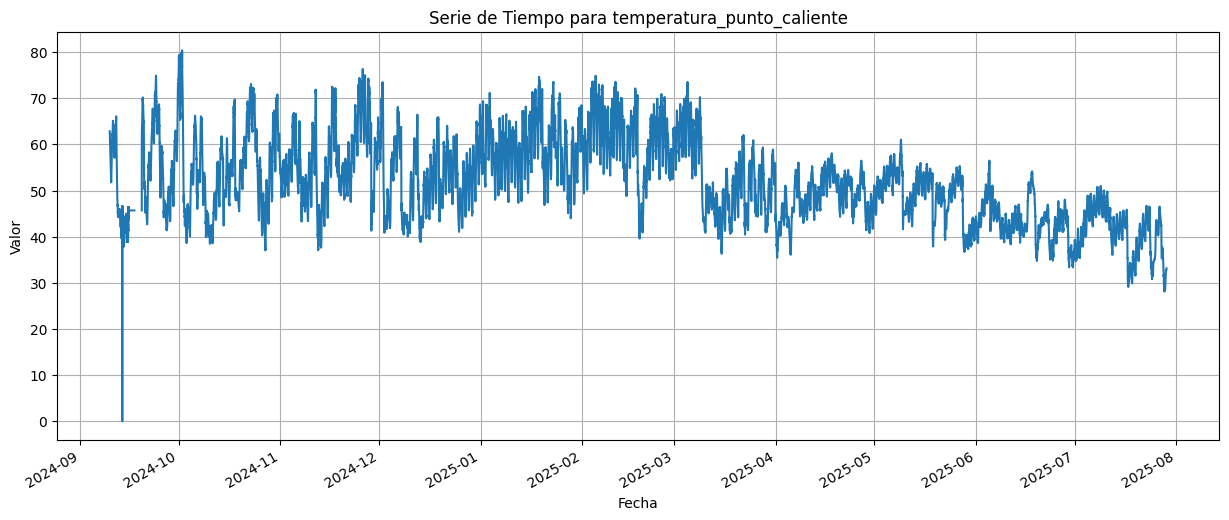


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'flujo_aceite_relay_OLTC' ###
############################################################
Total de registros: 2924
Valores nulos: 2924 (100.00%)

--- Resumen Estadístico de 'value' ---
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN


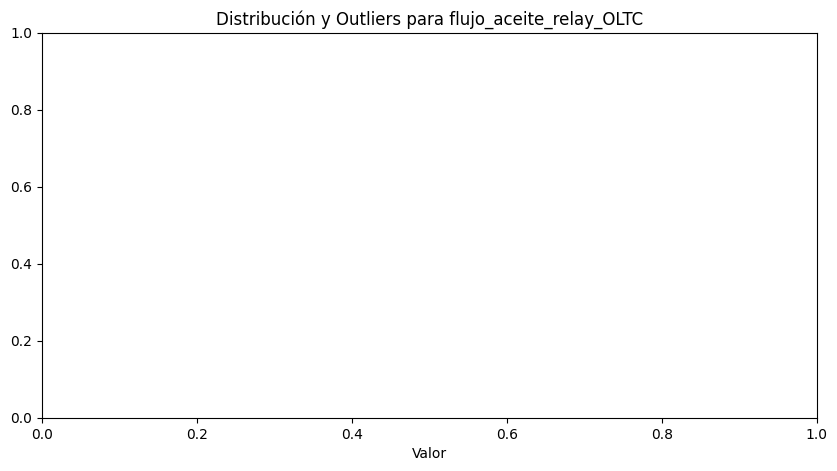

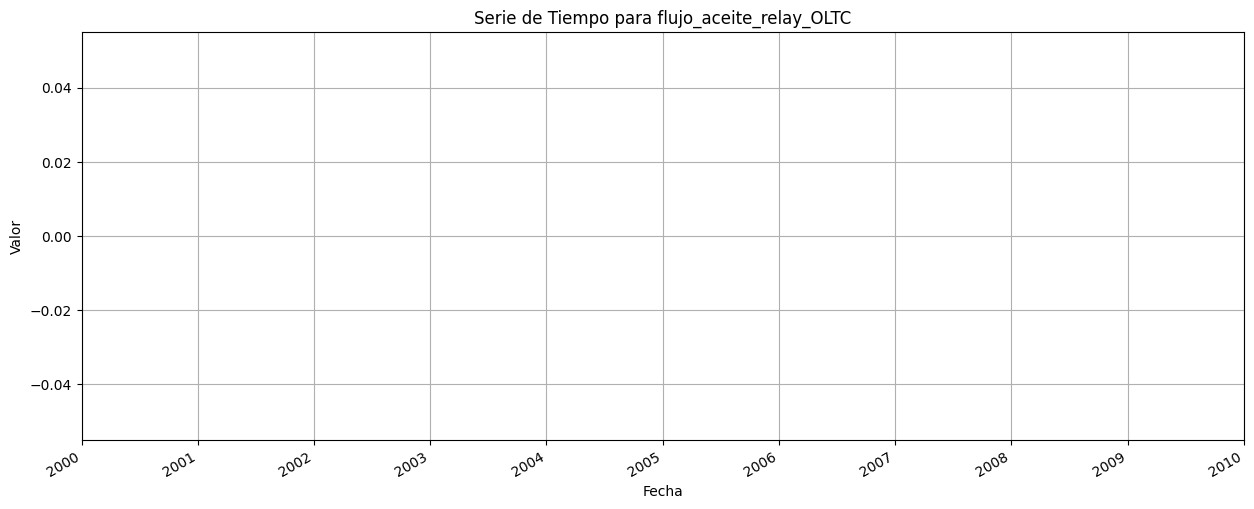


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'motor_OLTC_en_operacion' ###
############################################################
Total de registros: 10536
Valores nulos: 10536 (100.00%)

--- Resumen Estadístico de 'value' ---
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN


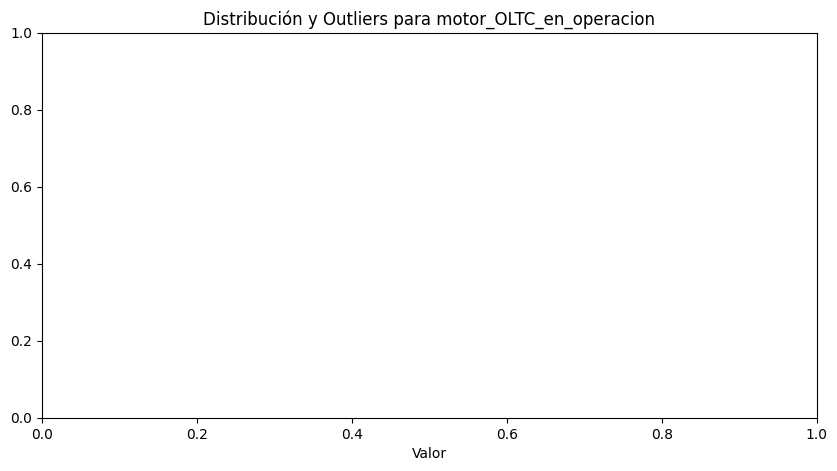

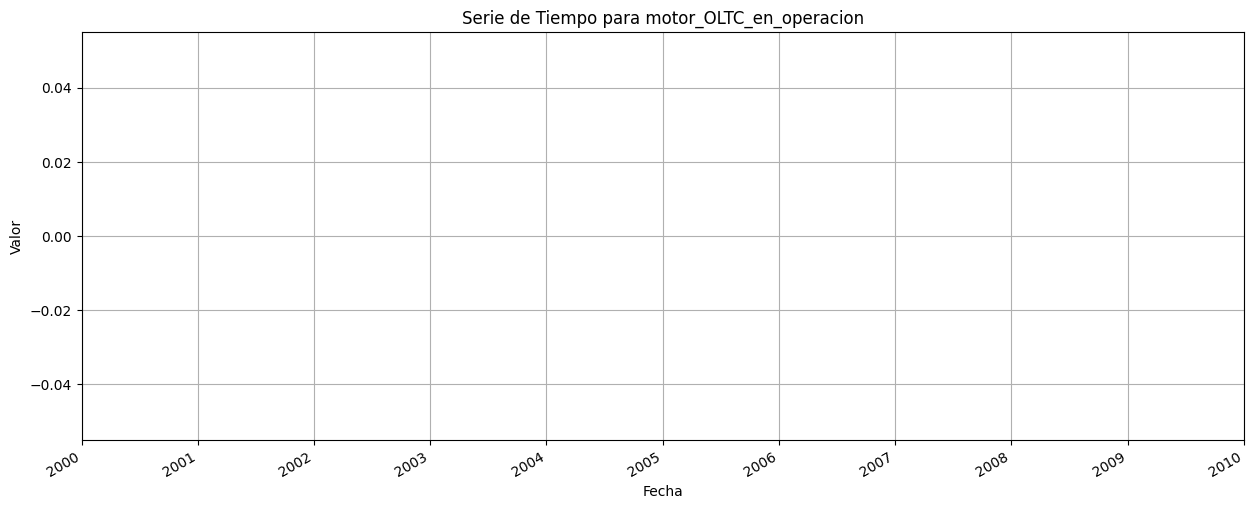


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'verificar_conexion_profibus' ###
############################################################
Total de registros: 2942
Valores nulos: 2942 (100.00%)

--- Resumen Estadístico de 'value' ---
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN


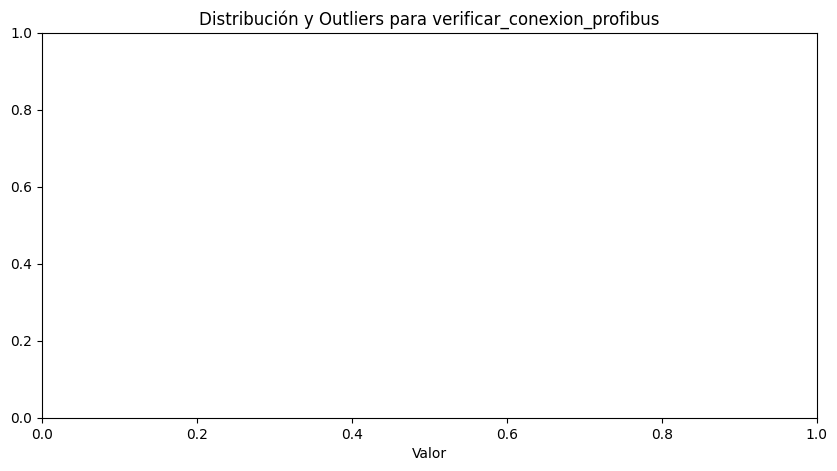

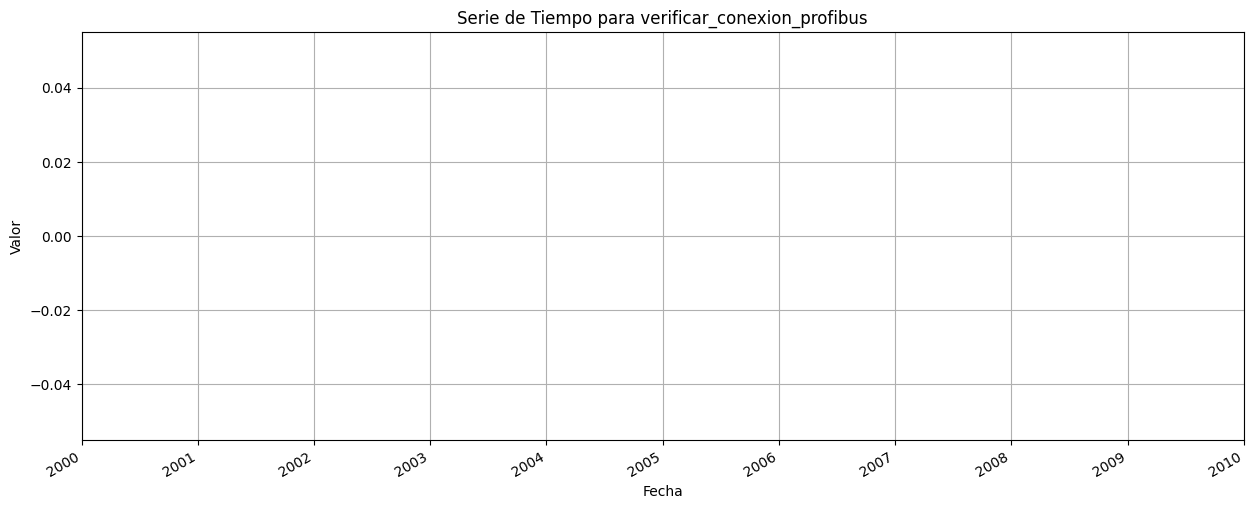


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'motor_cortacircuito_OLTC_ON' ###
############################################################
Total de registros: 2942
Valores nulos: 2942 (100.00%)

--- Resumen Estadístico de 'value' ---
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN


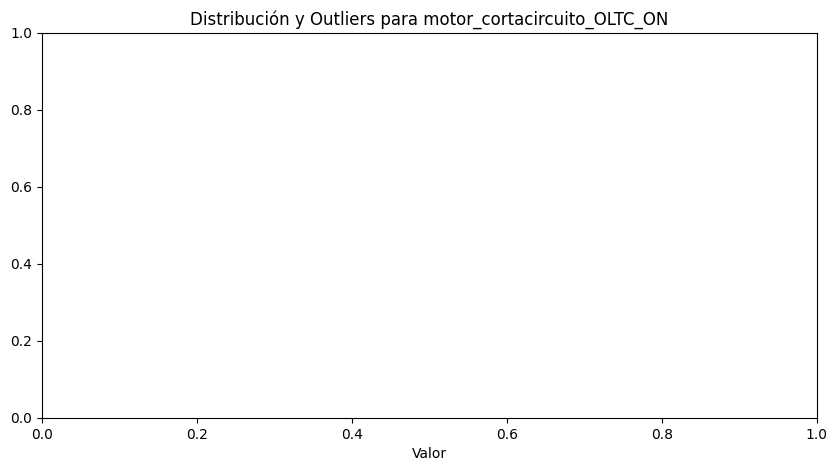

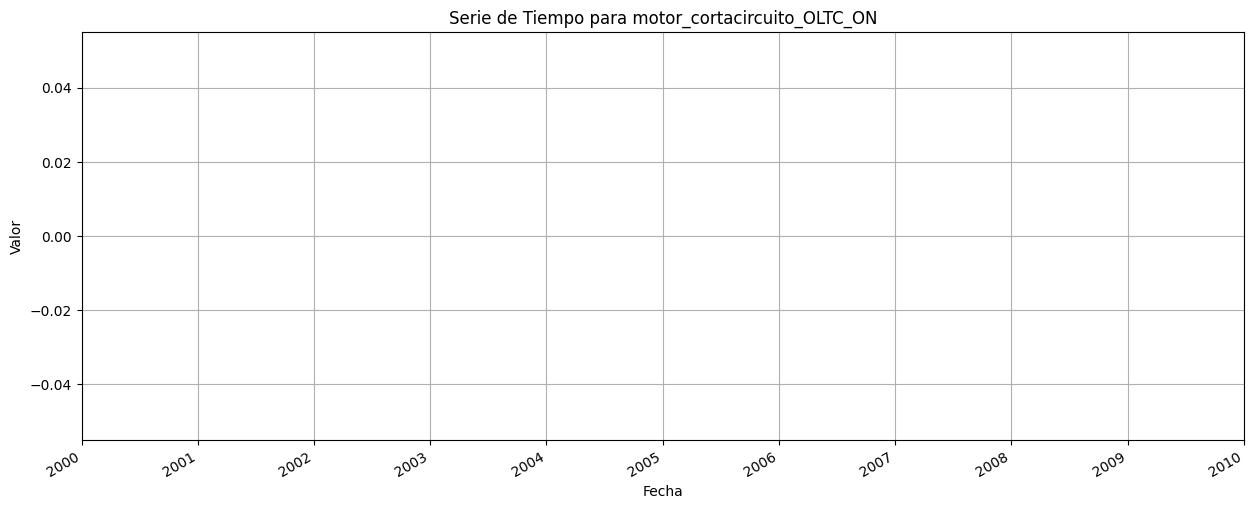


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'ventilador_5_mcb' ###
############################################################
Total de registros: 2791
Valores nulos: 2791 (100.00%)

--- Resumen Estadístico de 'value' ---
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN


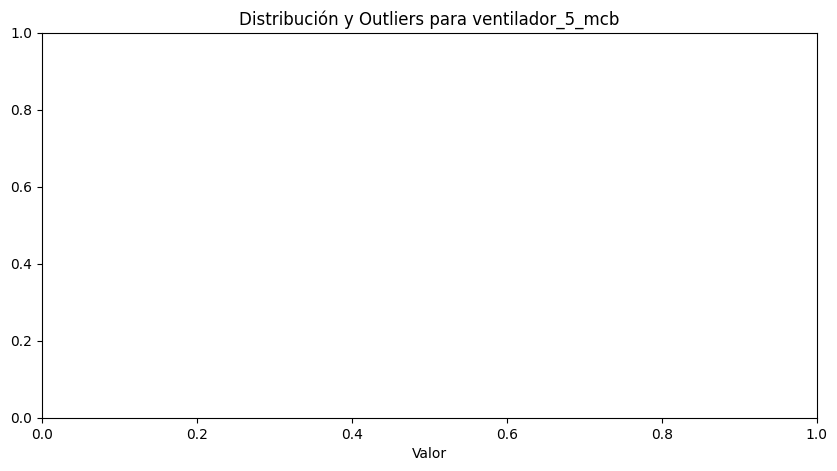

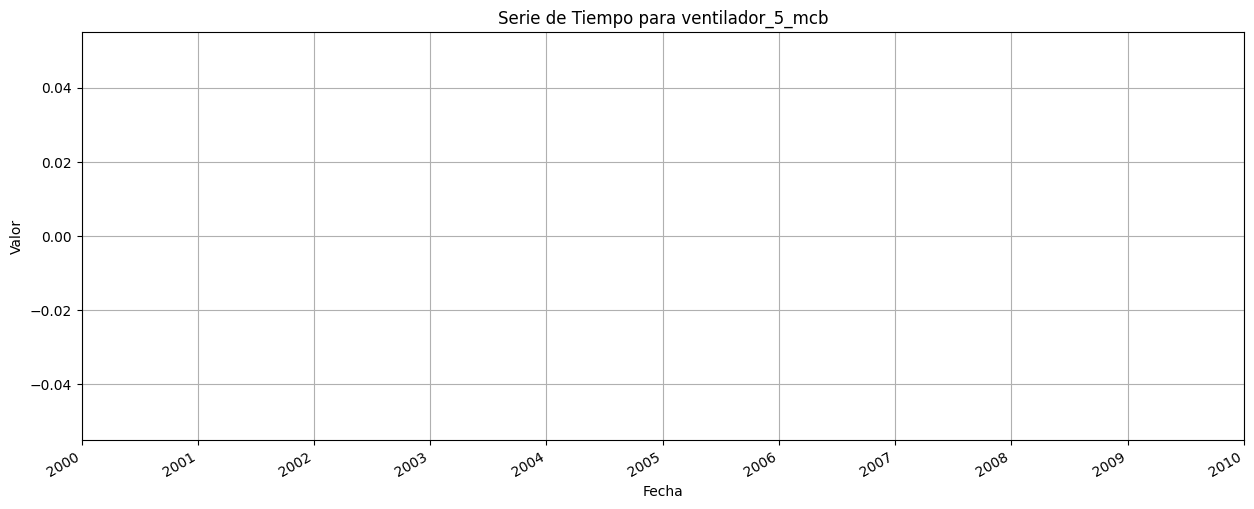


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'promedio_voltaje_fase_1' ###
############################################################
Total de registros: 18469
Valores nulos: 8 (0.04%)

--- Resumen Estadístico de 'value' ---
count    18461.000000
mean       124.681584
std          3.360004
min          0.000000
25%        122.916914
50%        124.893796
75%        126.217625
max        134.002210


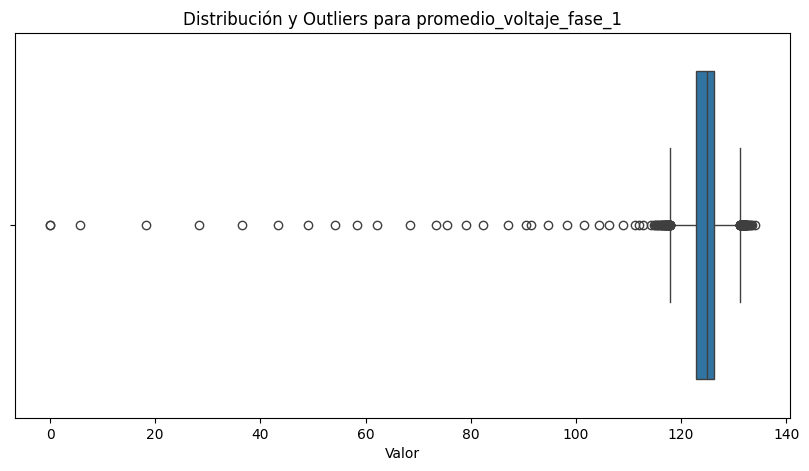

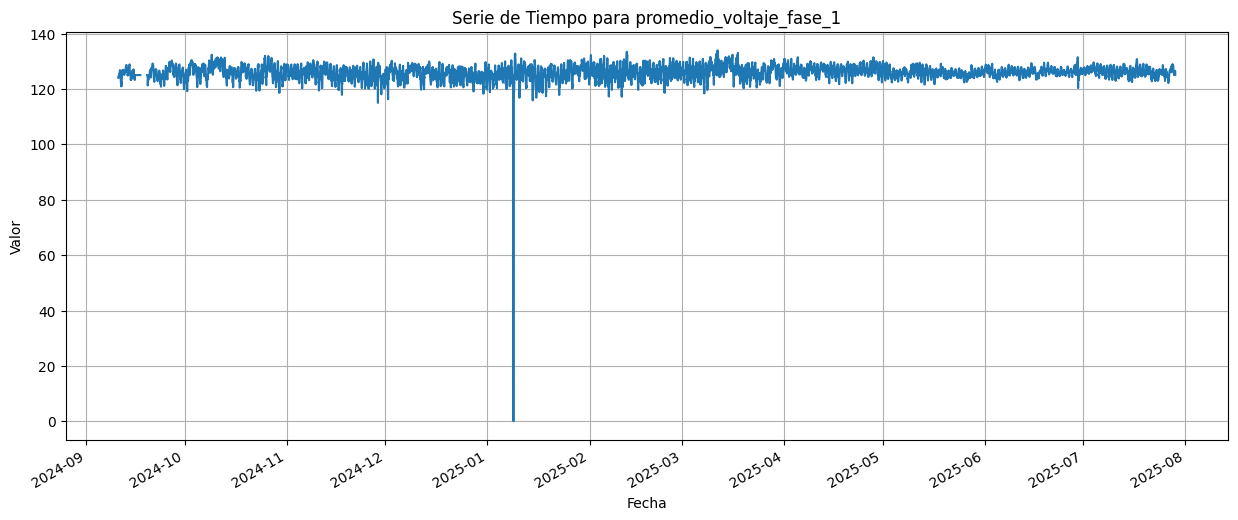


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'breakdown_voltage' ###
############################################################
Total de registros: 2929
Valores nulos: 1007 (34.38%)

--- Resumen Estadístico de 'value' ---
count    1922.000000
mean       77.959745
std         1.779179
min         0.000000
25%        78.000328
50%        78.000328
75%        78.000328
max        78.000328


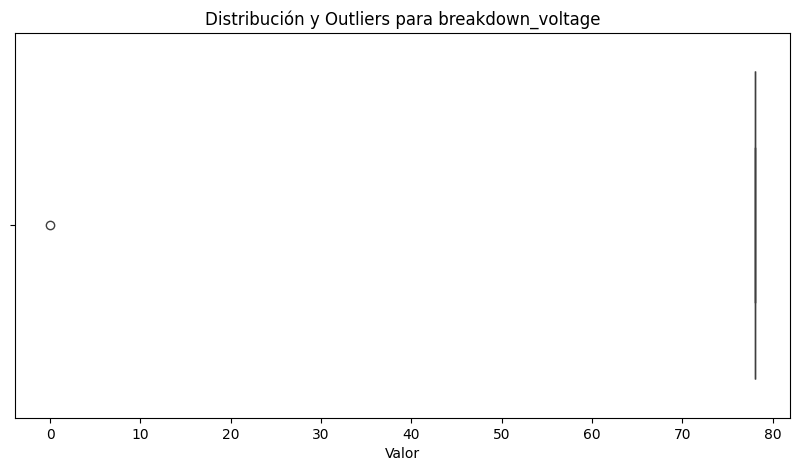

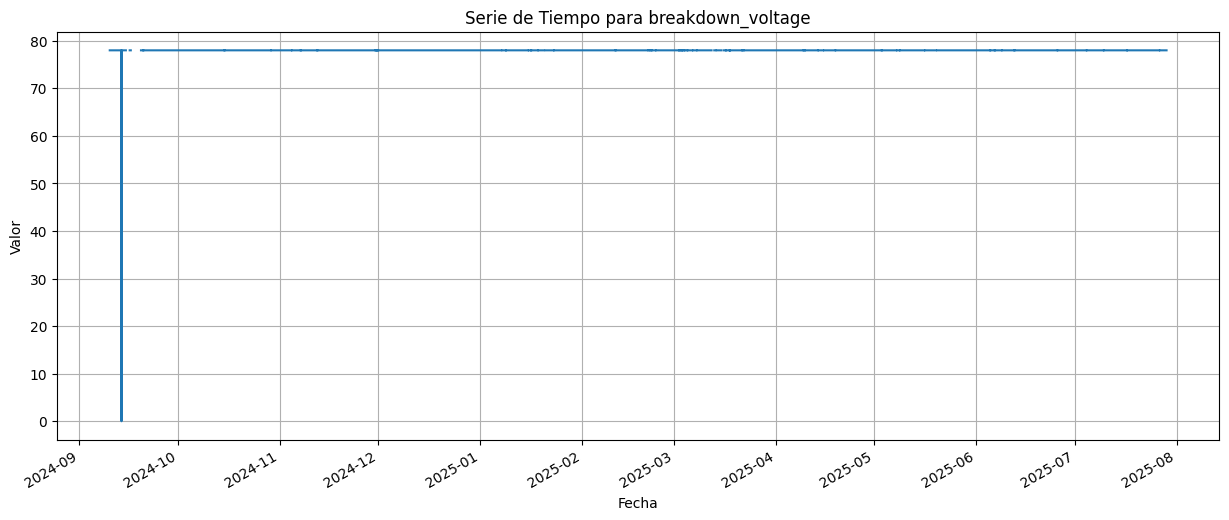


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'ventilador_6_mcb' ###
############################################################
Total de registros: 2781
Valores nulos: 2781 (100.00%)

--- Resumen Estadístico de 'value' ---
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN


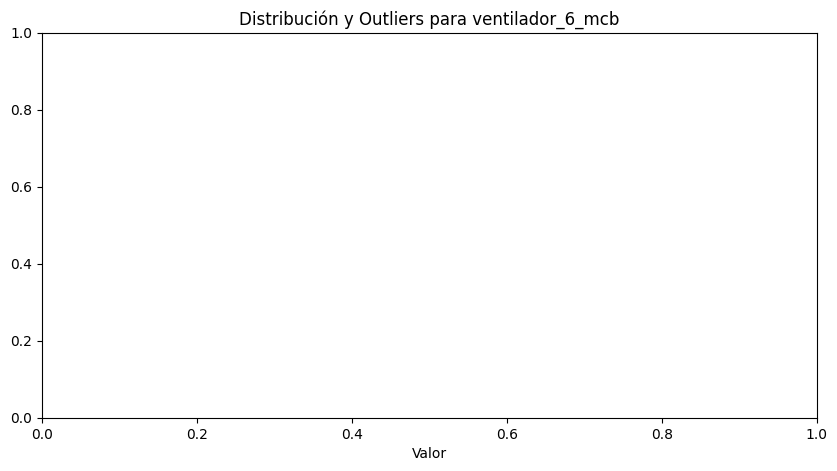

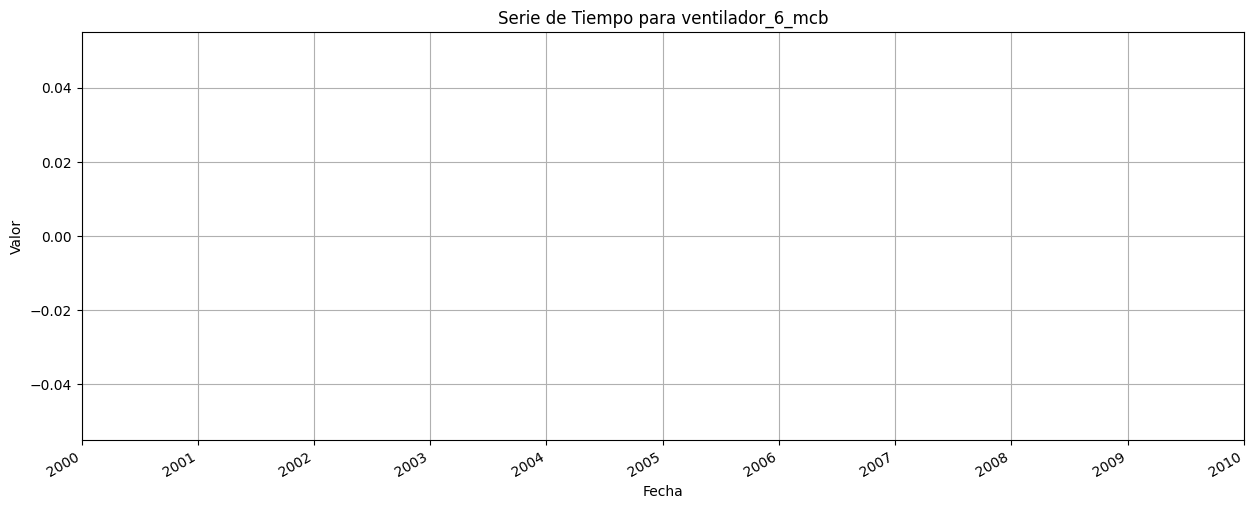


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'switch_S22_remote' ###
############################################################
Total de registros: 2758
Valores nulos: 2758 (100.00%)

--- Resumen Estadístico de 'value' ---
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN


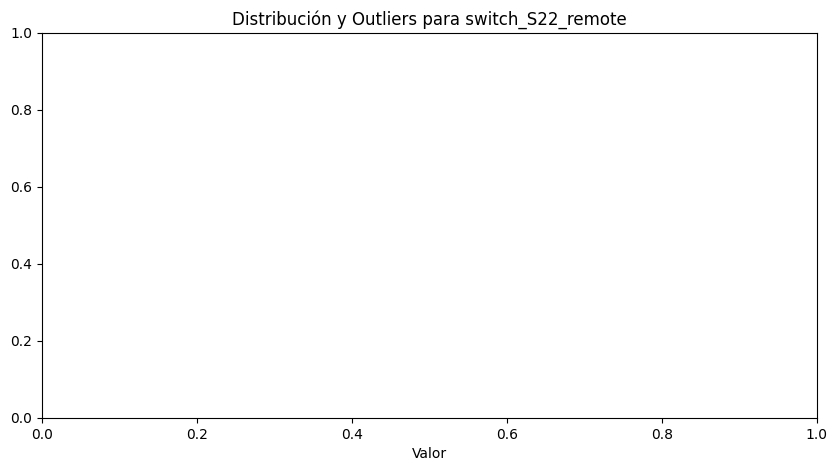

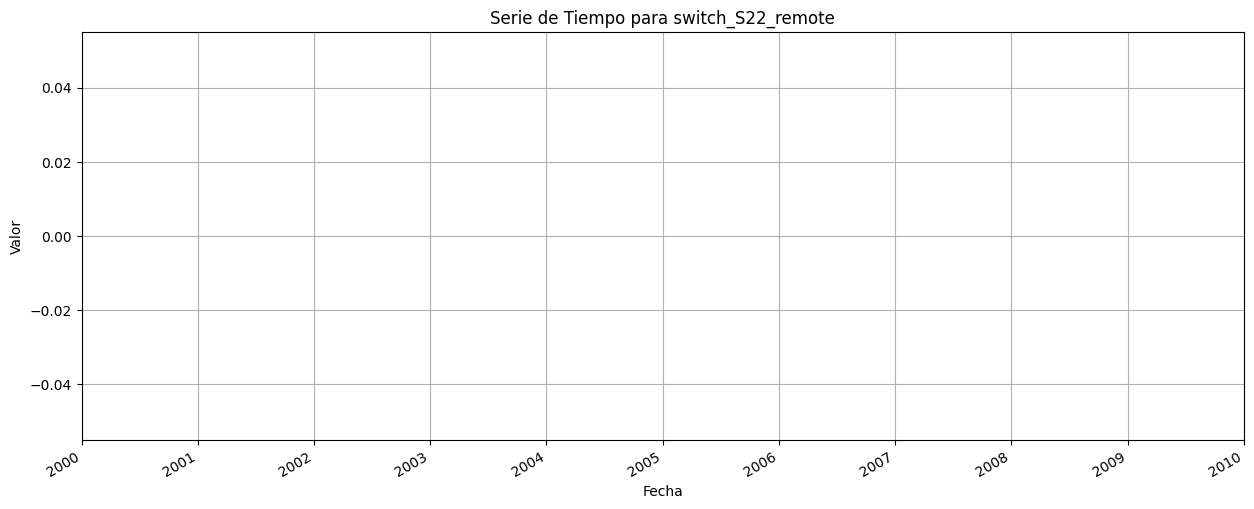


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'voltaje' ###
############################################################
Total de registros: 3415996
Valores nulos: 889 (0.03%)

--- Resumen Estadístico de 'value' ---
count    3.415107e+06
mean     1.301600e+02
std      2.662573e+00
min      0.000000e+00
25%      1.284985e+02
50%      1.302903e+02
75%      1.319615e+02
max      1.469271e+02


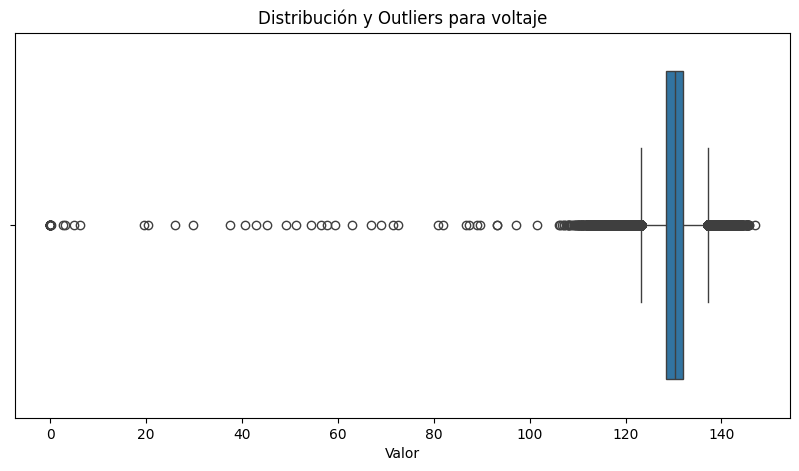

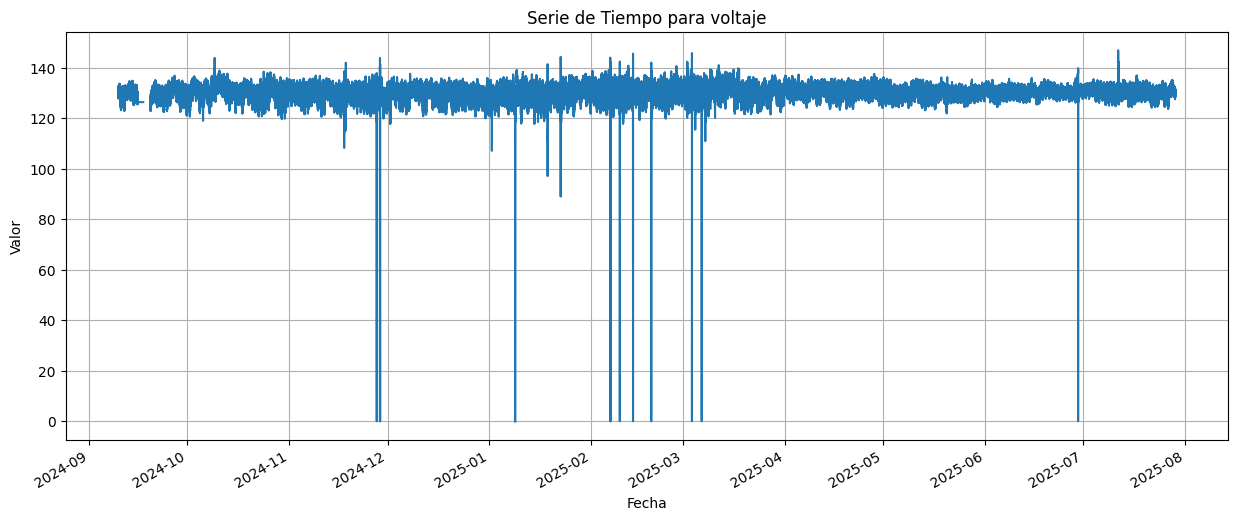


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'diferencia_top_oil_ambiente_temp' ###
############################################################
Total de registros: 30147
Valores nulos: 1010 (3.35%)

--- Resumen Estadístico de 'value' ---
count    29137.000000
mean        21.534151
std          3.272919
min         12.700001
25%         19.200001
50%         21.299999
75%         23.799999
max         34.799999


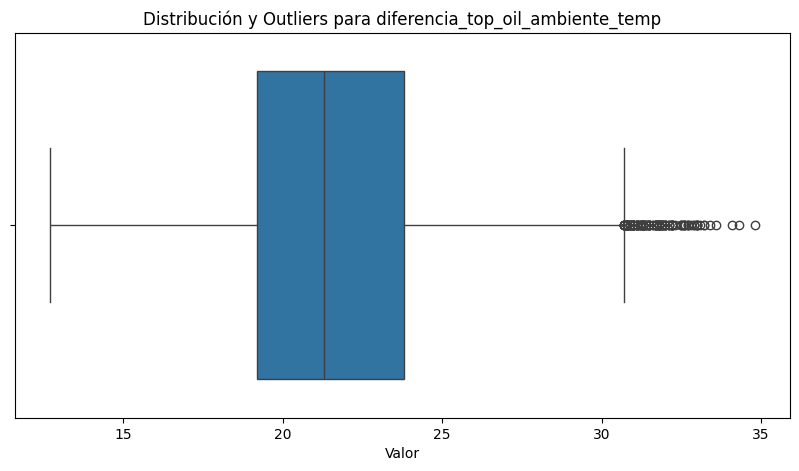

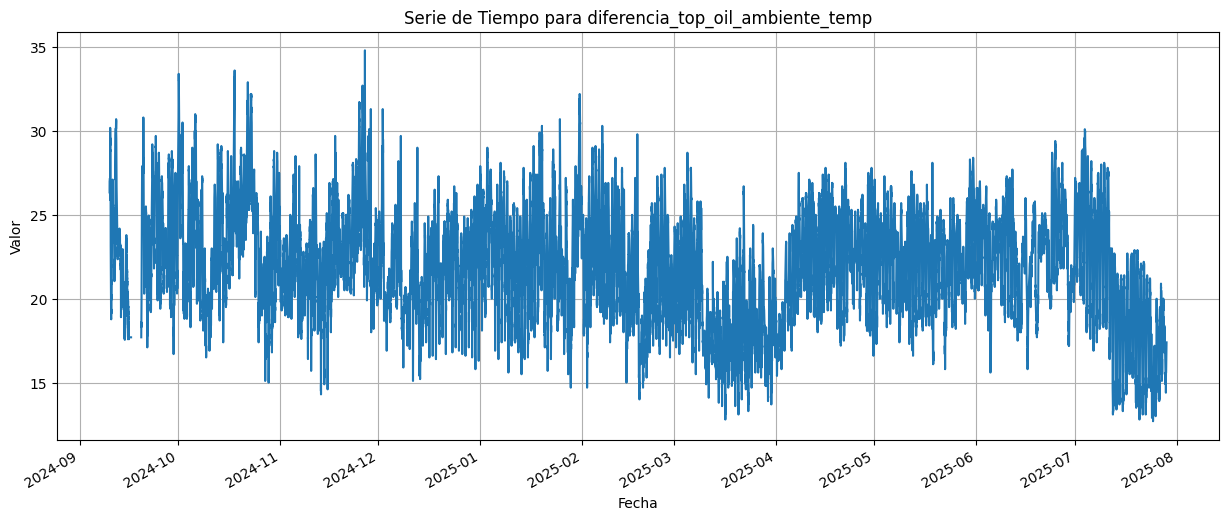


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'hidrogeno' ###
############################################################
Total de registros: 3134
Valores nulos: 955 (30.47%)

--- Resumen Estadístico de 'value' ---
count    2179.000000
mean        7.747302
std         0.694023
min         0.000000
25%         7.237482
50%         7.444743
75%         8.276860
max         9.457321


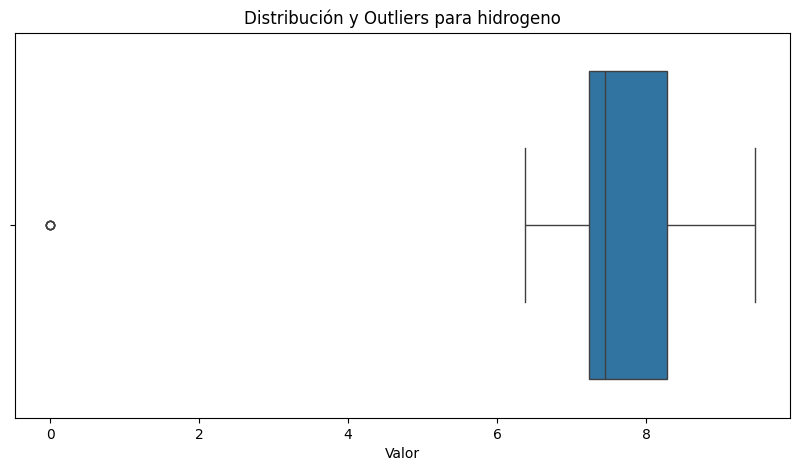

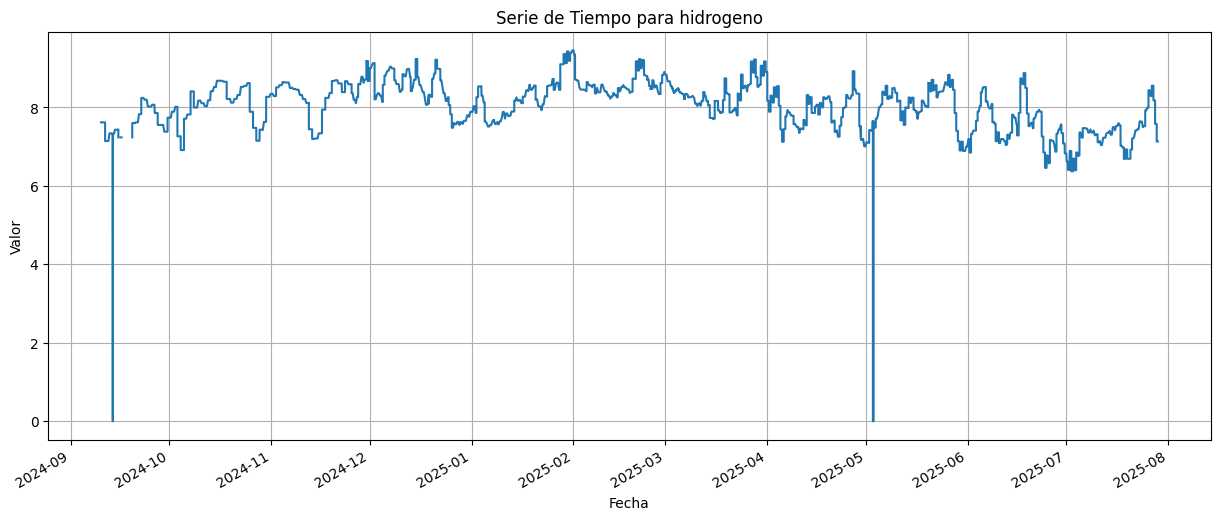


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'min_potencia_fase_2' ###
############################################################
Total de registros: 5585
Valores nulos: 46 (0.82%)

--- Resumen Estadístico de 'value' ---
count    5539.000000
mean       29.108993
std         8.059654
min         0.000000
25%        24.203812
50%        28.053982
75%        33.941769
max        55.735321


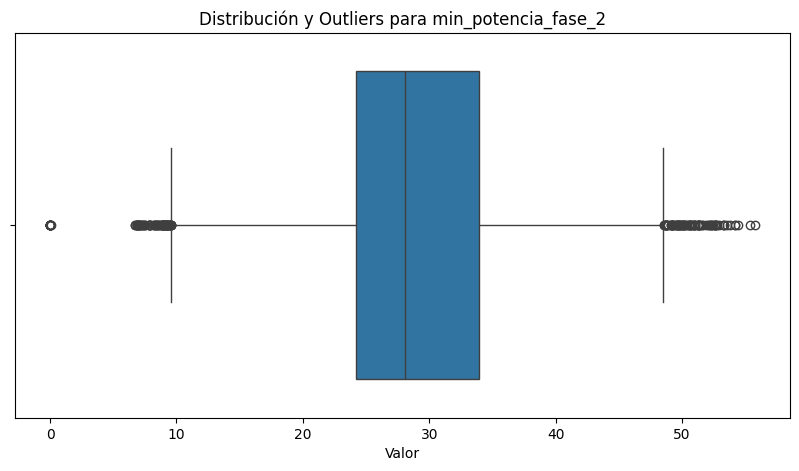

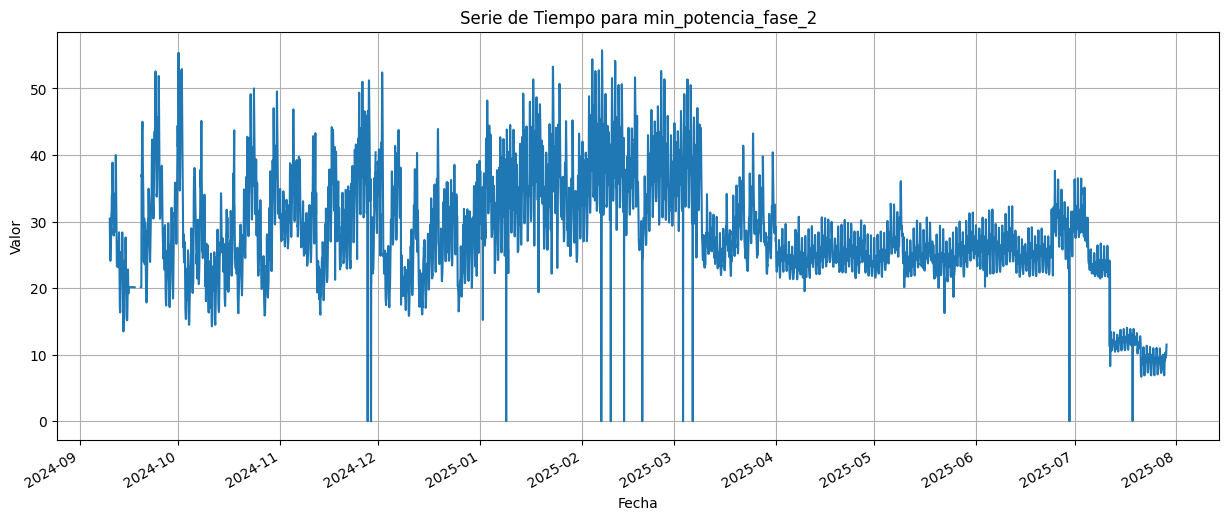


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'temperatura_ambiente' ###
############################################################
Total de registros: 24689
Valores nulos: 1010 (4.09%)

--- Resumen Estadístico de 'value' ---
count    23679.000000
mean        26.935795
std          6.828775
min          0.000000
25%         22.500000
50%         27.400000
75%         32.000000
max         41.000000


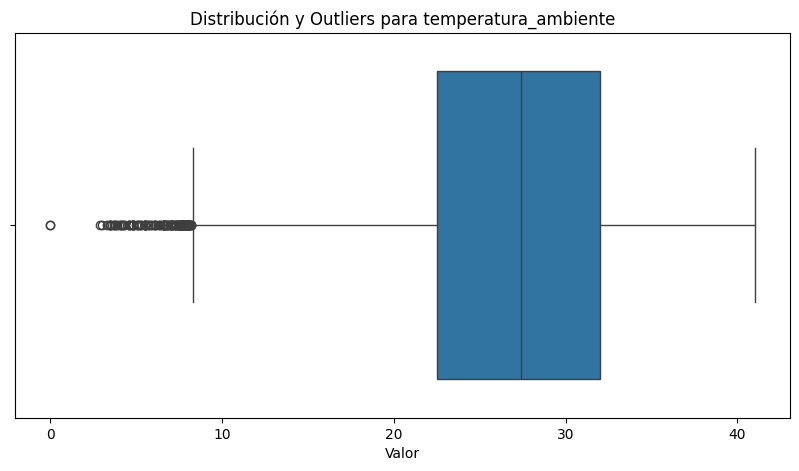

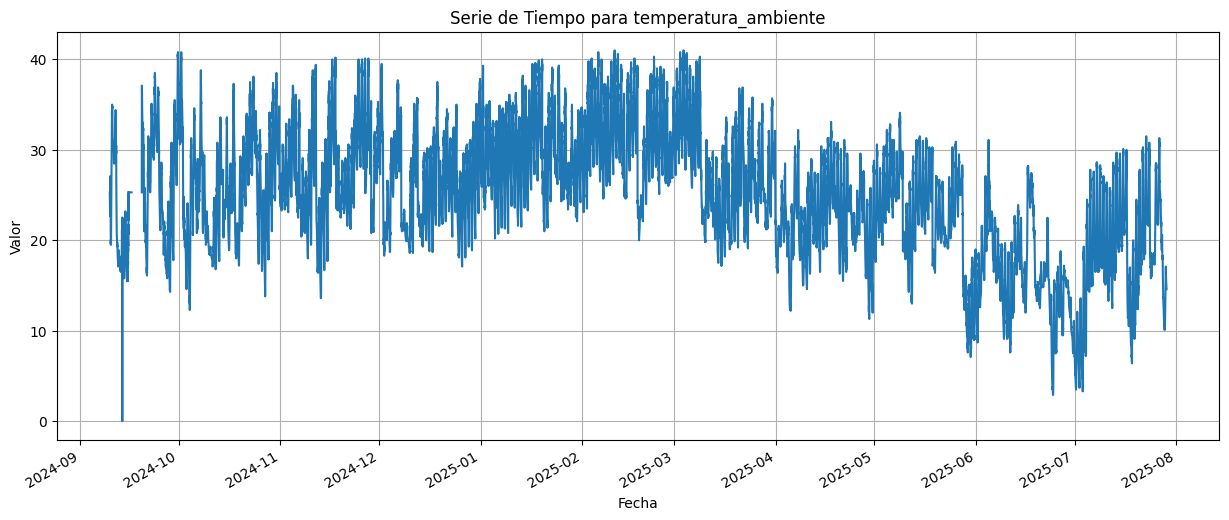


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'nivel_aceite_OLTC_max' ###
############################################################
Total de registros: 2928
Valores nulos: 2928 (100.00%)

--- Resumen Estadístico de 'value' ---
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN


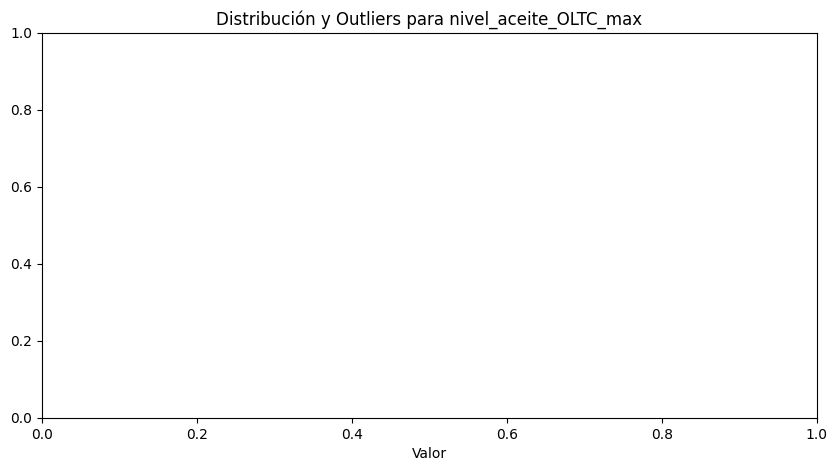

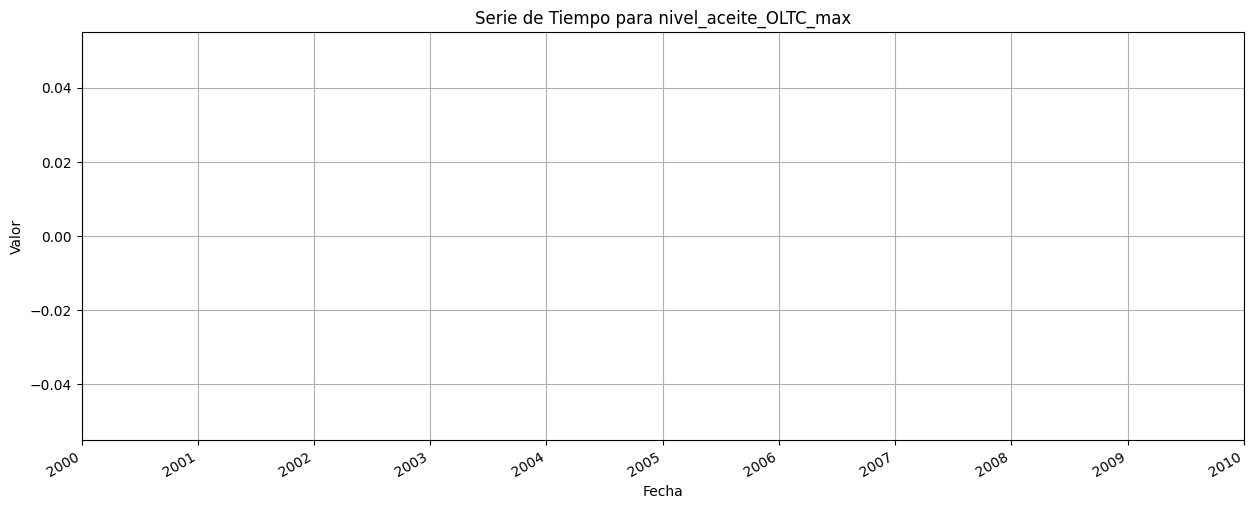


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'monoxido_carbono' ###
############################################################
Total de registros: 3666
Valores nulos: 1012 (27.61%)

--- Resumen Estadístico de 'value' ---
count    2654.000000
mean      518.999518
std        78.069820
min         0.000000
25%       433.051514
50%       514.333496
75%       600.352051
max       630.875793


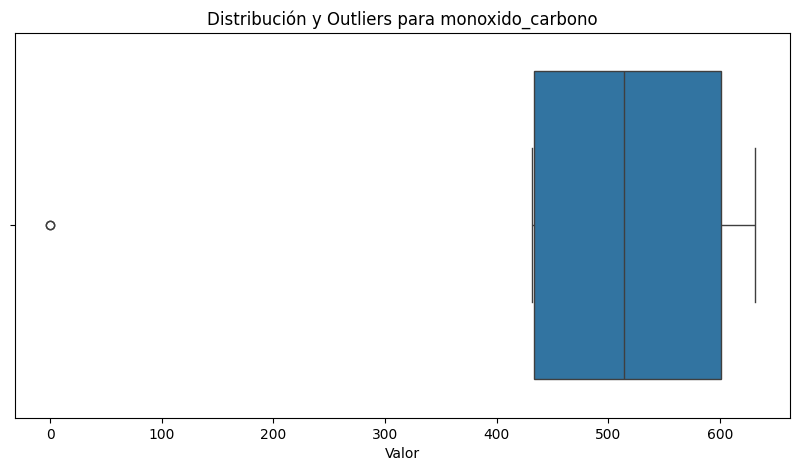

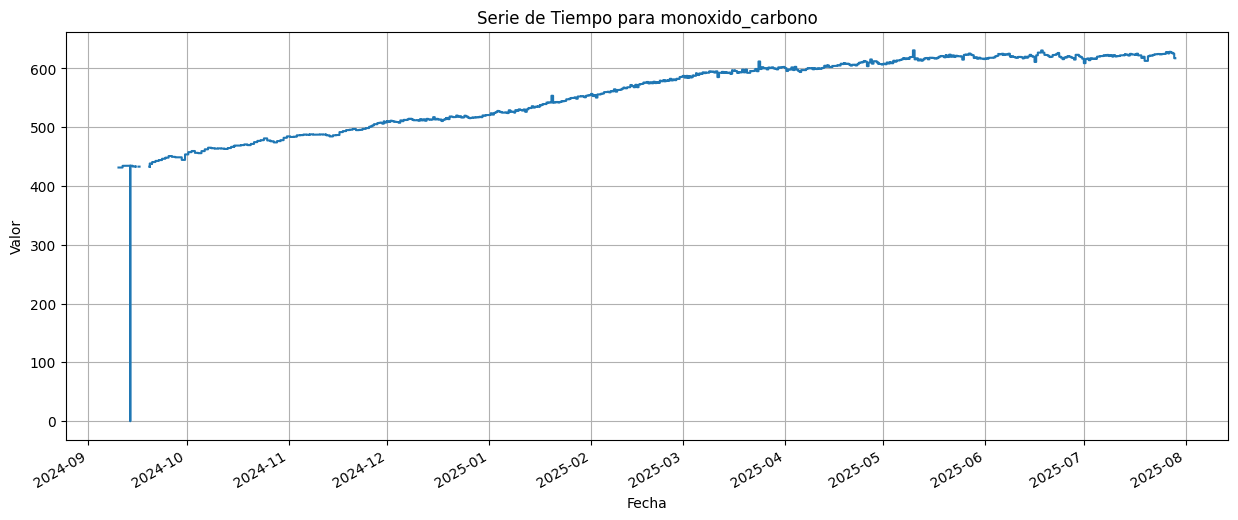


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'voltaje_fase_1' ###
############################################################
Total de registros: 3341452
Valores nulos: 889 (0.03%)

--- Resumen Estadístico de 'value' ---
count    3.340563e+06
mean     1.258348e+02
std      2.590450e+00
min      0.000000e+00
25%      1.242754e+02
50%      1.259644e+02
75%      1.275744e+02
max      1.451518e+02


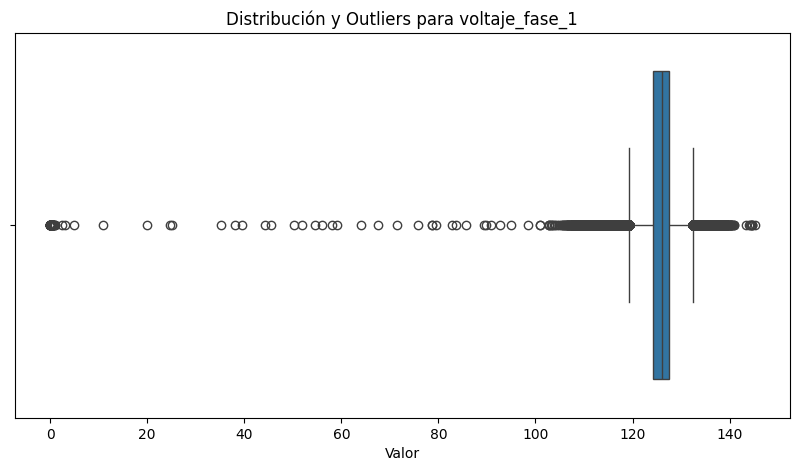

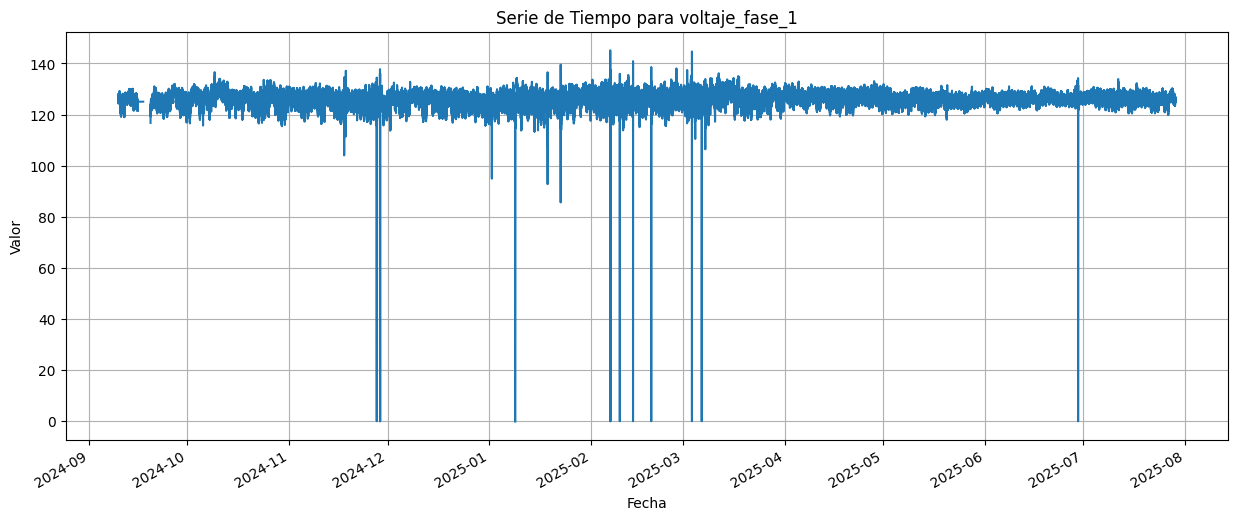


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'cambio_capacitancia_fase_2' ###
############################################################
Total de registros: 13519
Valores nulos: 1010 (7.47%)

--- Resumen Estadístico de 'value' ---
count    12509.000000
mean         0.001311
std          0.151380
min         -0.712839
25%         -0.090164
50%         -0.004064
75%          0.092475
max          0.650773


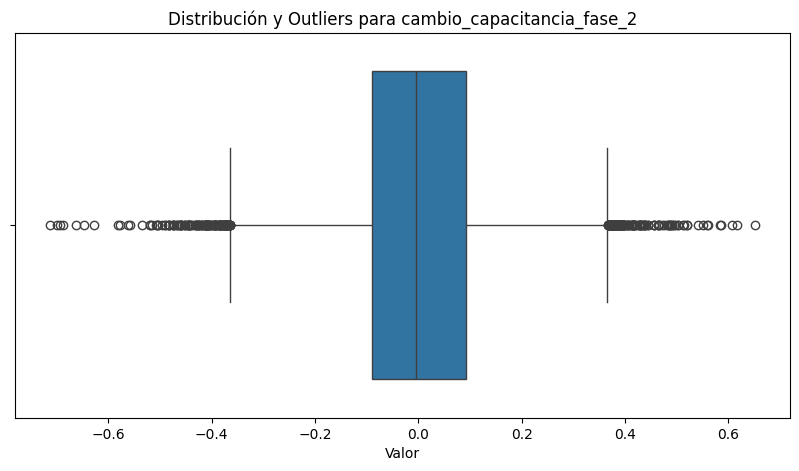

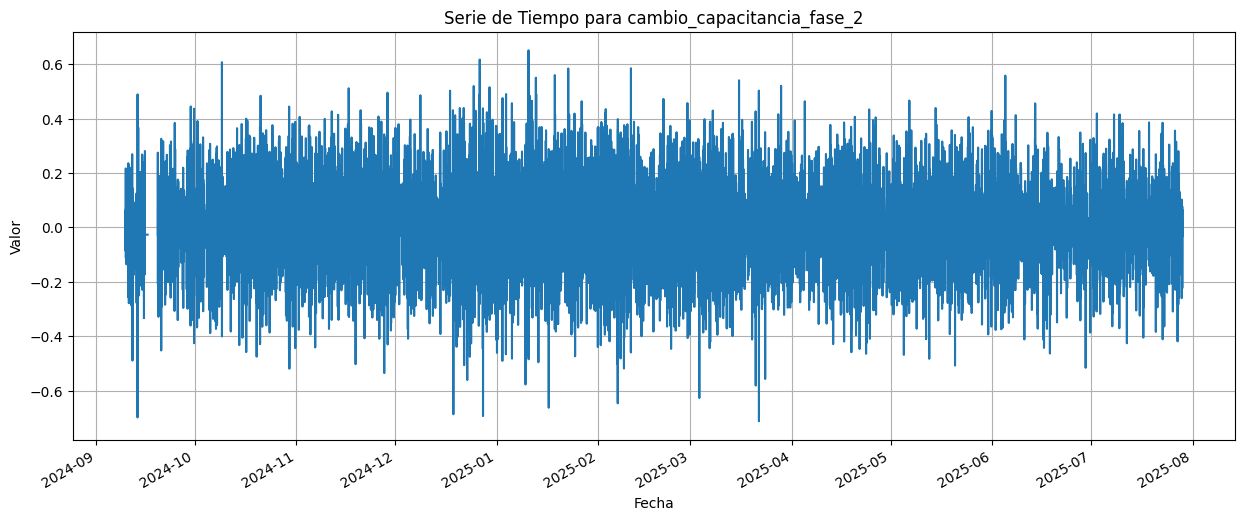


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'humedad_papel_aislante' ###
############################################################
Total de registros: 5698
Valores nulos: 907 (15.92%)

--- Resumen Estadístico de 'value' ---
count    4791.000000
mean        0.823369
std         0.224435
min         0.000000
25%         0.649173
50%         0.823313
75%         0.980051
max         1.640059


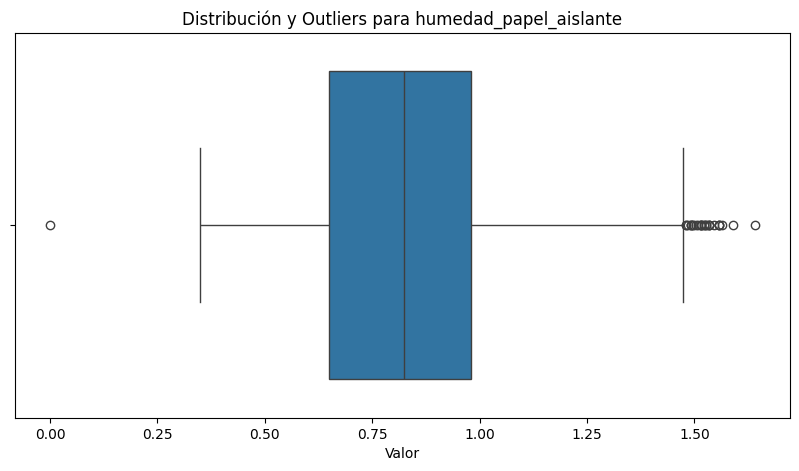

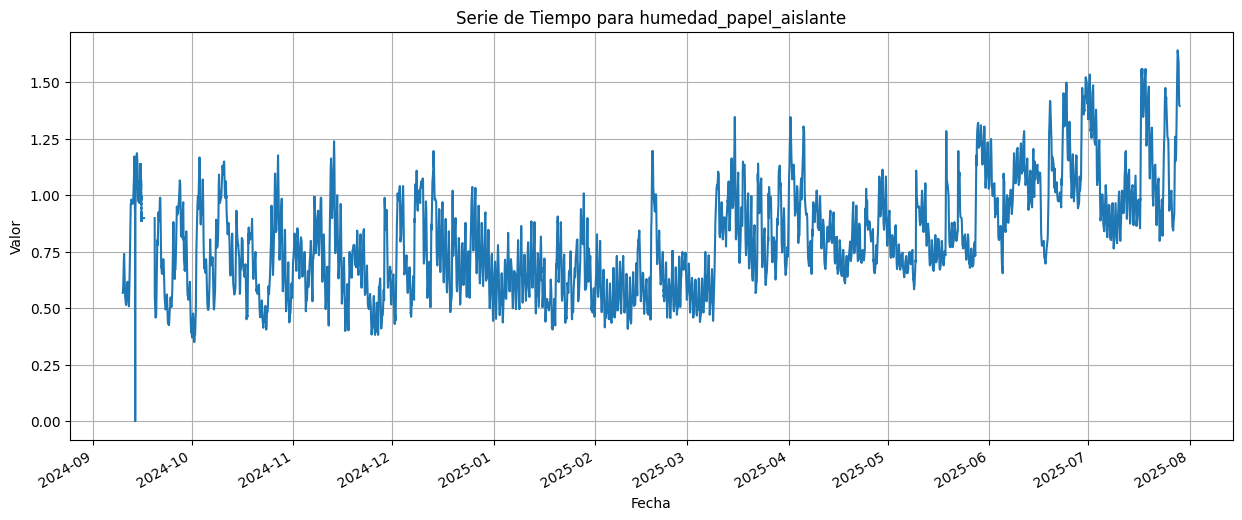


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'oxígeno' ###
############################################################
Total de registros: 3703
Valores nulos: 1012 (27.33%)

--- Resumen Estadístico de 'value' ---
count    2691.000000
mean     5396.410049
std       606.989303
min         0.000000
25%      4785.274658
50%      5378.025879
75%      6077.585938
max      6150.091309


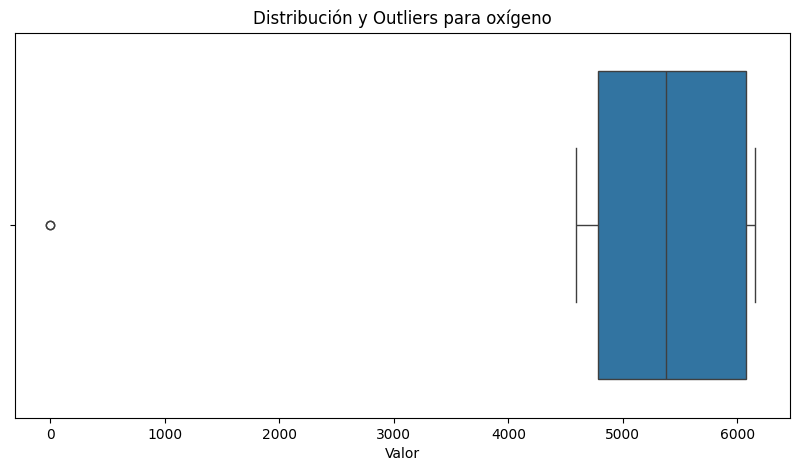

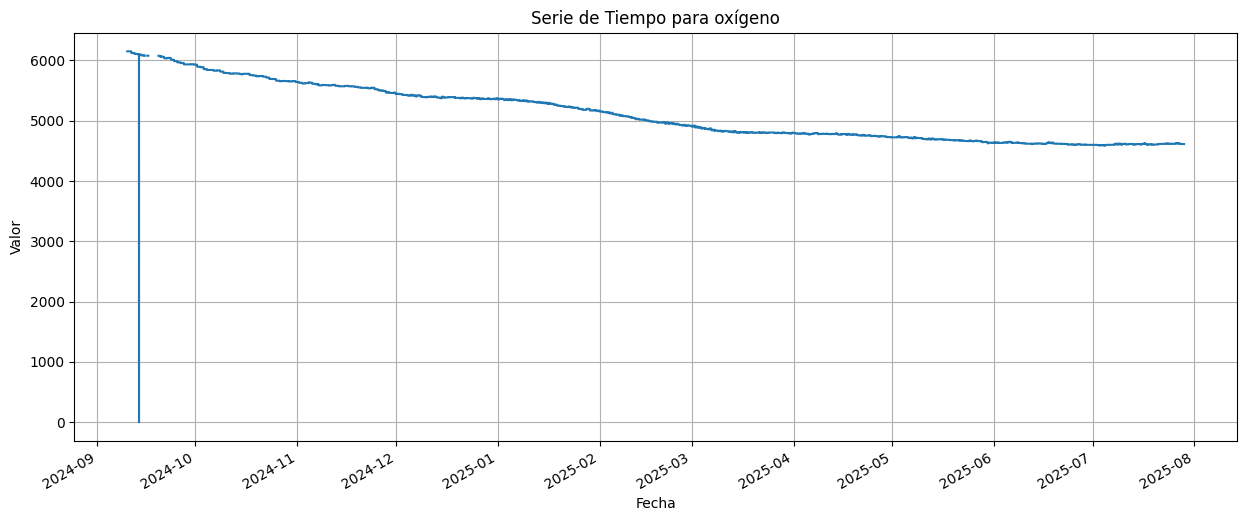


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'nivel_aceite_tanque_principal_max' ###
############################################################
Total de registros: 2924
Valores nulos: 2924 (100.00%)

--- Resumen Estadístico de 'value' ---
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN


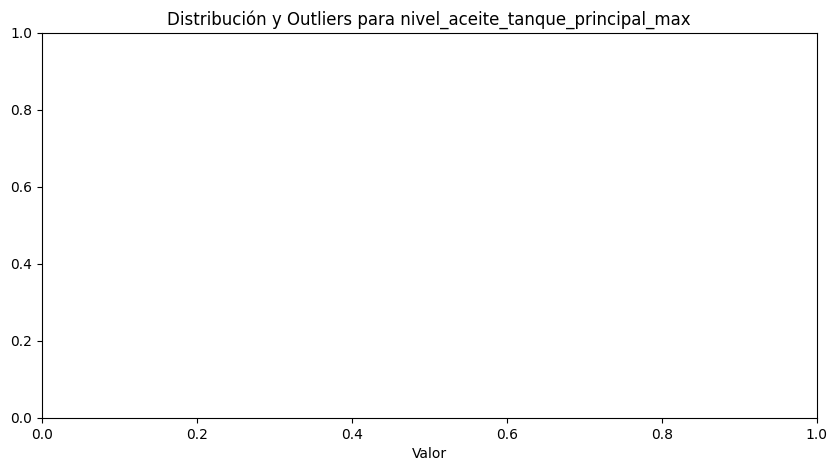

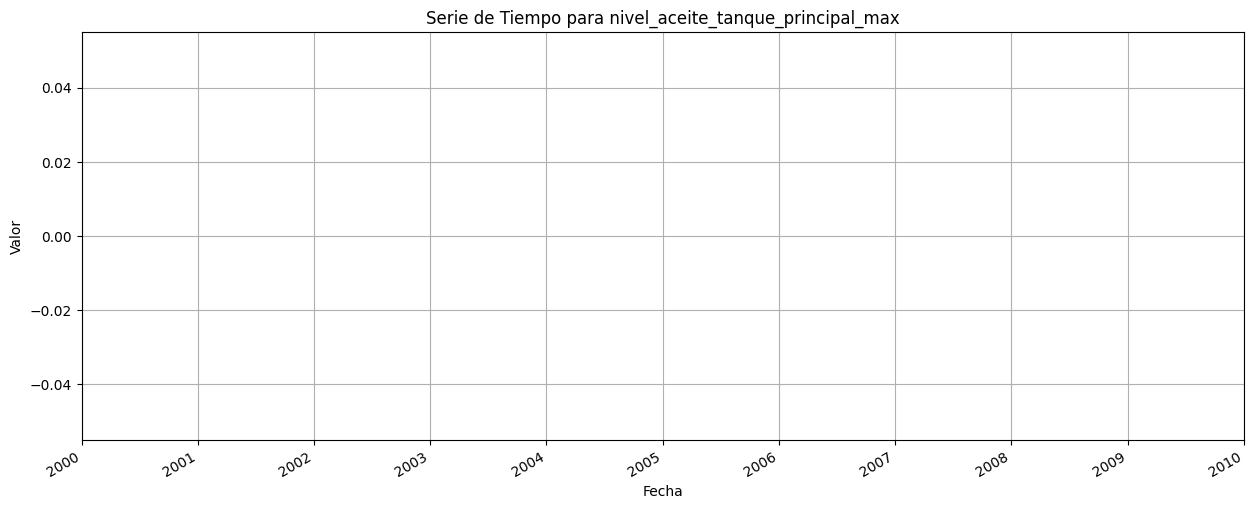


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'tdcg' ###
############################################################
Total de registros: 3479
Valores nulos: 916 (26.33%)

--- Resumen Estadístico de 'value' ---
count    2563.000000
mean      541.199820
std        80.079018
min         0.000000
25%       449.845795
50%       537.552612
75%       623.705566
max       653.122498


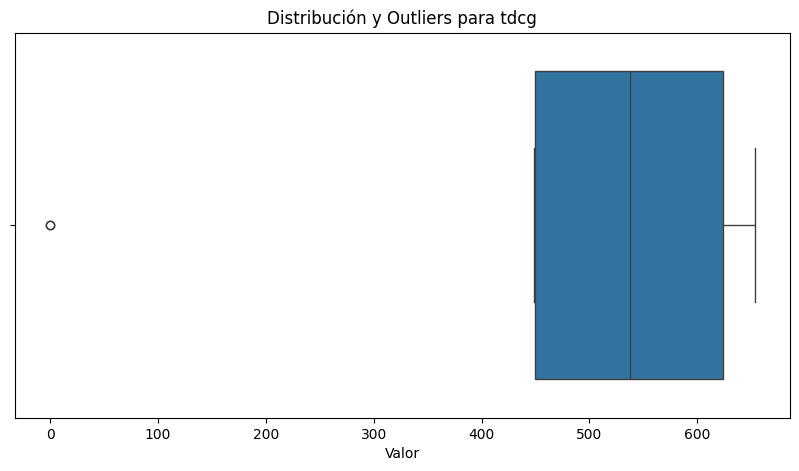

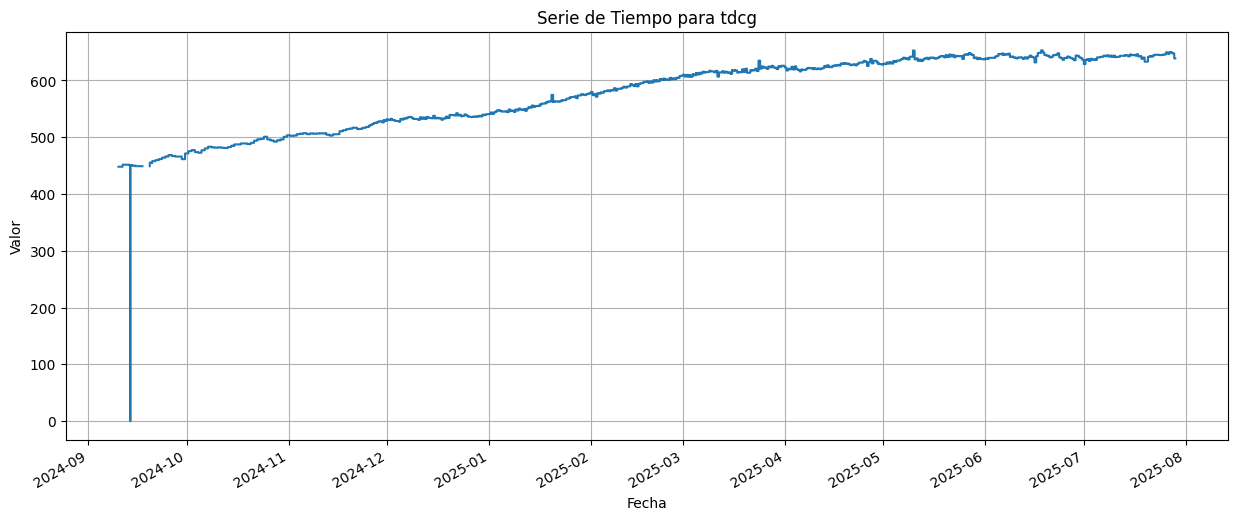


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'diferencial_top_oil_ambiente_temp' ###
############################################################
Total de registros: 3552
Valores nulos: 3552 (100.00%)

--- Resumen Estadístico de 'value' ---
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN


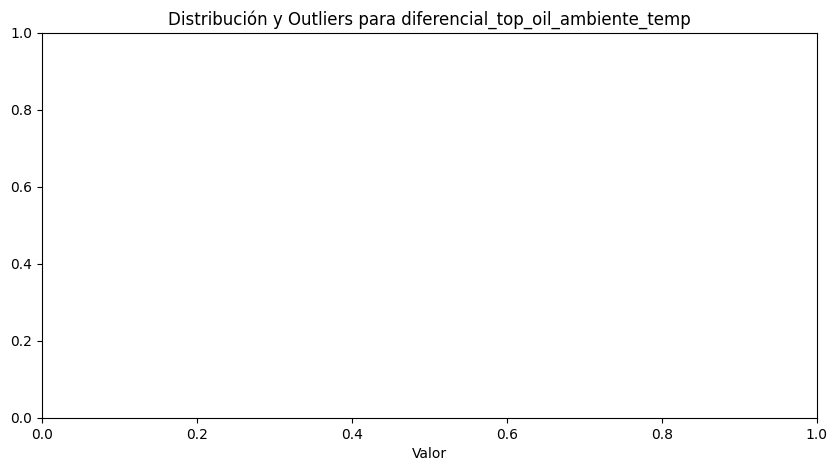

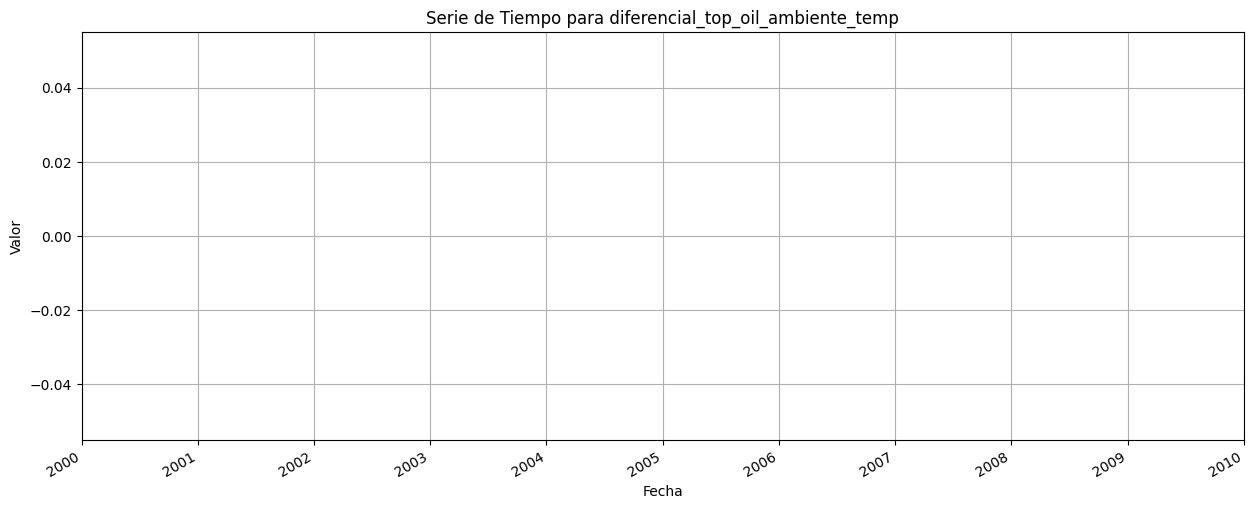


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'nitrógeno' ###
############################################################
Total de registros: 3688
Valores nulos: 995 (26.98%)

--- Resumen Estadístico de 'value' ---
count     2693.000000
mean     25329.452842
std       1451.511795
min          0.000000
25%      24481.845703
50%      24696.527344
75%      26187.343750
max      29279.888672


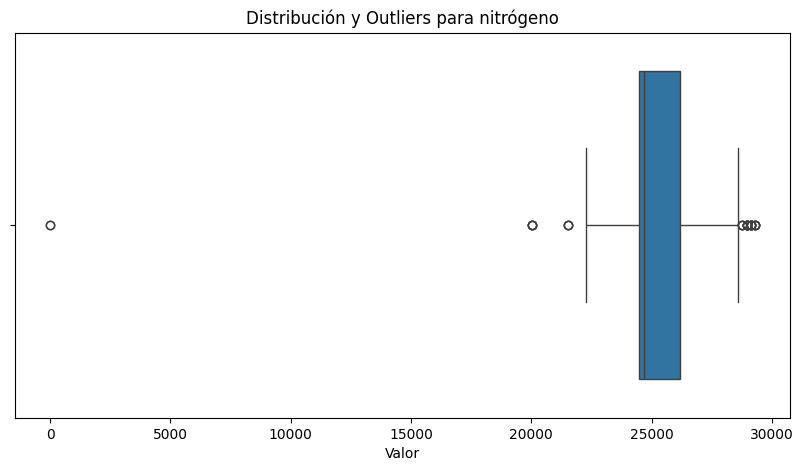

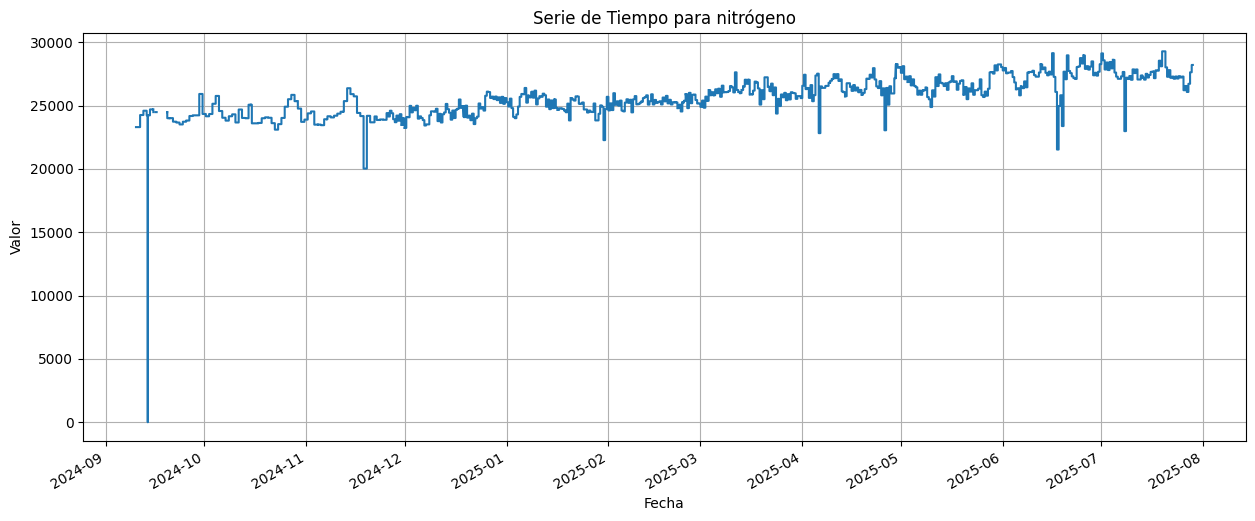


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'voltaje_fase_3_fase_1' ###
############################################################
Total de registros: 4720549
Valores nulos: 889 (0.02%)

--- Resumen Estadístico de 'value' ---
count    4.719660e+06
mean     2.206259e+02
std      4.301110e+00
min      0.000000e+00
25%      2.180222e+02
50%      2.208569e+02
75%      2.235097e+02
max      3.745016e+02


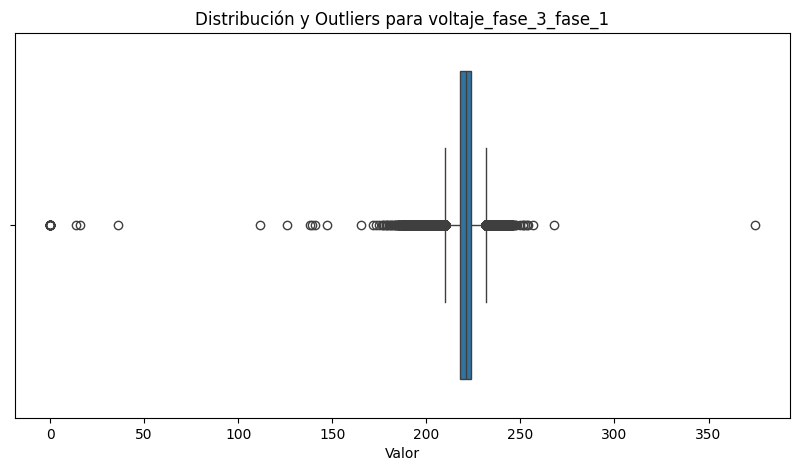

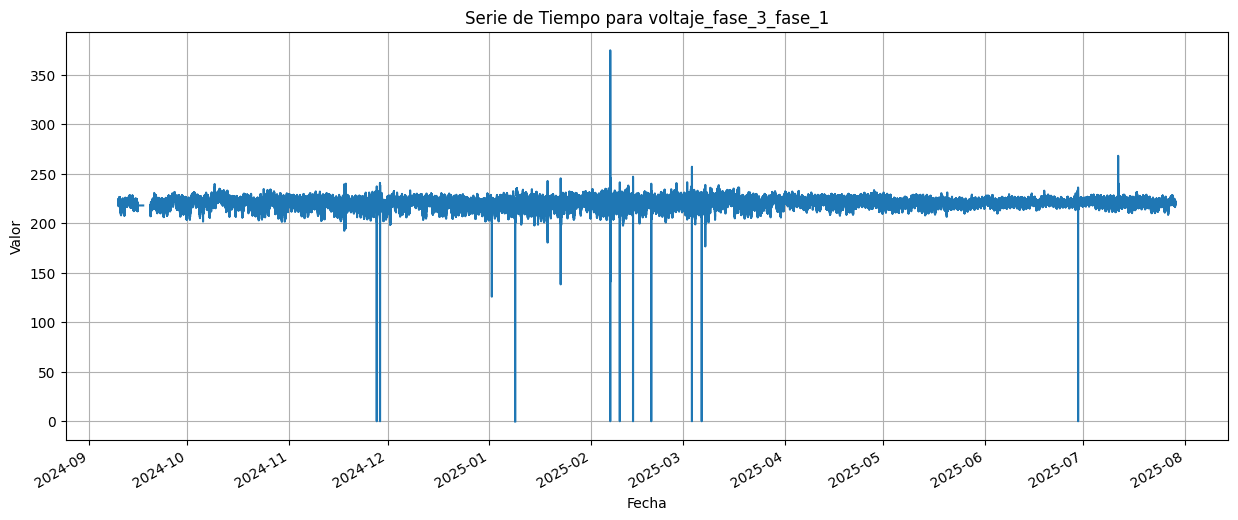


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'max_temperatura_aceite_OLTC_1_horaria' ###
############################################################
Total de registros: 3262
Valores nulos: 8 (0.25%)

--- Resumen Estadístico de 'value' ---
count    3254.000000
mean       43.147750
std         7.134413
min        24.600000
25%        37.980061
50%        43.000000
75%        48.400002
max        62.000000


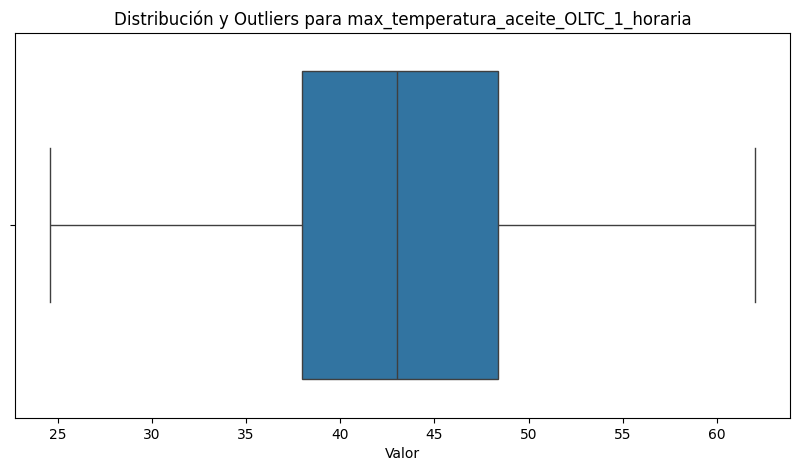

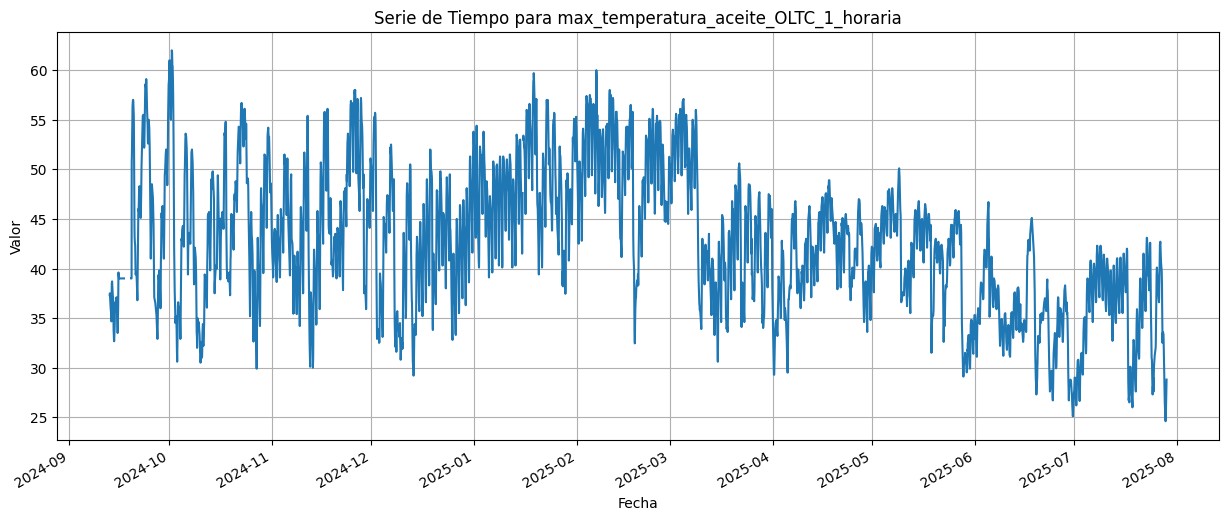


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'potencia_aparente' ###
############################################################
Total de registros: 375831
Valores nulos: 3219 (0.86%)

--- Resumen Estadístico de 'value' ---
count    372612.000000
mean         31.082623
std           7.742192
min           0.000000
25%          25.422135
50%          29.463577
75%          35.961471
max          61.942643


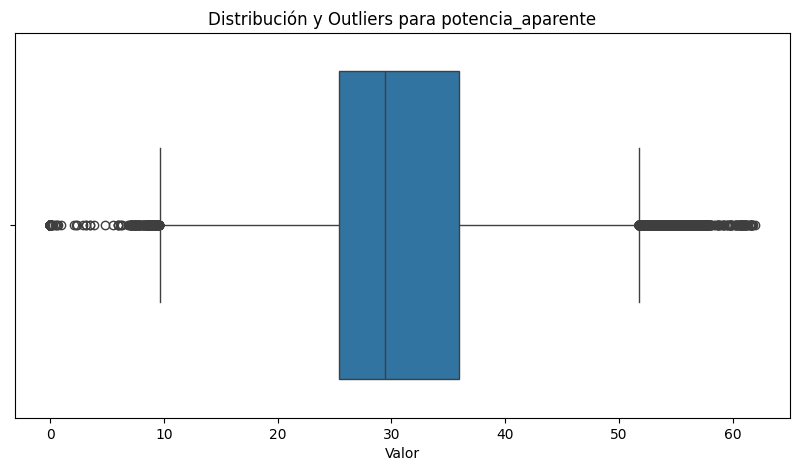

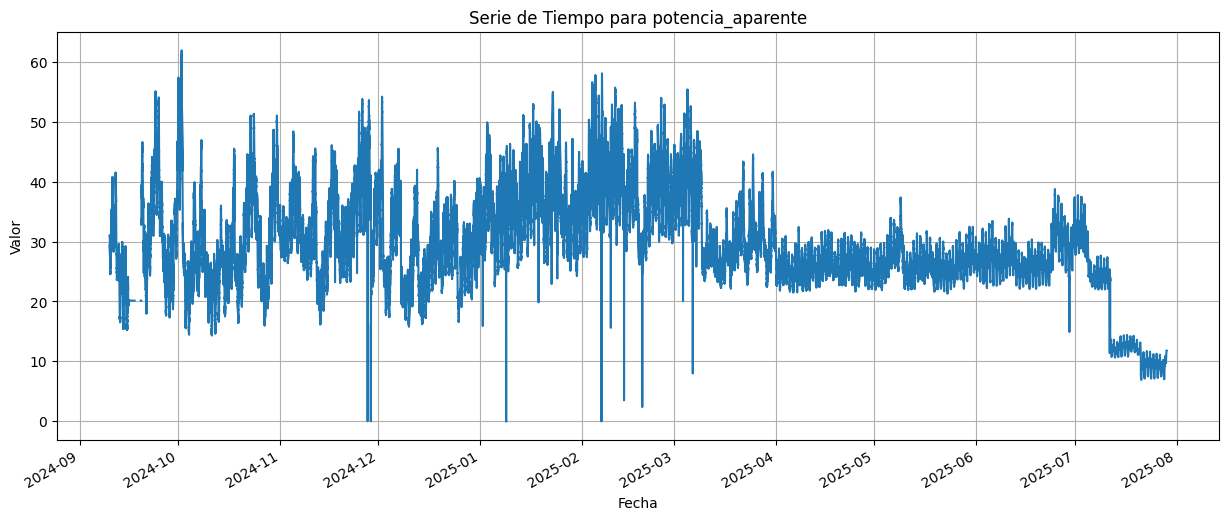


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'gradient_oxigeno' ###
############################################################
Total de registros: 3221
Valores nulos: 923 (28.66%)

--- Resumen Estadístico de 'value' ---
count    2298.000000
mean       -0.286565
std         0.327909
min        -1.422475
25%        -0.424127
50%        -0.412278
75%        -0.065285
max         1.052463


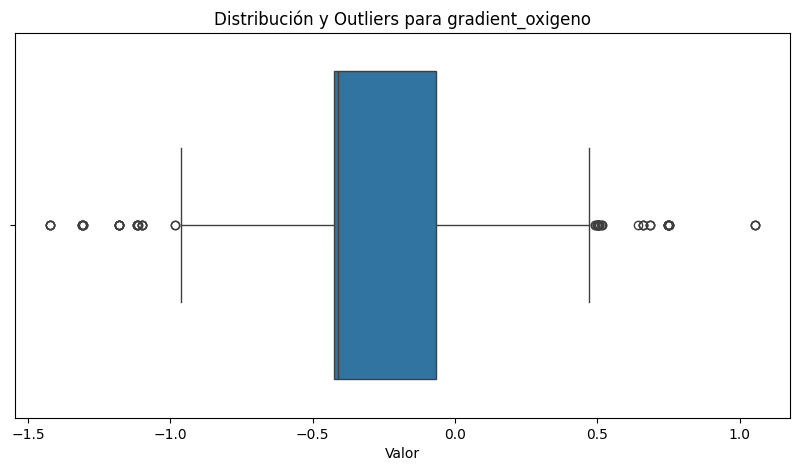

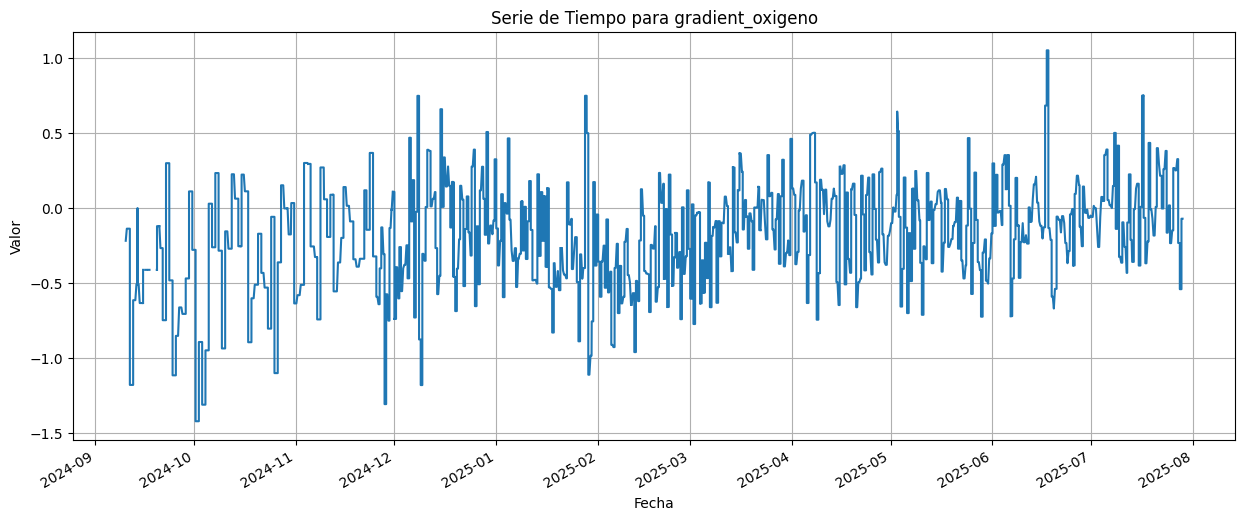


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'ventilador_2_mcb' ###
############################################################
Total de registros: 2782
Valores nulos: 2782 (100.00%)

--- Resumen Estadístico de 'value' ---
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN


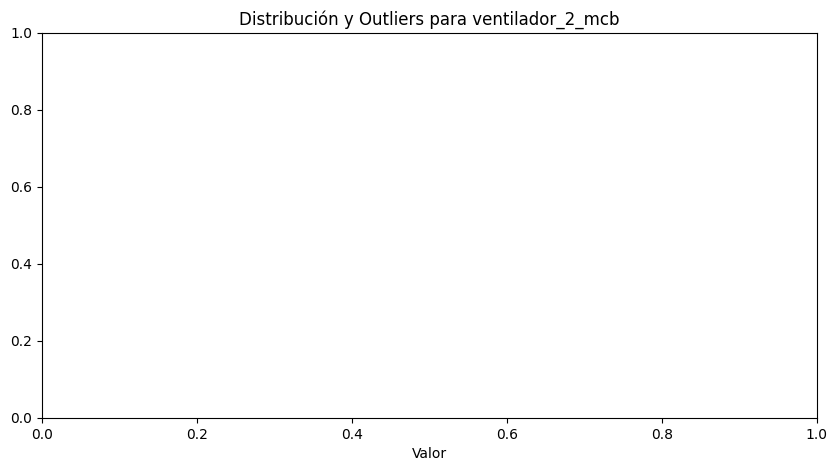

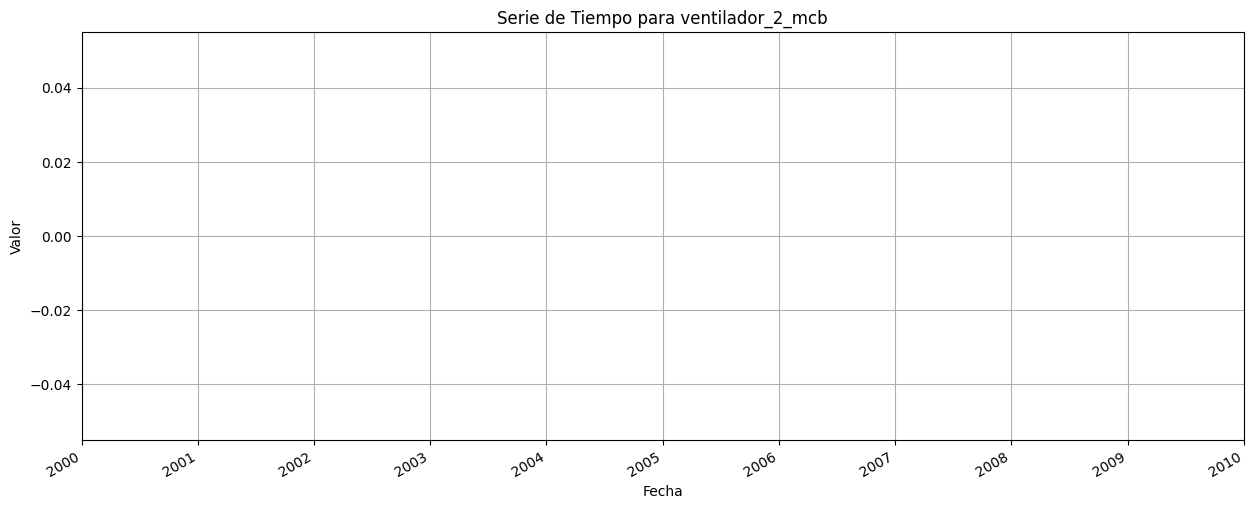


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'ventilador_1_mcb' ###
############################################################
Total de registros: 2937
Valores nulos: 2937 (100.00%)

--- Resumen Estadístico de 'value' ---
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN


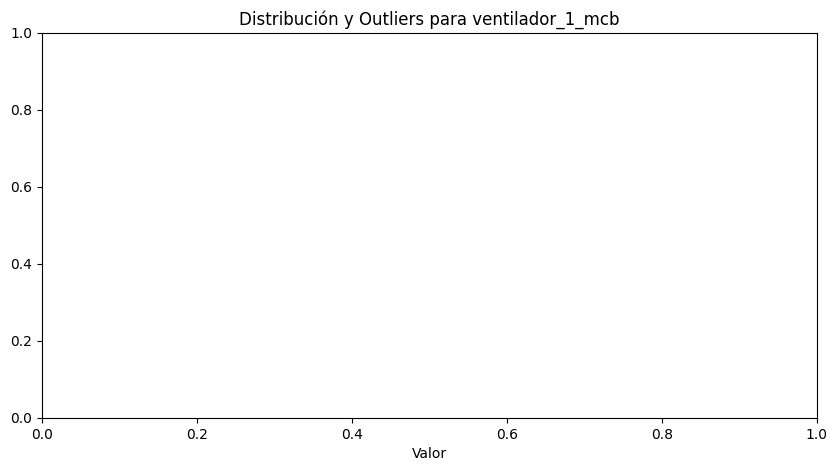

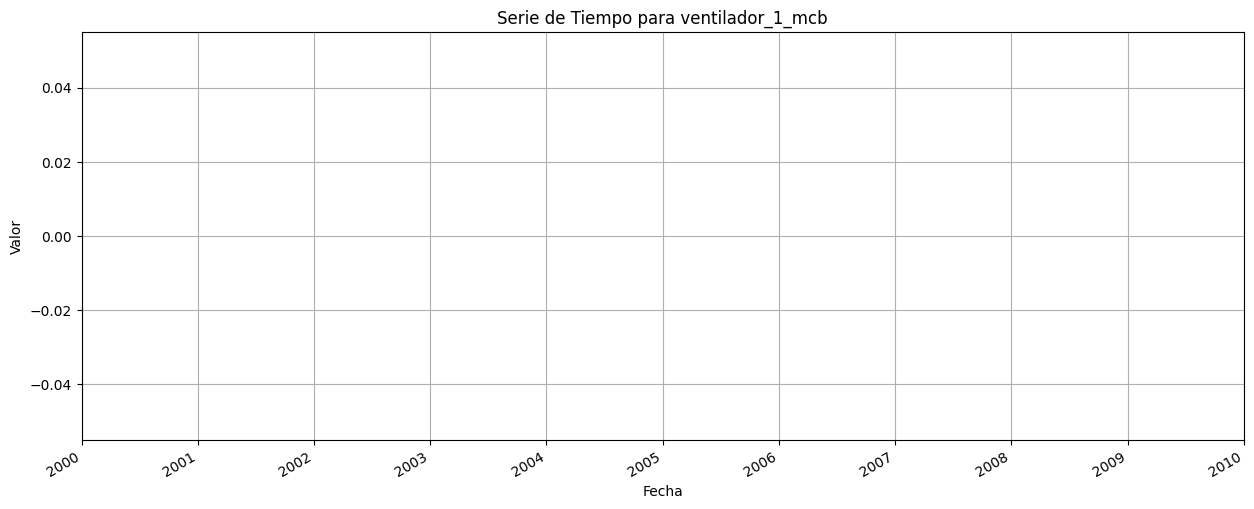


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'estado' ###
############################################################
Total de registros: 9760
Valores nulos: 9760 (100.00%)

--- Resumen Estadístico de 'value' ---
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN


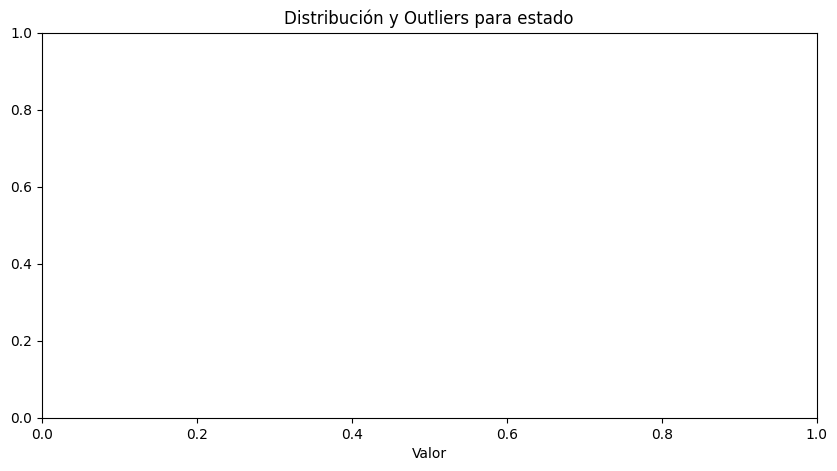

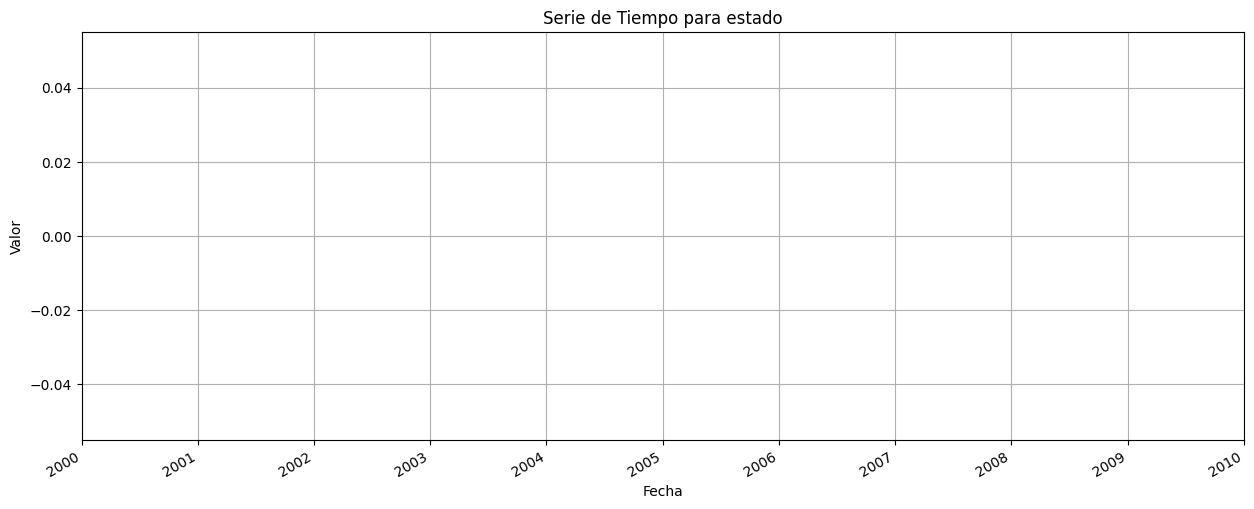


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'tasa_envejecimiento' ###
############################################################
Total de registros: 3050
Valores nulos: 1012 (33.18%)

--- Resumen Estadístico de 'value' ---
count    2038.000000
mean        0.005591
std         0.008327
min         0.000000
25%         0.001605
50%         0.002373
75%         0.005329
max         0.081182


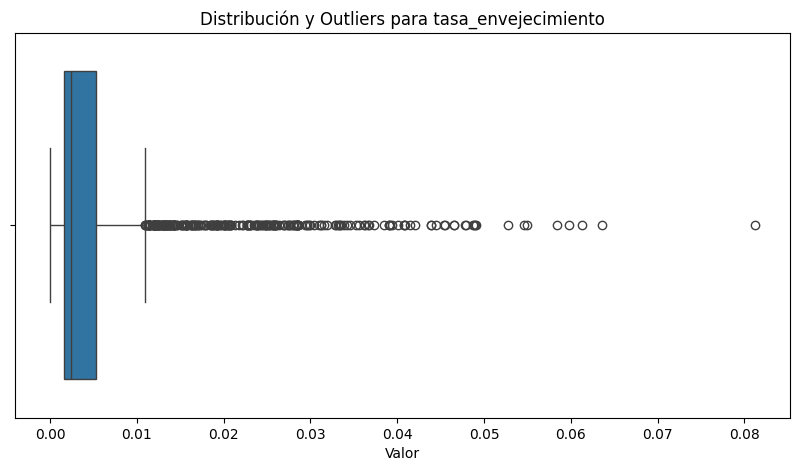

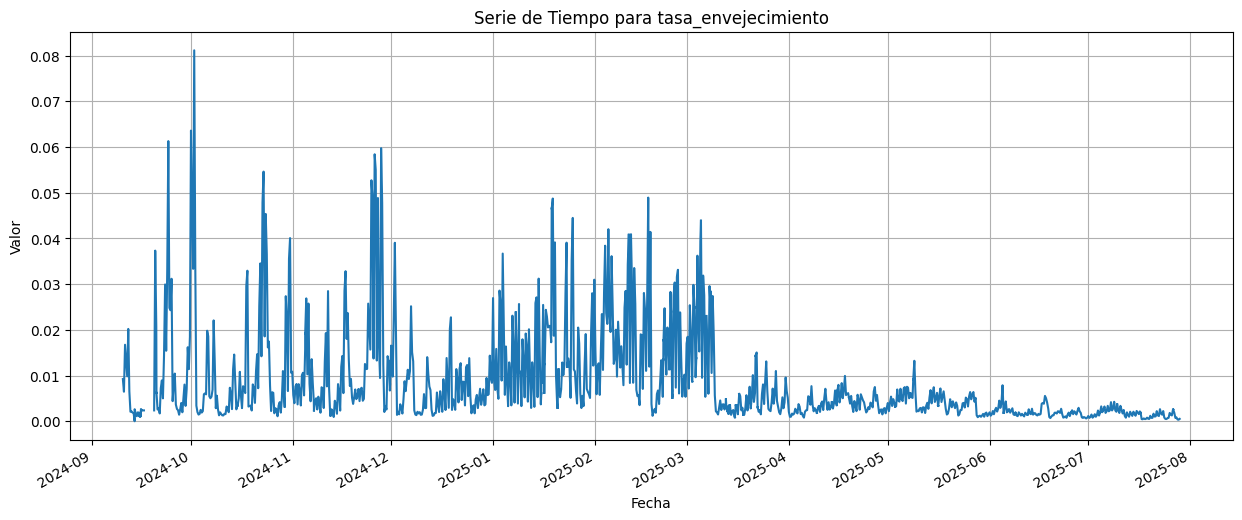


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'dioxido_carbono' ###
############################################################
Total de registros: 3710
Valores nulos: 1012 (27.28%)

--- Resumen Estadístico de 'value' ---
count    2698.000000
mean     1415.301793
std       237.103562
min         0.000000
25%      1136.954712
50%      1420.284119
75%      1659.200562
max      1764.046509


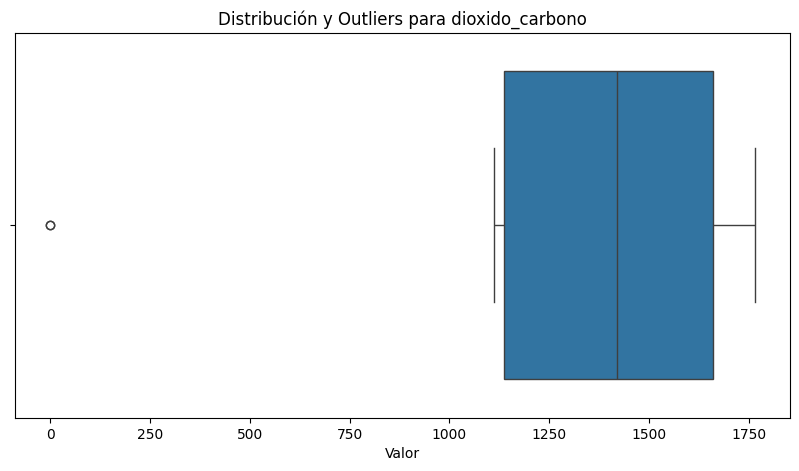

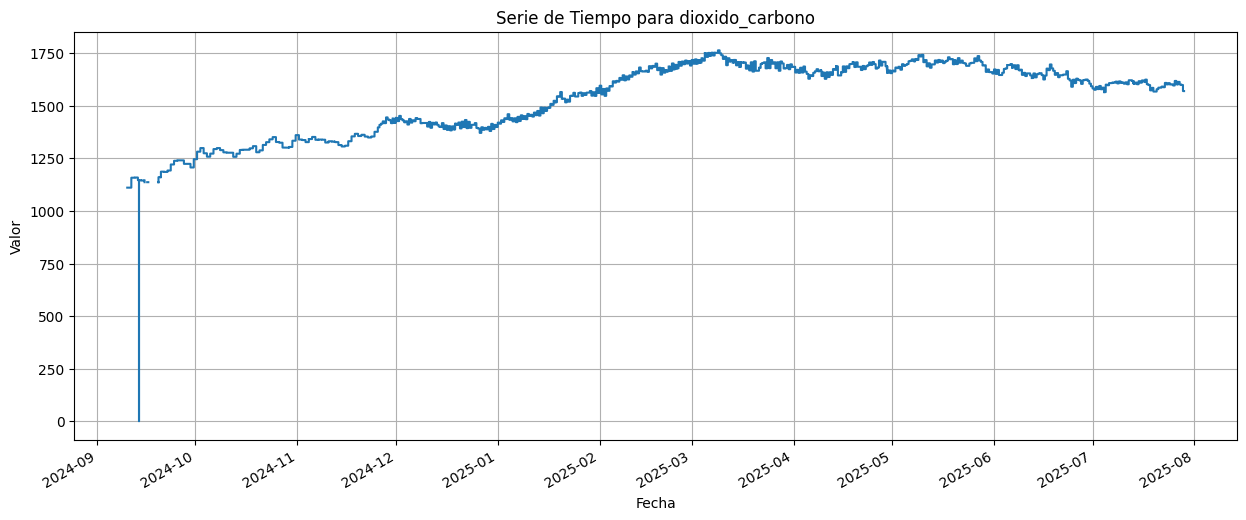


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'ventilador_9_mcb' ###
############################################################
Total de registros: 2755
Valores nulos: 2755 (100.00%)

--- Resumen Estadístico de 'value' ---
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN


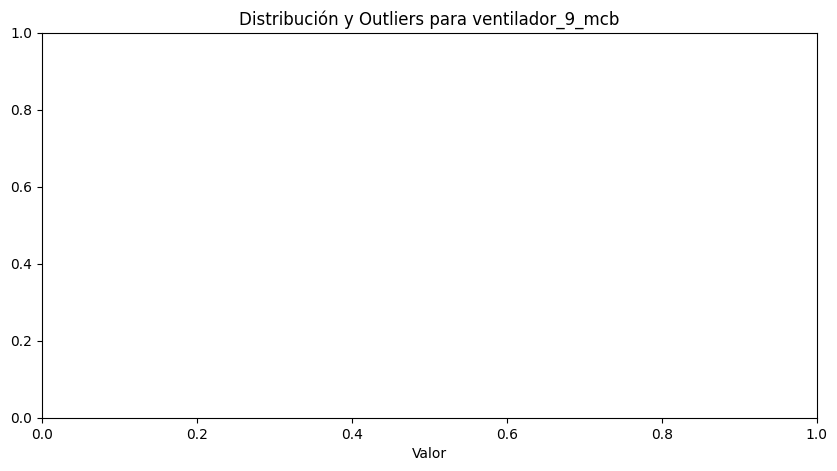

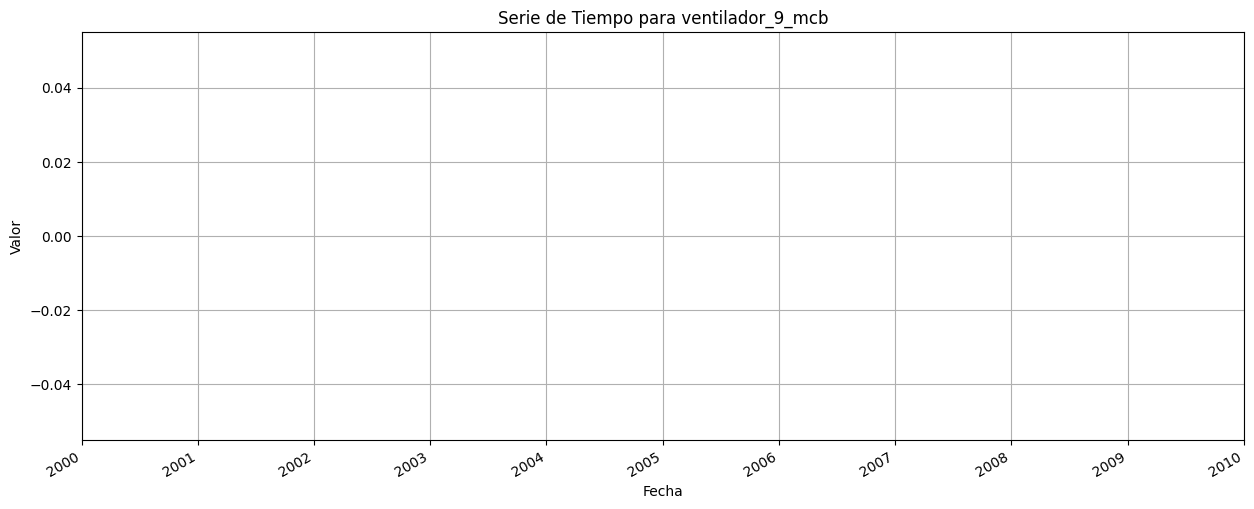


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'emergencia_enfriamiento_sobre_carga' ###
############################################################
Total de registros: 2923
Valores nulos: 1004 (34.35%)

--- Resumen Estadístico de 'value' ---
count    1919.000000
mean      999.478895
std        22.827719
min         0.000000
25%      1000.000000
50%      1000.000000
75%      1000.000000
max      1000.000000


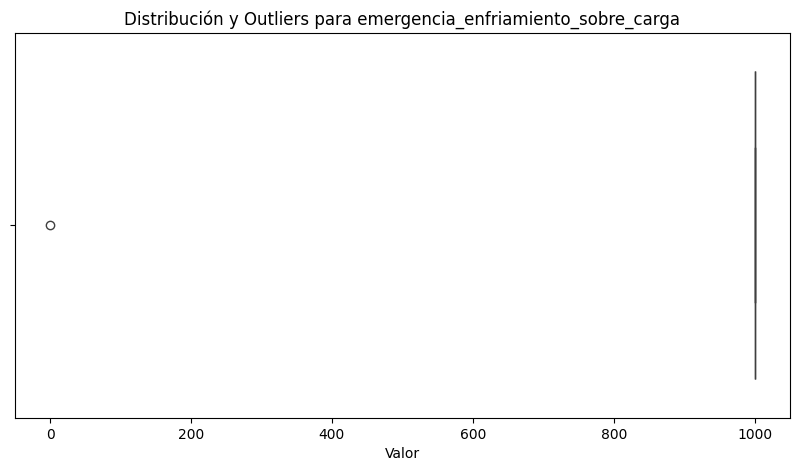

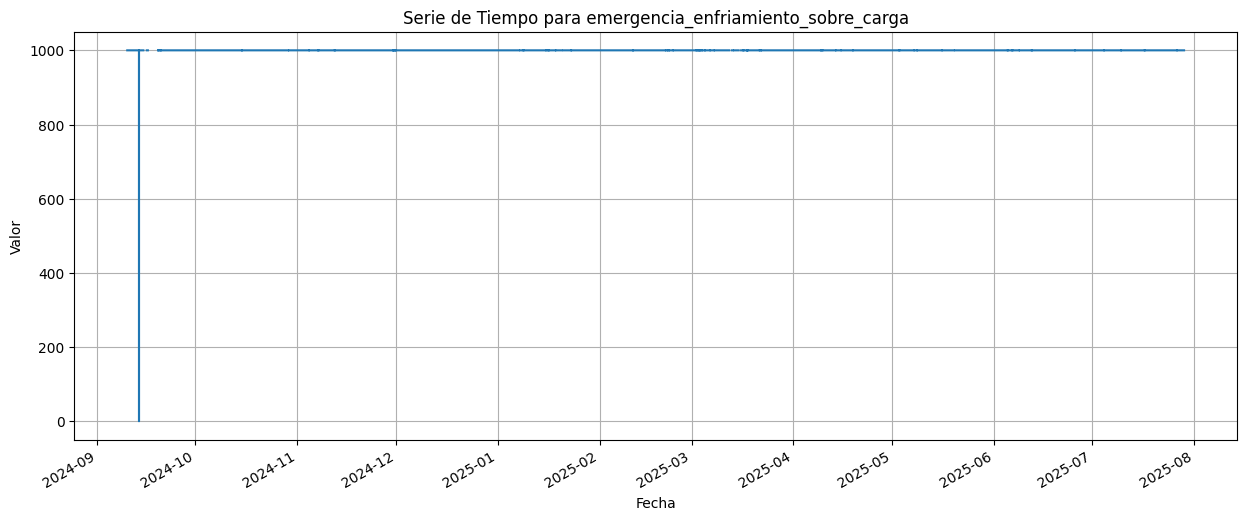


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'verificar_conexion_sensor_gas' ###
############################################################
Total de registros: 2947
Valores nulos: 2947 (100.00%)

--- Resumen Estadístico de 'value' ---
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN


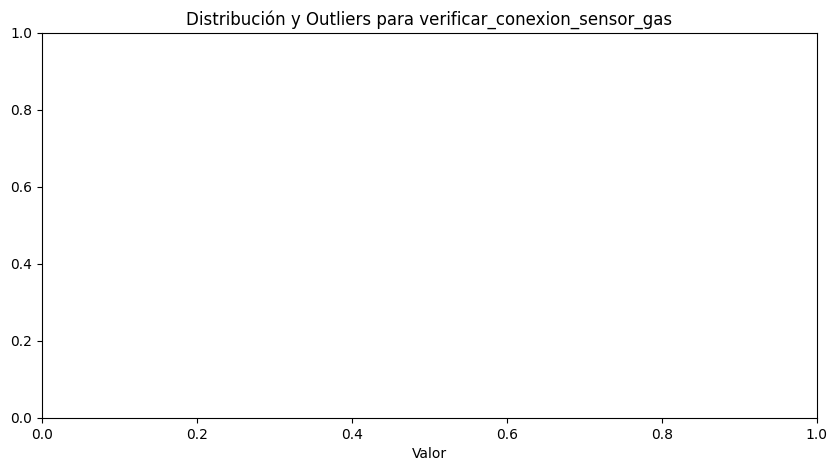

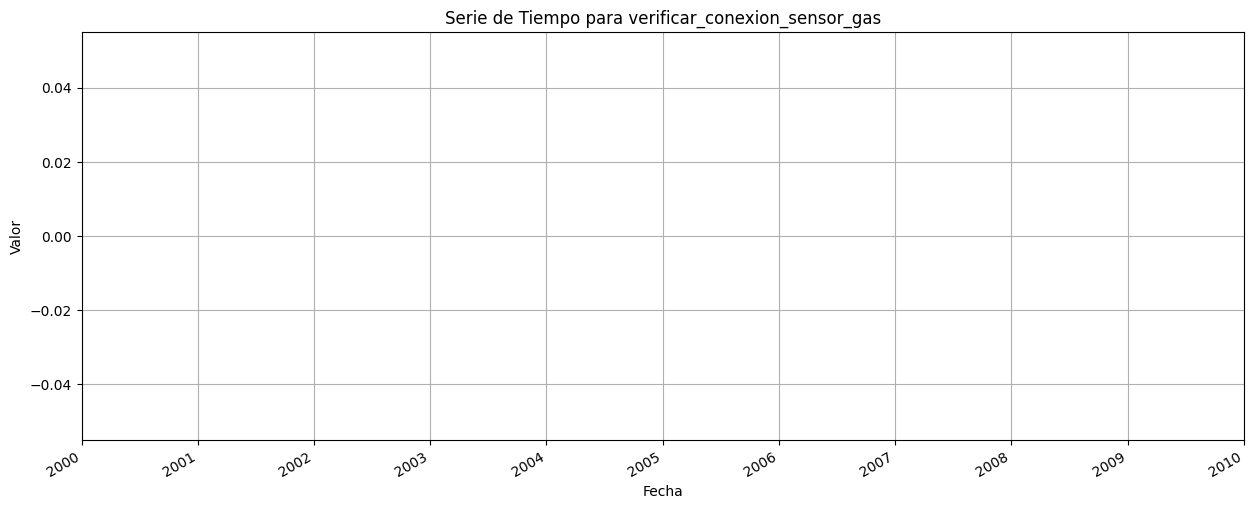


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'tap_position' ###
############################################################
Total de registros: 6945
Valores nulos: 916 (13.19%)

--- Resumen Estadístico de 'value' ---
count    6029.000000
mean        9.266545
std         1.736960
min         0.000000
25%         8.000000
50%         9.000000
75%        10.000000
max        17.000000


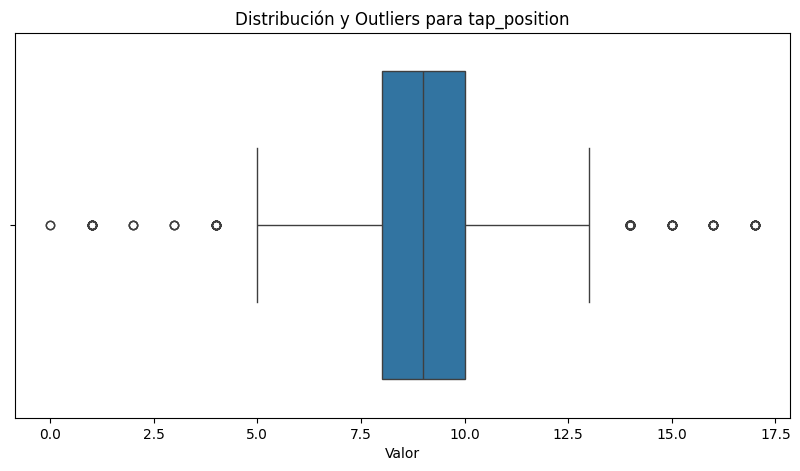

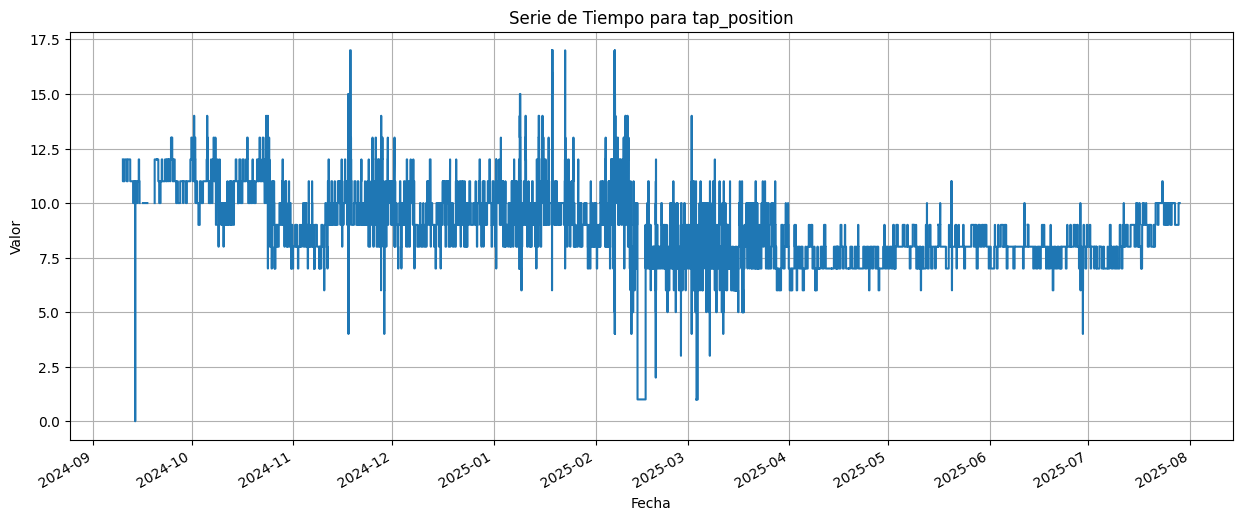


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'ventilador_1' ###
############################################################
Total de registros: 3039
Valores nulos: 3039 (100.00%)

--- Resumen Estadístico de 'value' ---
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN


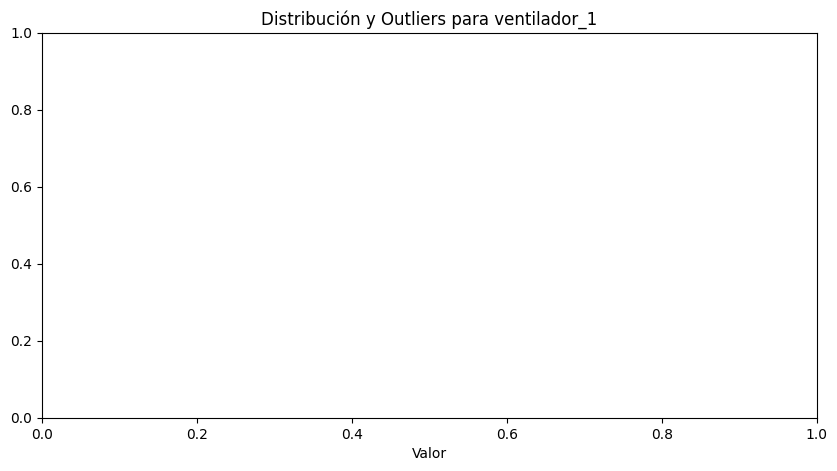

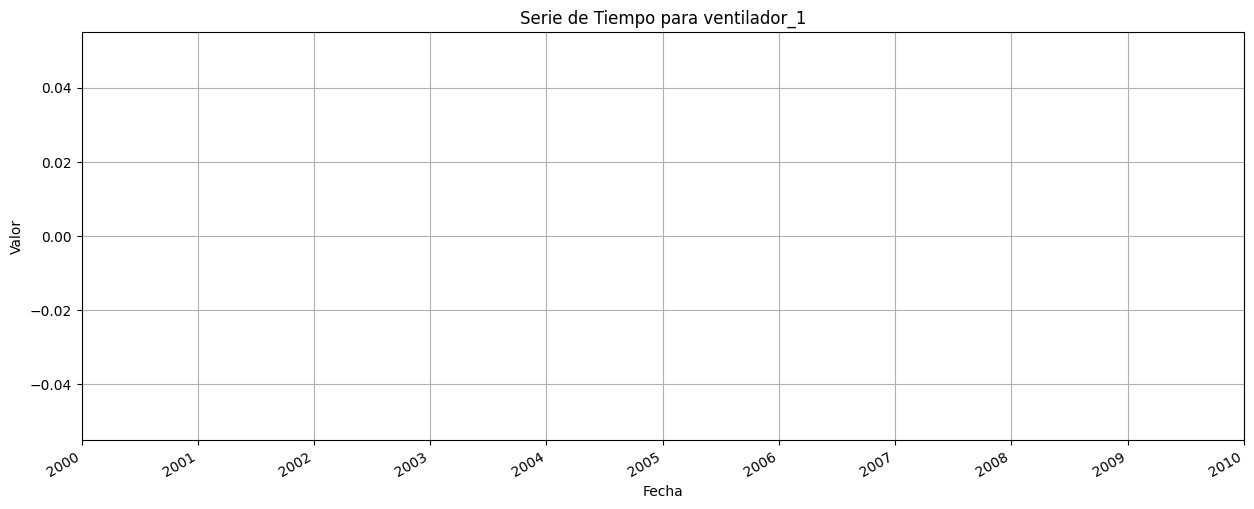


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'temperatura_burbujeo' ###
############################################################
Total de registros: 14032
Valores nulos: 930 (6.63%)

--- Resumen Estadístico de 'value' ---
count    13102.000000
mean       171.816062
std          9.109161
min          0.000000
25%        165.411072
50%        171.073456
75%        179.511368
max        194.108917


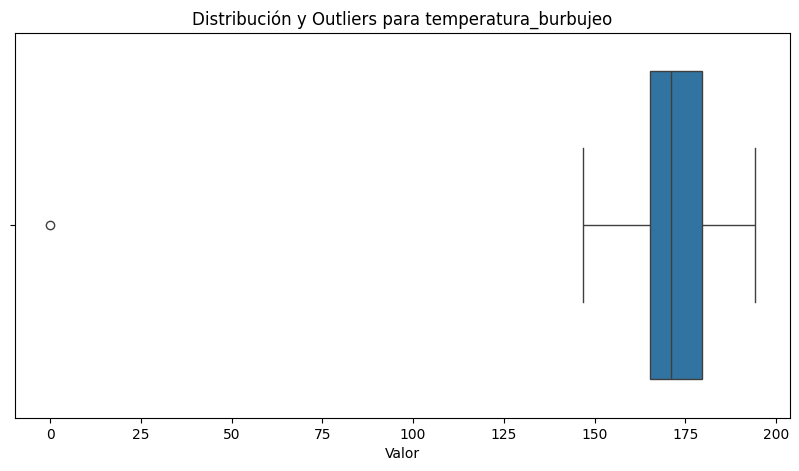

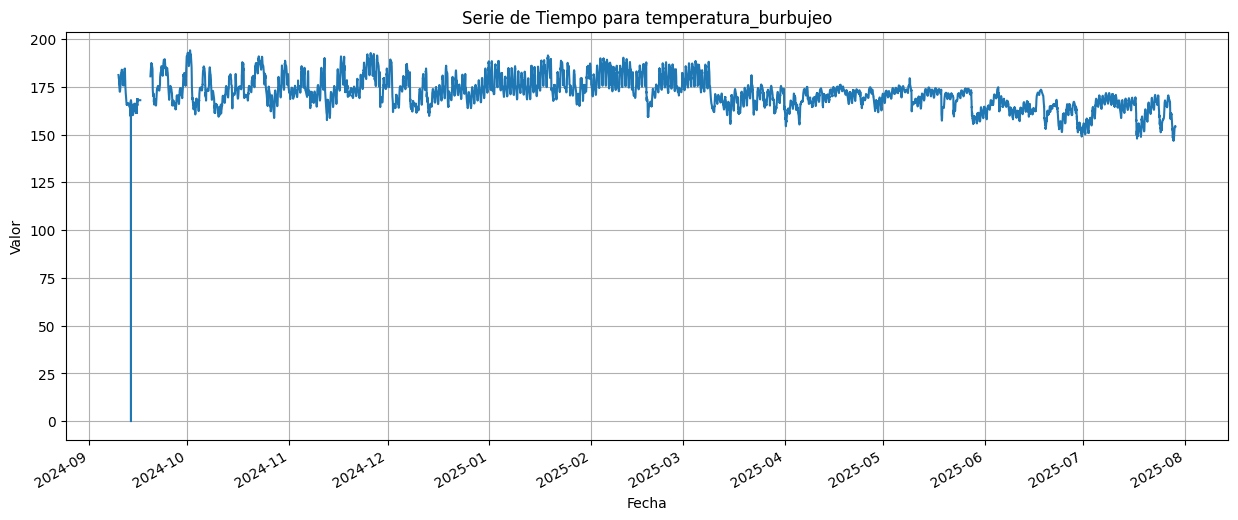


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'gradient_acetileno' ###
############################################################
Total de registros: 2793
Valores nulos: 937 (33.55%)

--- Resumen Estadístico de 'value' ---
count    1856.000000
mean       -0.000018
std         0.001146
min        -0.019405
25%         0.000000
50%         0.000000
75%         0.000000
max         0.017024


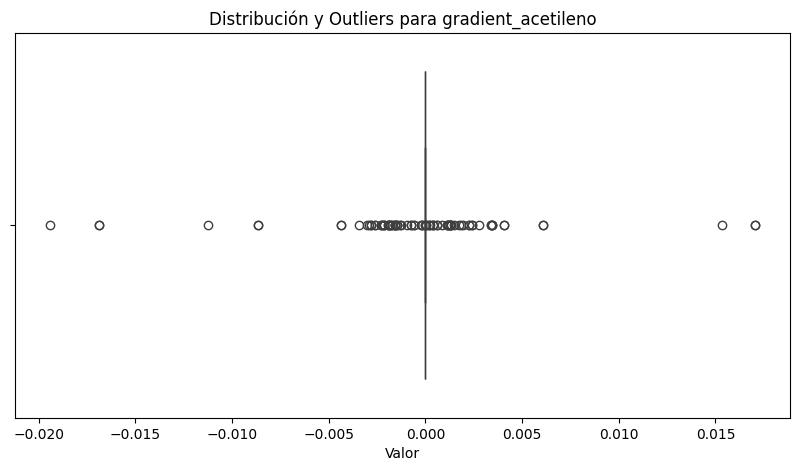

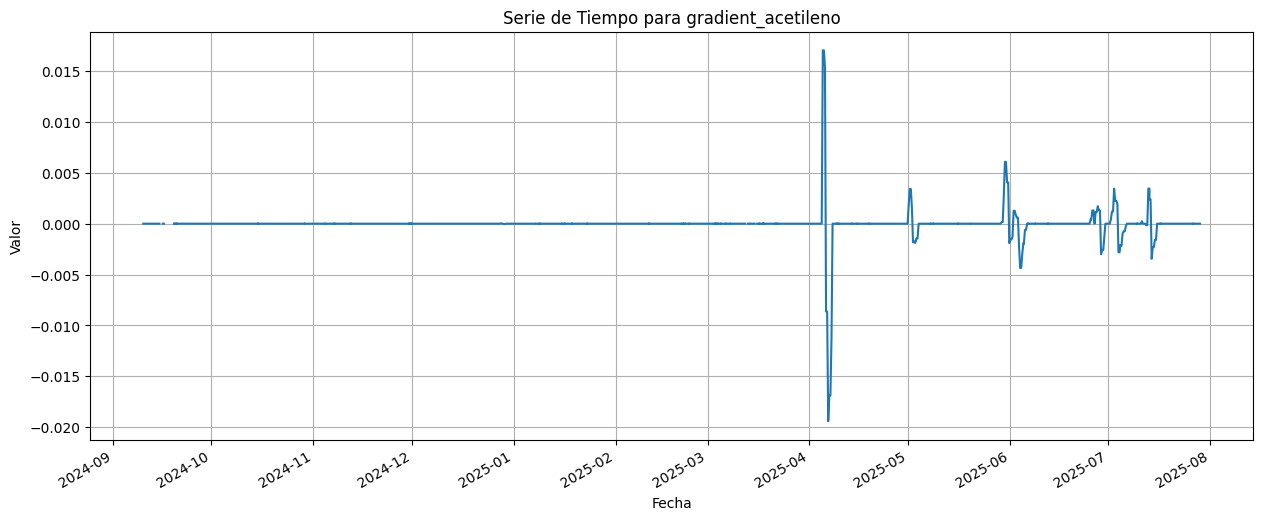


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'system_condition' ###
############################################################
Total de registros: 2776
Valores nulos: 2776 (100.00%)

--- Resumen Estadístico de 'value' ---
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN


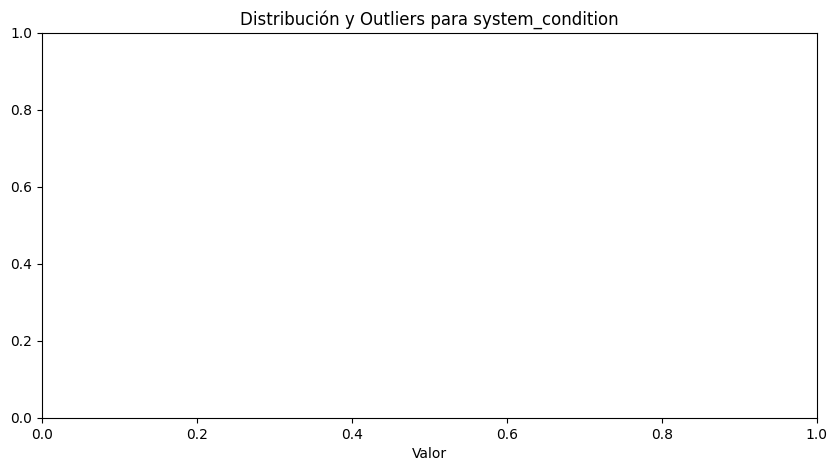

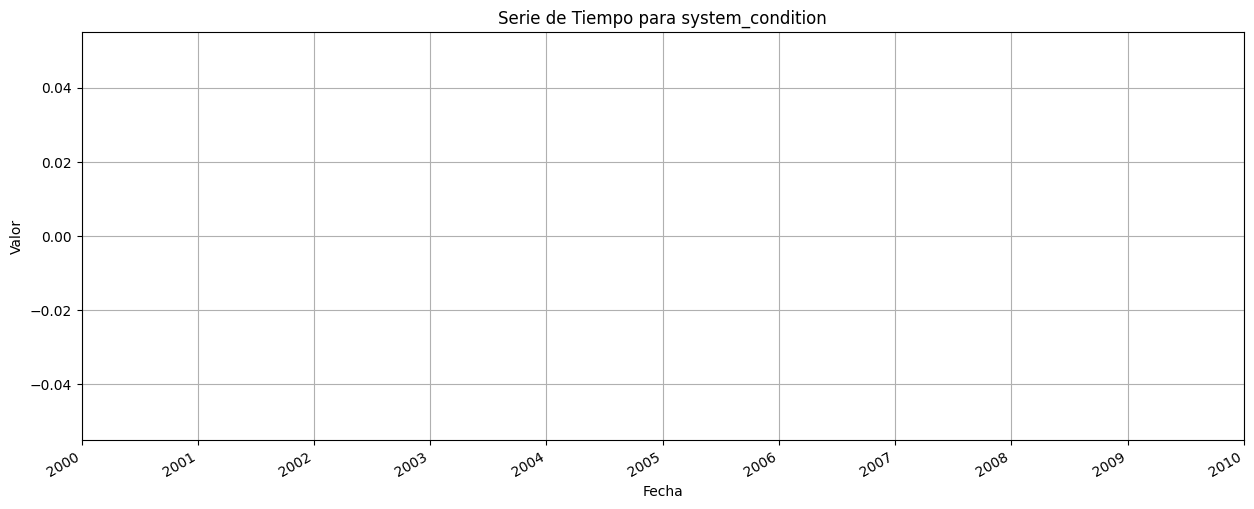


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'max_potencia_fase_2' ###
############################################################
Total de registros: 5881
Valores nulos: 46 (0.78%)

--- Resumen Estadístico de 'value' ---
count    5835.000000
mean       31.816289
std         9.453557
min         6.985369
25%        26.054053
50%        30.184818
75%        37.007748
max        88.191200


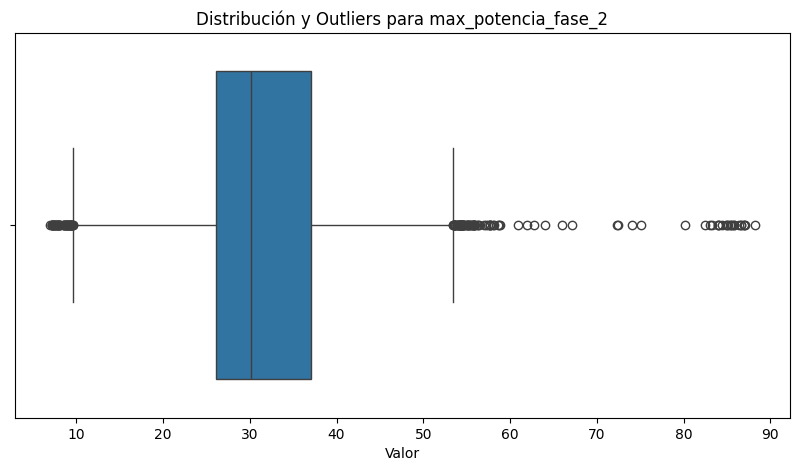

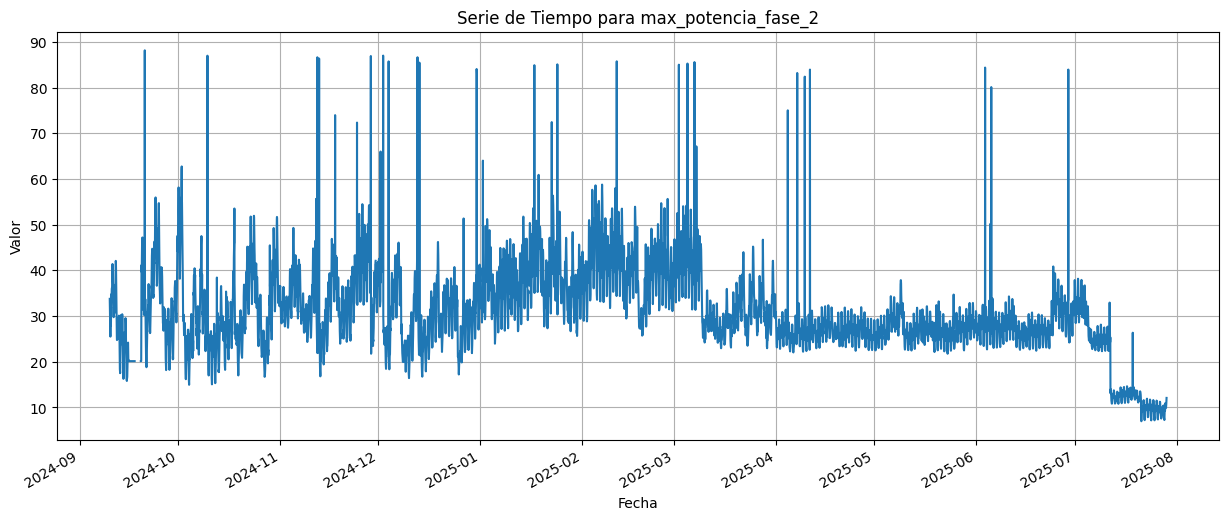


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'ventilador_14_mcb' ###
############################################################
Total de registros: 2937
Valores nulos: 2937 (100.00%)

--- Resumen Estadístico de 'value' ---
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN


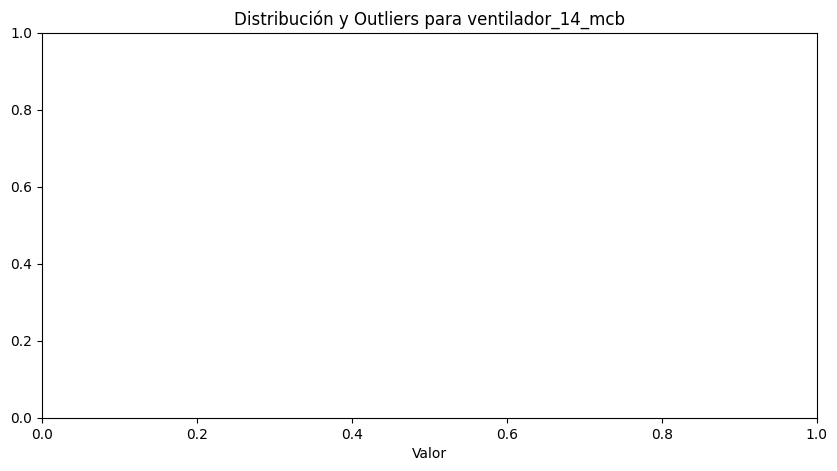

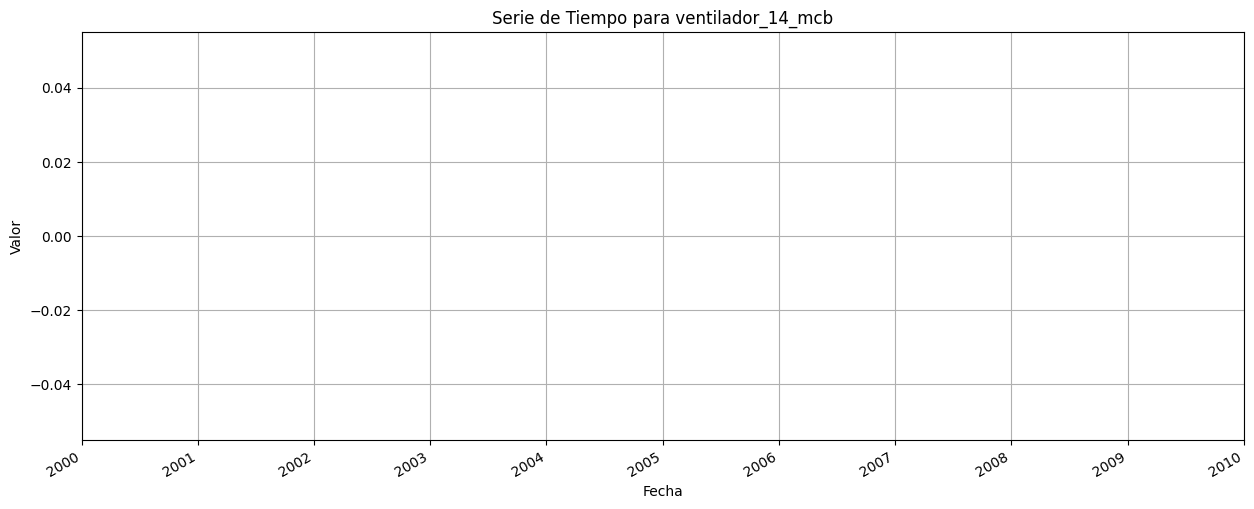


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'contenido_agua_aceite_OLTC_1' ###
############################################################
Total de registros: 13556
Valores nulos: 914 (6.74%)

--- Resumen Estadístico de 'value' ---
count    12642.000000
mean        24.239200
std          4.853151
min         13.125248
25%         20.297098
50%         24.024170
75%         27.808466
max         37.482834


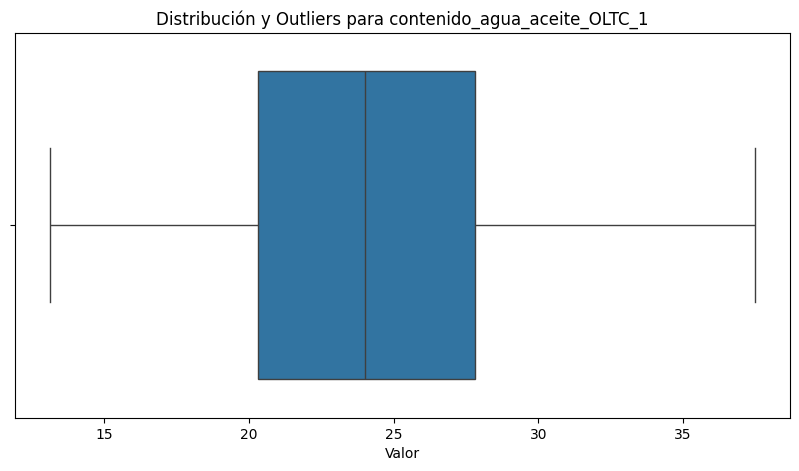

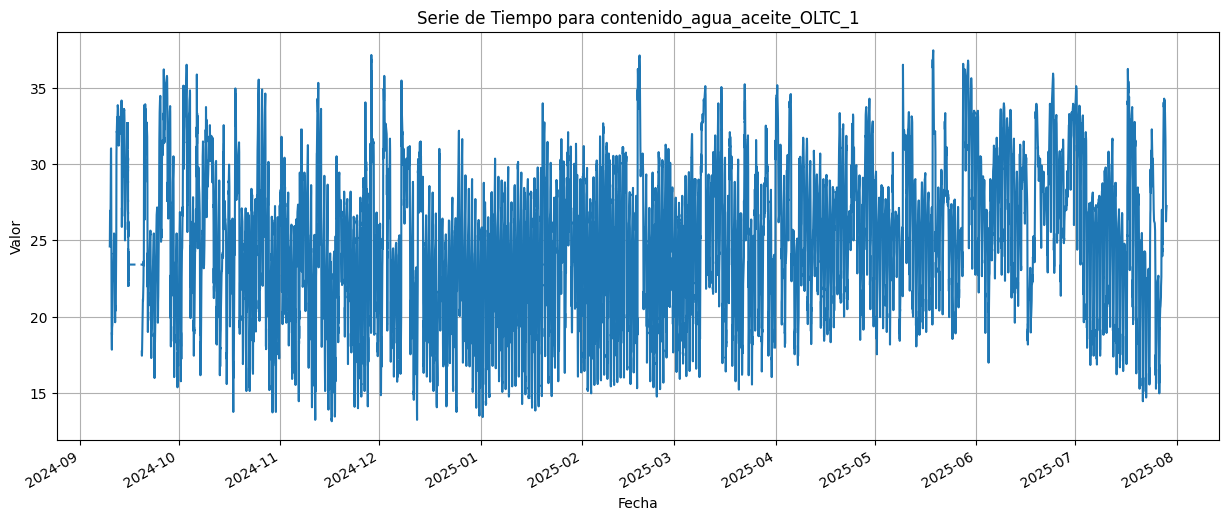


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'ventilador_12_mcb' ###
############################################################
Total de registros: 2937
Valores nulos: 2937 (100.00%)

--- Resumen Estadístico de 'value' ---
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN


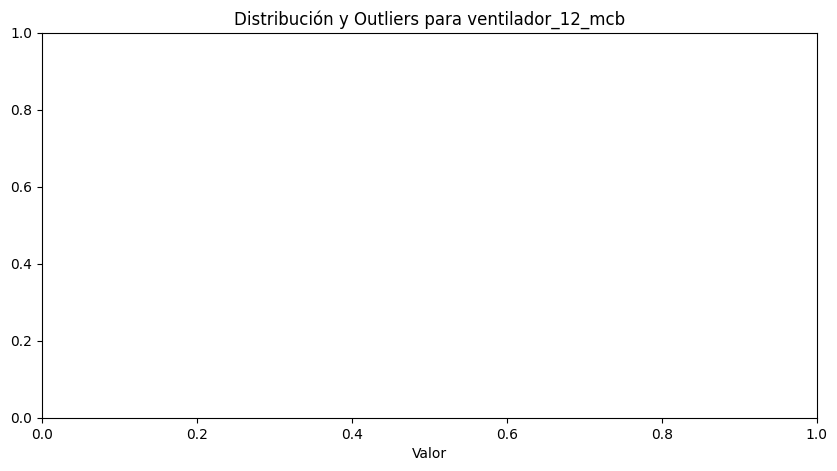

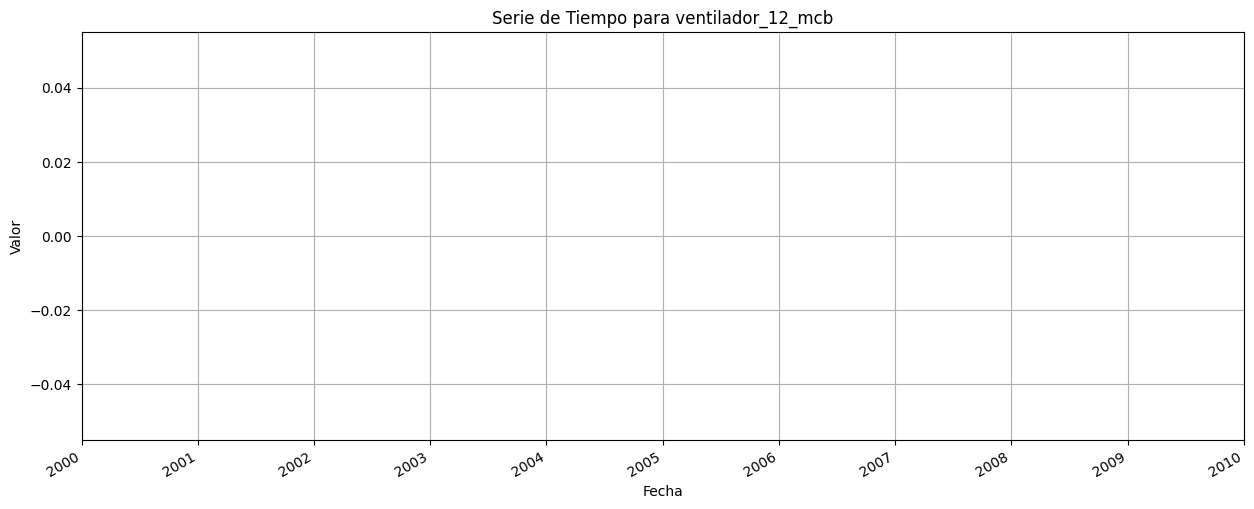


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'etano' ###
############################################################
Total de registros: 3290
Valores nulos: 1008 (30.64%)

--- Resumen Estadístico de 'value' ---
count    2282.000000
mean        2.501263
std         0.743273
min         0.000000
25%         1.911534
50%         2.391465
75%         3.130661
max         4.507733


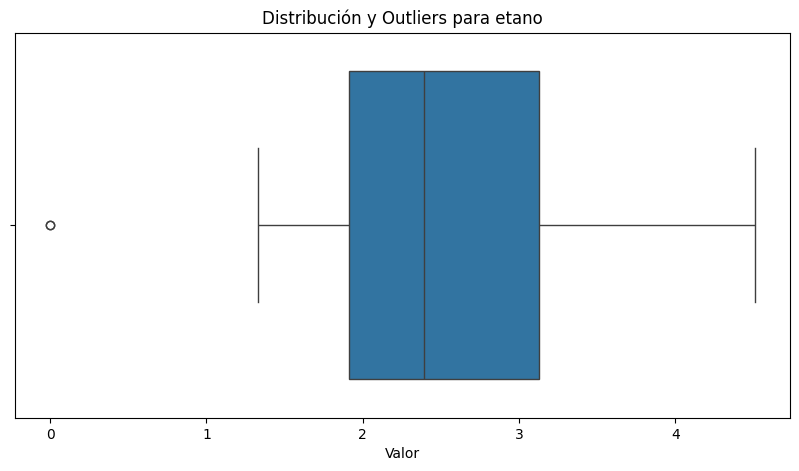

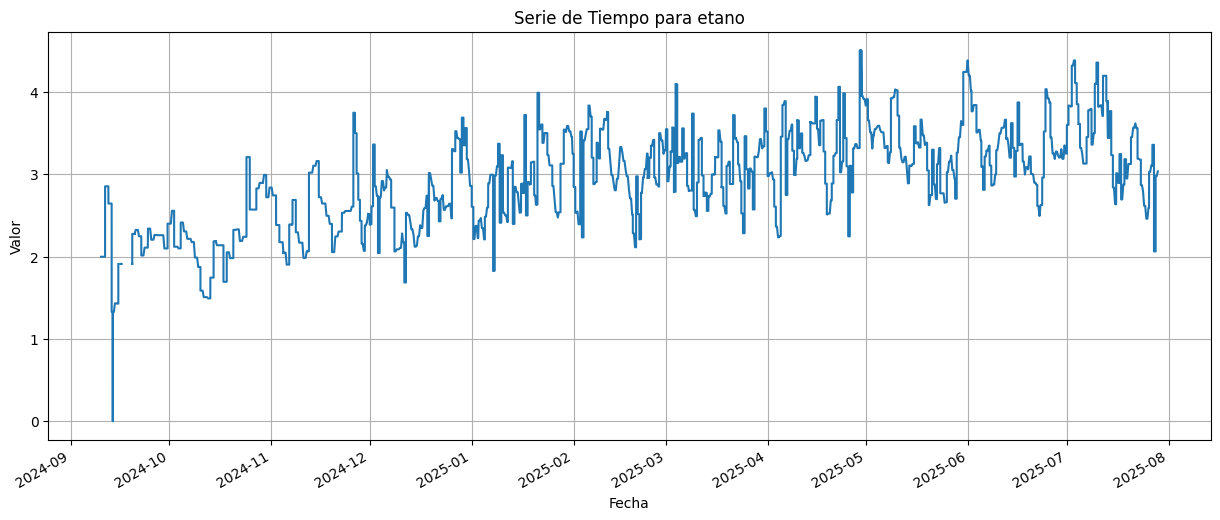


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'nivel_aceite_OLTC_min' ###
############################################################
Total de registros: 2928
Valores nulos: 2928 (100.00%)

--- Resumen Estadístico de 'value' ---
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN


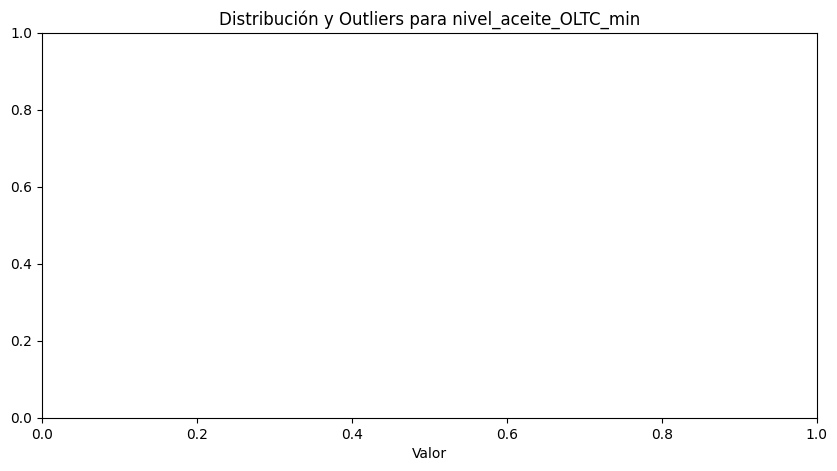

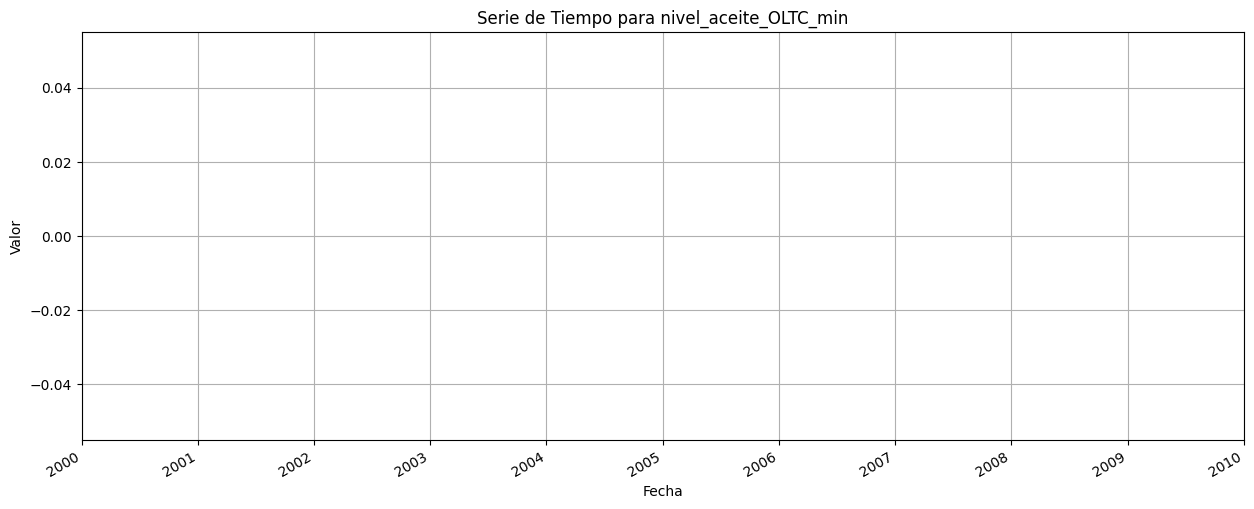


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'max_voltaje_fase_1' ###
############################################################
Total de registros: 34959
Valores nulos: 8 (0.02%)

--- Resumen Estadístico de 'value' ---
count    34951.000000
mean       127.279064
std          2.495919
min          0.000000
25%        125.878357
50%        127.294502
75%        128.529839
max        145.151794


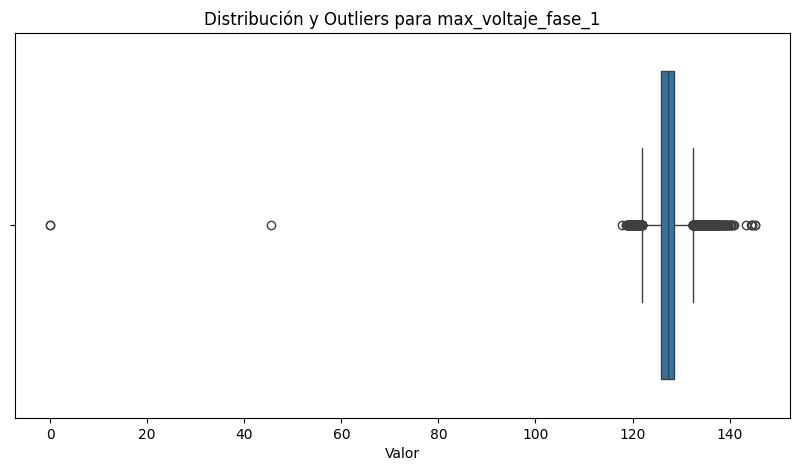

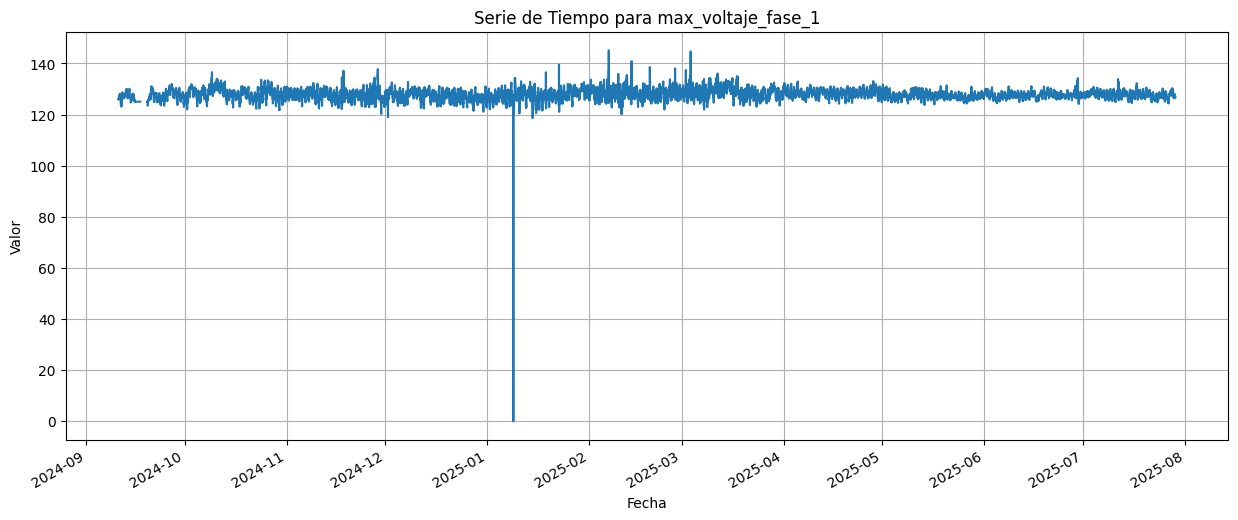


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'cambio_tan_fase_3' ###
############################################################
Total de registros: 3097
Valores nulos: 1011 (32.64%)

--- Resumen Estadístico de 'value' ---
count    2086.000000
mean        0.002153
std         0.003709
min        -0.000063
25%         0.000056
50%         0.000056
75%         0.002945
max         0.014303


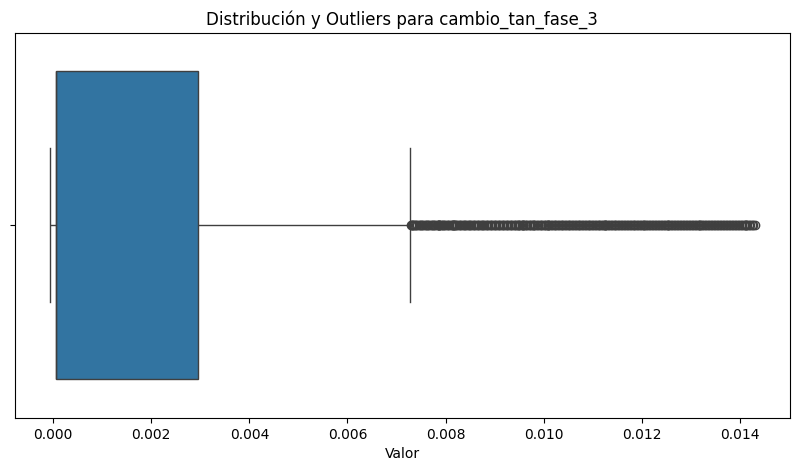

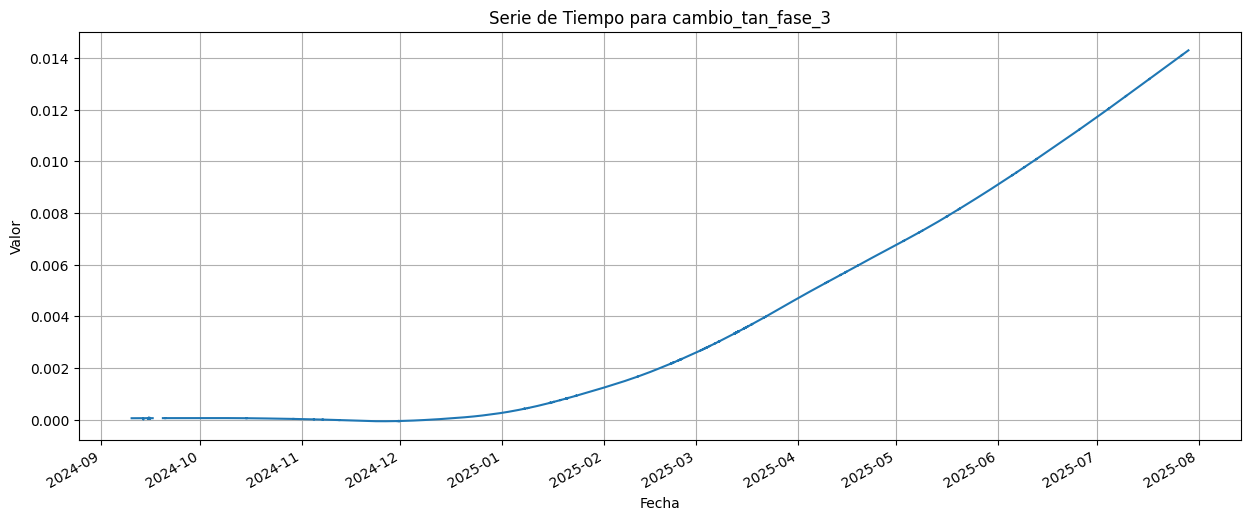


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'numero_sobretensiones_fase_2' ###
############################################################
Total de registros: 2936
Valores nulos: 1002 (34.13%)

--- Resumen Estadístico de 'value' ---
count    1934.000000
mean       12.227508
std         2.196020
min         0.000000
25%        11.000000
50%        11.000000
75%        14.000000
max        22.000000


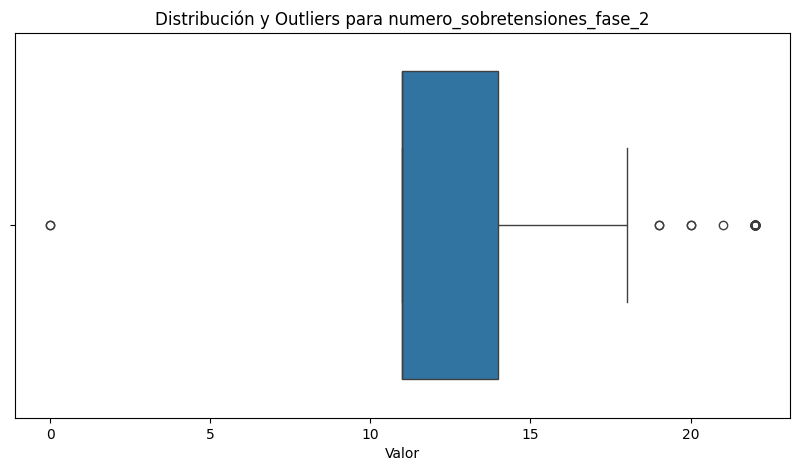

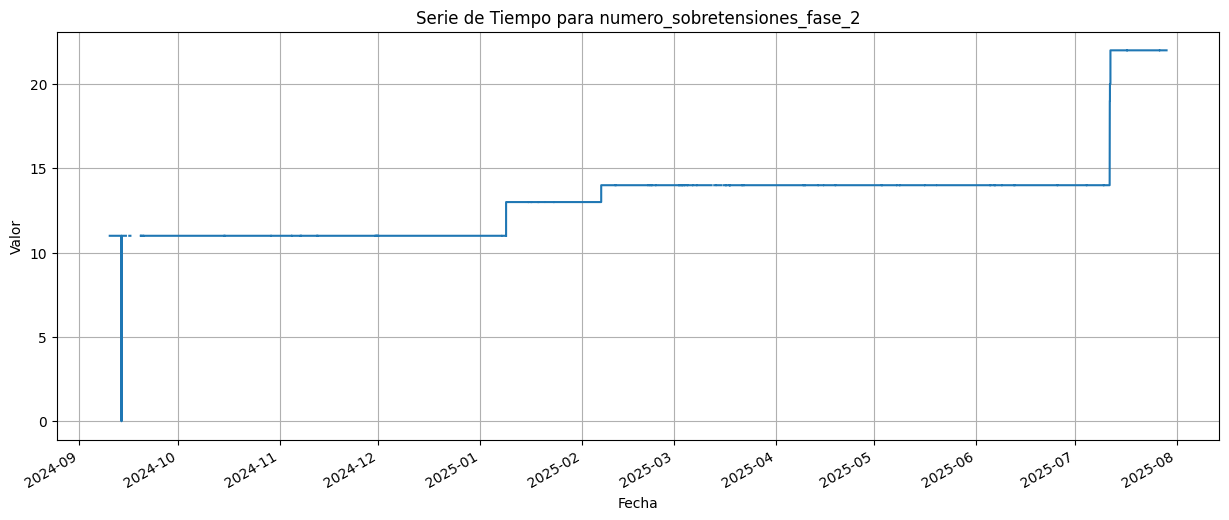


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'gradient_monoxido_carbono' ###
############################################################
Total de registros: 2851
Valores nulos: 916 (32.13%)

--- Resumen Estadístico de 'value' ---
count    1935.000000
mean       -0.002320
std         0.098162
min        -0.563440
25%        -0.033017
50%        -0.033017
75%         0.041381
max         0.664356


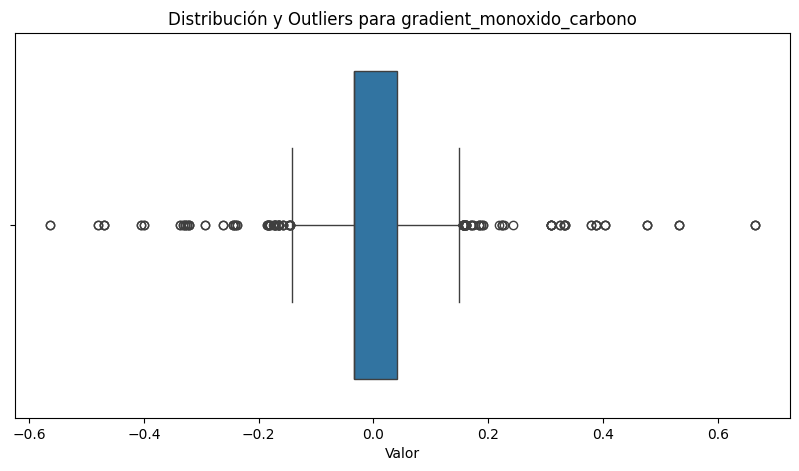

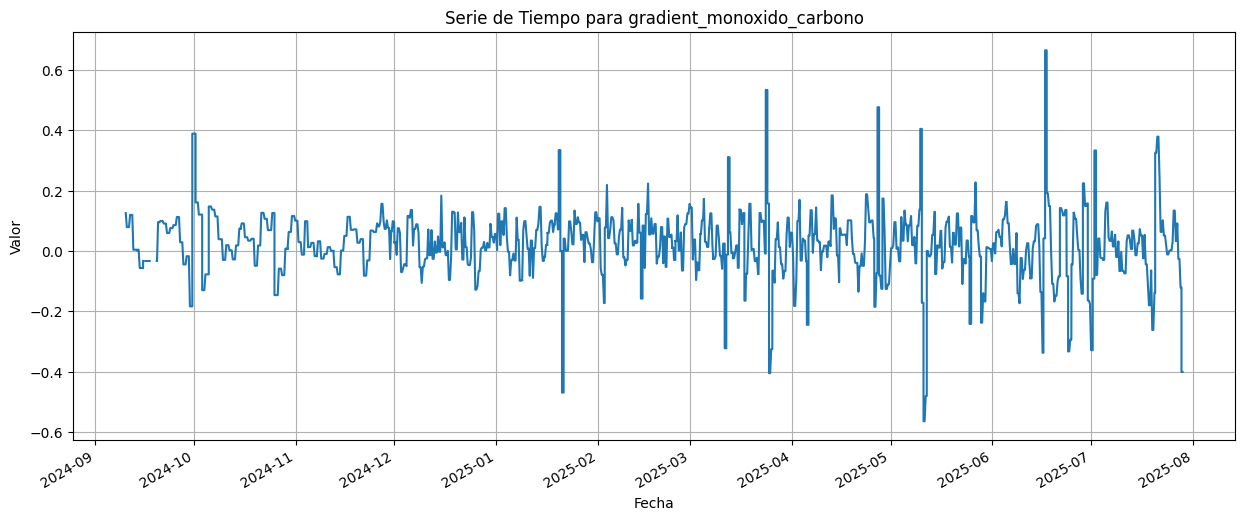


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'margen_burbujeante' ###
############################################################
Total de registros: 19493
Valores nulos: 924 (4.74%)

--- Resumen Estadístico de 'value' ---
count    18569.000000
mean       119.170269
std          2.393283
min          0.000000
25%        117.633354
50%        119.228622
75%        120.698372
max        127.429146


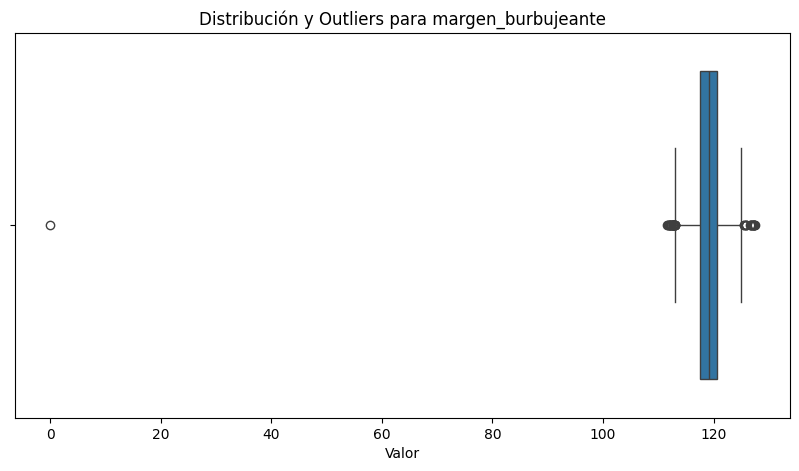

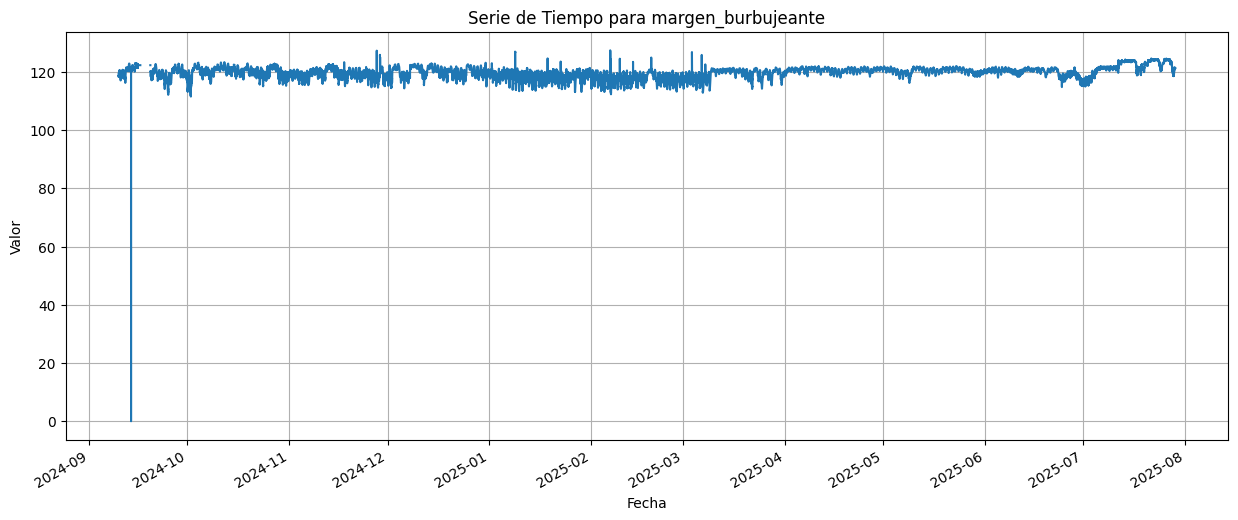


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'promedio_corriente_carga_fase_2' ###
############################################################
Total de registros: 7623
Valores nulos: 46 (0.60%)

--- Resumen Estadístico de 'value' ---
count    7577.000000
mean      732.610165
std       208.701543
min        47.407599
25%       616.482166
50%       704.029226
75%       850.290589
max      1430.116993


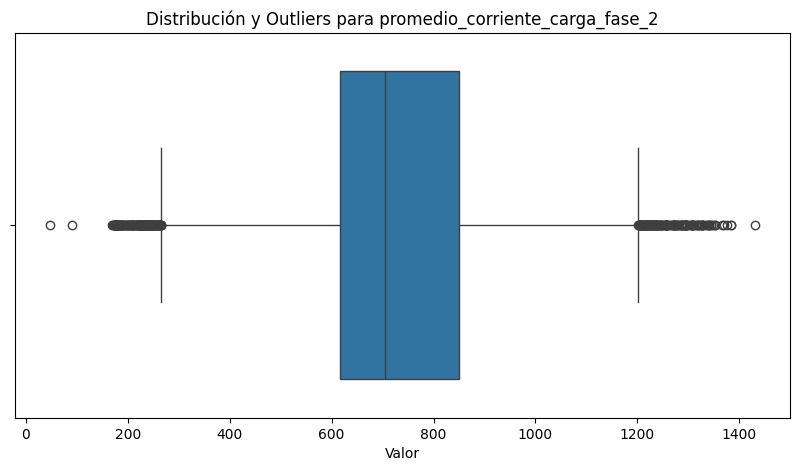

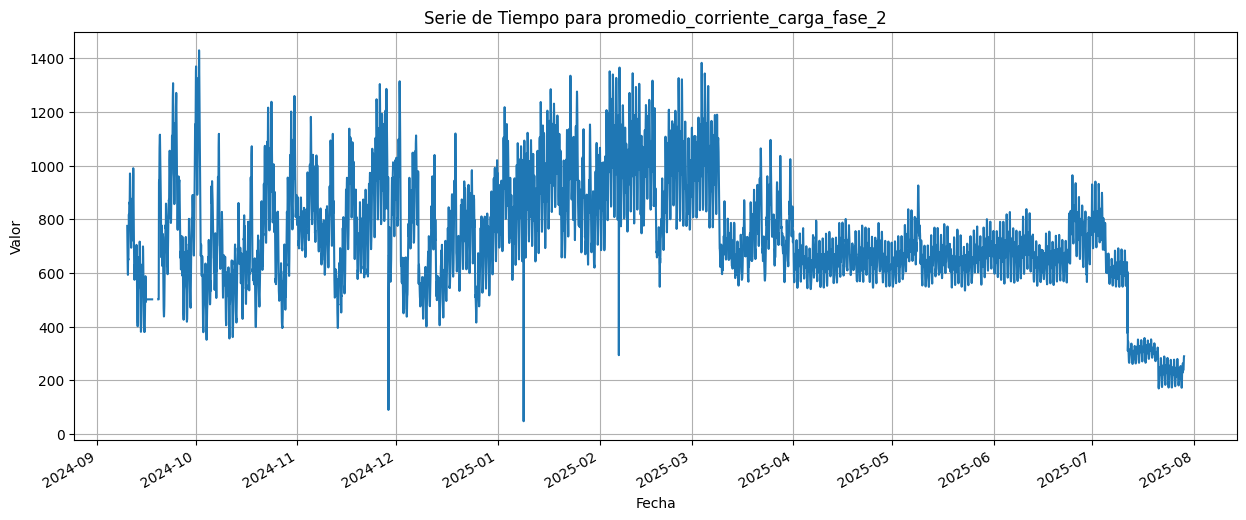


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'ventilador_13_mcb' ###
############################################################
Total de registros: 2940
Valores nulos: 2940 (100.00%)

--- Resumen Estadístico de 'value' ---
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN


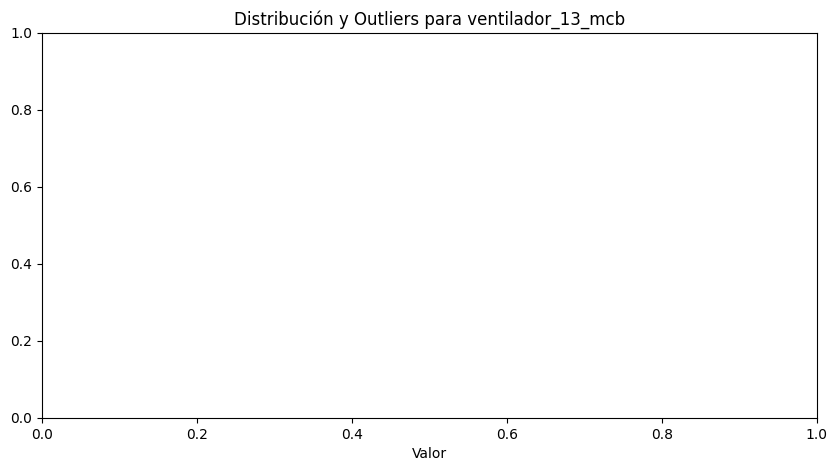

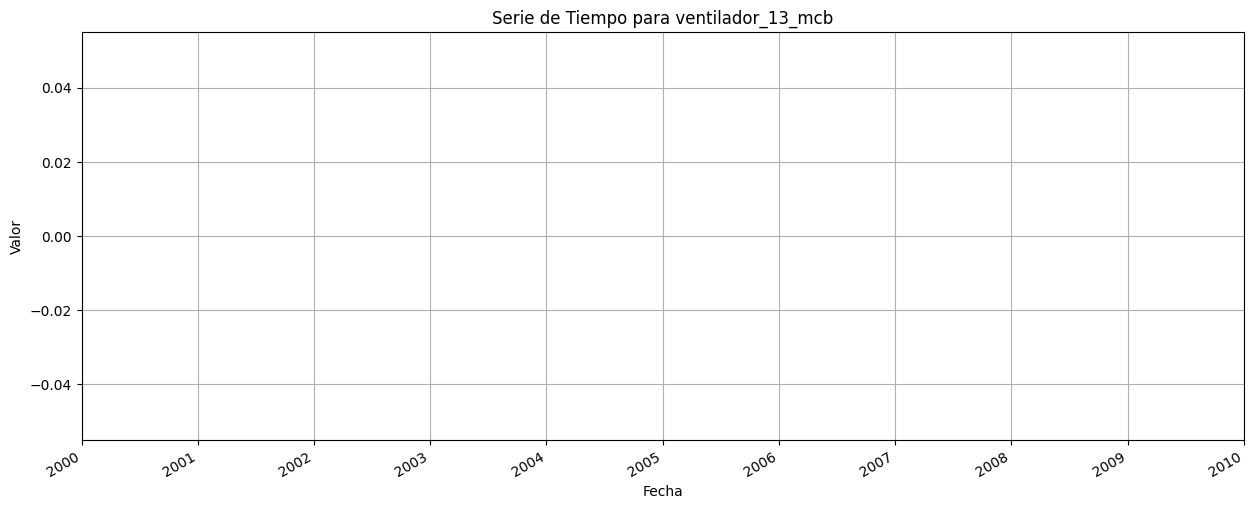


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'cambio_tan_fase_1' ###
############################################################
Total de registros: 3100
Valores nulos: 1012 (32.65%)

--- Resumen Estadístico de 'value' ---
count    2088.000000
mean       -0.002407
std         0.003070
min        -0.013087
25%        -0.003102
50%        -0.000778
75%        -0.000367
max         0.000000


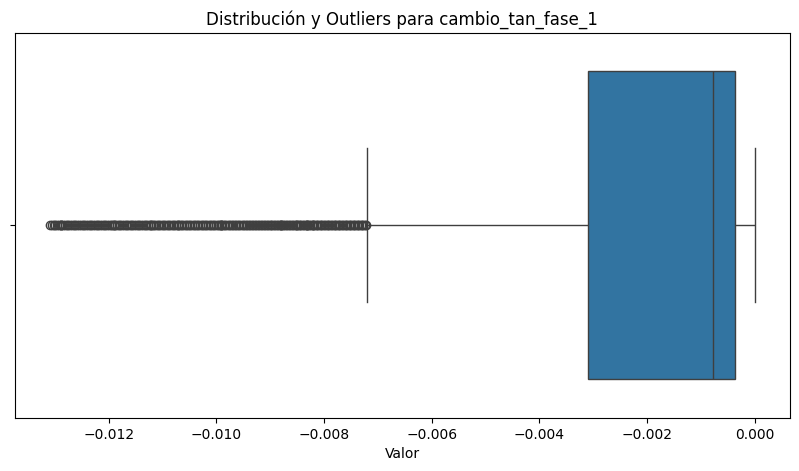

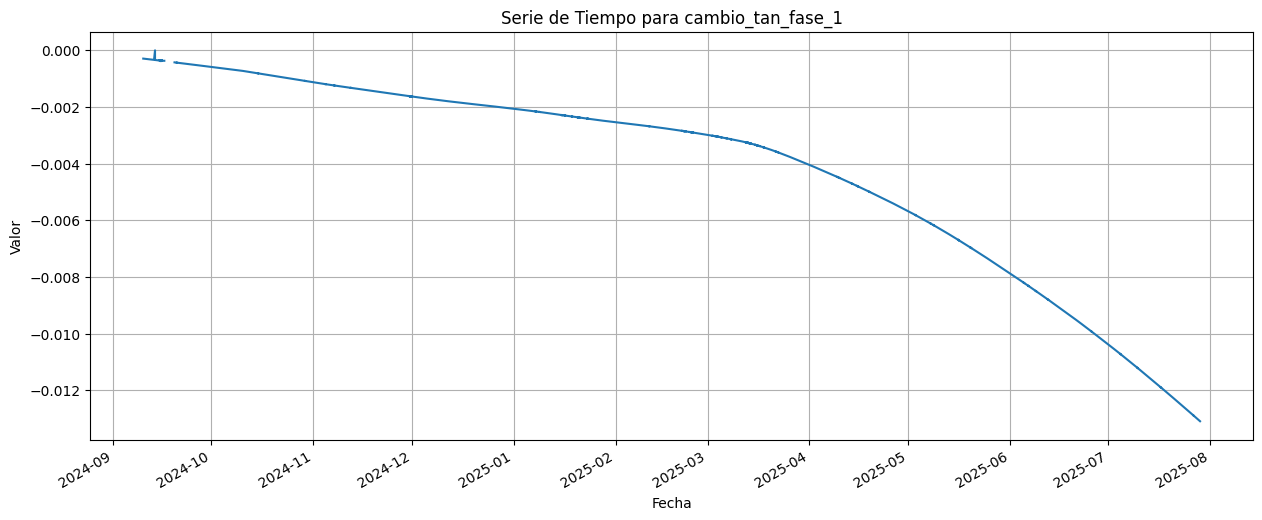


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'temperatura_aceite' ###
############################################################
Total de registros: 12638
Valores nulos: 916 (7.25%)

--- Resumen Estadístico de 'value' ---
count    11722.000000
mean        46.865125
std          7.392384
min          0.000000
25%         41.200001
50%         46.500000
75%         52.299999
max         67.000000


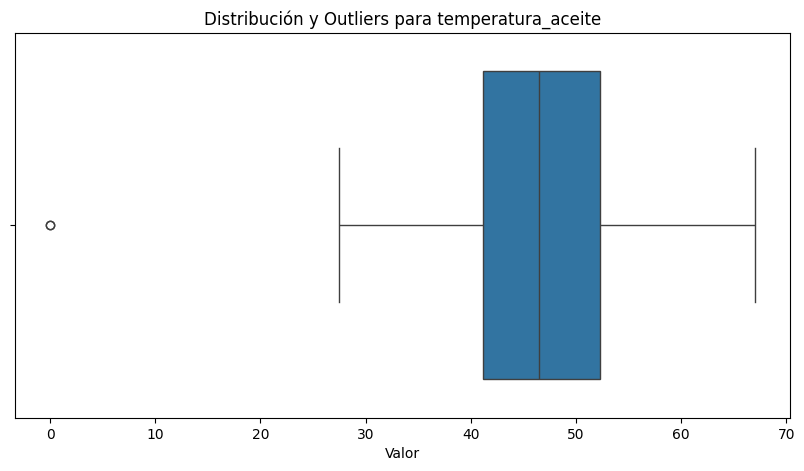

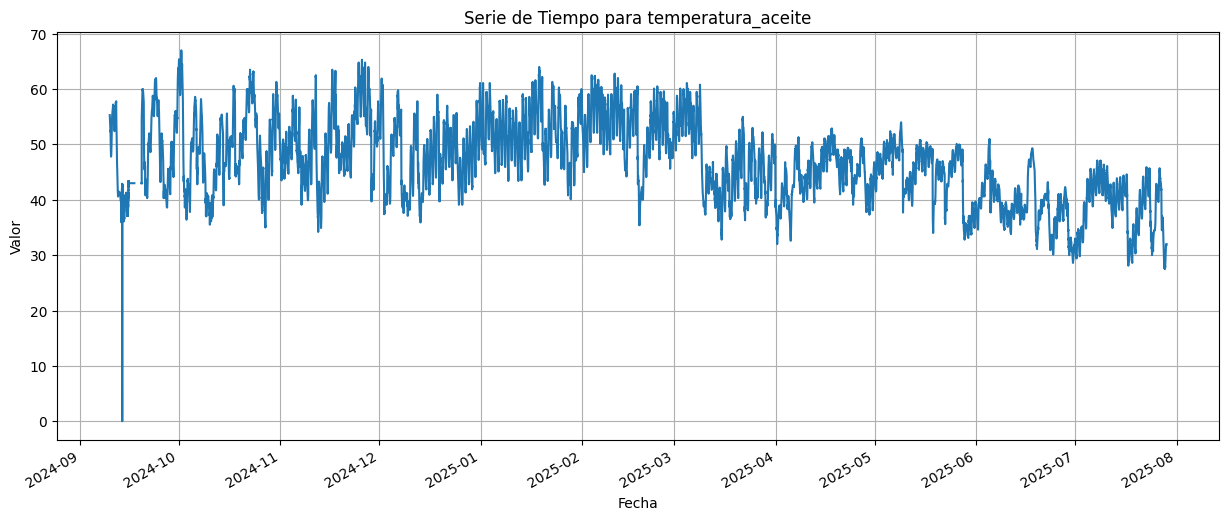


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'emergencia_enfriamiento_fallido' ###
############################################################
Total de registros: 2966
Valores nulos: 1002 (33.78%)

--- Resumen Estadístico de 'value' ---
count    1964.000000
mean      995.305318
std        39.389436
min         0.000000
25%      1000.000000
50%      1000.000000
75%      1000.000000
max      1000.000000


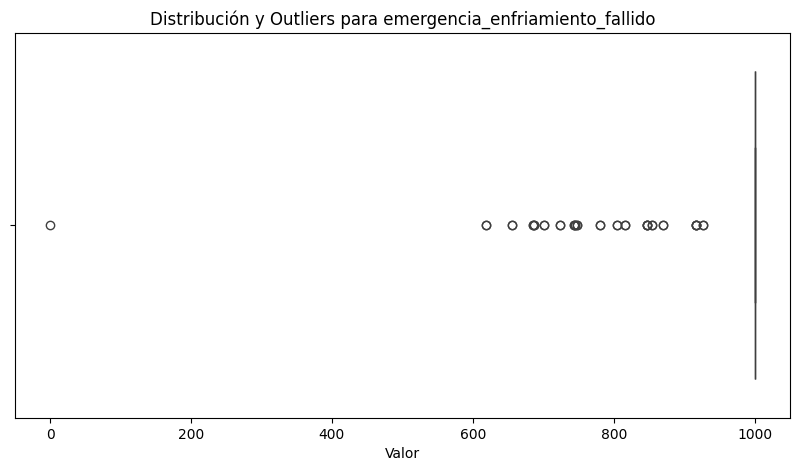

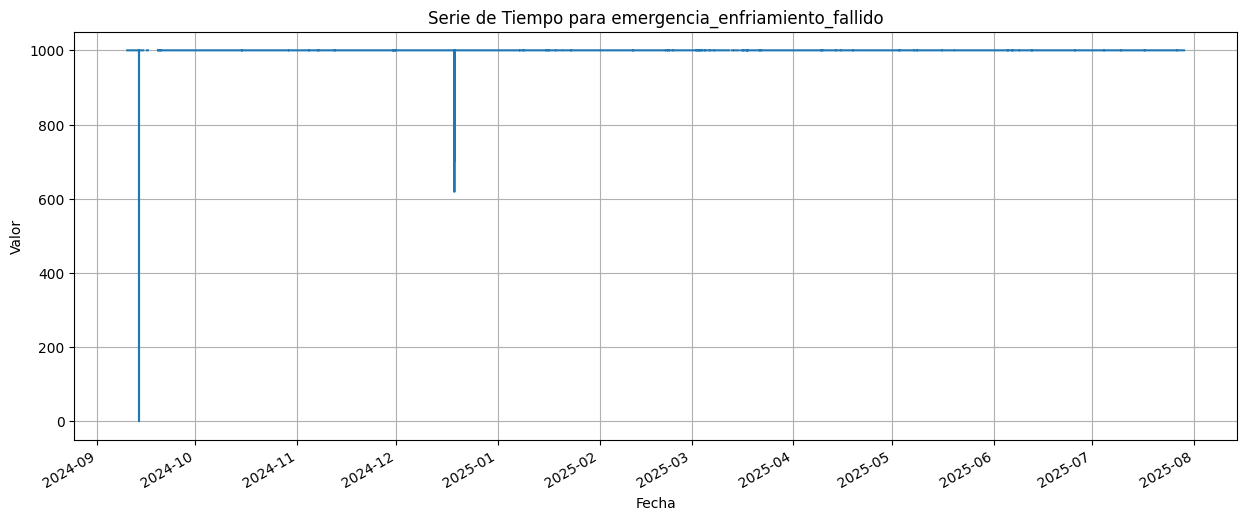


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'ventilador_10_mcb' ###
############################################################
Total de registros: 2935
Valores nulos: 2935 (100.00%)

--- Resumen Estadístico de 'value' ---
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN


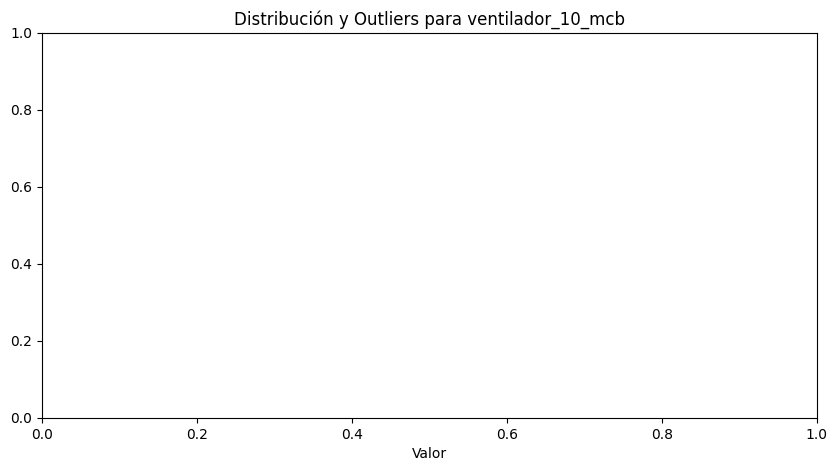

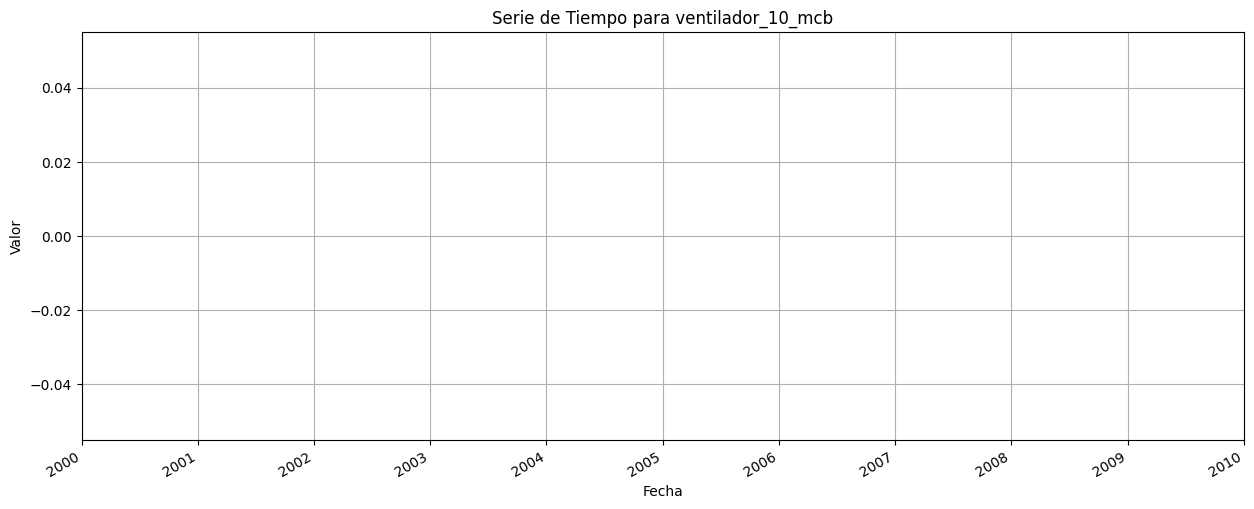


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'nivel_aceite_tanque_principal_min' ###
############################################################
Total de registros: 2928
Valores nulos: 2928 (100.00%)

--- Resumen Estadístico de 'value' ---
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN


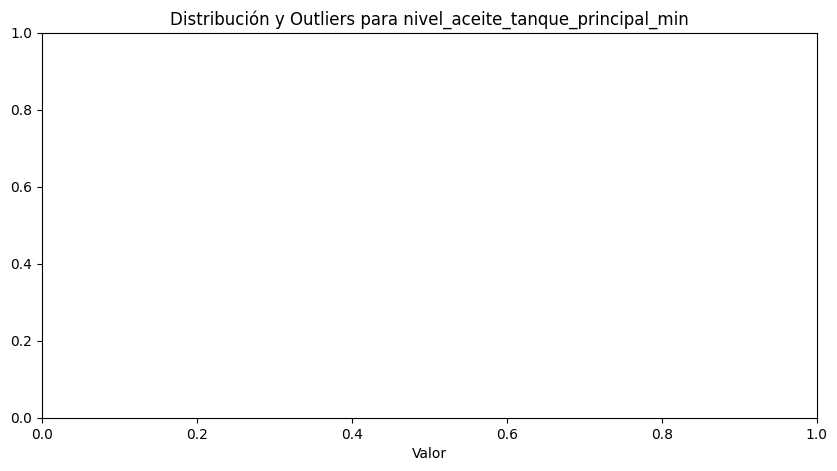

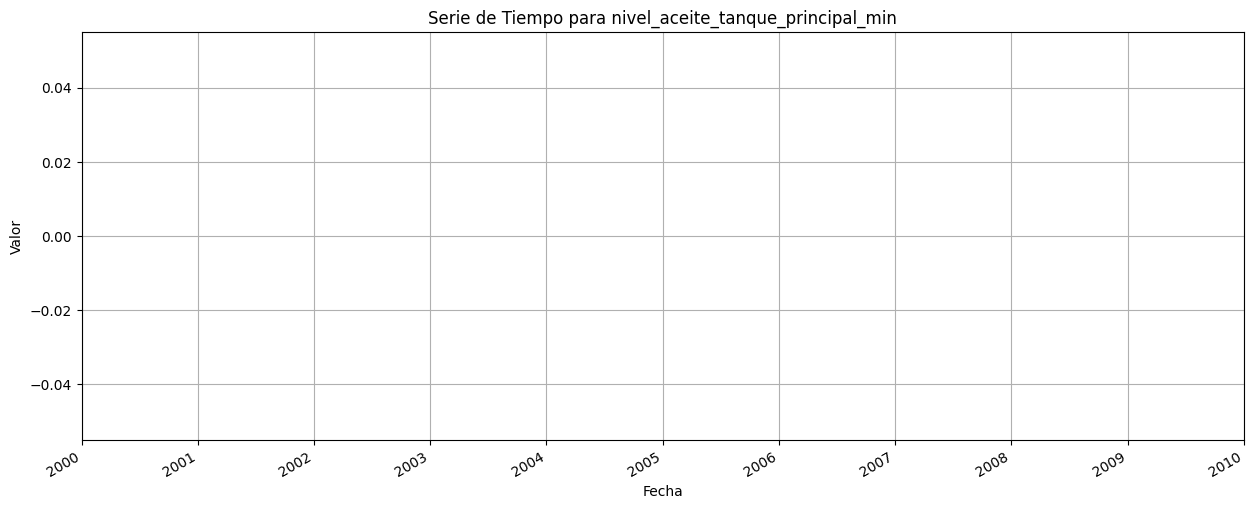


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'buchholz_desconectado' ###
############################################################
Total de registros: 2940
Valores nulos: 2940 (100.00%)

--- Resumen Estadístico de 'value' ---
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN


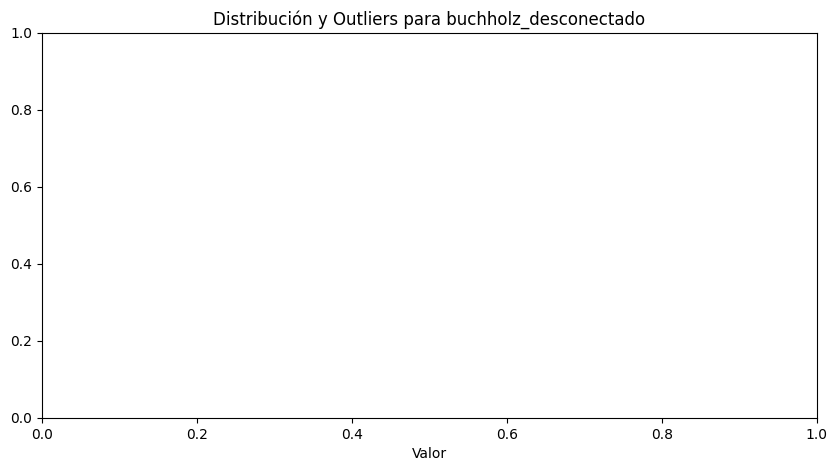

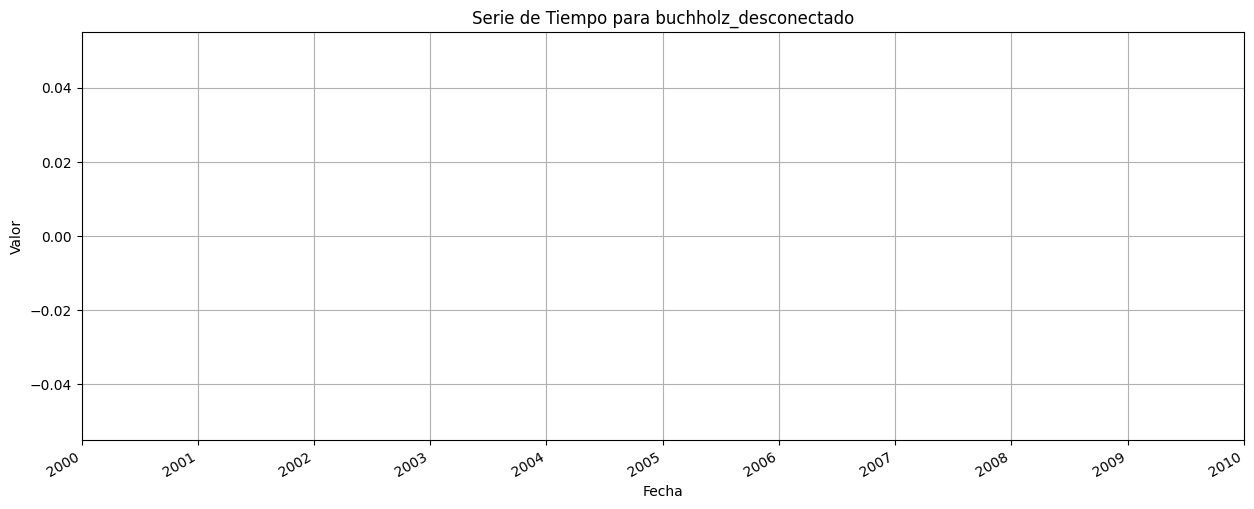


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'ventilador_4_mcb' ###
############################################################
Total de registros: 2858
Valores nulos: 2858 (100.00%)

--- Resumen Estadístico de 'value' ---
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN


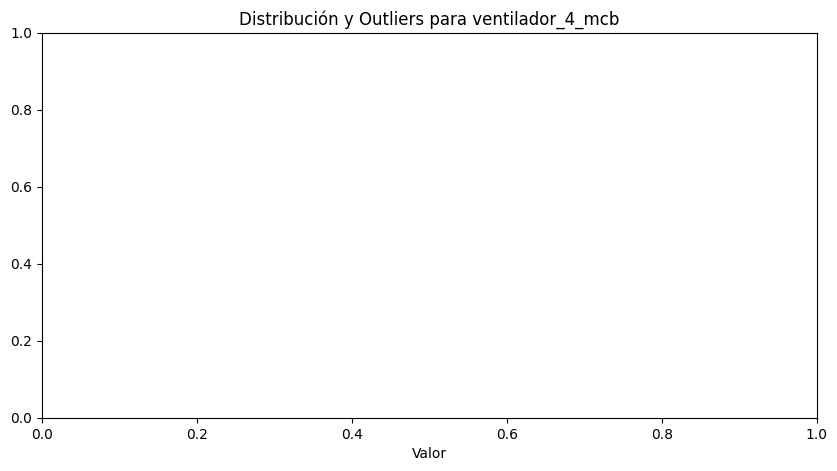

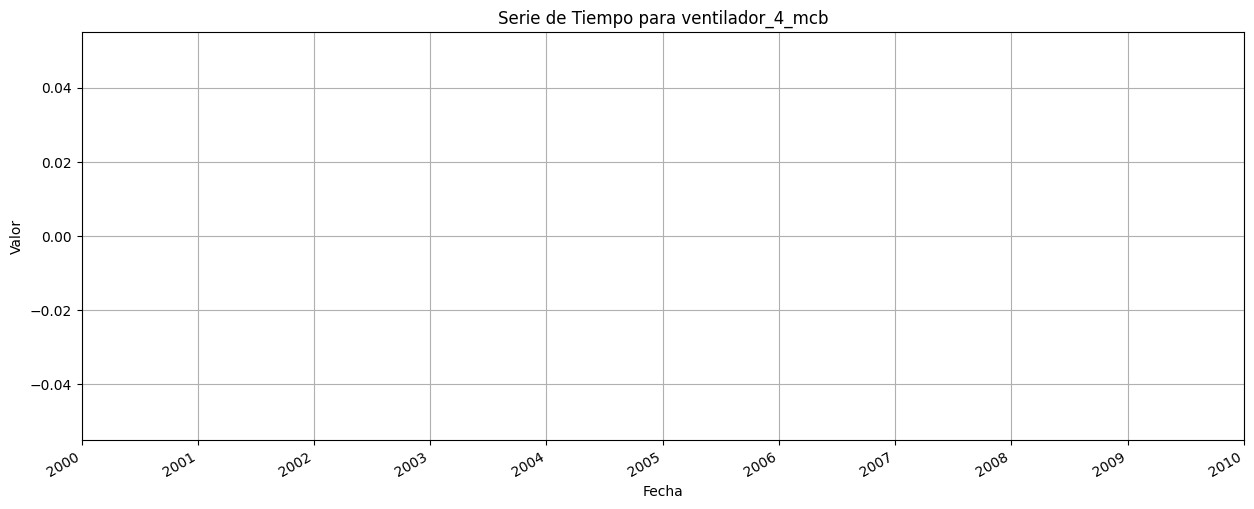


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'gradient_etano' ###
############################################################
Total de registros: 2837
Valores nulos: 945 (33.31%)

--- Resumen Estadístico de 'value' ---
count    1892.000000
mean        0.003898
std         0.012978
min        -0.051926
25%        -0.003184
50%         0.005334
75%         0.012158
max         0.052075


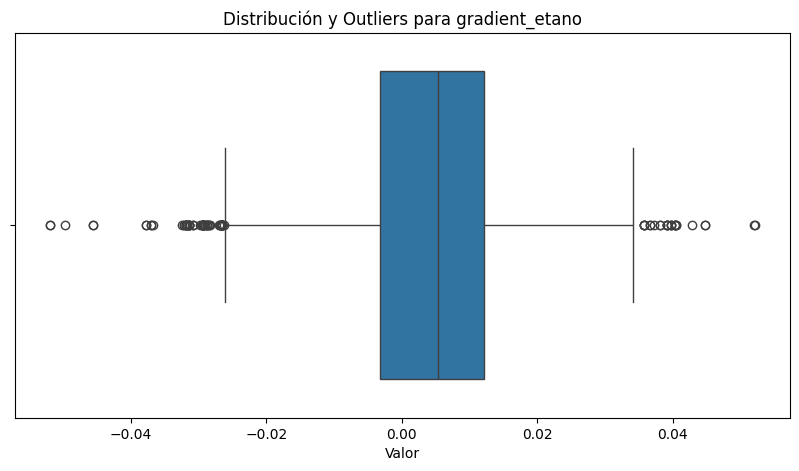

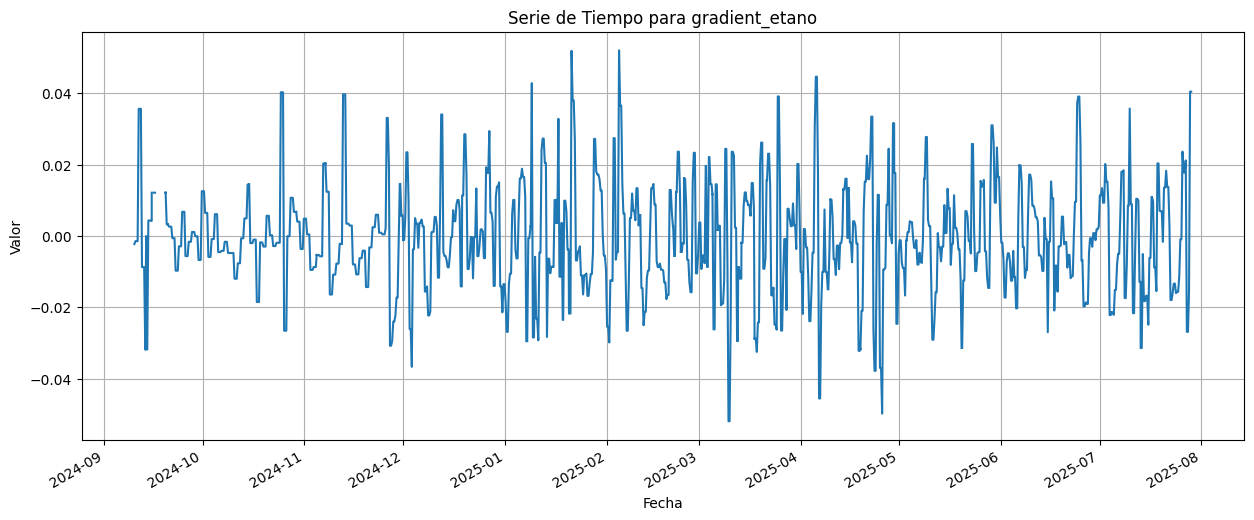


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'voltaje_fase_2_fase_3' ###
############################################################
Total de registros: 4716876
Valores nulos: 889 (0.02%)

--- Resumen Estadístico de 'value' ---
count    4.715987e+06
mean     2.243142e+02
std      4.332641e+00
min      0.000000e+00
25%      2.217086e+02
50%      2.245502e+02
75%      2.272502e+02
max      3.517590e+02


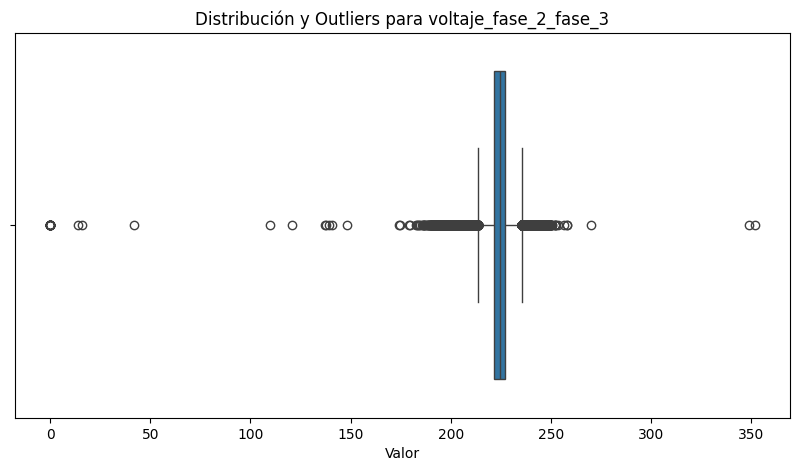

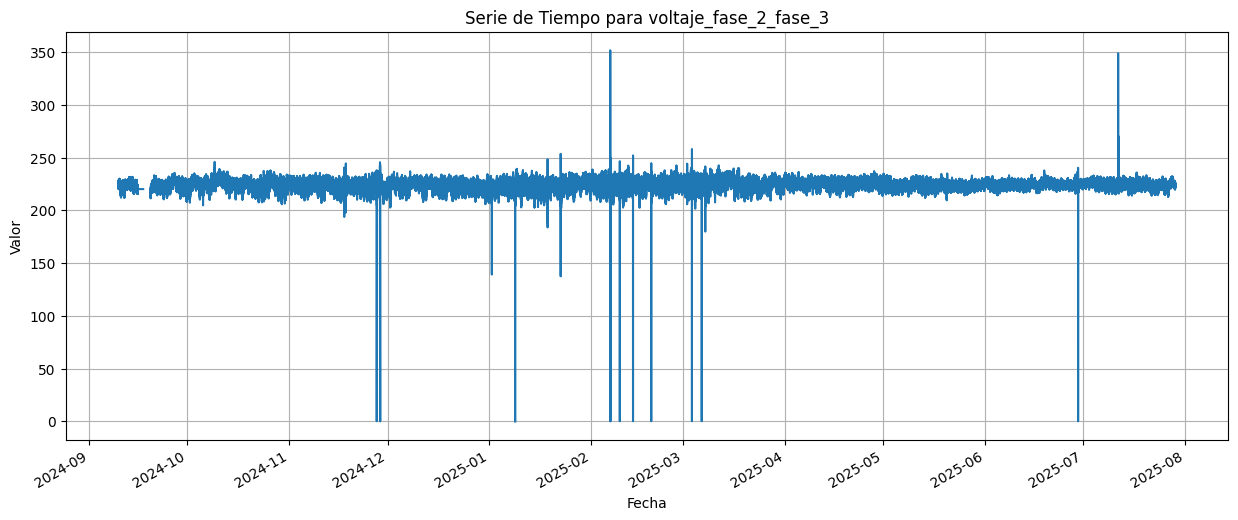


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'min_resistencia_termica_horaria' ###
############################################################
Total de registros: 971
Valores nulos: 8 (0.82%)

--- Resumen Estadístico de 'value' ---
count    963.000000
mean       1.289707
std        1.251207
min        0.000000
25%        0.444140
50%        0.511377
75%        2.171586
max        4.732143


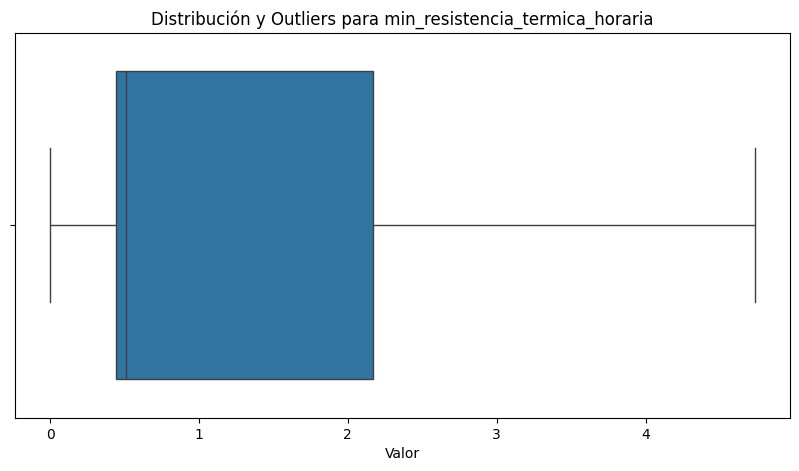

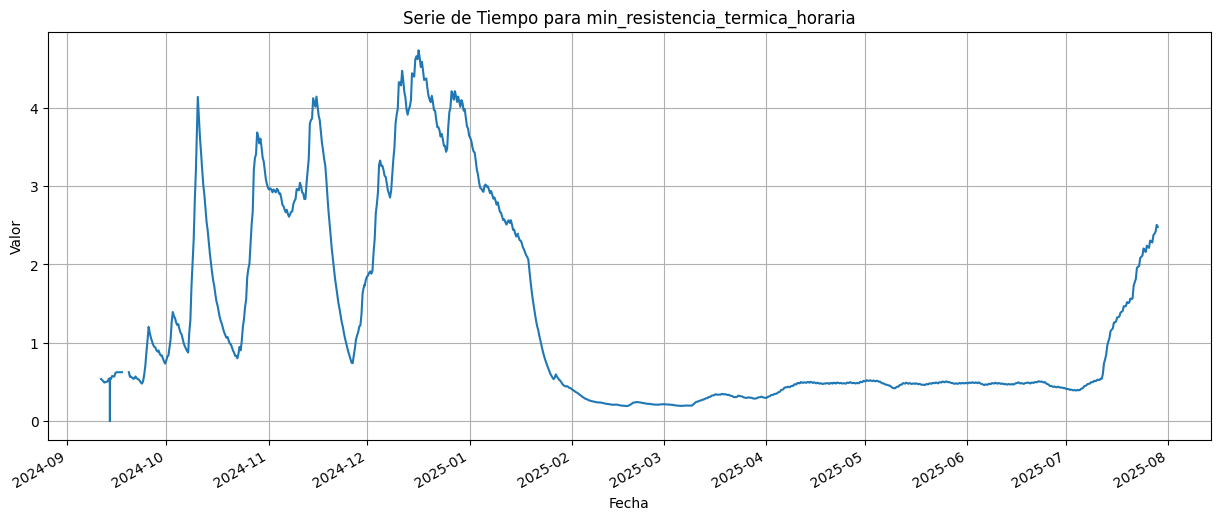


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'monitores_falla_fuente_alimentacion' ###
############################################################
Total de registros: 2944
Valores nulos: 2944 (100.00%)

--- Resumen Estadístico de 'value' ---
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN


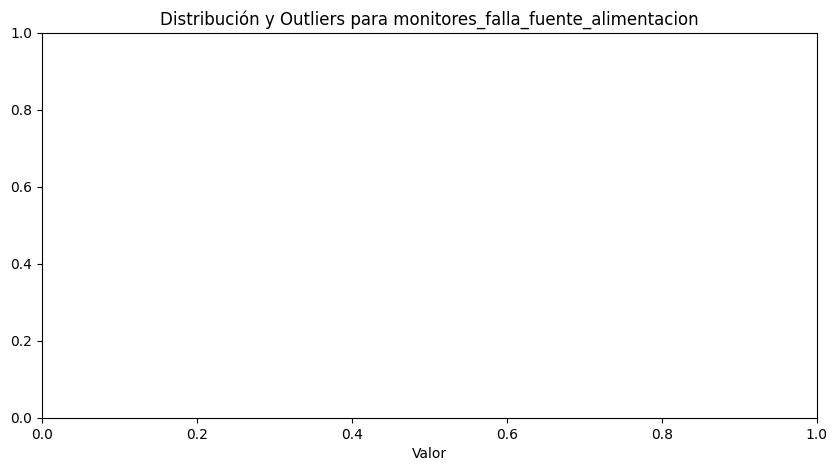

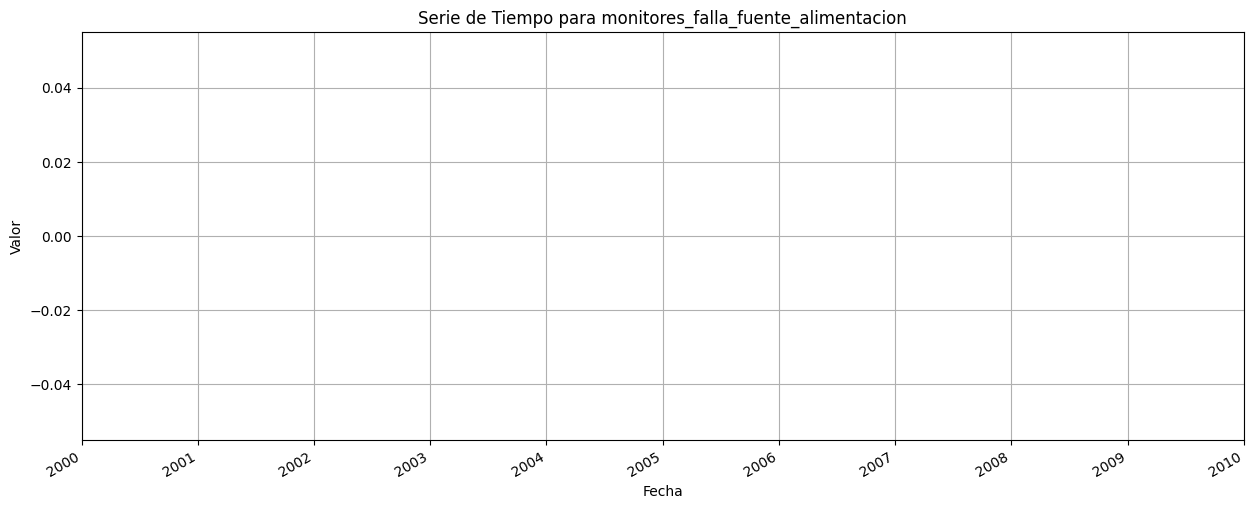


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'metano' ###
############################################################
Total de registros: 3280
Valores nulos: 986 (30.06%)

--- Resumen Estadístico de 'value' ---
count    2294.000000
mean        8.027884
std         1.312710
min         0.000000
25%         6.532619
50%         8.010378
75%         9.204815
max        11.220608


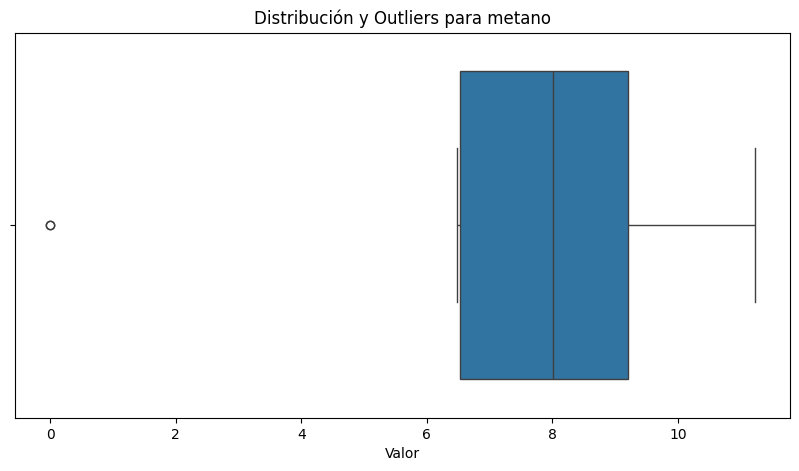

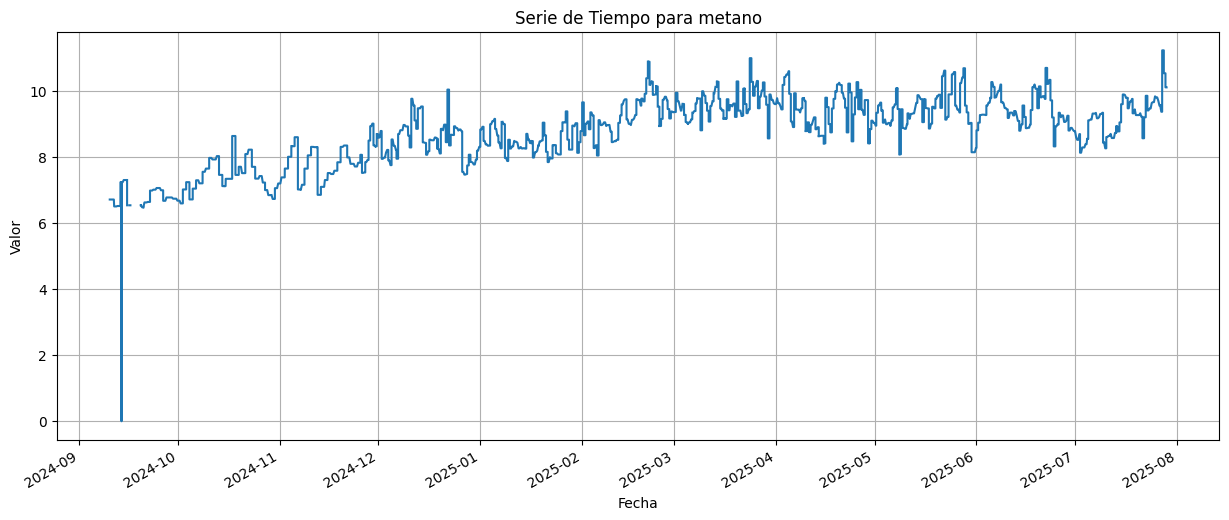


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'actividad_agua' ###
############################################################
Total de registros: 3275
Valores nulos: 916 (27.97%)

--- Resumen Estadístico de 'value' ---
count    2359.000000
mean        1.603792
std         0.374719
min         0.000000
25%         1.282622
50%         1.700542
75%         1.883689
max         2.778697


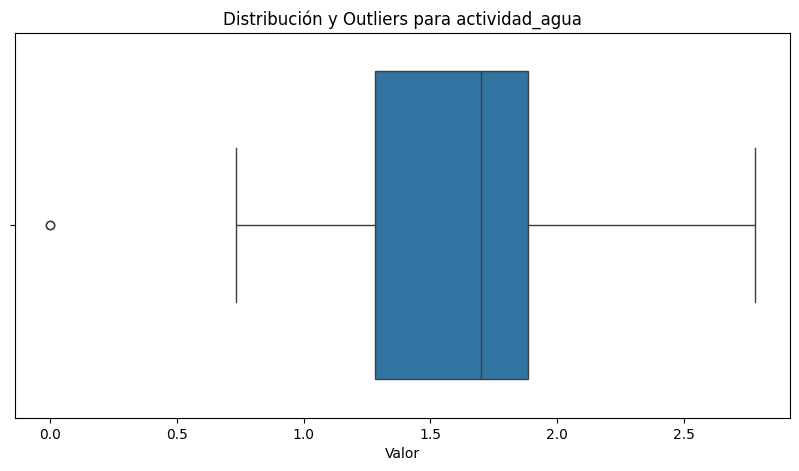

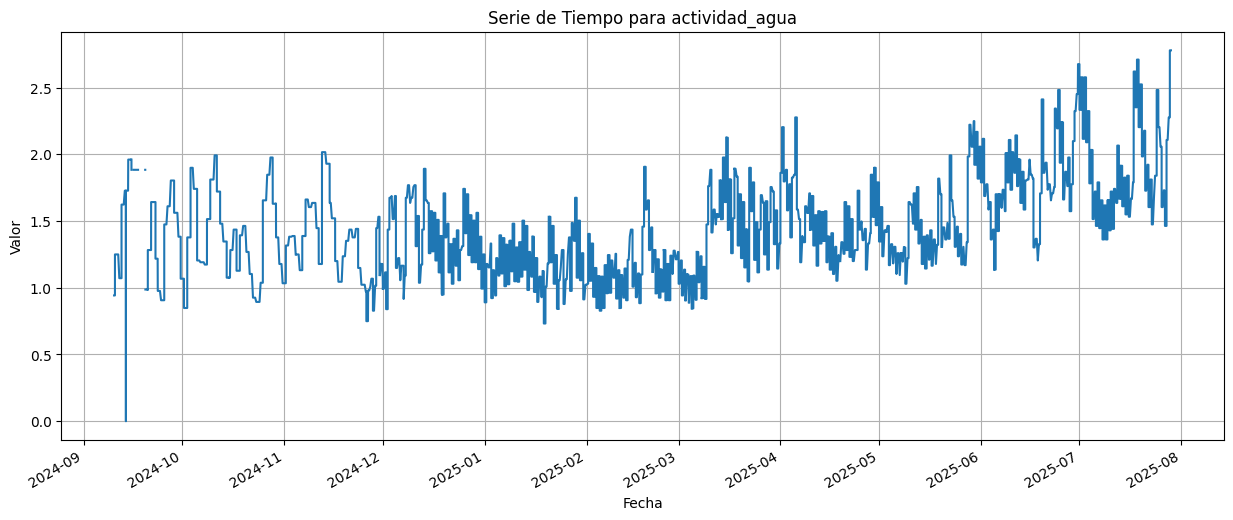


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'max_temperatura_hot_spot_horaria' ###
############################################################
Total de registros: 4402
Valores nulos: 8 (0.18%)

--- Resumen Estadístico de 'value' ---
count    4394.000000
mean       53.382004
std         9.442044
min        28.548986
25%        45.844118
50%        52.701237
75%        60.370160
max        80.383949


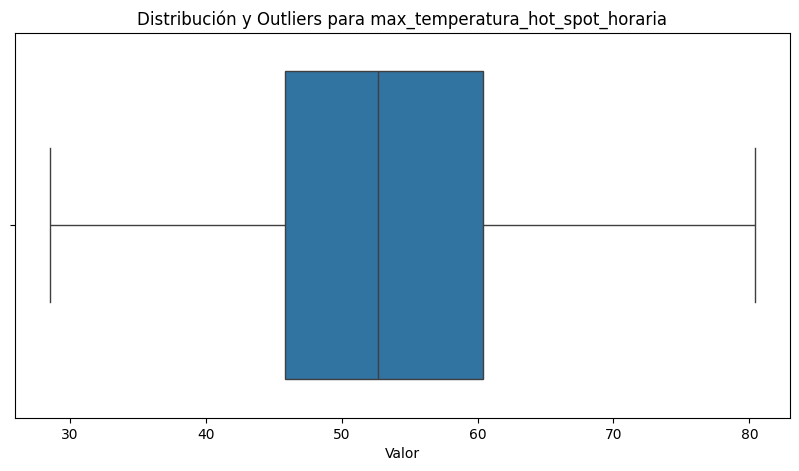

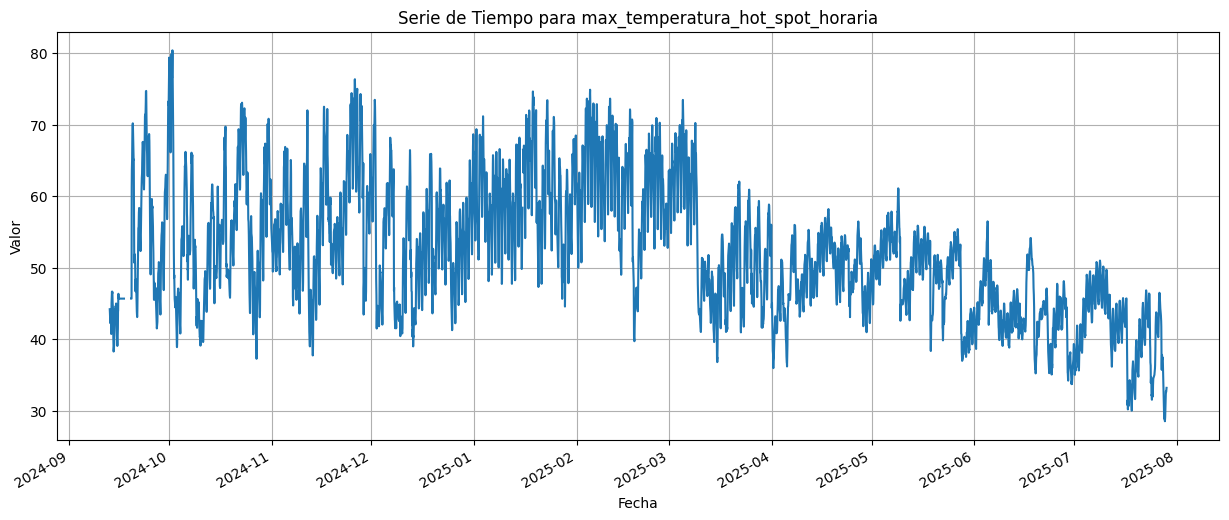


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'tasa_envejecimiento_30d' ###
############################################################
Total de registros: 2955
Valores nulos: 1012 (34.25%)

--- Resumen Estadístico de 'value' ---
count    1943.000000
mean        0.006601
std         0.004459
min         0.000000
25%         0.003903
50%         0.003903
75%         0.010129
max         0.018885


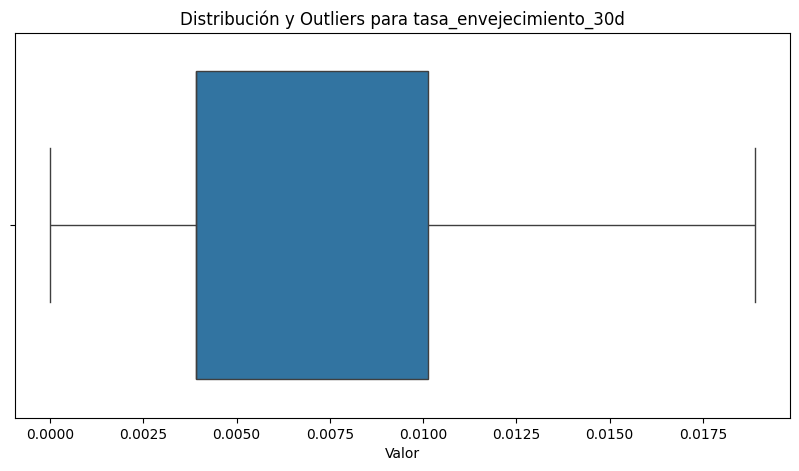

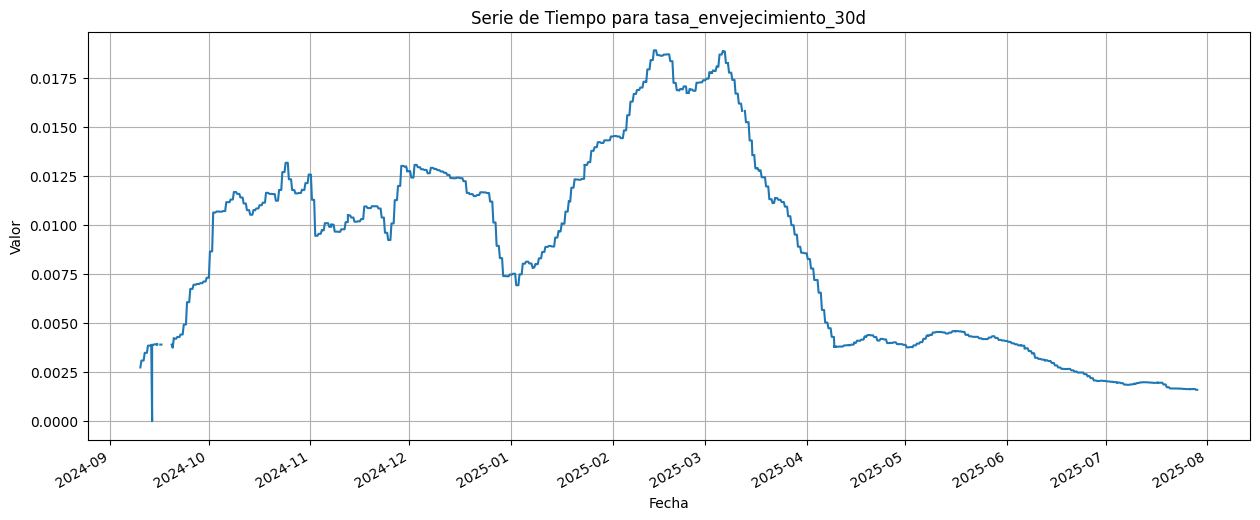


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'min_voltaje_fase_1' ###
############################################################
Total de registros: 37253
Valores nulos: 8 (0.02%)

--- Resumen Estadístico de 'value' ---
count    37245.000000
mean       123.020038
std          4.559121
min          0.000000
25%        121.254684
50%        123.275726
75%        124.981506
max        132.162476


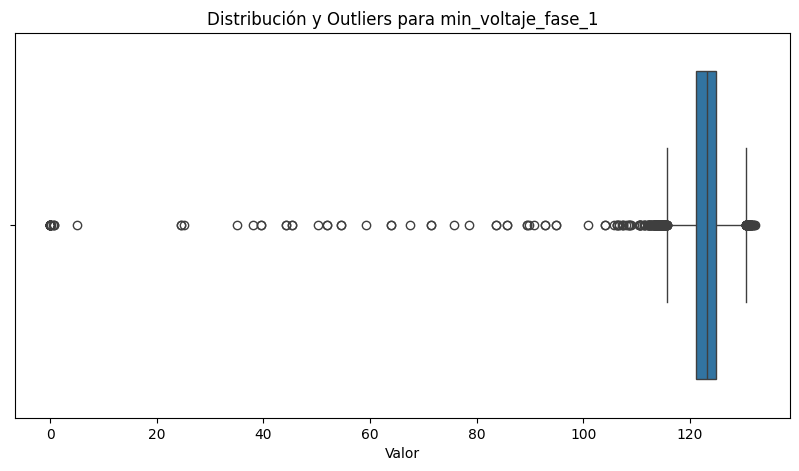

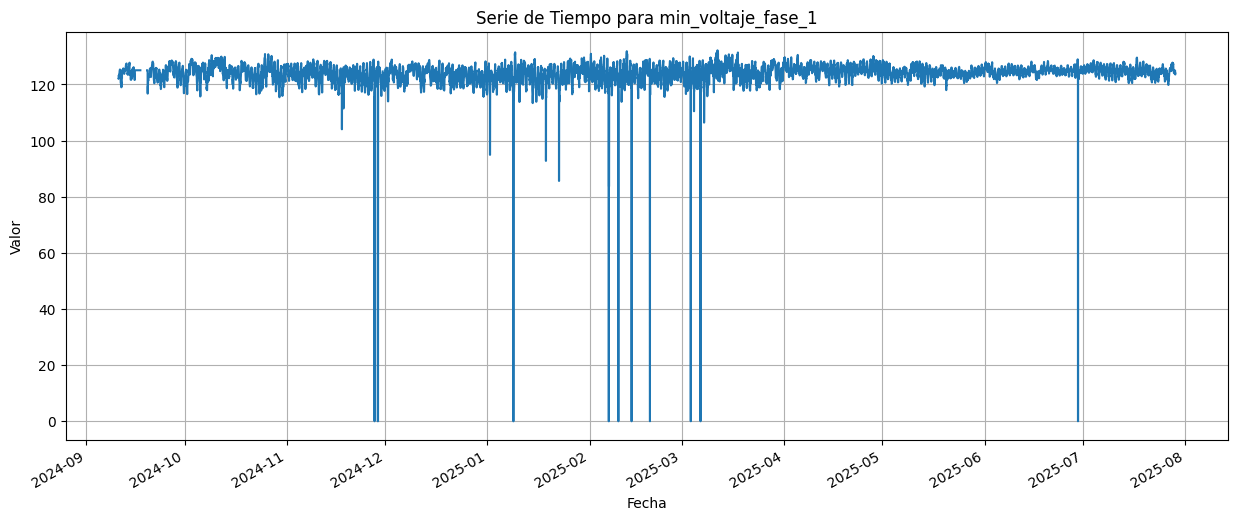


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'falla_fuente_alimentacion_vdc' ###
############################################################
Total de registros: 2942
Valores nulos: 2942 (100.00%)

--- Resumen Estadístico de 'value' ---
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN


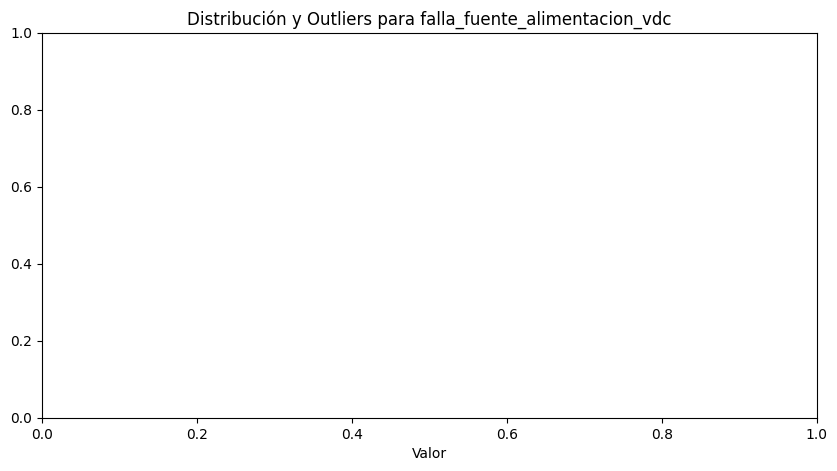

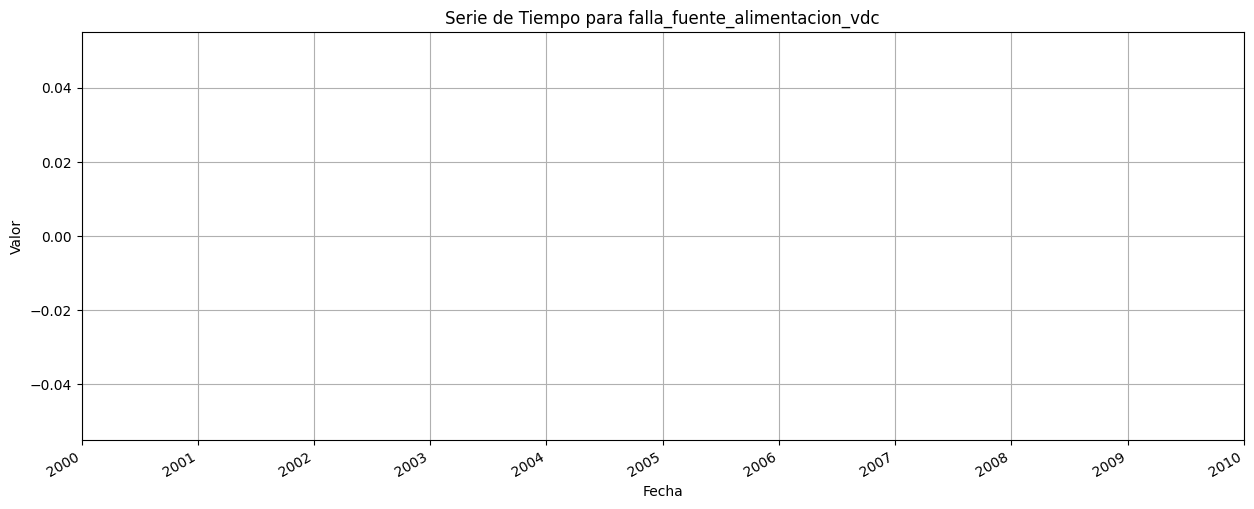


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'voltaje_fase_3' ###
############################################################
Total de registros: 3313342
Valores nulos: 889 (0.03%)

--- Resumen Estadístico de 'value' ---
count    3.312453e+06
mean     1.287335e+02
std      2.563239e+00
min      0.000000e+00
25%      1.271212e+02
50%      1.288405e+02
75%      1.304527e+02
max      1.521753e+02


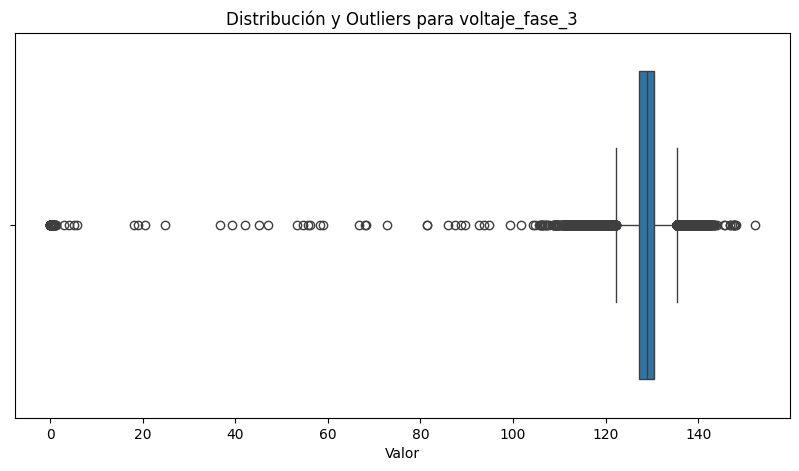

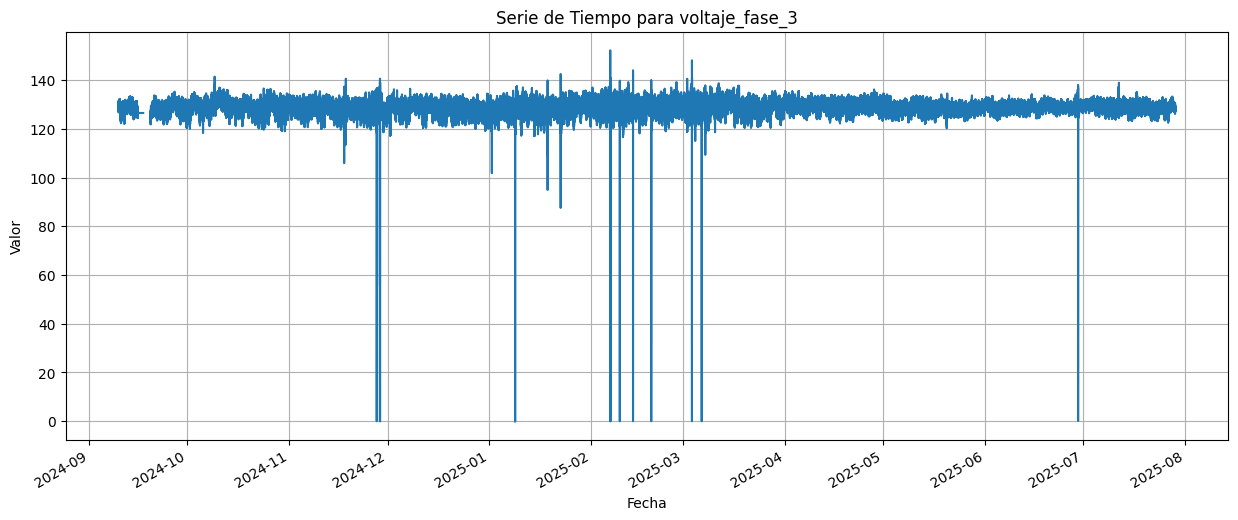


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'ruptura_membrana_relay' ###
############################################################
Total de registros: 2888
Valores nulos: 2888 (100.00%)

--- Resumen Estadístico de 'value' ---
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN


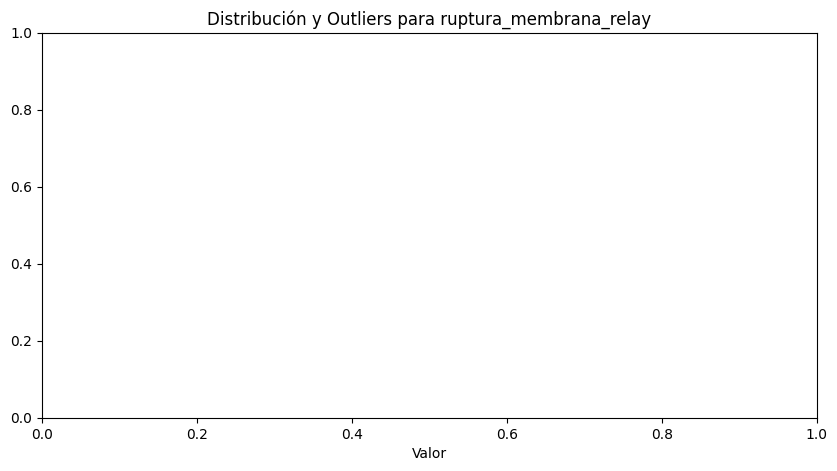

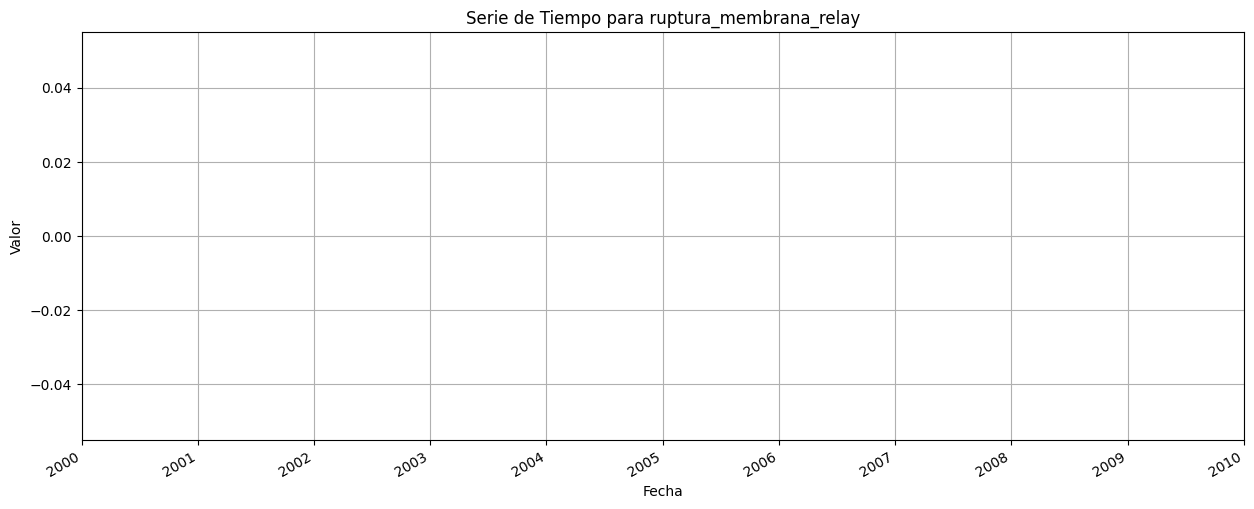


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'voltaje_fase_1_fase_2' ###
############################################################
Total de registros: 4793024
Valores nulos: 889 (0.02%)

--- Resumen Estadístico de 'value' ---
count    4.792135e+06
mean     2.218876e+02
std      4.398477e+00
min      0.000000e+00
25%      2.192370e+02
50%      2.221414e+02
75%      2.248353e+02
max      3.055100e+02


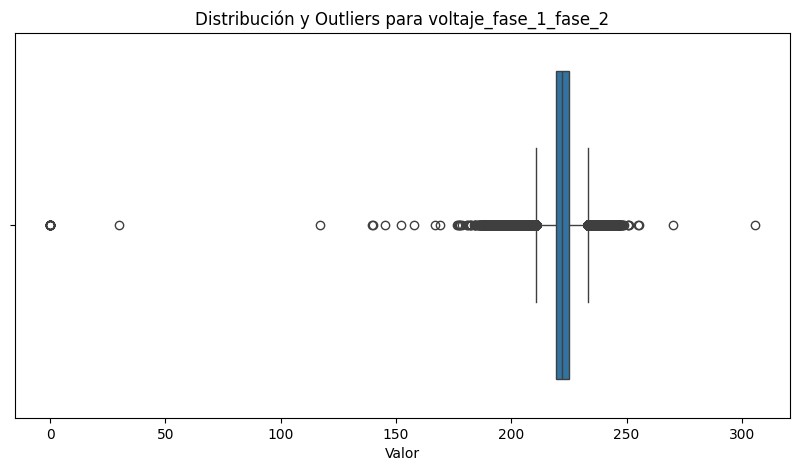

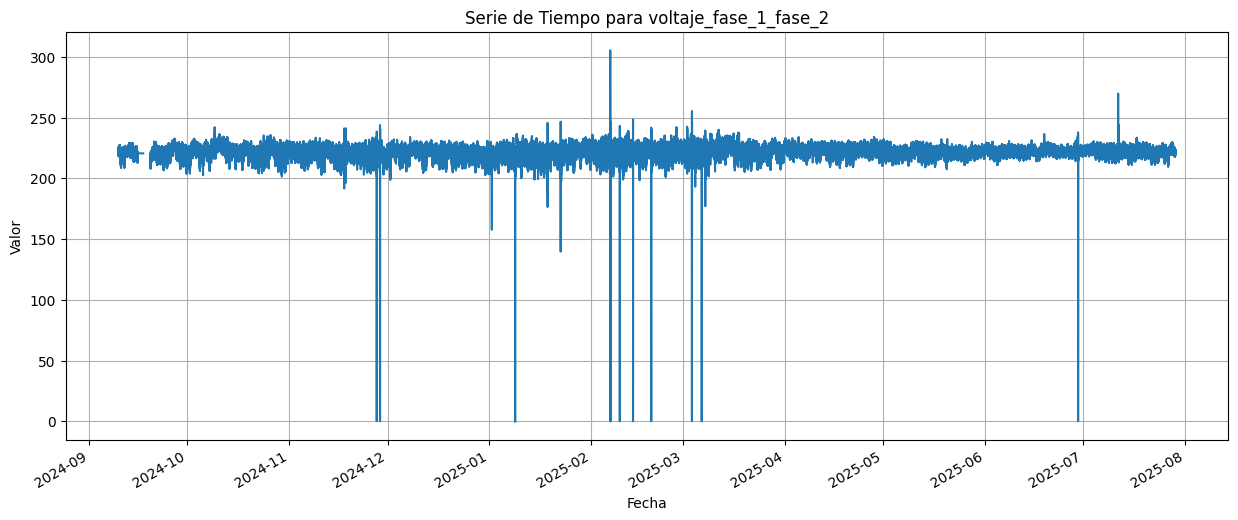


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'ventilador_2' ###
############################################################
Total de registros: 2809
Valores nulos: 2809 (100.00%)

--- Resumen Estadístico de 'value' ---
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN


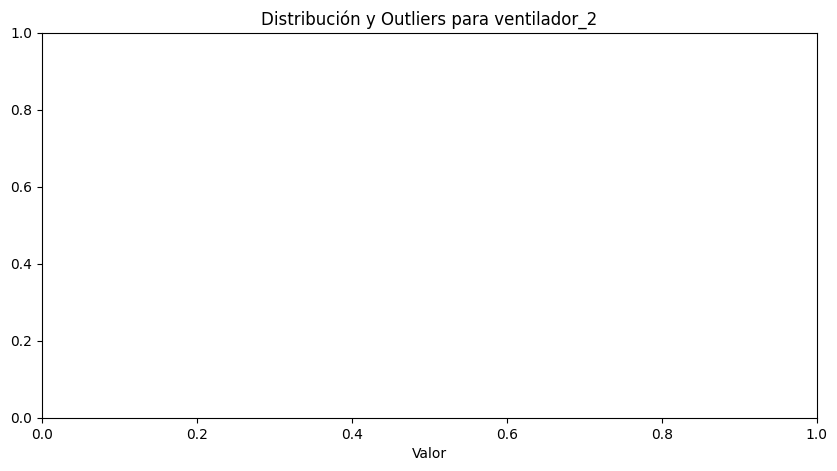

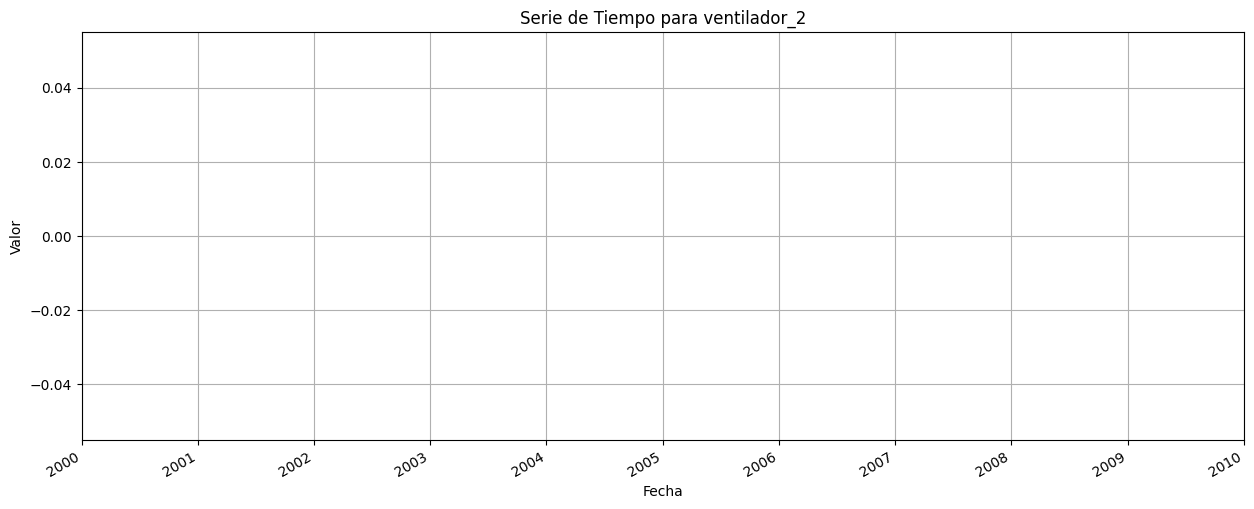


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'resistencia_termica' ###
############################################################
Total de registros: 2860
Valores nulos: 916 (32.03%)

--- Resumen Estadístico de 'value' ---
count    1944.000000
mean        0.977733
std         0.976107
min         0.000000
25%         0.488629
50%         0.625184
75%         0.627946
max         4.735212


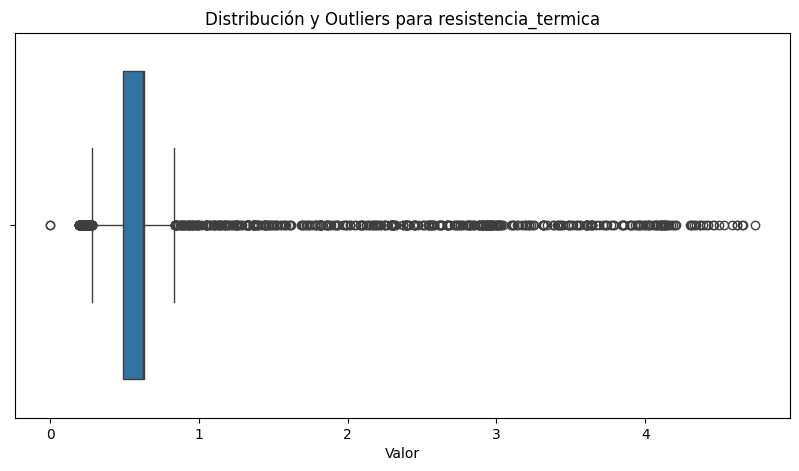

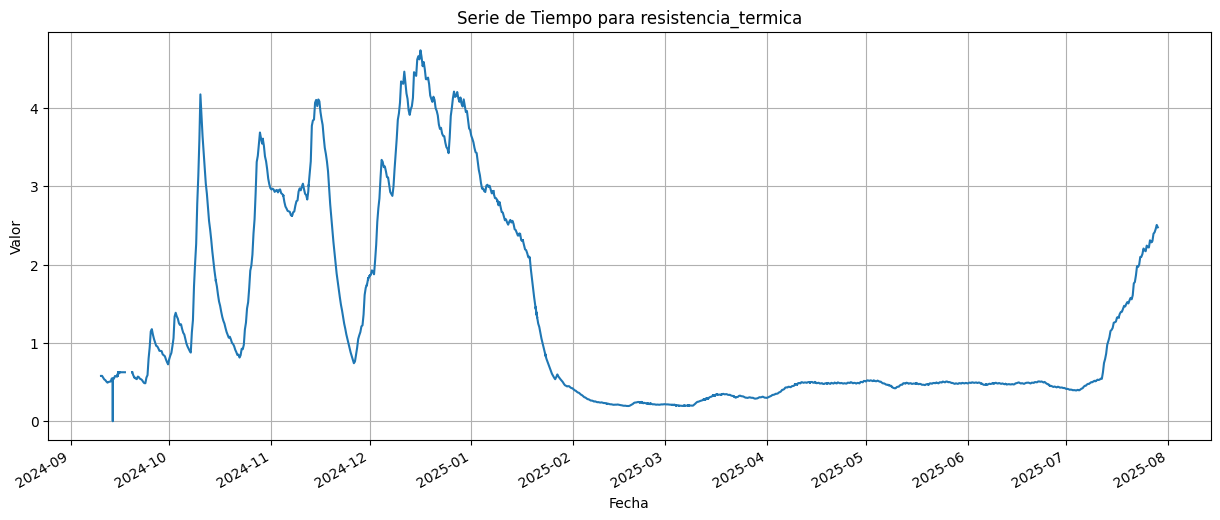


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'factor_carga_fase_2' ###
############################################################
Total de registros: 2516
Valores nulos: 588 (23.37%)

--- Resumen Estadístico de 'value' ---
count    1928.000000
mean        0.330955
std         0.151011
min         0.000000
25%         0.251816
50%         0.296131
75%         0.384008
max         1.102390


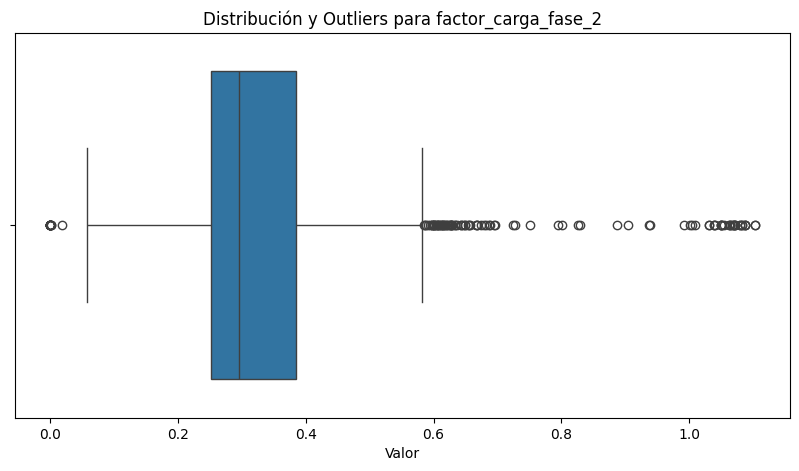

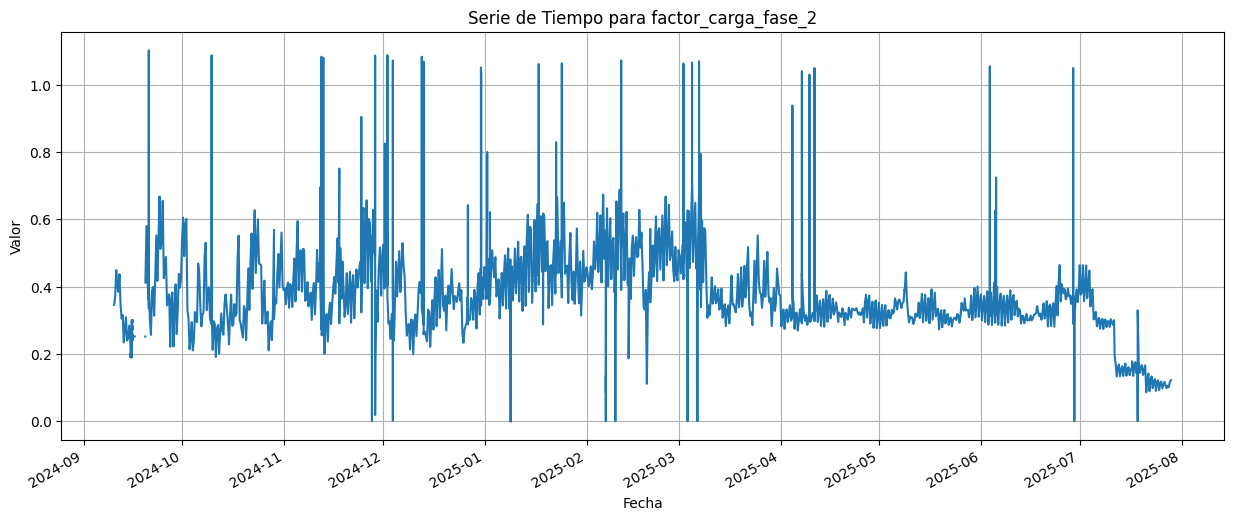


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'max_burbujeo' ###
############################################################
Total de registros: 3948
Valores nulos: 8 (0.20%)

--- Resumen Estadístico de 'value' ---
count    3940.000000
mean      172.538906
std         8.563082
min       147.376846
25%       166.587219
50%       172.173843
75%       178.928680
max       194.195450


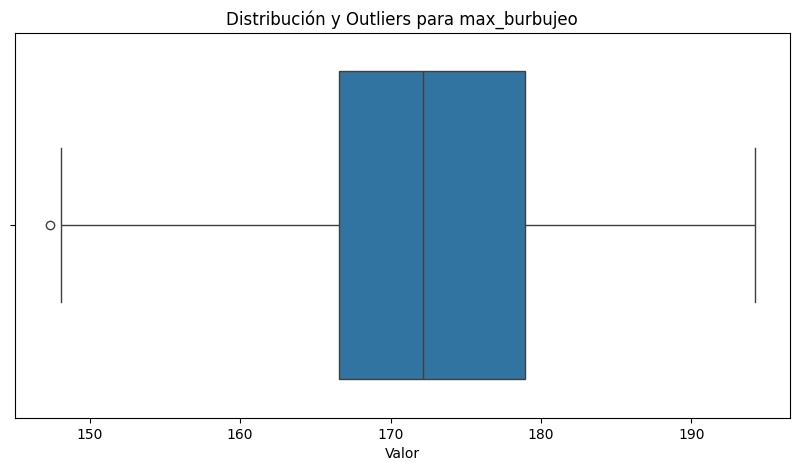

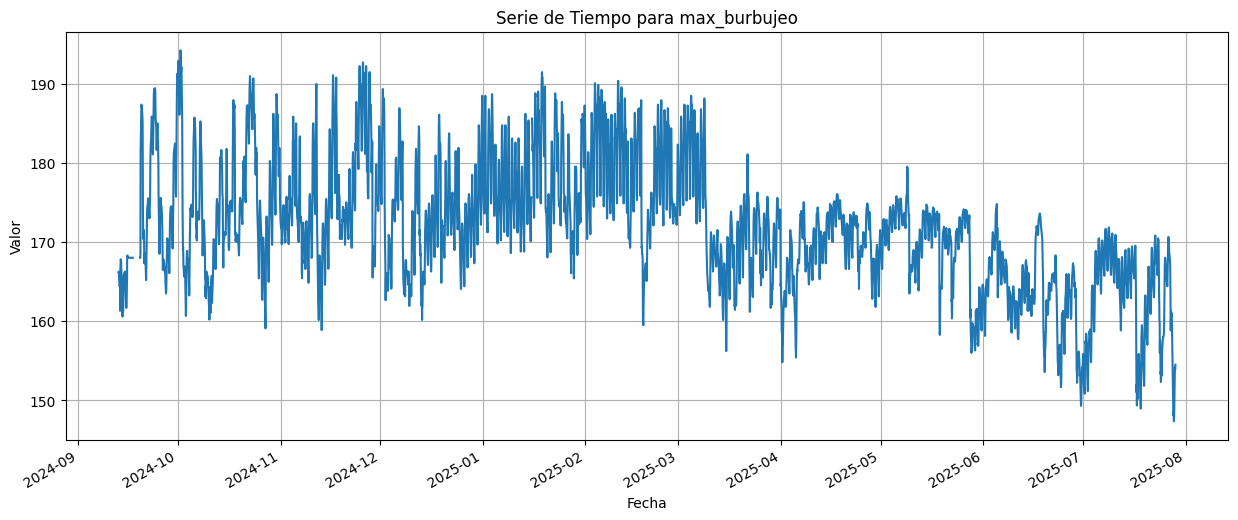


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'numero_sobrecargas_fase_2' ###
############################################################
Total de registros: 2972
Valores nulos: 1001 (33.68%)

--- Resumen Estadístico de 'value' ---
count    1971.000000
mean       30.049214
std        14.501745
min         0.000000
25%        18.000000
50%        20.000000
75%        45.000000
max        56.000000


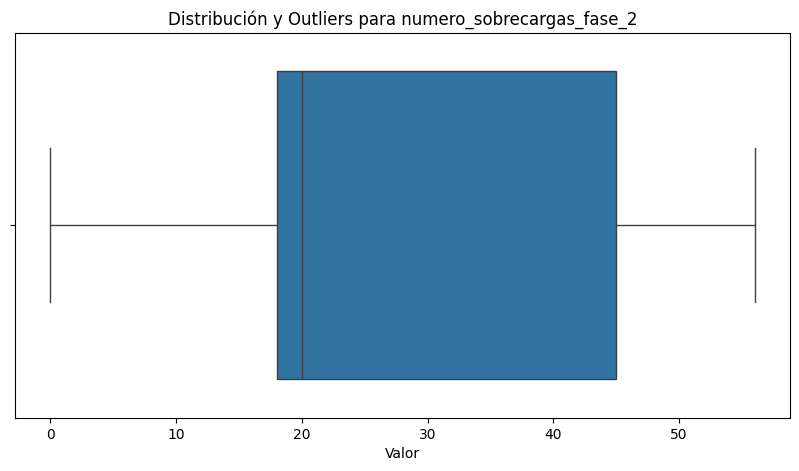

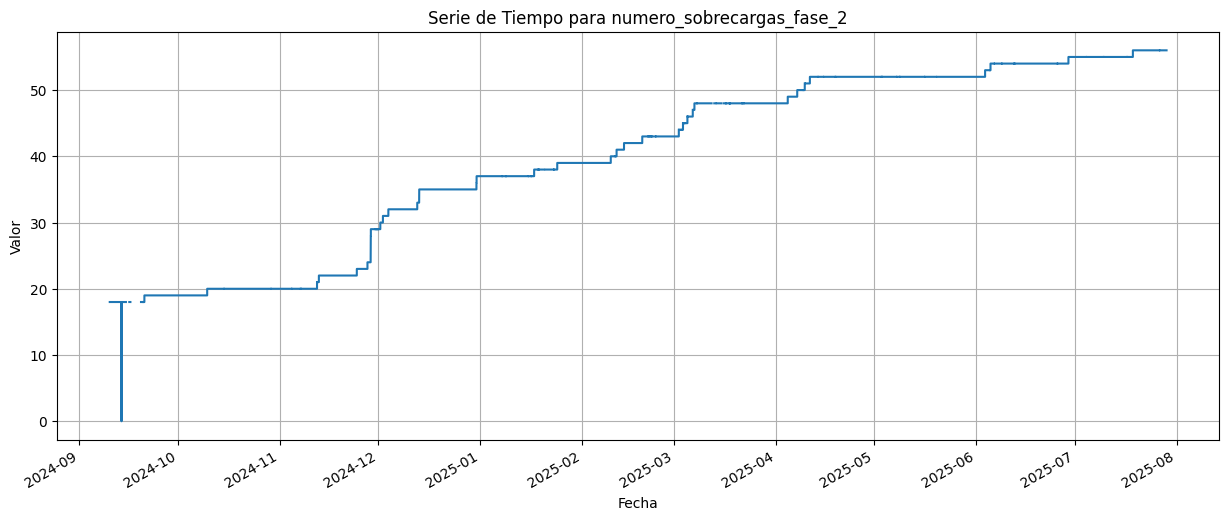


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'acetileno' ###
############################################################
Total de registros: 2929
Valores nulos: 1005 (34.31%)

--- Resumen Estadístico de 'value' ---
count    1924.000000
mean        0.003492
std         0.032459
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.612422


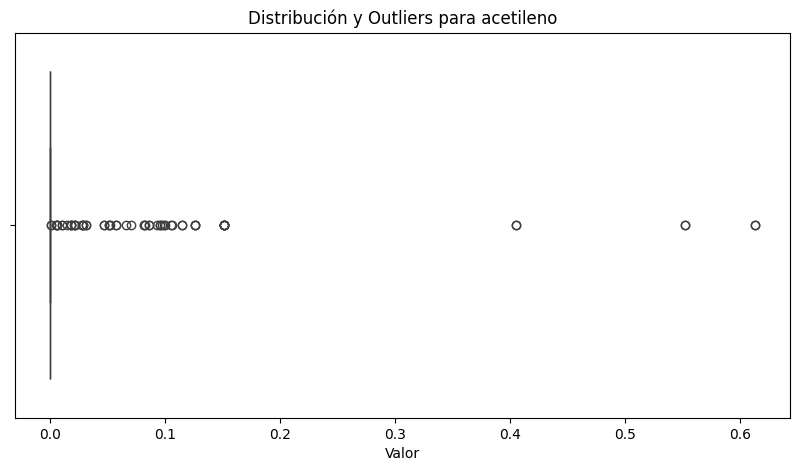

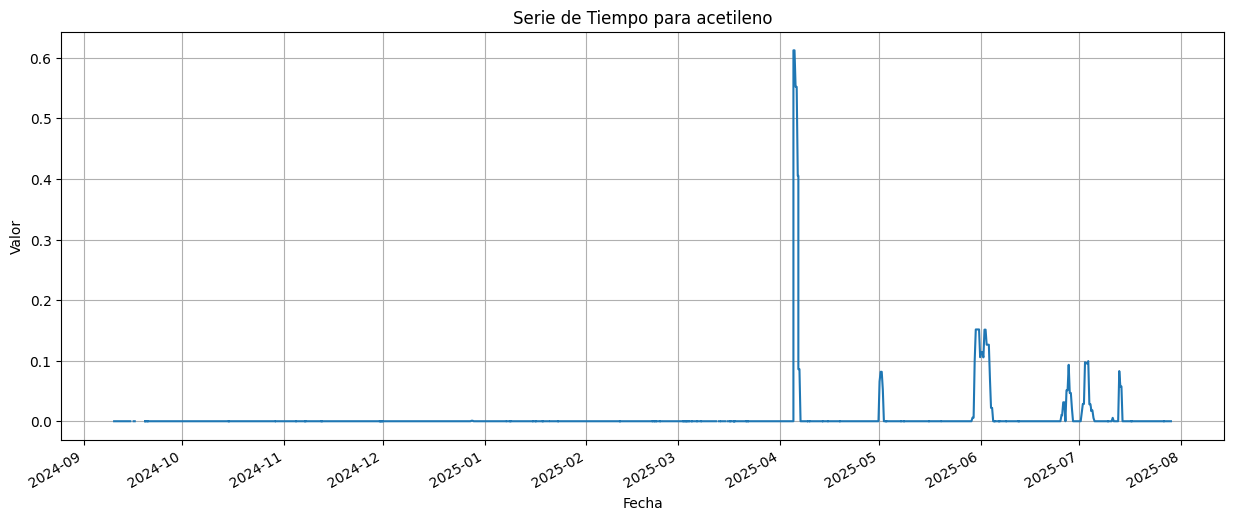


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'max_temperatura_ambiente_horaria' ###
############################################################
Total de registros: 4688
Valores nulos: 8 (0.17%)

--- Resumen Estadístico de 'value' ---
count    4680.000000
mean       25.635791
std         6.858742
min         3.100000
25%        21.165671
50%        25.799999
75%        30.400000
max        41.000000


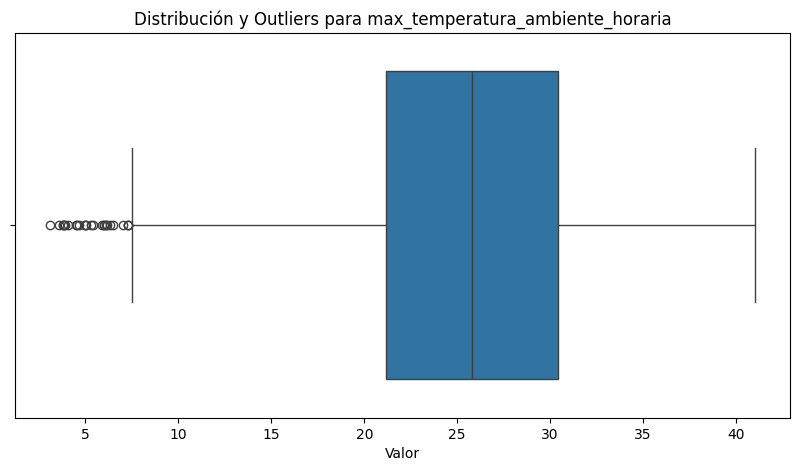

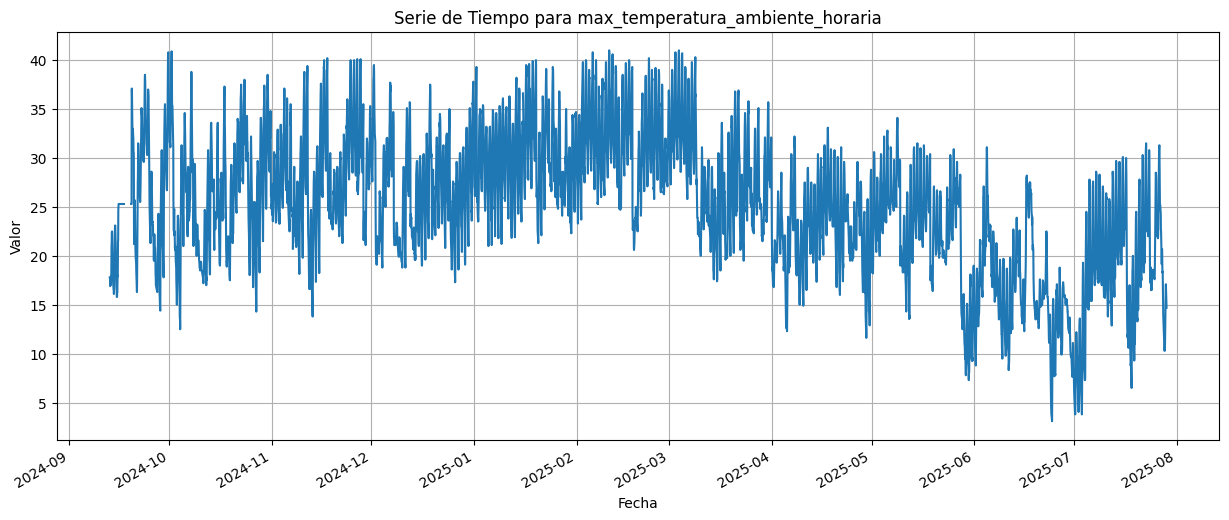


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'gradient_etileno' ###
############################################################
Total de registros: 2787
Valores nulos: 919 (32.97%)

--- Resumen Estadístico de 'value' ---
count    1868.000000
mean       -0.002613
std         0.006081
min        -0.040235
25%        -0.004776
50%        -0.004776
75%         0.000671
max         0.027521


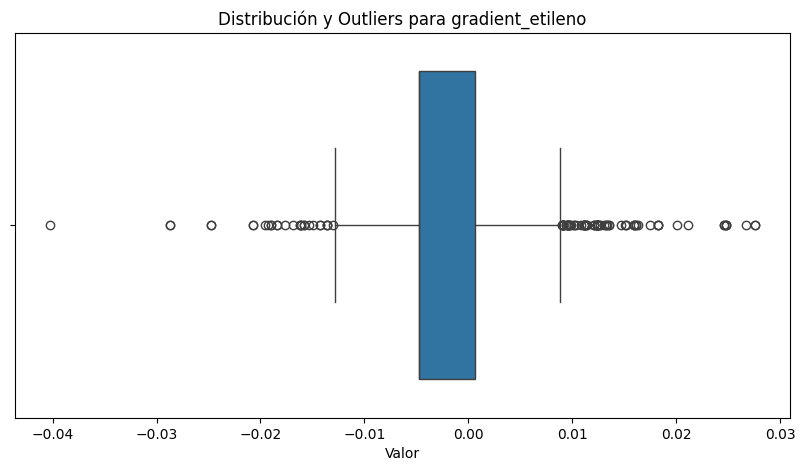

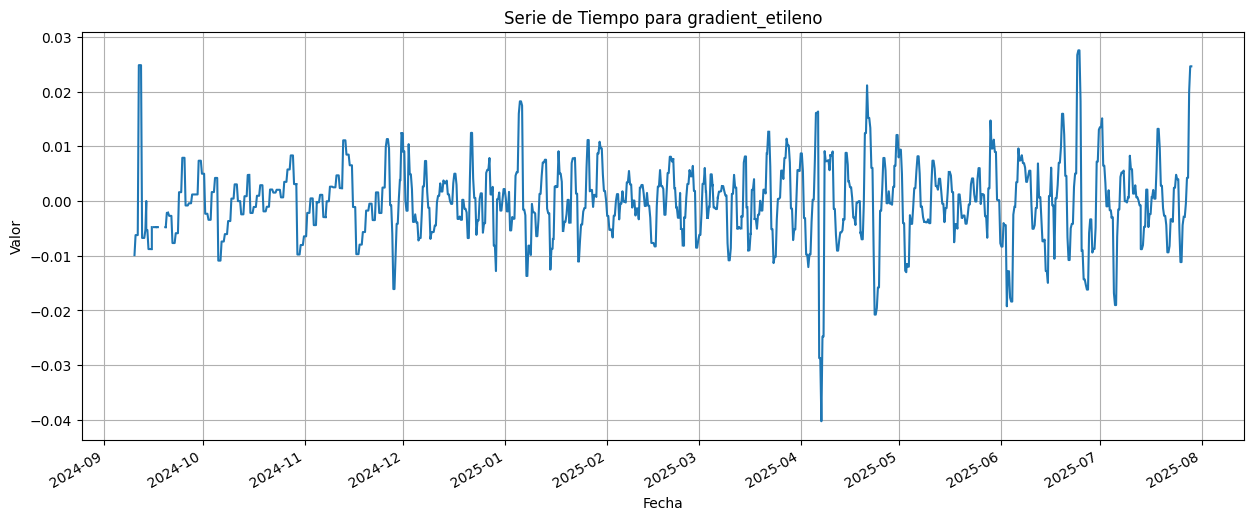


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'valvula_alivio_presion' ###
############################################################
Total de registros: 2942
Valores nulos: 2942 (100.00%)

--- Resumen Estadístico de 'value' ---
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN


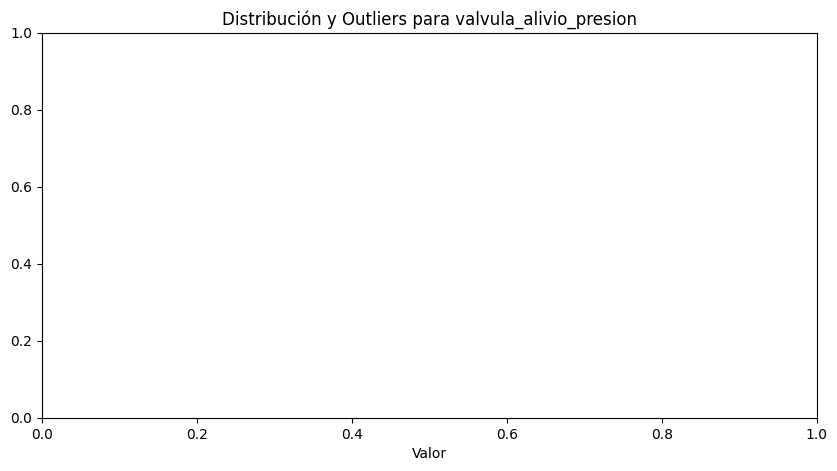

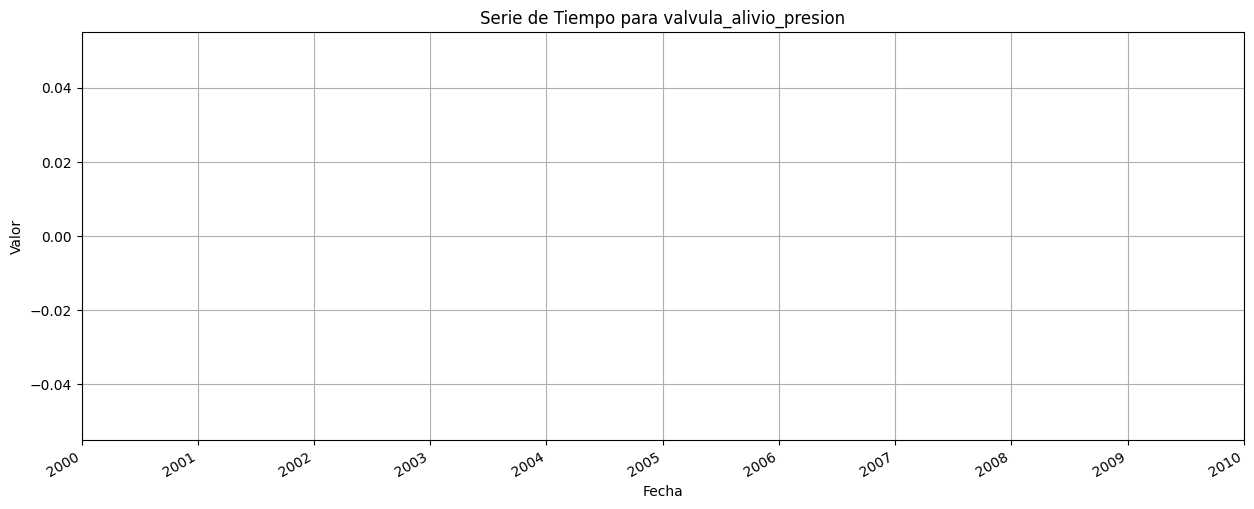


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'temperatura_aceite_OLTC' ###
############################################################
Total de registros: 10826
Valores nulos: 1012 (9.35%)

--- Resumen Estadístico de 'value' ---
count    9814.000000
mean       42.563267
std         7.031407
min         0.000000
25%        37.400002
50%        41.900002
75%        47.700001
max        61.900002


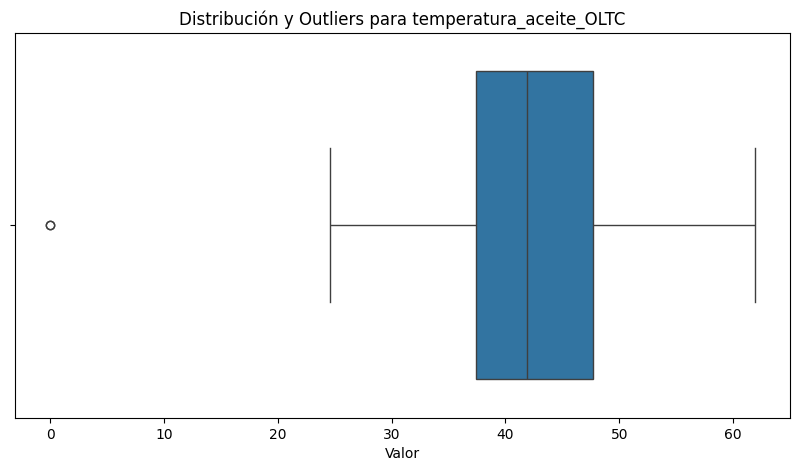

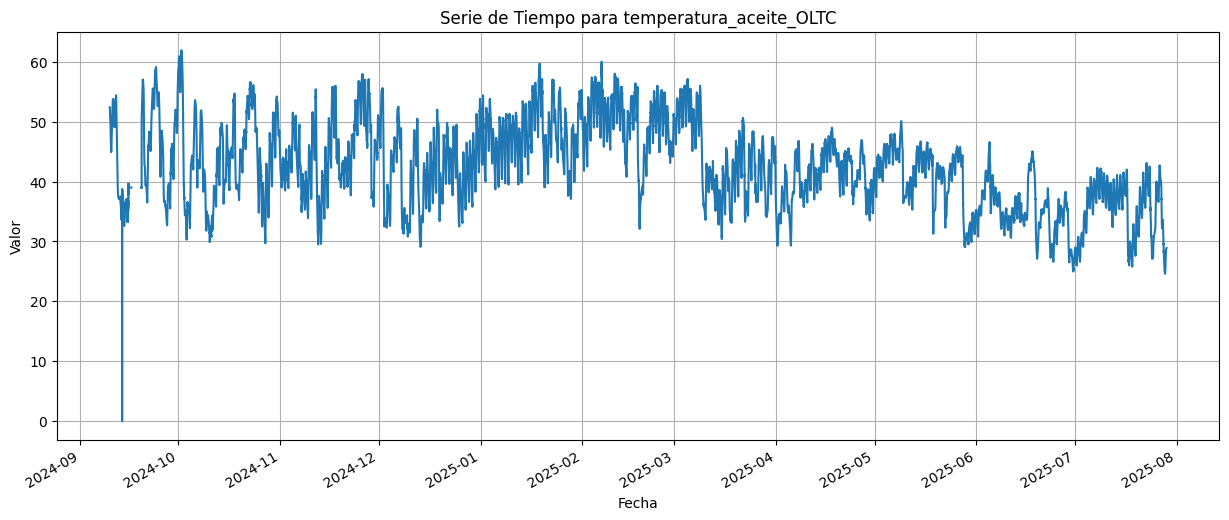


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'cambio_capacitancia_fase_3' ###
############################################################
Total de registros: 12763
Valores nulos: 1011 (7.92%)

--- Resumen Estadístico de 'value' ---
count    11752.000000
mean        -0.000460
std          0.144829
min         -0.868631
25%         -0.087878
50%         -0.006769
75%          0.084276
max          1.196404


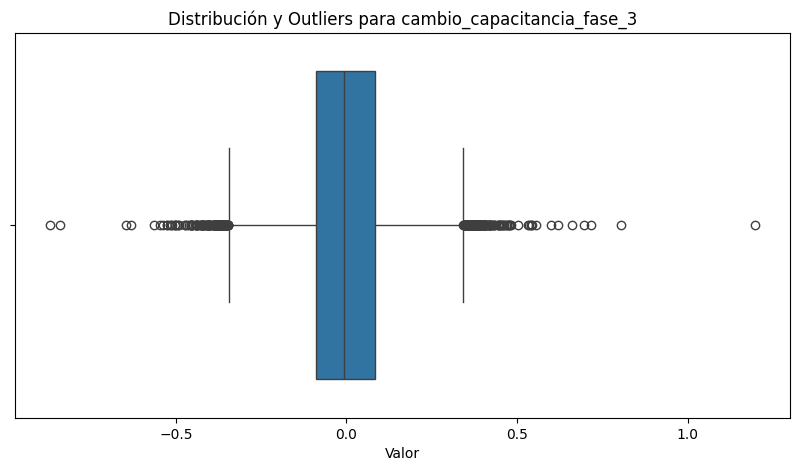

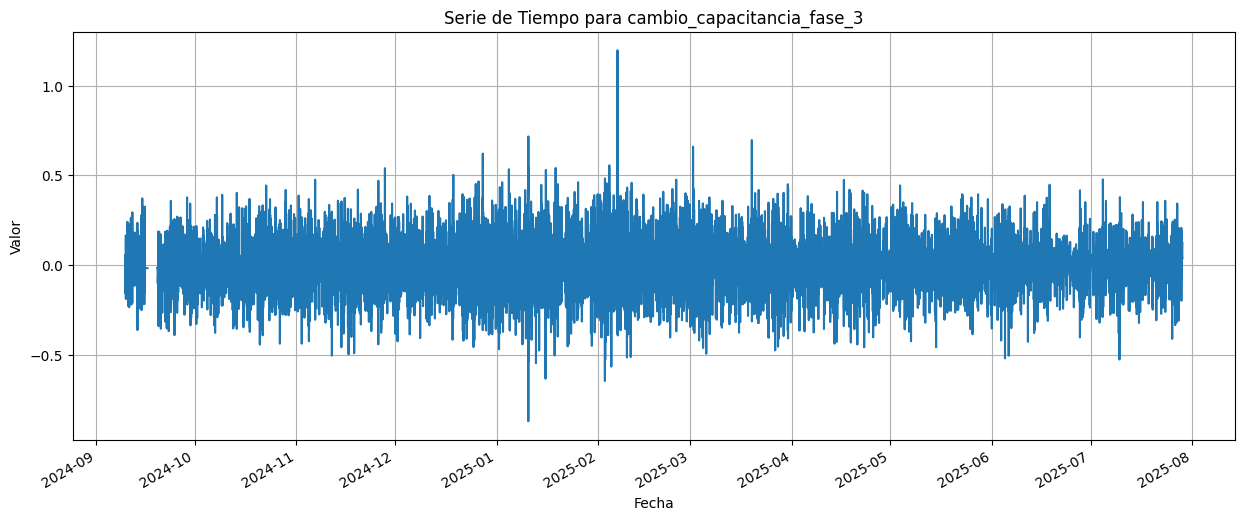


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'ventilador_3_mcb' ###
############################################################
Total de registros: 2787
Valores nulos: 2787 (100.00%)

--- Resumen Estadístico de 'value' ---
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN


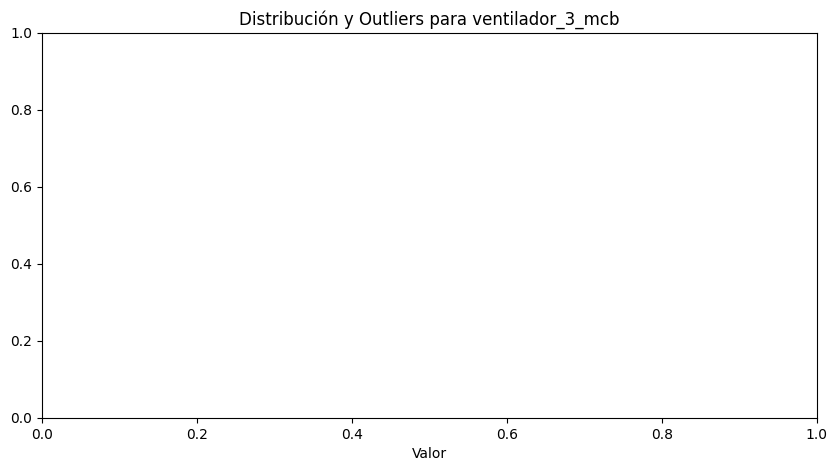

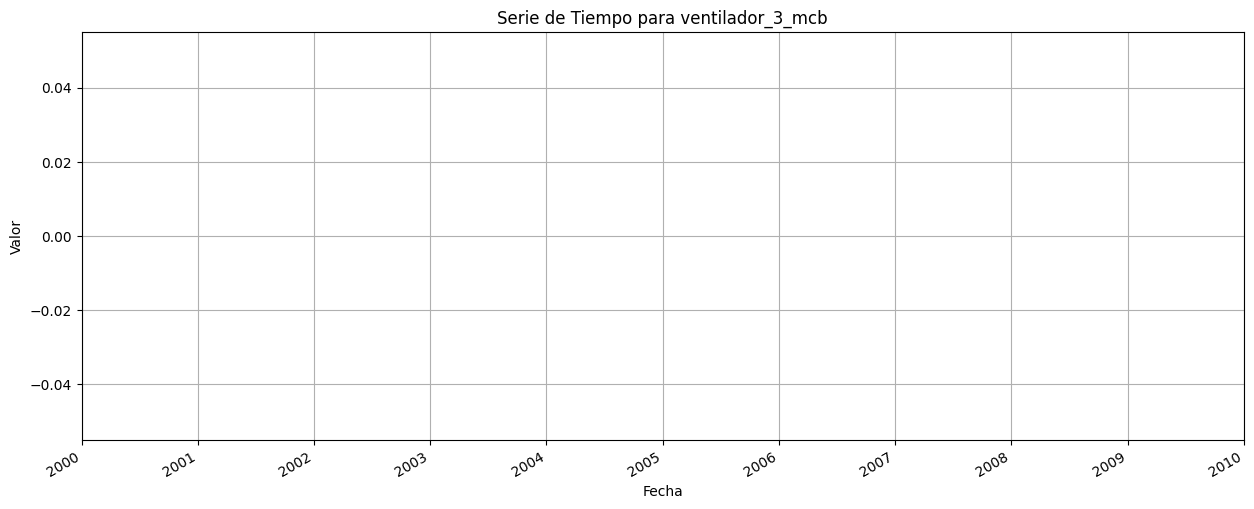


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'cambio_capacitancia_fase_1' ###
############################################################
Total de registros: 9496
Valores nulos: 1011 (10.65%)

--- Resumen Estadístico de 'value' ---
count    8485.000000
mean        0.001676
std         0.118950
min        -0.534127
25%        -0.063871
50%         0.004921
75%         0.063868
max         0.597207


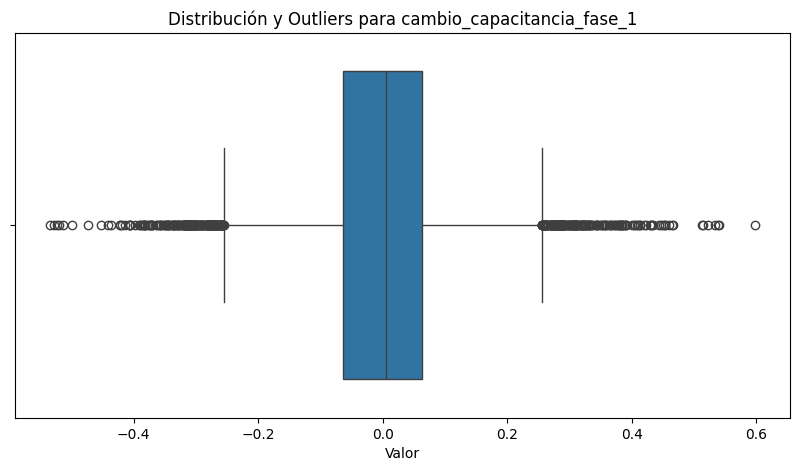

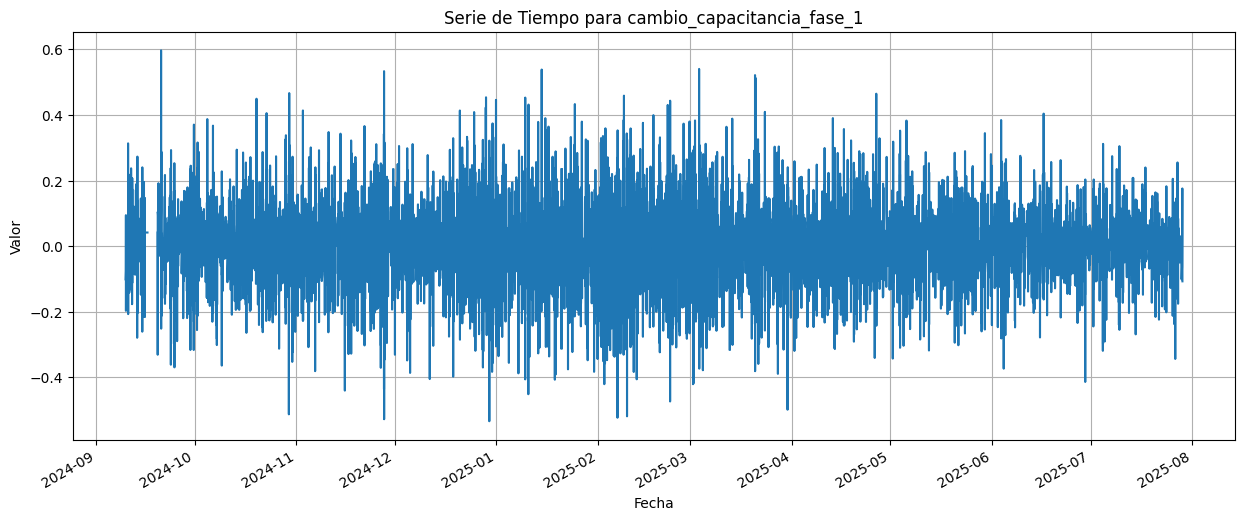


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'gradient_tdcg' ###
############################################################
Total de registros: 2927
Valores nulos: 948 (32.39%)

--- Resumen Estadístico de 'value' ---
count    1979.000000
mean       -0.004490
std         0.105970
min        -0.573988
25%        -0.042022
50%        -0.042022
75%         0.045807
max         0.698017


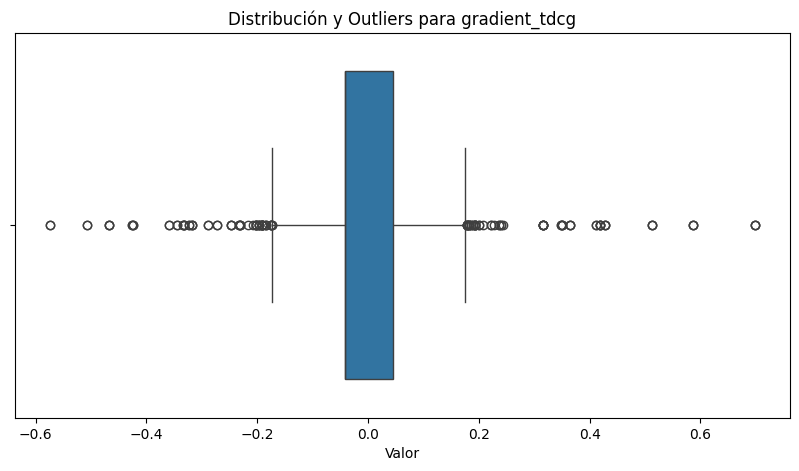

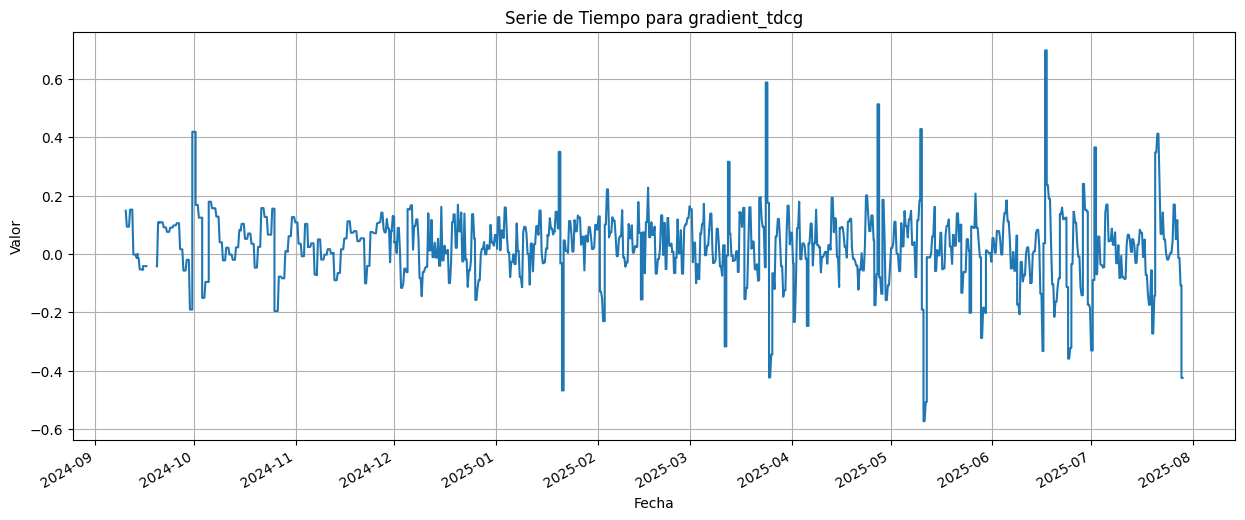


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'consumo_vida_util_ultimo_anio' ###
############################################################
Total de registros: 2869
Valores nulos: 967 (33.71%)

--- Resumen Estadístico de 'value' ---
count    1902.000000
mean        1.493447
std         0.883695
min         0.000000
25%         0.725985
50%         0.931296
75%         2.557091
max         2.878662


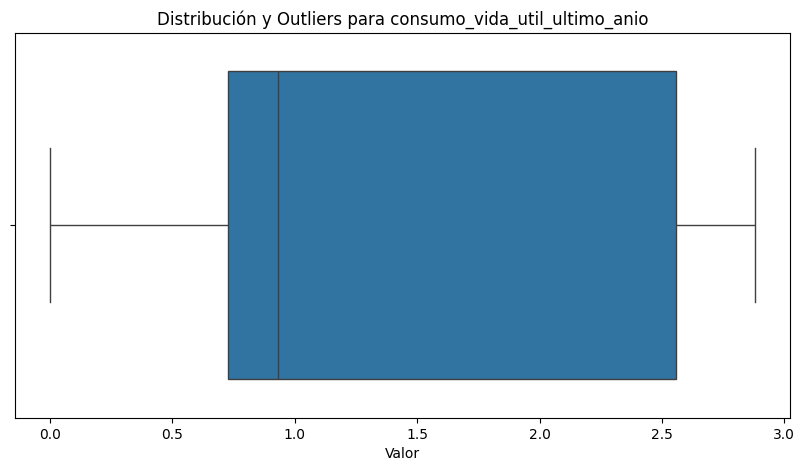

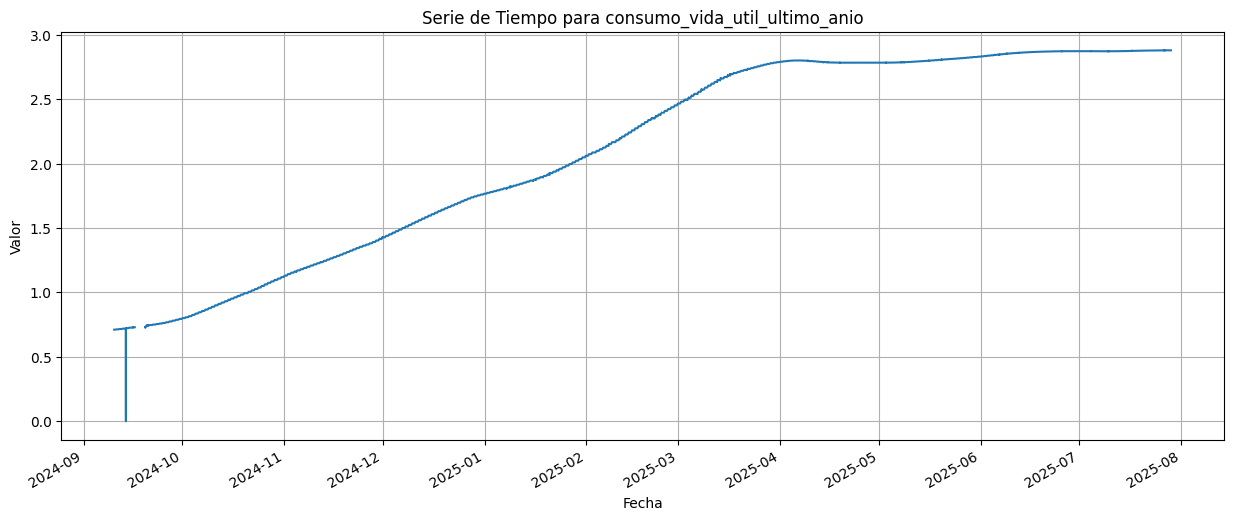


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'cambio_tan_fase_2' ###
############################################################
Total de registros: 3100
Valores nulos: 1012 (32.65%)

--- Resumen Estadístico de 'value' ---
count    2088.000000
mean       -0.000253
std         0.000857
min        -0.001824
25%        -0.000522
50%        -0.000311
75%        -0.000153
max         0.001333


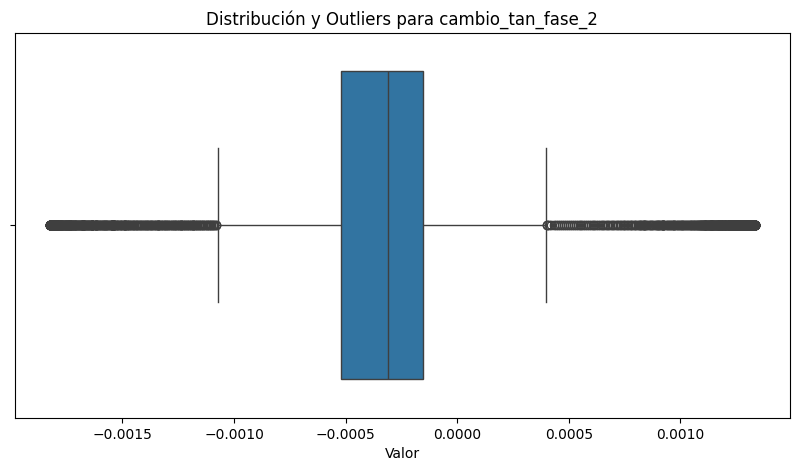

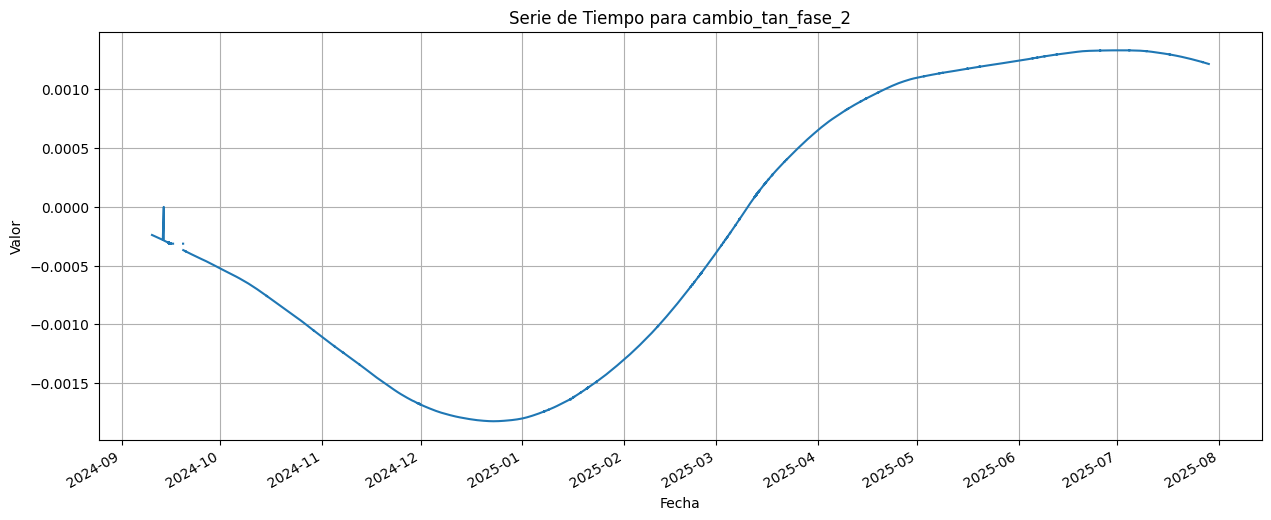


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'corriente_carga' ###
############################################################
Total de registros: 4815254
Valores nulos: 944 (0.02%)

--- Resumen Estadístico de 'value' ---
count    4.814310e+06
mean     7.411172e+02
std      2.052666e+02
min      0.000000e+00
25%      6.225170e+02
50%      7.092265e+02
75%      8.575897e+02
max      1.735917e+03


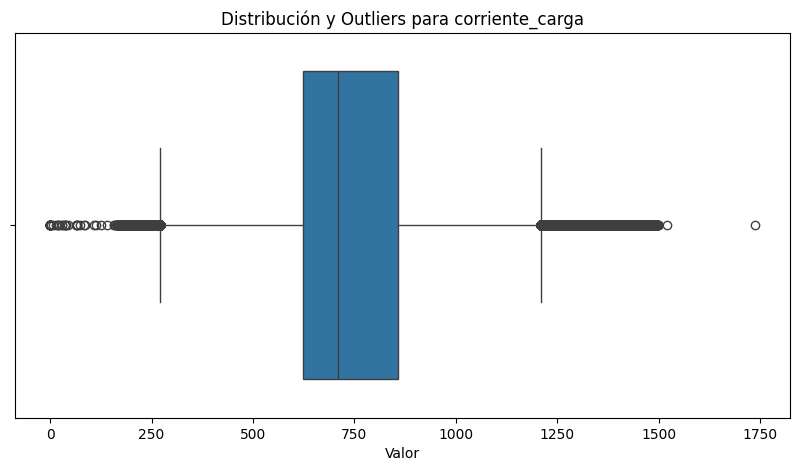

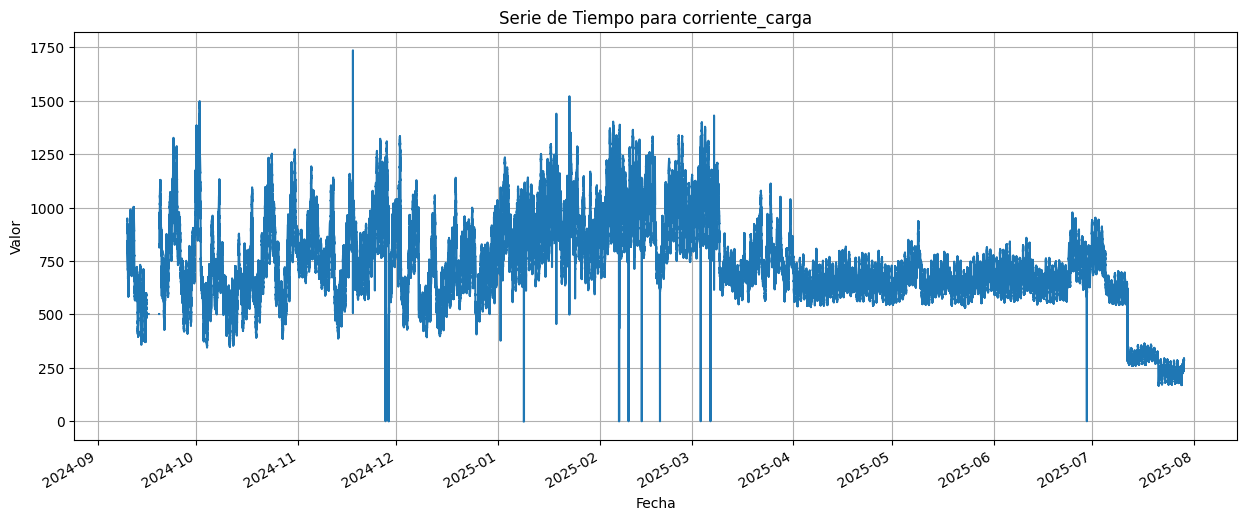


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'valvula_alivio_presion_OLTC' ###
############################################################
Total de registros: 2942
Valores nulos: 2942 (100.00%)

--- Resumen Estadístico de 'value' ---
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN


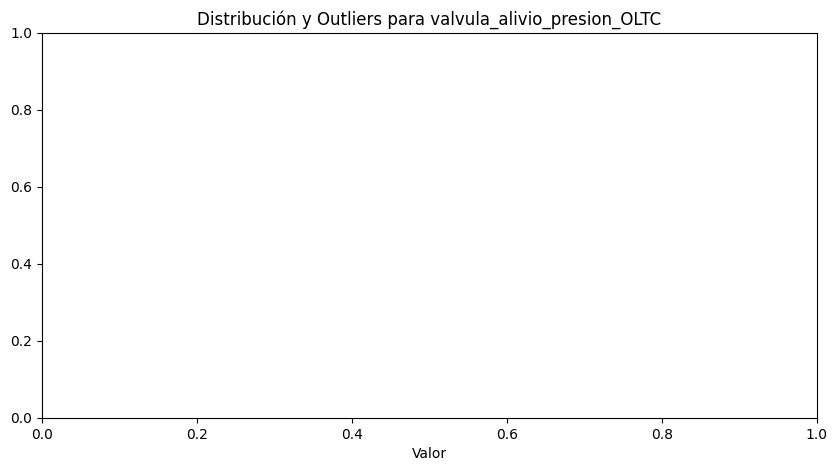

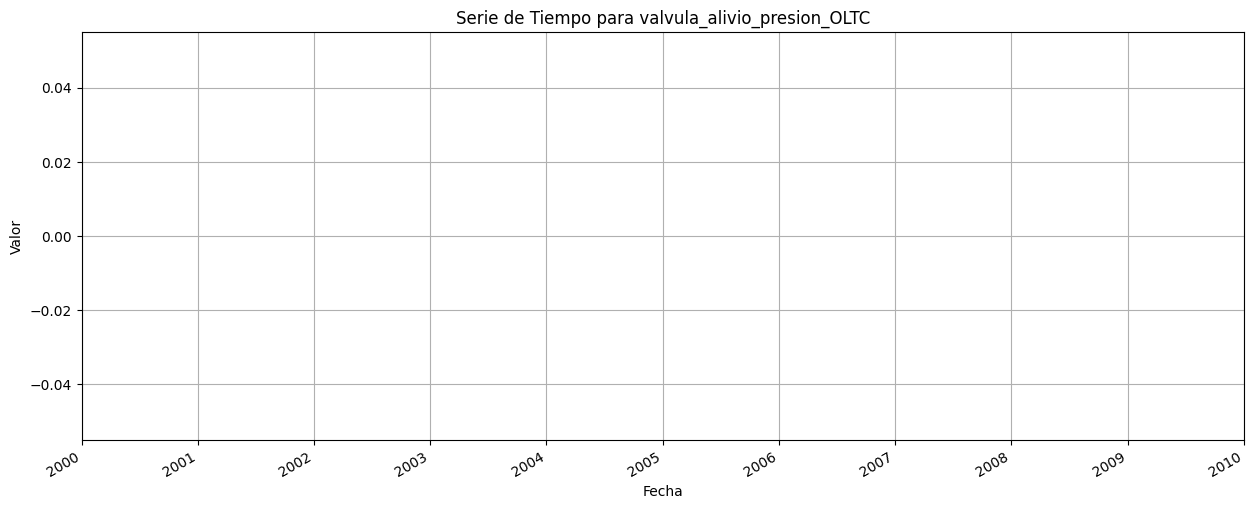


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'gradient_metano' ###
############################################################
Total de registros: 2790
Valores nulos: 921 (33.01%)

--- Resumen Estadístico de 'value' ---
count    1869.000000
mean       -0.003241
std         0.016551
min        -0.065843
25%        -0.014545
50%        -0.005028
75%         0.005758
max         0.069339


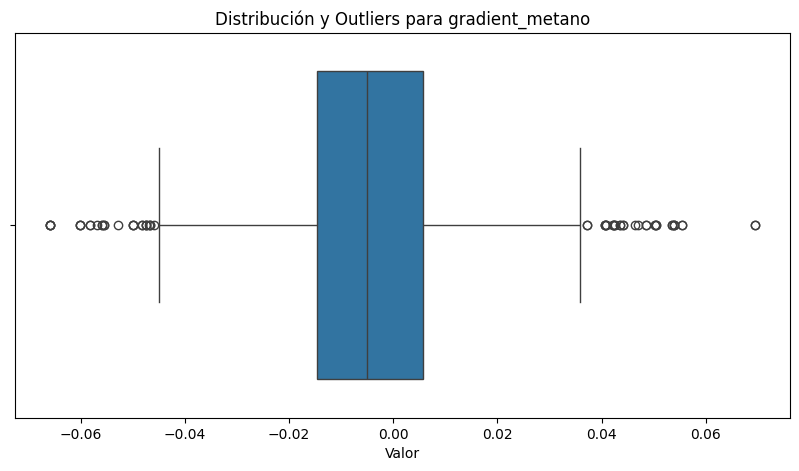

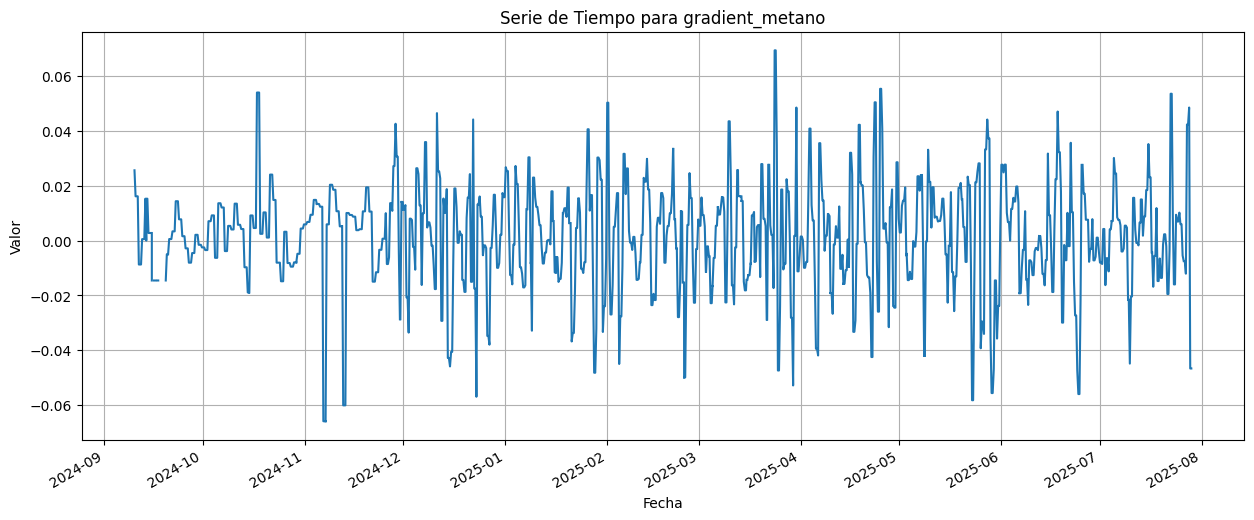


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'cambio_capacitancia' ###
############################################################
Total de registros: 2942
Valores nulos: 2942 (100.00%)

--- Resumen Estadístico de 'value' ---
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN


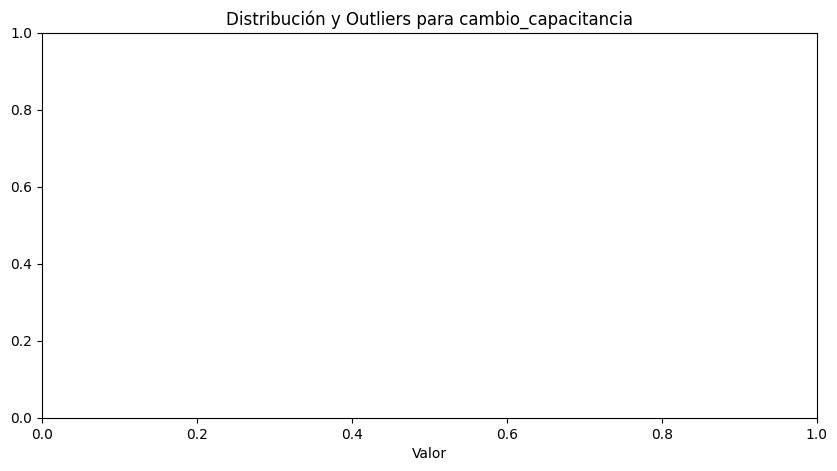

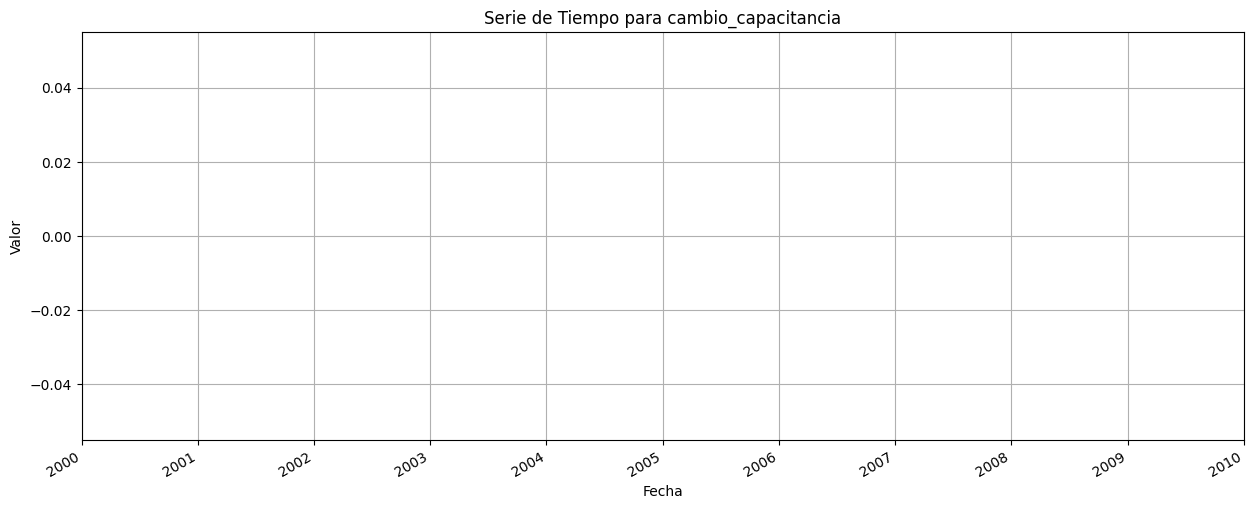


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'max_sobrecarga_fase_2' ###
############################################################
Total de registros: 2867
Valores nulos: 976 (34.04%)

--- Resumen Estadístico de 'value' ---
count    1891.000000
mean        1.299312
std         0.029895
min         0.000000
25%         1.300000
50%         1.300000
75%         1.300000
max         1.300000


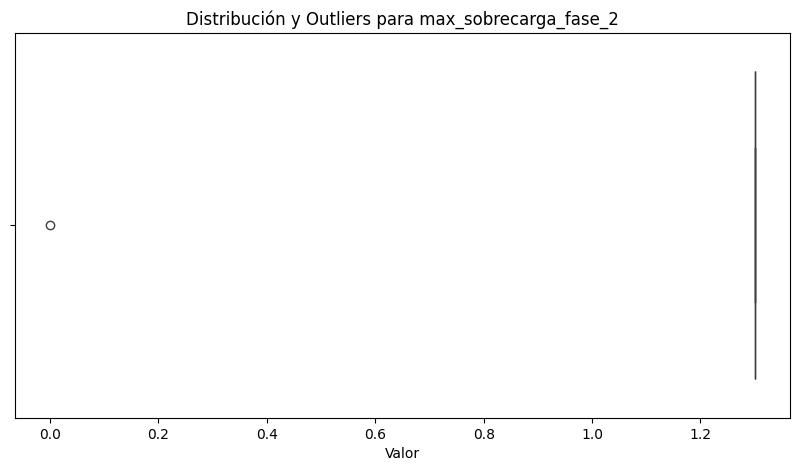

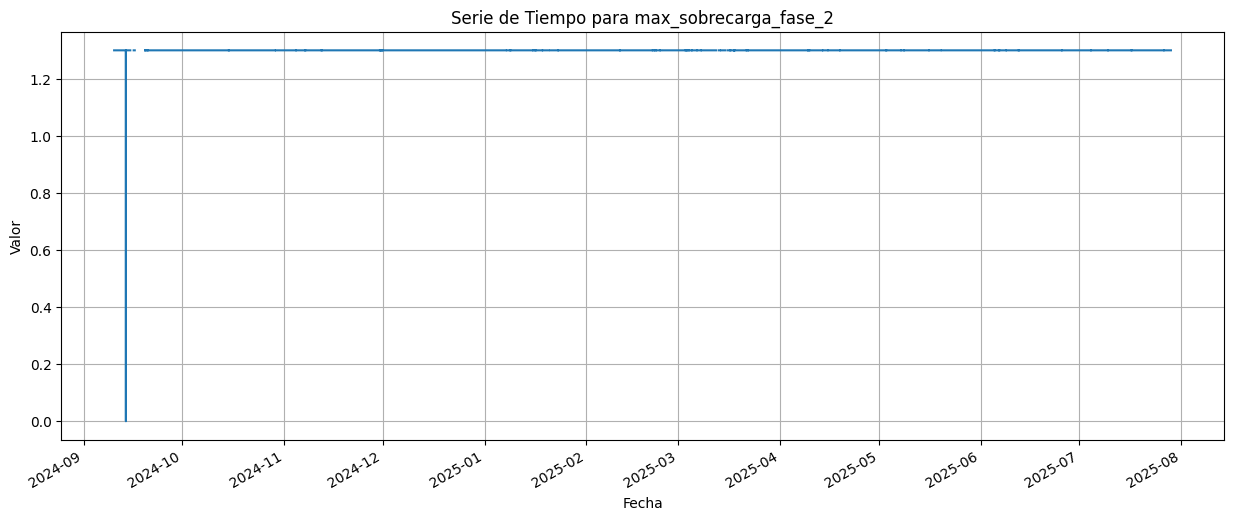


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'gradient_hidrogeno' ###
############################################################
Total de registros: 2794
Valores nulos: 920 (32.93%)

--- Resumen Estadístico de 'value' ---
count    1874.000000
mean       -0.000118
std         0.012625
min        -0.267570
25%        -0.001842
50%        -0.001842
75%         0.004461
max         0.060524


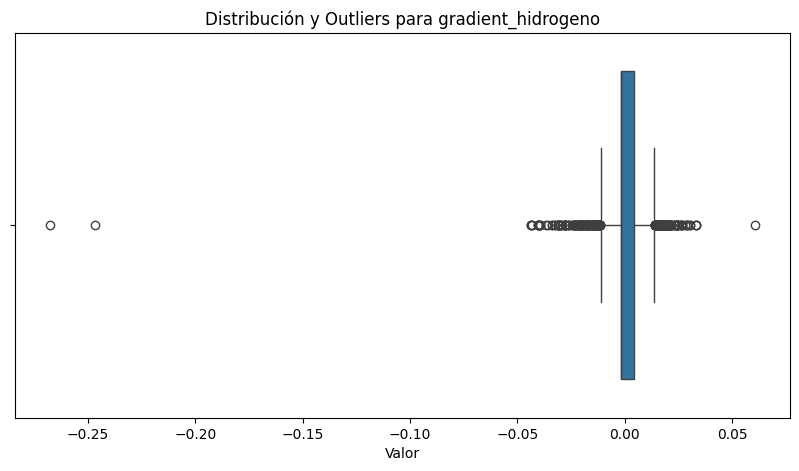

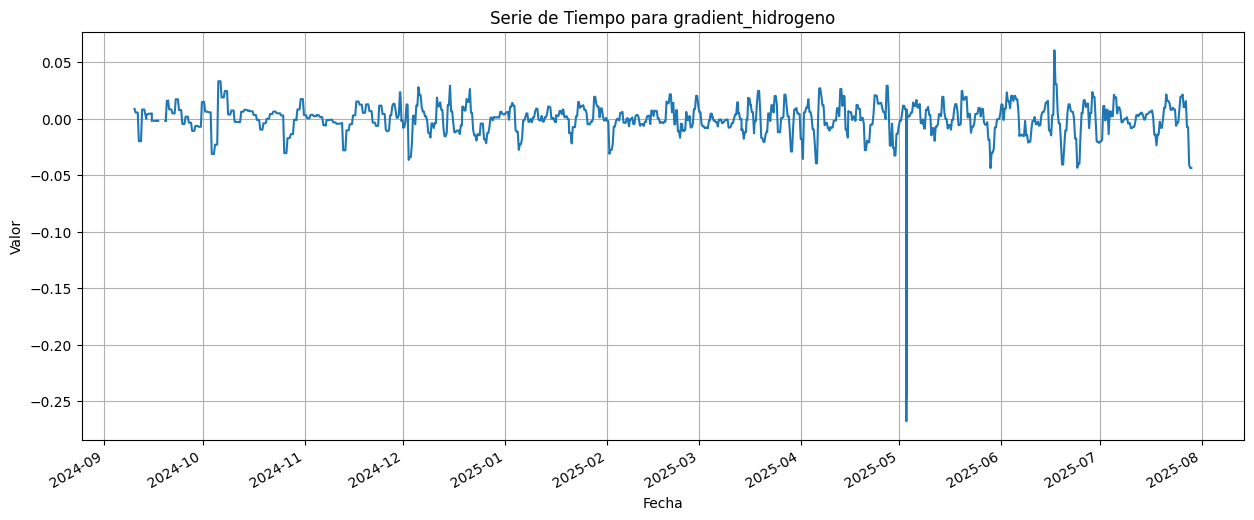


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'switch_S21_local' ###
############################################################
Total de registros: 2952
Valores nulos: 2952 (100.00%)

--- Resumen Estadístico de 'value' ---
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN


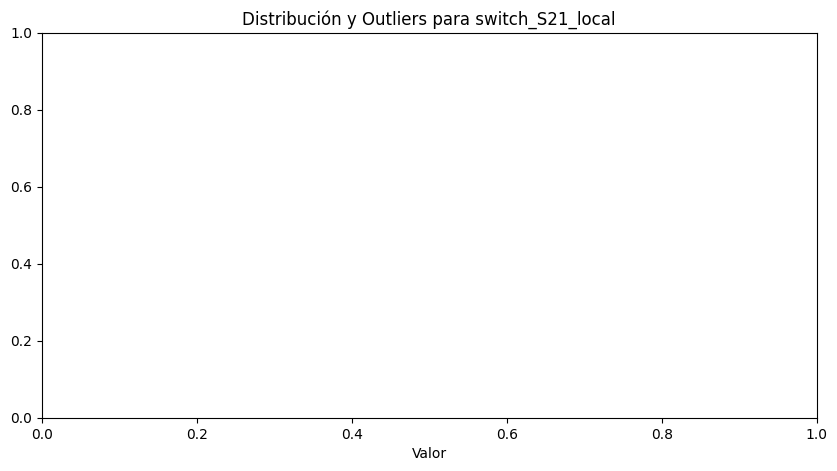

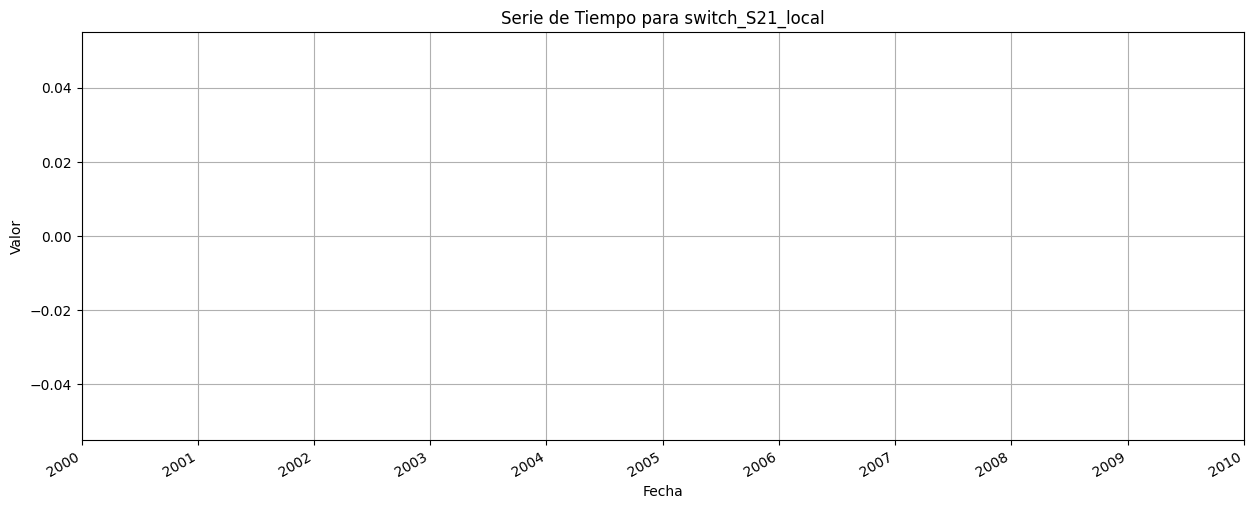


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'contador_cambios_posicion_tap' ###
############################################################
Total de registros: 4236
Valores nulos: 0 (0.00%)

--- Resumen Estadístico de 'value' ---
count    4236.000000
mean      281.631728
std       446.336654
min         1.000000
25%         5.000000
50%        17.000000
75%       464.250000
max      1523.000000


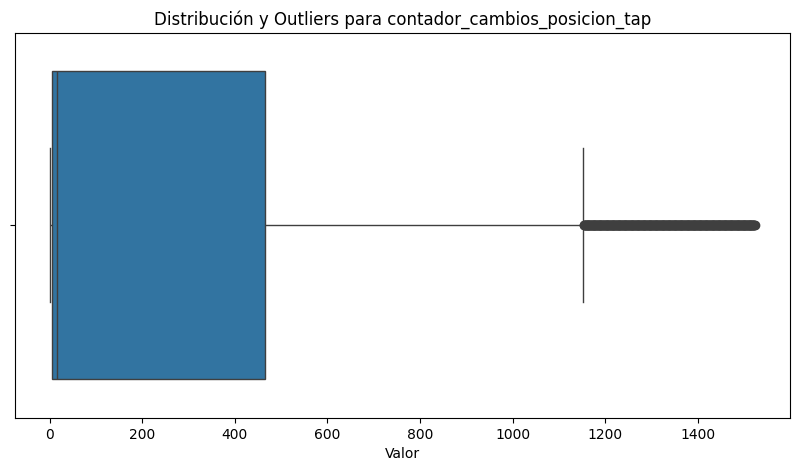

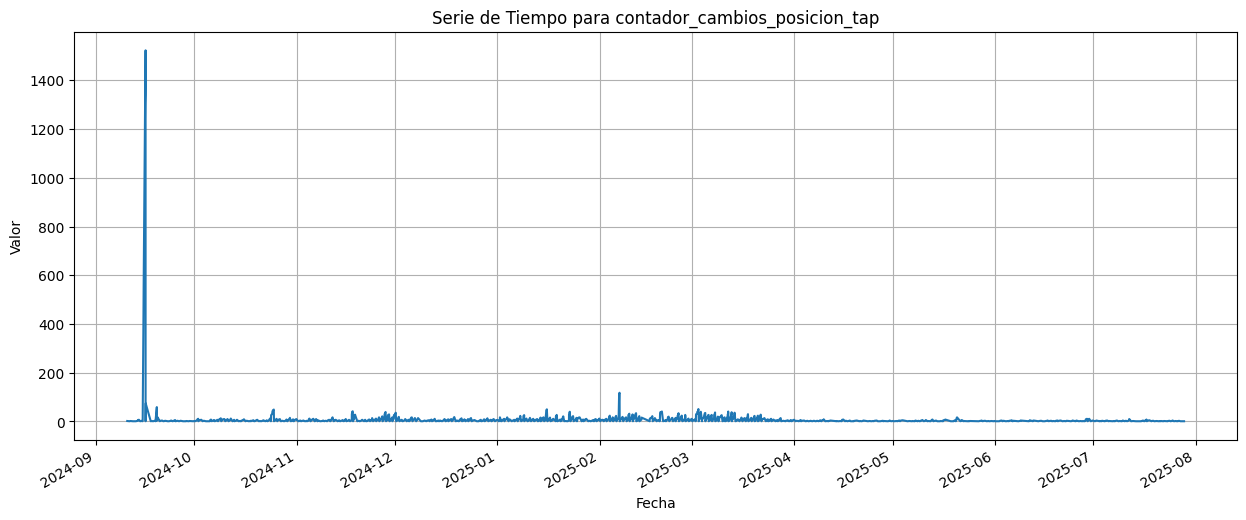


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'ventilador_7_mcb' ###
############################################################
Total de registros: 2767
Valores nulos: 2767 (100.00%)

--- Resumen Estadístico de 'value' ---
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN


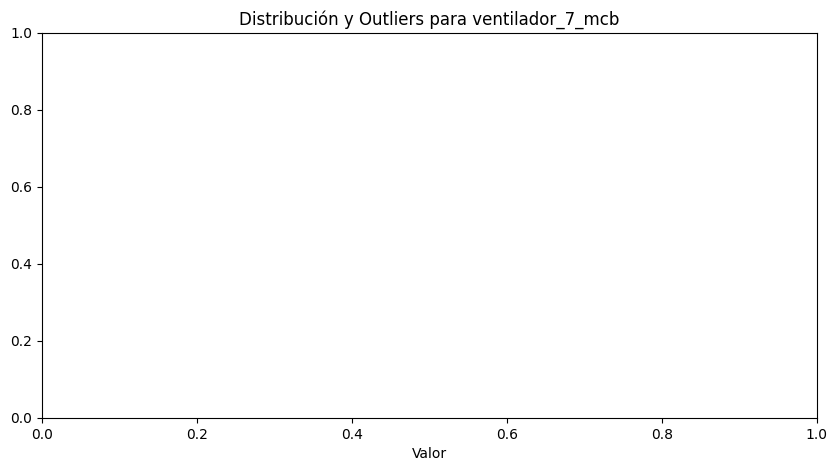

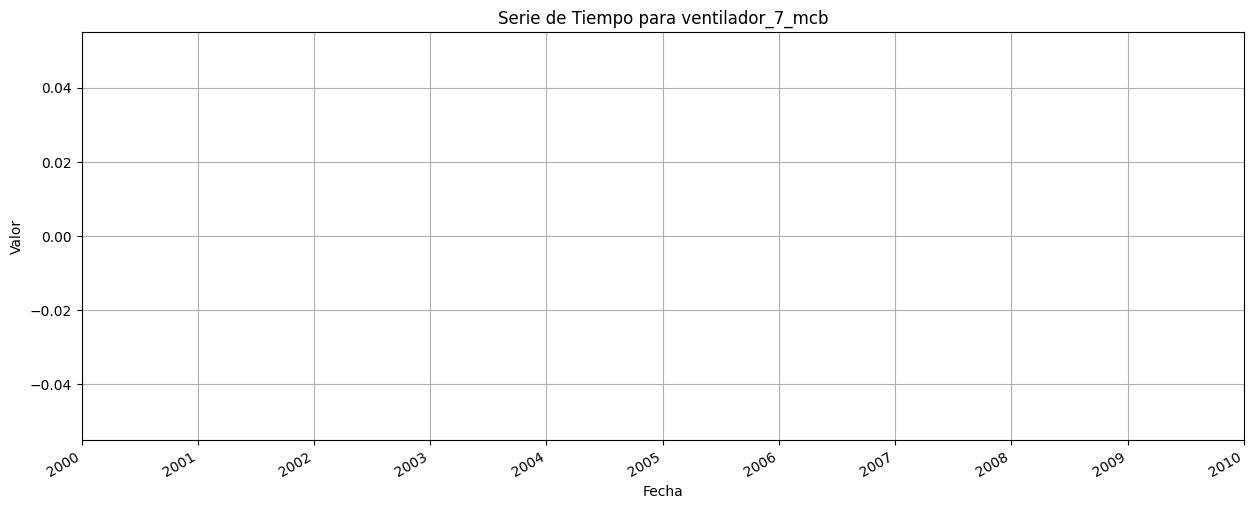


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'consumo_vida_util_absoluto' ###
############################################################
Total de registros: 2859
Valores nulos: 962 (33.65%)

--- Resumen Estadístico de 'value' ---
count    1897.000000
mean        1.966220
std         1.059004
min         0.000000
25%         1.069056
50%         1.305617
75%         3.112990
max         3.823511


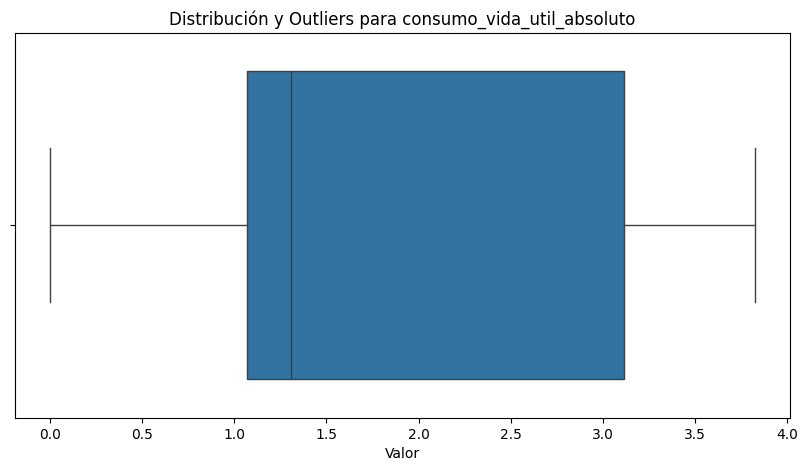

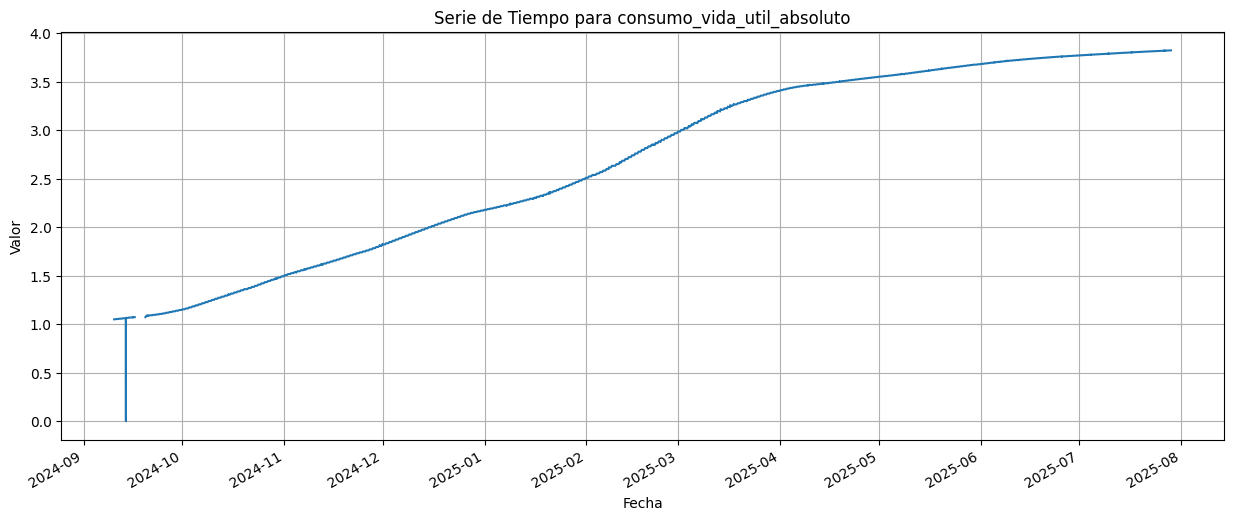


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'promedio_potencia_fase_2' ###
############################################################
Total de registros: 5608
Valores nulos: 46 (0.82%)

--- Resumen Estadístico de 'value' ---
count    5562.000000
mean       30.488239
std         8.238311
min         3.128827
25%        25.213273
50%        29.306604
75%        35.533714
max        59.176736


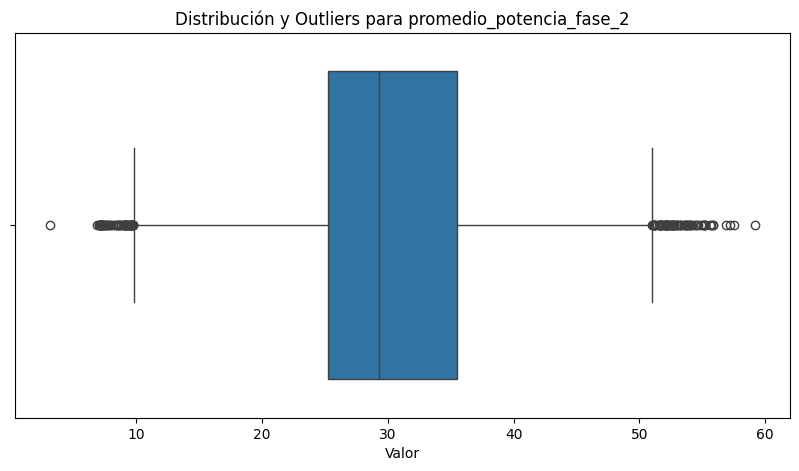

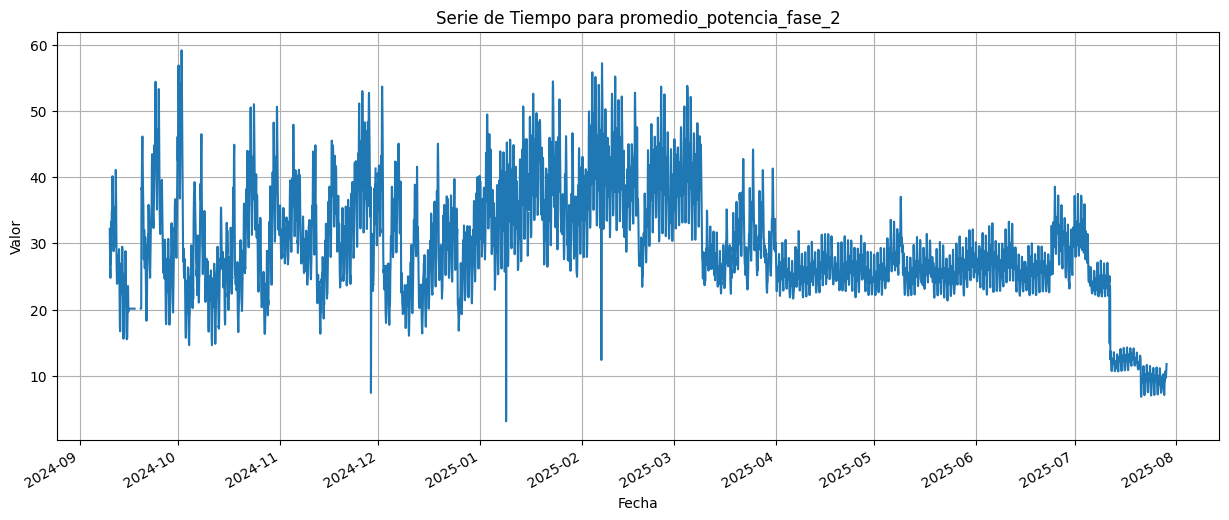


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'ventilador_11_mcb' ###
############################################################
Total de registros: 2944
Valores nulos: 2944 (100.00%)

--- Resumen Estadístico de 'value' ---
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN


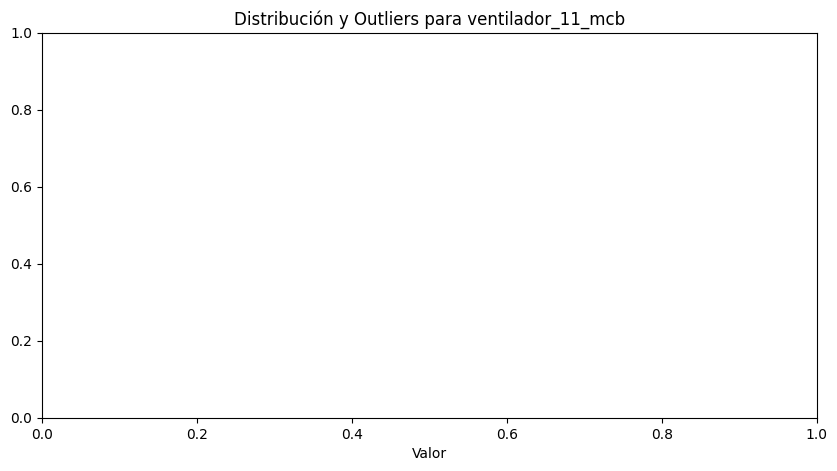

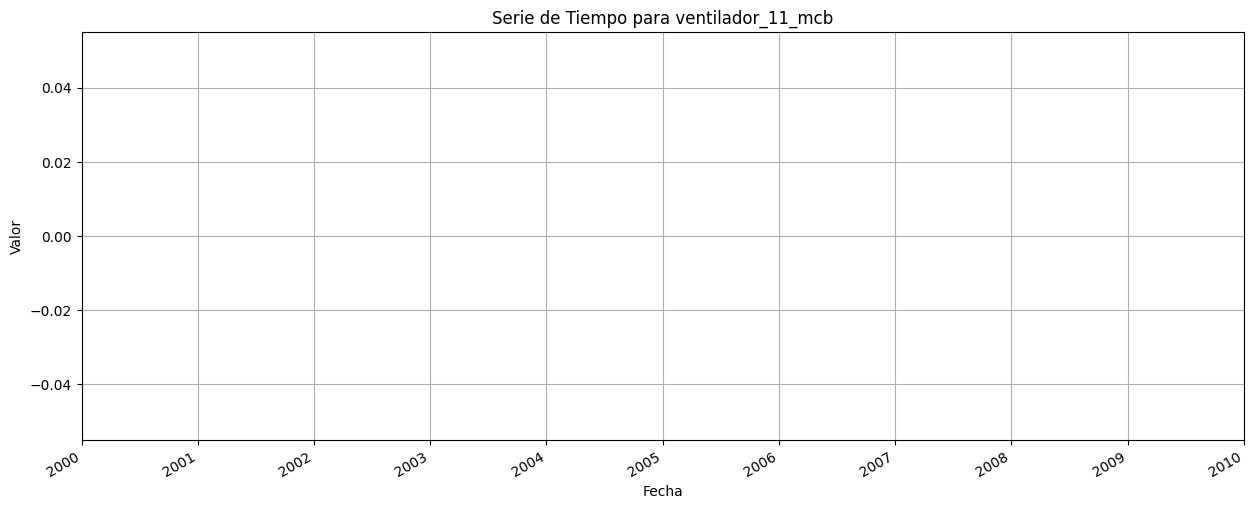


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'perdidas_actuales' ###
############################################################
Total de registros: 433733
Valores nulos: 1006 (0.23%)

--- Resumen Estadístico de 'value' ---
count    432727.000000
mean       3949.613018
std        2195.637899
min           0.000000
25%        2556.632812
50%        3327.295654
75%        4921.934570
max       18755.371094


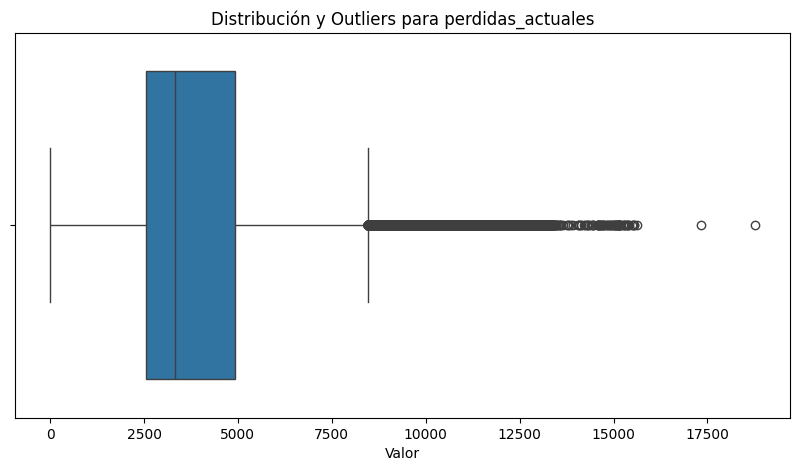

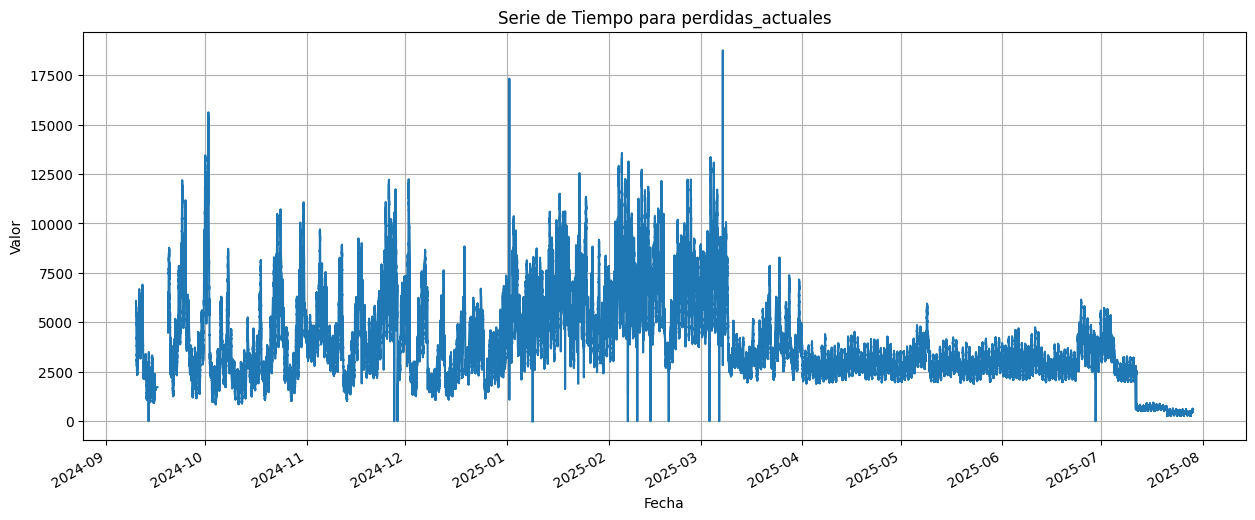


Análisis completo para esta variable. Continuando con la siguiente...

############################################################
### ANÁLISIS EDA PARA LA VARIABLE: 'ventilador_8_mcb' ###
############################################################
Total de registros: 2755
Valores nulos: 2755 (100.00%)

--- Resumen Estadístico de 'value' ---
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN


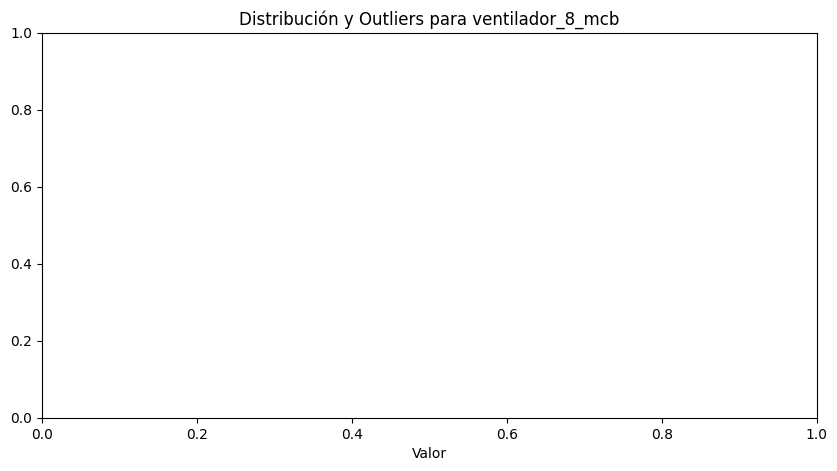

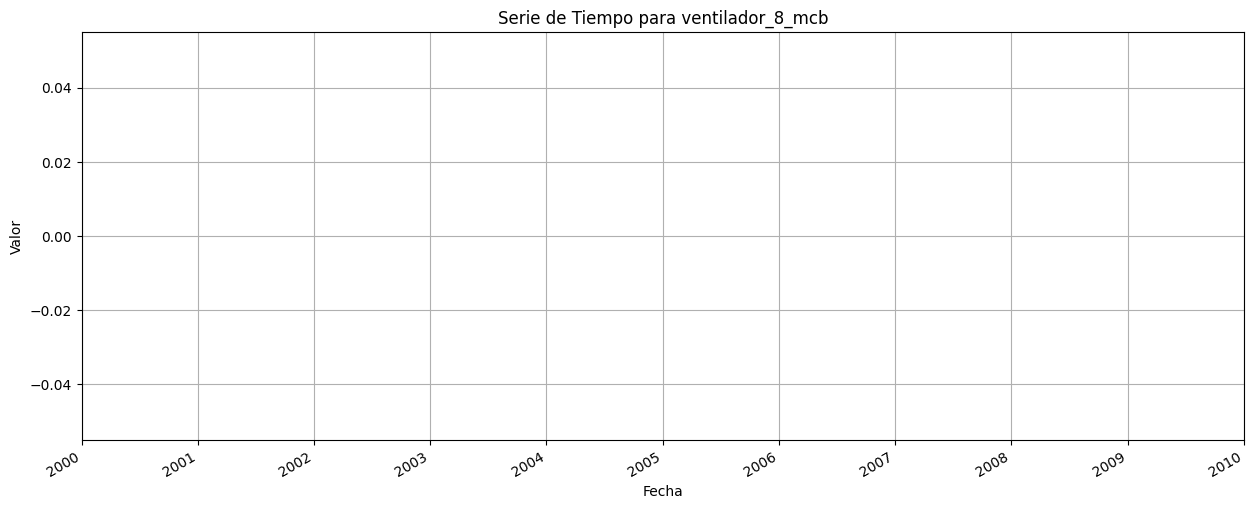


Análisis completo para esta variable. Continuando con la siguiente...


In [ ]:
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from deltalake import DeltaTable
import os
# Ensure this notebook can access the repo data folder directly
from pathlib import Path
# notebooks/ -> repo root is parent
REPO_ROOT = Path.cwd().resolve().parent
BRONZE_TABLE = REPO_ROOT / "data" / "capa_bronze" / "readings_v1"
# Define la ruta a la tabla Delta de la capa Bronze
BRONZE_TABLE_PATH = BRONZE_TABLE

# --- PASO 1: Cargar datos en Polars ---
def load_bronze_data(path: str) -> pl.DataFrame:
    """Carga todos los datos de la tabla Delta Bronze."""
    try:
        dt = DeltaTable(path)
        # Usar Polars para leer la tabla de forma eficiente
        return pl.from_arrow(dt.to_pyarrow_table())
    except Exception as e:
        print(f"Error al cargar la tabla Delta: {e}")
        return pl.DataFrame()

# Cargar el DataFrame completo
df = load_bronze_data(BRONZE_TABLE_PATH)
if df.is_empty():
    print("El DataFrame está vacío. Asegúrate de haber ejecutado tu script de extracción.")
    exit()

# --- PASO 2: Obtener la lista de todas las variables únicas (tags) ---
# Se asume que la columna de tags se llama 'tag'
unique_tags = df.get_column("tag").unique().to_list()
print(f"Se encontraron {len(unique_tags)} variables únicas para analizar.")

# --- PASO 3: Iterar a través de cada variable y realizar un EDA completo ---
for tag_name in unique_tags:
    print(f"\n############################################################")
    print(f"### ANÁLISIS EDA PARA LA VARIABLE: '{tag_name}' ###")
    print(f"############################################################")

    # Filtrar el DataFrame para la variable actual
    df_tag = df.filter(pl.col("tag") == tag_name)

    if df_tag.is_empty():
        print("No hay datos para esta variable. Saltando al siguiente tag.")
        continue

    # Convertir a Pandas para el análisis y visualización (si prefieres Polars, los métodos son similares)
    pdf_tag = df_tag.to_pandas()

    # 1. Perfilado de Datos (Valores faltantes)
    total_rows = len(pdf_tag)
    nulls = pdf_tag['value'].isnull().sum()
    null_percentage = (nulls / total_rows) * 100
    print(f"Total de registros: {total_rows}")
    print(f"Valores nulos: {nulls} ({null_percentage:.2f}%)")

    # 2. Resumen Estadístico para variables numéricas
    if pd.api.types.is_numeric_dtype(pdf_tag['value']):
        print("\n--- Resumen Estadístico de 'value' ---")
        print(pdf_tag['value'].describe().to_string())
    else:
        print("\n--- La variable no es numérica, saltando el resumen estadístico. ---")

    # 3. Análisis de Distribución (Diagrama de Caja)
    if pd.api.types.is_numeric_dtype(pdf_tag['value']):
        plt.figure(figsize=(10, 5))
        sns.boxplot(x=pdf_tag['value'].dropna())
        plt.title(f'Distribución y Outliers para {tag_name}')
        plt.xlabel('Valor')
        plt.show()

    # 4. Análisis de Series de Tiempo
    if 'timestamp' in pdf_tag.columns:
        # Asegurarse de que el 'timestamp' sea un índice de tiempo
        pdf_tag['timestamp'] = pd.to_datetime(pdf_tag['timestamp'], errors='coerce')
        pdf_tag_cleaned = pdf_tag.dropna(subset=['timestamp']).set_index('timestamp').sort_index()

        if not pdf_tag_cleaned.empty:
        # Visualizar la serie de tiempo para la variable
            plt.figure(figsize=(15, 6))
            pdf_tag_cleaned['value'].plot(title=f'Serie de Tiempo para {tag_name}')
            plt.xlabel('Fecha')
            plt.ylabel('Valor')
            plt.grid(True)
            plt.show()
        else:
            print("No se puede generar el gráfico de serie de tiempo porque todos los timestamps son nulos o inválidos.")
    print("\nAnálisis completo para esta variable. Continuando con la siguiente...")

In [4]:
   # ===============================================
# EDA Bronze (v2) — Perfilado por tag (mejorado)
# ===============================================
import math
import os
from pathlib import Path
from typing import Optional, List, Dict

import numpy as np
import pandas as pd
import polars as pl
from deltalake import DeltaTable

# -----------------------------
# 0) Config mínima y rutas
# -----------------------------
# Intenta tomar BRONZE_TABLE de tu config; si no existe, usa una ruta por defecto relativa al repo
# try:
#     from config import BRONZE_TABLE as BRONZE_TABLE_PATH
# except Exception:
REPO_ROOT = Path.cwd().resolve()
BRONZE_TABLE_PATH = (REPO_ROOT / "data" / "capa_bronze" / "readings_v1").as_posix()
print("BRONZE_TABLE_PATH:", BRONZE_TABLE_PATH)

BRONZE_TABLE_PATH: C:/Users/Asus TUF/Desktop/proy_ml/notebooks/data/capa_bronze/readings_v1


In [1]:
    # ===============================================
# EDA Bronze (v2) — Perfilado por tag (mejorado)
# ===============================================
import math
import os
from pathlib import Path
from typing import Optional, List, Dict

import numpy as np
import pandas as pd
import polars as pl
from deltalake import DeltaTable

# -----------------------------
# 0) Config mínima y rutas
# -----------------------------
# Intenta tomar BRONZE_TABLE de tu config; si no existe, usa una ruta por defecto relativa al repo
# try:
#     from config import BRONZE_TABLE as BRONZE_TABLE_PATH

# except Exception:
REPO_ROOT = Path.cwd().resolve().parent
BRONZE_TABLE_PATH = (REPO_ROOT / "data" / "capa_bronze" / "readings_v1")

# OUT_DIR = "data/lakehouse/artifacts/eda"
# os.makedirs(OUT_DIR, exist_ok=True)

# Umbrales de descarte / tipado (ajusta si quieres)
MIN_DAYS_COVERAGE   = 30       # descartar si < 30 días con datos válidos
MAX_NULL_PCT        = 0.80     # descartar si nulos reales >= 80%
DISCRETE_UNIQUE_MAX = 20       # ≤20 num únicos => 'discrete'
CATEGORICAL_TEXT_MAX= 50       # ≤50 textos únicos => 'categorical_text'

# ------------------------------------
# 1) Helpers: lectura y utilidades
# ------------------------------------
def load_bronze_pl(path: str) -> pl.DataFrame:
    """Carga Bronze Delta a Polars sin filtrar."""
    dt = DeltaTable(path)
    return pl.from_arrow(dt.to_pyarrow_table())

def list_tags(dt: DeltaTable) -> List[str]:
    pa = dt.to_pyarrow_table(columns=["tag"])
    return pd.Series(pa.to_pandas()["tag"].astype(str)).dropna().unique().tolist()

def median_step_seconds(ts: pd.Series) -> Optional[float]:
    """Mediana de los pasos (segundos) en una serie temporal ya en UTC."""
    ts = pd.to_datetime(ts, utc=True, errors="coerce").dropna().sort_values()
    if ts.size < 2: 
        return None
    return float(ts.diff().dropna().dt.total_seconds().median())

def infer_freq_from_median_seconds(median_s: Optional[float]) -> str:
    if median_s is None: return "15min"
    if median_s <= 60:    return "1min"
    if median_s <= 300:   return "5min"
    if median_s <= 900:   return "15min"
    if median_s <= 3600:  return "1h"
    if median_s <= 10800: return "3h"
    return "1D"

def points_per_day(freq: str) -> float:
    """Cuántos puntos caben por día en esa frecuencia (aprox)."""
    try:
        return float(pd.Timedelta("1D") / pd.Timedelta(freq))
    except Exception:
        return 96.0  # fallback 15min

def canonical_repr(row) -> str:
    """Representación canónica para medir constancia/repetidos."""
    if pd.notna(row.get("value_bool")):
        return f"bool:{bool(row['value_bool'])}"
    if pd.notna(row.get("value")):
        try:
            return f"num:{round(float(row['value']), 6)}"
        except Exception:
            pass
    vt = row.get("value_text")
    if isinstance(vt, str) and vt.strip():
        return f"text:{vt.strip()}"
    return "null"

# ------------------------------------
# 2) Perfil de un tag (métricas EDA)
# ------------------------------------
def profile_one_tag(pdf: pd.DataFrame, tag_name: str) -> Dict:
    """
    Recibe un DataFrame pandas de Bronze filtrado a 'tag_name' con
    columnas: timestamp/ts, value, value_text, value_bool, tag.
    Devuelve métricas de EDA para ranking y descarte.
    """
    # Normaliza timestamp
    ts_col = "timestamp" if "timestamp" in pdf.columns else ("ts" if "ts" in pdf.columns else None)
    if ts_col:
        pdf[ts_col] = pd.to_datetime(pdf[ts_col], utc=True, errors="coerce")
        if ts_col != "timestamp":
            pdf = pdf.rename(columns={ts_col: "timestamp"})
    else:
        pdf["timestamp"] = pd.NaT

    pdf = pdf.sort_values("timestamp", na_position="last").reset_index(drop=True)

    # Asegura canales
    if "value" not in pdf.columns:       pdf["value"] = np.nan
    if "value_text" not in pdf.columns:  pdf["value_text"] = pd.NA
    if "value_bool" not in pdf.columns:  pdf["value_bool"] = pd.NA

    total_rows = len(pdf)

    # Válido = cualquier canal con dato
    valid_mask = pdf["value"].notna() | pdf["value_text"].notna() | pdf["value_bool"].notna()
    valid_rows = int(valid_mask.sum())
    pct_nulos  = (total_rows - valid_rows) / max(total_rows, 1)

    # Fracciones por canal (sobre válidos)
    denom = max(valid_rows, 1)
    frac_num  = float(pdf["value"].notna().sum())      / denom
    frac_bool = float(pdf["value_bool"].notna().sum()) / denom
    frac_text = float(pdf["value_text"].notna().sum()) / denom

    # Numéricos: estadísticos y cardinalidad
    df_num = pdf[pdf["value"].notna()].copy()
    num_min = float(df_num["value"].min()) if not df_num.empty else np.nan
    num_max = float(df_num["value"].max()) if not df_num.empty else np.nan
    num_mean= float(df_num["value"].mean()) if not df_num.empty else np.nan
    num_std = float(df_num["value"].std())  if not df_num.empty else np.nan
    num_unique = int(df_num["value"].nunique()) if not df_num.empty else 0

    # Texto/boolean: cardinalidad
    text_unique = int(pdf.loc[pdf["value_text"].notna(), "value_text"].astype(str).str.strip().nunique())
    bool_unique = int(pdf.loc[pdf["value_bool"].notna(), "value_bool"].nunique())

    # Variabilidad
    if valid_rows > 0:
        canon = pdf.loc[valid_mask, ["value","value_text","value_bool"]].apply(canonical_repr, axis=1)
        rep_consec  = float(canon.eq(canon.shift(1)).sum()) / len(canon)
    else:
        rep_consec  = np.nan

    # Temporalidad y cobertura
    ts_valid = pdf.loc[valid_mask & pdf["timestamp"].notna(), "timestamp"]
    if not ts_valid.empty:
        first_ts = ts_valid.min()
        last_ts  = ts_valid.max()
        days_covered = int(ts_valid.dt.date.nunique())
        median_s = median_step_seconds(ts_valid)
        base_freq = infer_freq_from_median_seconds(median_s)
        ppd = points_per_day(base_freq)
    else:
        first_ts = last_ts = pd.NaT
        days_covered = 0
        median_s = None
        base_freq = "15min"
        ppd = 0.0


    # Tipado inferido
    type_inferred = "mixed"
    if frac_bool >= 0.7 or (bool_unique in (1,2) and frac_bool >= 0.5):
        type_inferred = "boolean"
    elif frac_num  >= 0.7:
        if num_unique <= DISCRETE_UNIQUE_MAX or (not df_num.empty and num_unique / len(df_num) <= 0.01):
            type_inferred = "discrete"
        else:
            type_inferred = "continuous"
    elif frac_text >= 0.7:
        type_inferred = "categorical_text" if text_unique <= CATEGORICAL_TEXT_MAX else "free_text"

    # Reglas de descarte
    reasons = []
    if pct_nulos >= MAX_NULL_PCT:         reasons.append(f"pct_nulos≥{int(MAX_NULL_PCT*100)}%")
    if days_covered < MIN_DAYS_COVERAGE:  reasons.append(f"days_covered<{MIN_DAYS_COVERAGE}")
    discard_flag = len(reasons) > 0

    return {
        "variable": tag_name,
        "total_registros": total_rows,
        "registros_validos": valid_rows,
        "pct_completitud": round(valid_rows / max(total_rows,1), 4),
        "pct_nulos": round(pct_nulos, 4),
        "tipo_inferido": type_inferred,
        "min_valor": num_min,
        "max_valor": num_max,
        "media": num_mean,
        "first_ts": first_ts,
        "last_ts": last_ts,
        "desv_std": num_std,
        "num_unique": num_unique,
        "text_unique": text_unique,
        "bool_unique": bool_unique,
        "pct_repetidos_consecutivos": round(rep_consec, 4) if not math.isnan(rep_consec) else np.nan,
        "days_covered": days_covered,
        "median_step_s": median_s if median_s is None else round(median_s, 3),
        "base_freq": base_freq, 
        "discard_flag": discard_flag,
        "discard_reasons": "; ".join(reasons)
    }

# ------------------------------------
# 3) Run EDA sobre todos los tags
# ------------------------------------

dt = DeltaTable(Path(BRONZE_TABLE_PATH))
pl_df = load_bronze_pl(BRONZE_TABLE_PATH)

# Asegura columnas esperadas si faltan
for col in ["value_text","value_bool"]:
    if col not in pl_df.columns:
        pl_df = pl_df.with_columns(pl.lit(None).alias(col))

tags = sorted(list_tags(dt))
print(f"Se encontraron {len(tags)} tags.")

results = []
for t in tags:
    # filtra a un tag (sin eliminar filas)
    tag_pl = pl_df.filter(pl.col("tag") == t)
    if tag_pl.is_empty():
        results.append({
            "variable": t, "discard_flag": True, "discard_reasons": "sin_filas",
            "total_registros": 0, "registros_validos": 0, "pct_completitud": 0.0, "pct_nulos": 1.0,
            "tipo_inferido": "unknown", "frac_numeric": np.nan, "frac_bool": np.nan, "frac_text": np.nan,
            "min_valor": np.nan, "max_valor": np.nan, "media": np.nan, "desv_std": np.nan,
            "num_unique": 0, "text_unique": 0, "bool_unique": 0,
            "pct_repetidos_consecutivos": np.nan, "constante": False, "mode_share": np.nan,
            "first_ts": pd.NaT, "last_ts": pd.NaT, "days_covered": 0, "span_days": 0,
            "median_step_s": None, "base_freq": None, "expected_points": 0,
        })
        continue

    pdf = tag_pl.to_pandas()
    try:
        results.append(profile_one_tag(pdf, t))
    except Exception as e:
        results.append({
            "variable": t, "discard_flag": True, "discard_reasons": f"error:{e}",
            "total_registros": len(pdf), "registros_validos": 0, "pct_completitud": 0.0, "pct_nulos": 1.0,
            "tipo_inferido": "unknown", "frac_numeric": np.nan, "frac_bool": np.nan, "frac_text": np.nan,
            "min_valor": np.nan, "max_valor": np.nan, "media": np.nan, "desv_std": np.nan,
            "num_unique": 0, "text_unique": 0, "bool_unique": 0,
            "pct_repetidos_consecutivos": np.nan, "constante": False, "mode_share": np.nan,
            "first_ts": pd.NaT, "last_ts": pd.NaT, "days_covered": 0, "span_days": 0,
            "median_step_s": None, "base_freq": None, "expected_points": 0,
        })

report_df = pd.DataFrame(results)

# Ranking útil: primero NO descartadas, mayor cobertura/completitud
report_df_sorted = report_df.sort_values(
    by=["discard_flag", "registros_validos", "days_covered"],
    ascending=[True, False, False]
).reset_index(drop=True)

print("### Reporte Consolidado (v2) ###")
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)
display(report_df_sorted.head(30))

# ------------------------------------
# 4) Exportar artefactos (no pisa tu CSV previo)
# ------------------------------------
report_df_sorted.to_csv(f"reporte_preeda_bronze_v2.csv", index=False)
report_df_sorted.to_html(f"reporte_preeda_bronze_v2.html", index=False)

# Vistas útiles
candidatas  = report_df_sorted[~report_df_sorted["discard_flag"]].copy()
descartadas = report_df_sorted[ report_df_sorted["discard_flag"]][["variable","discard_reasons"]].copy()
    
print(f"\nCandidatas a Silver: {len(candidatas)} | Descartadas: {len(descartadas)}")
print("Archivos:", 
      f"reporte_preeda_bronze_v2.csv,",
      f"reporte_preeda_bronze_v2.html,",
)

Se encontraron 91 tags.
### Reporte Consolidado (v2) ###


,variable,total_registros,registros_validos,pct_completitud,pct_nulos,tipo_inferido,min_valor,max_valor,media,first_ts,last_ts,desv_std,num_unique,text_unique,bool_unique,pct_repetidos_consecutivos,days_covered,median_step_s,base_freq,discard_flag,discard_reasons
0,voltaje_fase_1_fase_2,5221821,5220925,0.9998,0.0002,discrete,0.000000,305.510010,221.903606,2024-09-10 00:00:02.080001+00:00,2025-08-27 23:59:57.411010+00:00,4.328552,34097,34097,0,0.0006,351,5.026,1min,False,
1,corriente_carga,5203145,5202194,0.9998,0.0002,continuous,0.000000,1735.916626,704.647767,2024-09-10 00:00:02.080001+00:00,2025-08-27 23:59:57.411010+00:00,235.777757,4173411,4173411,0,0.0002,351,5.027,1min,False,
2,voltaje_fase_2_fase_3,5140672,5139776,0.9998,0.0002,discrete,0.000000,351.759003,224.322534,2024-09-10 00:00:02.080001+00:00,2025-08-27 23:59:57.411010+00:00,4.269028,24499,24499,0,0.0008,351,5.027,1min,False,
3,voltaje_fase_3_fase_1,5139182,5138286,0.9998,0.0002,discrete,0.000000,374.501648,220.628057,2024-09-10 00:00:07.001007+00:00,2025-08-27 23:59:57.411010+00:00,4.232864,27388,27388,0,0.0009,351,5.027,1min,False,
4,voltaje,3701612,3700716,0.9998,0.0002,continuous,0.000000,146.927139,130.168805,2024-09-10 00:00:02.080001+00:00,2025-08-27 23:59:57.411010+00:00,2.632859,895451,895451,0,0.0002,351,5.042,1min,False,
5,voltaje_fase_1,3615845,3614949,0.9998,0.0002,continuous,0.000000,145.151794,125.842358,2024-09-10 00:00:02.080001+00:00,2025-08-27 23:59:57.411010+00:00,2.555307,1131985,1131985,0,0.0002,351,5.058,1min,False,
6,voltaje_fase_3,3587410,3586514,0.9998,0.0002,continuous,0.000000,152.175339,128.726700,2024-09-10 00:00:02.080001+00:00,2025-08-27 23:59:57.411010+00:00,2.534311,939794,939794,0,0.0003,351,5.059,1min,False,
7,perdidas_actuales,470453,469440,0.9978,0.0022,continuous,0.000000,18755.371094,3679.413284,2024-09-10 00:00:02.845001+00:00,2025-08-27 23:59:33.174011+00:00,2303.354604,173680,173680,0,0.0022,351,60.018,5min,False,
8,potencia_aparente,377354,374133,0.9915,0.0085,continuous,0.000000,61.942643,30.998893,2024-09-10 04:00:00+00:00,2025-08-27 23:55:00+00:00,7.837318,371088,371088,0,0.0081,351,60.000,1min,False,
9,temperatura_ambiente,26487,25470,0.9616,0.0384,continuous,0.000000,41.000000,26.438535,2024-09-10 00:13:12.533004+00:00,2025-08-27 23:03:09.445007+00:00,7.046320,375,375,0,0.1088,351,600.158,15min,False,



Candidatas a Silver: 56 | Descartadas: 35
Archivos: reporte_preeda_bronze_v2.csv, reporte_preeda_bronze_v2.html,


In [ ]:
from deltalake import DeltaTable
import pandas as pd

# Abrir tabla Bronze
dt = DeltaTable(str(BRONZE_TABLE))
pdf = dt.to_pyarrow_table(columns=["timestamp", "value", "tag"]).to_pandas()

# Convertir timestamp
pdf["timestamp"] = pd.to_datetime(pdf["timestamp"], utc=True)

# Filtros
tag_name = "temperatura_aceite"
start = "2024-09-15"
end   = "2024-09-16"

df_tag = pdf[
    (pdf["tag"] == tag_name) &
    (pdf["timestamp"] >= pd.to_datetime(start)) &
    (pdf["timestamp"] <= pd.to_datetime(end))
].copy()

print(df_tag.head())
print("Total registros:", len(df_tag))
